In [ ]:
# =========================
# DRIVE WARM-UP — force sync before any path operations
# =========================
import subprocess, time

def force_drive_sync(*paths):
    """Touch every folder so Drive fetches its metadata."""
    for p in paths:
        p = Path(p)
        if p.exists():
            try:
                # listing forces metadata fetch
                children = list(p.iterdir())
                print(f"  synced: {p}  ({len(children)} entries visible)")
            except Exception as e:
                print(f"  WARNING: could not list {p}: {e}")
        else:
            print(f"  MISSING: {p}")

print("Warming up Drive mount — this can take 30-120 s on large datasets...")
warm_targets = [
    TN5000_ROOT, TN5000_ANN, TN5000_IMGSETS_MAIN, TN5000_JPEG,
    BATCH1_ROOT, BATCH1_DATASET,
    BATCH2_ROOT, BATCH2_DATASET,
]
force_drive_sync(*warm_targets)

# Give Drive a moment to finish streaming metadata
time.sleep(5)
print("Warm-up done.")

Warming up Drive mount — this can take 30-120 s on large datasets...
  MISSING: /content/drive/MyDrive/1/TN5000_forReview
  MISSING: /content/drive/MyDrive/1/TN5000_forReview/Annotations
  MISSING: /content/drive/MyDrive/1/TN5000_forReview/ImageSets/Main
  MISSING: /content/drive/MyDrive/1/TN5000_forReview/JPEGImages
  MISSING: /content/drive/MyDrive/2/batch1_image
  MISSING: /content/drive/MyDrive/2/batch1_image/dataset
  MISSING: /content/drive/MyDrive/2/batch2_image
  MISSING: /content/drive/MyDrive/2/batch2_image/dataset
Warm-up done.


In [ ]:
# =========================
# CELL 1 — Environment + dataset path audit
# =========================

from google.colab import drive
drive.mount('/content/drive',force_remount= True)

import os, sys, glob, json, random, platform
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import torch
    TORCH_AVAILABLE = True
except Exception as e:
    TORCH_AVAILABLE = False
    print("Torch import failed:", e)

# -------------------------
# Fixed project paths
# -------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")

TN5000_ROOT = DRIVE_ROOT / "1" / "TN5000_forReview"
TN5000_ANN = TN5000_ROOT / "Annotations"
TN5000_IMGSETS_MAIN = TN5000_ROOT / "ImageSets" / "Main"
TN5000_JPEG = TN5000_ROOT / "JPEGImages"

EXT_ROOT = DRIVE_ROOT / "2"

BATCH1_ROOT = EXT_ROOT / "batch1_image"
BATCH1_DATASET = BATCH1_ROOT / "dataset"
BATCH1_CSV = BATCH1_ROOT / "batch1_image.csv"
BATCH1_LABEL_CSV = BATCH1_ROOT / "batch1_image_label.csv"

BATCH2_ROOT = EXT_ROOT / "batch2_image"
BATCH2_DATASET = BATCH2_ROOT / "dataset"
BATCH2_CSV = BATCH2_ROOT / "batch2_image.csv"
BATCH2_LABEL_CSV = BATCH2_ROOT / "batch2_image_label.csv"

# Output directory for manuscript-grade artifacts later

OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"

# Use os.makedirs with a retry — Drive mount can be briefly unresponsive
for attempt in range(3):
    try:
        os.makedirs(OUT_ROOT, exist_ok=True)
        # Verify it actually exists
        assert OUT_ROOT.exists(), "mkdir reported success but path still missing"
        print("OUT_ROOT ready:", OUT_ROOT)
        break
    except Exception as e:
        print(f"Attempt {attempt+1} failed: {e}. Retrying in 5s...")
        time.sleep(5)
else:
    raise RuntimeError(f"Could not create OUT_ROOT after 3 attempts: {OUT_ROOT}")

FIG_DPI = 300
RANDOM_SEEDS = [42, 123, 2024, 3407, 777]

# -------------------------
# Helper functions
# -------------------------
def path_status(p: Path):
    return {
        "path": str(p),
        "exists": p.exists(),
        "is_dir": p.is_dir(),
        "is_file": p.is_file()
    }

def count_files(folder: Path, patterns):
    counts = {}
    total = 0
    for pat in patterns:
        n = len(list(folder.rglob(pat))) if folder.exists() else 0
        counts[pat] = n
        total += n
    counts["TOTAL"] = total
    return counts

def preview_text_file(p: Path, n=8):
    print(f"\n--- Preview: {p} ---")
    if not p.exists():
        print("MISSING")
        return
    try:
        with open(p, "r", encoding="utf-8", errors="ignore") as f:
            for i, line in enumerate(f):
                if i >= n:
                    break
                print(line.rstrip())
    except Exception as e:
        print("Could not preview:", repr(e))

def read_csv_preview(p: Path, name: str):
    print(f"\n==================== {name} ====================")
    print("Path:", p)
    if not p.exists():
        print("MISSING")
        return None
    try:
        df = pd.read_csv(p)
        print("Shape:", df.shape)
        print("Columns:", list(df.columns))
        display(df.head(10))
        return df
    except Exception as e:
        print("CSV read failed:", repr(e))
        return None

# -------------------------
# Environment report
# -------------------------
print("===== ENVIRONMENT =====")
print("Python:", sys.version)
print("Platform:", platform.platform())

if TORCH_AVAILABLE:
    print("PyTorch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
        print("CUDA version:", torch.version.cuda)
else:
    print("PyTorch not available.")

print("Output root:", OUT_ROOT)
print("Figure DPI locked at:", FIG_DPI)
print("Planned seeds:", RANDOM_SEEDS)

# -------------------------
# Path existence audit
# -------------------------
print("\n===== PATH AUDIT =====")
all_paths = [
    TN5000_ROOT, TN5000_ANN, TN5000_IMGSETS_MAIN, TN5000_JPEG,
    BATCH1_ROOT, BATCH1_DATASET, BATCH1_CSV, BATCH1_LABEL_CSV,
    BATCH2_ROOT, BATCH2_DATASET, BATCH2_CSV, BATCH2_LABEL_CSV
]

for p in all_paths:
    print(json.dumps(path_status(p), indent=2))

# -------------------------
# File count audit
# -------------------------
print("\n===== FILE COUNTS =====")
image_patterns = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff", "*.JPG", "*.JPEG", "*.PNG"]

print("\nTN5000 JPEGImages counts:")
print(count_files(TN5000_JPEG, image_patterns))

print("\nTN5000 Annotations XML counts:")
print(count_files(TN5000_ANN, ["*.xml", "*.XML"]))

print("\nExternal Batch 1 image counts:")
print(count_files(BATCH1_DATASET, image_patterns))

print("\nExternal Batch 2 image counts:")
print(count_files(BATCH2_DATASET, image_patterns))

# -------------------------
# TN5000 ImageSets/Main audit
# -------------------------
print("\n===== TN5000 ImageSets/Main FILES =====")
if TN5000_IMGSETS_MAIN.exists():
    imgset_files = sorted([p for p in TN5000_IMGSETS_MAIN.iterdir() if p.is_file()])
    for p in imgset_files:
        try:
            n_lines = sum(1 for _ in open(p, "r", encoding="utf-8", errors="ignore"))
        except Exception:
            n_lines = "unreadable"
        print(f"{p.name} | lines: {n_lines}")
    for p in imgset_files[:10]:
        preview_text_file(p, n=8)
else:
    print("TN5000 ImageSets/Main folder missing.")

# -------------------------
# External CSV audit
# -------------------------
b1_img_df = read_csv_preview(BATCH1_CSV, "Batch 1 image CSV")
b1_lbl_df = read_csv_preview(BATCH1_LABEL_CSV, "Batch 1 label CSV")
b2_img_df = read_csv_preview(BATCH2_CSV, "Batch 2 image CSV")
b2_lbl_df = read_csv_preview(BATCH2_LABEL_CSV, "Batch 2 label CSV")

# -------------------------
# Save initial config for reproducibility
# -------------------------
config = {
    "TN5000_ROOT": str(TN5000_ROOT),
    "TN5000_ANN": str(TN5000_ANN),
    "TN5000_IMGSETS_MAIN": str(TN5000_IMGSETS_MAIN),
    "TN5000_JPEG": str(TN5000_JPEG),
    "BATCH1_ROOT": str(BATCH1_ROOT),
    "BATCH1_DATASET": str(BATCH1_DATASET),
    "BATCH1_CSV": str(BATCH1_CSV),
    "BATCH1_LABEL_CSV": str(BATCH1_LABEL_CSV),
    "BATCH2_ROOT": str(BATCH2_ROOT),
    "BATCH2_DATASET": str(BATCH2_DATASET),
    "BATCH2_CSV": str(BATCH2_CSV),
    "BATCH2_LABEL_CSV": str(BATCH2_LABEL_CSV),
    "OUT_ROOT": str(OUT_ROOT),
    "FIG_DPI": FIG_DPI,
    "RANDOM_SEEDS": RANDOM_SEEDS
}

with open(OUT_ROOT / "cell1_config_paths.json", "w") as f:
    json.dump(config, f, indent=2)

print("\nSaved config to:", OUT_ROOT / "cell1_config_paths.json")
print("\nCELL 1 COMPLETE. Paste the full output here before running the next cell.")

Mounted at /content/drive
OUT_ROOT ready: /content/drive/MyDrive/thyroid_external_validation_outputs
===== ENVIRONMENT =====
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8
Output root: /content/drive/MyDrive/thyroid_external_validation_outputs
Figure DPI locked at: 300
Planned seeds: [42, 123, 2024, 3407, 777]

===== PATH AUDIT =====
{
  "path": "/content/drive/MyDrive/1/TN5000_forReview",
  "exists": true,
  "is_dir": true,
  "is_file": false
}
{
  "path": "/content/drive/MyDrive/1/TN5000_forReview/Annotations",
  "exists": true,
  "is_dir": true,
  "is_file": false
}
{
  "path": "/content/drive/MyDrive/1/TN5000_forReview/ImageSets/Main",
  "exists": true,
  "is_dir": true,
  "is_file": false
}
{
  "path": "/content/drive/MyDrive/1/TN5000_forReview/JPEGImages",
  "exists": true,
  "is_dir": true,
  "is_file": false
}
{
  "path": "/content/drive/MyDrive

,patient_name,path
0,341,341_001.Jpg
1,341,341_002.Jpg
2,341,341_004.Jpg
3,341,341_005.Jpg
4,341,341_006.Jpg
5,341,341_007.Jpg
6,341,341_008.Jpg
7,341,341_010.Jpg
8,239,239_001.Jpg
9,239,239_002.Jpg



==================== Batch 1 label CSV ====================
Path: /content/drive/MyDrive/2/batch1_image/batch1_image_label.csv
Shape: (601, 2)
Columns: ['patient_name', 'histo_label']


,patient_name,histo_label
0,502,0
1,288,1
2,323,0
3,178,0
4,427,1
5,374,1
6,553,0
7,129,0
8,506,1
9,419,1



==================== Batch 2 image CSV ====================
Path: /content/drive/MyDrive/2/batch2_image/batch2_image.csv
Shape: (2503, 2)
Columns: ['path', 'patient_name']


,path,patient_name
0,195_001_173546.Jpg,195
1,195_002_173547.Jpg,195
2,195_003_173547.Jpg,195
3,195_004_173547.Jpg,195
4,195_005_173547.Jpg,195
5,195_006_173547.Jpg,195
6,195_007_173548.Jpg,195
7,40_001_173733.Jpg,40
8,40_002_173733.Jpg,40
9,40_003_173733.Jpg,40



==================== Batch 2 label CSV ====================
Path: /content/drive/MyDrive/2/batch2_image/batch2_image_label.csv
Shape: (241, 2)
Columns: ['patient_name', 'histo_label']


,patient_name,histo_label
0,0,0
1,1,0
2,2,0
3,3,1
4,4,1
5,5,1
6,6,0
7,7,1
8,8,0
9,9,1



Saved config to: /content/drive/MyDrive/thyroid_external_validation_outputs/cell1_config_paths.json

CELL 1 COMPLETE. Paste the full output here before running the next cell.


In [ ]:
# =========================
# CELL 2 — Build locked dataset manifests + label/split audit
# =========================

import os, re, json, hashlib, xml.etree.ElementTree as ET, shutil, time
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from PIL import Image

# -------------------------
# STEP 1: Declare all Drive paths
# -------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")

TN5000_ROOT         = DRIVE_ROOT / "1" / "TN5000_forReview"
TN5000_ANN          = TN5000_ROOT / "Annotations"
TN5000_IMGSETS_MAIN = TN5000_ROOT / "ImageSets" / "Main"
TN5000_JPEG         = TN5000_ROOT / "JPEGImages"

EXT_ROOT        = DRIVE_ROOT / "2"
BATCH1_ROOT     = EXT_ROOT / "batch1_image"
BATCH1_DATASET  = BATCH1_ROOT / "dataset"
BATCH1_CSV      = BATCH1_ROOT / "batch1_image.csv"
BATCH1_LABEL_CSV= BATCH1_ROOT / "batch1_image_label.csv"
BATCH2_ROOT     = EXT_ROOT / "batch2_image"
BATCH2_DATASET  = BATCH2_ROOT / "dataset"
BATCH2_CSV      = BATCH2_ROOT / "batch2_image.csv"
BATCH2_LABEL_CSV= BATCH2_ROOT / "batch2_image_label.csv"

OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# -------------------------
# STEP 2: Copy everything to local /tmp (fast local disk)
# -------------------------
def sync_to_local(src, dst, suffix, desc):
    src, dst = Path(src), Path(dst)
    files = list(src.rglob(f"*{suffix}")) if src.exists() else []
    cached = list(dst.glob(f"*{suffix}")) if dst.exists() else []
    if len(cached) >= len(files) > 0:
        print(f"  {desc}: already cached ({len(cached)} files)")
        return dst
    dst.mkdir(parents=True, exist_ok=True)
    print(f"  Copying {len(files)} {desc} files to local disk...")
    t0 = time.time()
    for p in files:
        shutil.copy2(p, dst / p.name)
    print(f"  Done in {time.time()-t0:.1f}s")
    return dst

print("=== CACHING TO LOCAL DISK (one-time, ~2-5 min) ===")
LOCAL_ANN  = sync_to_local(TN5000_ANN,     "/tmp/tn5000_ann",  ".xml", "TN5000 XMLs")
LOCAL_JPEG = sync_to_local(TN5000_JPEG,    "/tmp/tn5000_jpeg", ".jpg", "TN5000 JPEGs")
LOCAL_B1   = sync_to_local(BATCH1_DATASET, "/tmp/batch1",      ".Jpg", "Batch1 images")
LOCAL_B2   = sync_to_local(BATCH2_DATASET, "/tmp/batch2",      ".Jpg", "Batch2 images")
print("All cached.\n")

# -------------------------
# STEP 3: Helpers
# -------------------------
VALID_IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def list_images_case_insensitive(root: Path):
    if not root.exists():
        return []
    return sorted([p for p in root.rglob("*")
                   if p.is_file() and p.suffix.lower() in VALID_IMAGE_SUFFIXES])

def read_split_ids(split_file: Path):
    ids = []
    with open(split_file, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if s:
                ids.append(s)
    return ids

def normalize_label_name(x):
    return str(x).strip().lower().replace(" ", "").replace("_", "").replace("-", "")

def infer_binary_label_from_xml(xml_path: Path):
    root = ET.parse(xml_path).getroot()
    filename_node = root.find("filename")
    filename_xml = filename_node.text.strip() if filename_node is not None and filename_node.text else None

    object_names, bboxes = [], []
    for obj in root.findall(".//object"):
        name_node = obj.find("name")
        if name_node is not None and name_node.text is not None:
            object_names.append(name_node.text.strip())
        bb = obj.find("bndbox")
        if bb is not None:
            coords = []
            for tag in ["xmin", "ymin", "xmax", "ymax"]:
                node = bb.find(tag)
                try:
                    coords.append(float(node.text))
                except Exception:
                    coords.append(np.nan)
            bboxes.append(coords)

    norm_names = [normalize_label_name(n) for n in object_names]
    malignant_terms = {"malignant","malignancy","cancer","carcinoma",
                       "papillarycarcinoma","ptc","1","positive"}
    benign_terms    = {"benign","adenoma","nodulargoiter","goiter",
                       "thyroiditis","0","negative"}

    has_malignant = any(n in malignant_terms or "malignant" in n or "carcinoma" in n
                        for n in norm_names)
    has_benign    = any(n in benign_terms or "benign" in n for n in norm_names)

    if has_malignant and not has_benign:
        label = 1
    elif has_benign and not has_malignant:
        label = 0
    else:
        label = None

    return label, object_names, bboxes, filename_xml

def image_basic_info(path: Path):
    try:
        with Image.open(path) as im:
            return im.size[0], im.size[1], im.mode
    except Exception:
        return np.nan, np.nan, "READ_ERROR"

def print_class_counts(df, name, label_col="label"):
    print(f"\n--- {name} class distribution ---")
    print(df[label_col].value_counts(dropna=False).sort_index())
    print("Percent:")
    print((df[label_col].value_counts(dropna=False, normalize=True)
           .sort_index() * 100).round(2))

# -------------------------
# STEP 4: TN5000 split audit (reads from Drive — these are tiny txt files)
# -------------------------
print("===== TN5000 SPLIT AUDIT =====")
split_files = {
    "train":    TN5000_IMGSETS_MAIN / "train.txt",
    "val":      TN5000_IMGSETS_MAIN / "val.txt",
    "test":     TN5000_IMGSETS_MAIN / "test.txt",
    "trainval": TN5000_IMGSETS_MAIN / "trainval.txt",
}
split_ids = {k: read_split_ids(v) for k, v in split_files.items() if v.exists()}

for split, ids in split_ids.items():
    print(f"{split}: {len(ids)} IDs | unique: {len(set(ids))}")

for a, b in [("train","val"), ("train","test"), ("val","test")]:
    overlap = set(split_ids[a]).intersection(set(split_ids[b]))
    print(f"Overlap {a} vs {b}: {len(overlap)}")

trainval_union = set(split_ids["train"]).union(set(split_ids["val"]))
trainval_file  = set(split_ids.get("trainval", []))
print("train ∪ val equals trainval.txt:", trainval_union == trainval_file)

# -------------------------
# STEP 5: TN5000 XML label parsing — uses LOCAL_ANN and LOCAL_JPEG
# -------------------------
print("\n===== TN5000 XML LABEL PARSING =====")

tn_rows = []
all_object_names = Counter()
xml_parse_errors = []

for split in ["train", "val", "test"]:
    for image_id in split_ids[split]:
        img_path = LOCAL_JPEG / f"{image_id}.jpg"   # <-- local
        xml_path = LOCAL_ANN  / f"{image_id}.xml"   # <-- local
        label, object_names, bboxes, filename_xml = None, [], [], None

        if xml_path.exists():
            try:
                label, object_names, bboxes, filename_xml = infer_binary_label_from_xml(xml_path)
                all_object_names.update(object_names)
            except Exception as e:
                xml_parse_errors.append((image_id, repr(e)))
        else:
            xml_parse_errors.append((image_id, "XML_MISSING"))

        tn_rows.append({
            "dataset": "TN5000", "split": split, "image_id": image_id,
            "case_id": np.nan,
            "image_path": str(img_path),
            "xml_path":   str(xml_path),
            "label": label,
            "object_names": "|".join(object_names),
            "n_objects": len(object_names),
            "n_bboxes":  len(bboxes),
            "filename_xml": filename_xml,
            "image_exists": img_path.exists(),
            "xml_exists":   xml_path.exists(),
        })

tn5000_df = pd.DataFrame(tn_rows)

print("TN5000 manifest shape:", tn5000_df.shape)
print("Image exists:", tn5000_df["image_exists"].value_counts(dropna=False).to_dict())
print("XML exists:",   tn5000_df["xml_exists"].value_counts(dropna=False).to_dict())
print("XML parse errors:", len(xml_parse_errors))
if xml_parse_errors:
    print("First errors:", xml_parse_errors[:10])

print("\nUnique XML object names:")
for k, v in all_object_names.most_common(50):
    print(f"  {repr(k)}: {v}")

print_class_counts(tn5000_df, "TN5000 all splits")
for split in ["train", "val", "test"]:
    print_class_counts(tn5000_df[tn5000_df["split"] == split], f"TN5000 {split}")

n_missing_labels = tn5000_df["label"].isna().sum()
print("\nTN5000 missing/ambiguous labels:", n_missing_labels)
if n_missing_labels > 0:
    display(tn5000_df[tn5000_df["label"].isna()].head(20))
    print("IMPORTANT: fix label mapping before proceeding.")

# -------------------------
# STEP 6: External manifests — uses LOCAL_B1 and LOCAL_B2
# -------------------------
print("\n===== EXTERNAL DATASET MANIFEST CONSTRUCTION =====")

def build_external_manifest(batch_name, image_csv_path, label_csv_path, local_image_dir):
    image_df = pd.read_csv(image_csv_path)
    label_df = pd.read_csv(label_csv_path)

    image_df.columns = [c.strip() for c in image_df.columns]
    label_df.columns = [c.strip() for c in label_df.columns]
    image_df["patient_name"] = image_df["patient_name"].astype(str).str.strip()
    label_df["patient_name"] = label_df["patient_name"].astype(str).str.strip()
    label_df["histo_label"]  = pd.to_numeric(label_df["histo_label"], errors="coerce")

    # Build case-insensitive filename index from LOCAL cache
    image_files = list_images_case_insensitive(local_image_dir)
    file_index  = {p.name.lower(): p for p in image_files}

    merged = image_df.merge(label_df, on="patient_name", how="left", validate="many_to_one")
    rows, missing_files = [], []

    for _, r in merged.iterrows():
        rel_name = str(r["path"]).strip()
        resolved = file_index.get(Path(rel_name).name.lower(), None)
        if resolved is None:
            missing_files.append(rel_name)
        rows.append({
            "dataset": "Hou2024_external",
            "batch": batch_name,
            "split": "external",
            "case_id": str(r["patient_name"]),
            "image_id": Path(rel_name).stem,
            "image_filename_csv": rel_name,
            "image_path": str(resolved) if resolved else str(local_image_dir / rel_name),
            "label": int(r["histo_label"]) if not pd.isna(r["histo_label"]) else np.nan,
            "image_exists": resolved is not None,
        })

    out = pd.DataFrame(rows)
    print(f"\n{batch_name}")
    print(f"  CSV images: {len(image_df)} | CSV cases: {len(label_df)}")
    print(f"  Local files found: {len(image_files)}")
    print(f"  Missing image files: {(~out['image_exists']).sum()}")
    print(f"  Missing labels: {out['label'].isna().sum()}")
    if missing_files:
        print(f"  First missing: {missing_files[:10]}")
    print_class_counts(out, batch_name)
    print("Images per case:")
    print(out.groupby("case_id").size().describe())
    return out

b1_df = build_external_manifest("batch1", BATCH1_CSV, BATCH1_LABEL_CSV, LOCAL_B1)
b2_df = build_external_manifest("batch2", BATCH2_CSV, BATCH2_LABEL_CSV, LOCAL_B2)

external_df = pd.concat([b1_df, b2_df], ignore_index=True)
print("\n--- External full cohort ---")
print("Shape:", external_df.shape)
print("Unique cases:", external_df["case_id"].nunique())
print("image_exists:", external_df["image_exists"].value_counts(dropna=False).to_dict())
print_class_counts(external_df, "External full cohort")

inconsistent = (external_df.groupby(["batch","case_id"])["label"]
                .nunique(dropna=False))
inconsistent = inconsistent[inconsistent > 1]
print("Inconsistent case labels:", len(inconsistent))

# -------------------------
# STEP 7: Quick image readability sample — all local, fast
# -------------------------
print("\n===== QUICK IMAGE READABILITY SAMPLE =====")
sample_rows = []
for name, df in [
    ("TN5000_train",   tn5000_df[tn5000_df["split"]=="train"].sample(20, random_state=42)),
    ("External_batch1", b1_df.sample(min(20, len(b1_df)), random_state=42)),
    ("External_batch2", b2_df.sample(min(20, len(b2_df)), random_state=42)),
]:
    for _, r in df.iterrows():
        w, h, mode = image_basic_info(Path(r["image_path"]))
        sample_rows.append({"group": name, "width": w, "height": h,
                             "mode": mode, "label": r["label"]})

sample_df = pd.DataFrame(sample_rows)
display(sample_df.groupby(["group","mode"]).size().reset_index(name="count"))
display(sample_df.groupby("group")[["width","height"]].describe())

# -------------------------
# STEP 8: Save everything
# -------------------------
tn5000_df.to_csv(   OUT_ROOT / "manifest_tn5000_locked_splits.csv", index=False)
external_df.to_csv( OUT_ROOT / "manifest_hou2024_external.csv",     index=False)
sample_df.to_csv(   OUT_ROOT / "cell2_image_sample.csv",            index=False)

summary = {
    "tn5000_rows": len(tn5000_df),
    "tn5000_train": int((tn5000_df["split"]=="train").sum()),
    "tn5000_val":   int((tn5000_df["split"]=="val").sum()),
    "tn5000_test":  int((tn5000_df["split"]=="test").sum()),
    "tn5000_missing_labels": int(tn5000_df["label"].isna().sum()),
    "tn5000_missing_images": int((~tn5000_df["image_exists"]).sum()),
    "tn5000_missing_xml":    int((~tn5000_df["xml_exists"]).sum()),
    "external_rows":          len(external_df),
    "external_cases":         int(external_df["case_id"].nunique()),
    "external_missing_labels":int(external_df["label"].isna().sum()),
    "external_missing_images":int((~external_df["image_exists"]).sum()),
    "batch1_rows":  int((external_df["batch"]=="batch1").sum()),
    "batch2_rows":  int((external_df["batch"]=="batch2").sum()),
    "batch1_cases": int(external_df.loc[external_df["batch"]=="batch1","case_id"].nunique()),
    "batch2_cases": int(external_df.loc[external_df["batch"]=="batch2","case_id"].nunique()),
}
with open(OUT_ROOT / "cell2_manifest_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\n===== CELL 2 SUMMARY =====")
print(json.dumps(summary, indent=2))
print("\nCELL 2 COMPLETE. Paste the full output here before running the next cell.")

=== CACHING TO LOCAL DISK (one-time, ~2-5 min) ===
  Copying 5000 TN5000 XMLs files to local disk...
  Done in 128.9s
  Copying 5000 TN5000 JPEGs files to local disk...
  Done in 117.1s
  Copying 6005 Batch1 images files to local disk...
  Done in 176.6s
  Copying 2503 Batch2 images files to local disk...
  Done in 94.2s
All cached.

===== TN5000 SPLIT AUDIT =====
train: 3500 IDs | unique: 3500
val: 500 IDs | unique: 500
test: 1000 IDs | unique: 1000
trainval: 4000 IDs | unique: 4000
Overlap train vs val: 0
Overlap train vs test: 0
Overlap val vs test: 0
train ∪ val equals trainval.txt: True

===== TN5000 XML LABEL PARSING =====
TN5000 manifest shape: (5000, 13)
Image exists: {True: 5000}
XML exists: {True: 5000}
XML parse errors: 0

Unique XML object names:
  '1': 3574
  '0': 1426

--- TN5000 all splits class distribution ---
label
0    1426
1    3574
Name: count, dtype: int64
Percent:
label
0    28.52
1    71.48
Name: proportion, dtype: float64

--- TN5000 train class distribution --

,group,mode,count
0,External_batch1,READ_ERROR,6
1,External_batch1,RGB,14
2,External_batch2,RGB,20
3,TN5000_train,RGB,20


width                                                       \
                count    mean         std    min      25%     50%      75%   
group                                                                        
External_batch1  14.0   809.5  178.849206  548.0   688.25   804.0   965.75   
External_batch2  20.0  1117.2  127.400570  960.0  1024.00  1024.0  1260.00   
TN5000_train     20.0   712.0   55.097999  498.0   718.00   718.0   718.00   

                        height                                               \
                    max  count        mean        std    min     25%    50%   
group                                                                         
External_batch1  1058.0   14.0  588.357143  56.888024  498.0  541.25  603.0   
External_batch2  1292.0   20.0  824.400000  87.382041  708.0  768.00  768.0   
TN5000_train      818.0   20.0  502.850000  33.452677  429.0  500.00  500.0   

                               
                   75%    max  
group                          
External_batch1  636.0  660.0  
External_batch2  910.0  970.0  
TN5000_train     500.0  628.0


===== CELL 2 SUMMARY =====
{
  "tn5000_rows": 5000,
  "tn5000_train": 3500,
  "tn5000_val": 500,
  "tn5000_test": 1000,
  "tn5000_missing_labels": 0,
  "tn5000_missing_images": 0,
  "tn5000_missing_xml": 0,
  "external_rows": 8508,
  "external_cases": 601,
  "external_missing_labels": 8,
  "external_missing_images": 2607,
  "batch1_rows": 6005,
  "batch2_rows": 2503,
  "batch1_cases": 601,
  "batch2_cases": 242
}

CELL 2 COMPLETE. Paste the full output here before running the next cell.


In [ ]:
# =========================
# CELL 3 — Repair external manifest path resolution + case ID collision audit
# =========================

import os, re, json, math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from PIL import Image

# -------------------------
# Paths
# -------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")

EXT_ROOT = DRIVE_ROOT / "2"
BATCH1_ROOT = EXT_ROOT / "batch1_image"
BATCH1_DATASET = BATCH1_ROOT / "dataset"
BATCH1_CSV = BATCH1_ROOT / "batch1_image.csv"
BATCH1_LABEL_CSV = BATCH1_ROOT / "batch1_image_label.csv"

BATCH2_ROOT = EXT_ROOT / "batch2_image"
BATCH2_DATASET = BATCH2_ROOT / "dataset"
BATCH2_CSV = BATCH2_ROOT / "batch2_image.csv"
BATCH2_LABEL_CSV = BATCH2_ROOT / "batch2_image_label.csv"

OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

LOCAL_B1 = Path("/tmp/batch1")
LOCAL_B2 = Path("/tmp/batch2")

VALID_IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

# -------------------------
# Helpers
# -------------------------
def list_images_case_insensitive(root: Path):
    if not root.exists():
        return []
    return sorted([p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in VALID_IMAGE_SUFFIXES])

def clean_patient(x):
    # Make patient IDs stable across int/float/string forms.
    s = str(x).strip()
    if re.fullmatch(r"\d+\.0", s):
        s = s[:-2]
    return s

def normalize_filename_key(name):
    """
    Conservative normalization for file matching:
    lower-case, remove extension, remove non-alphanumeric characters.
    """
    stem = Path(str(name).strip()).stem.lower()
    return re.sub(r"[^a-z0-9]+", "", stem)

def parse_patient_seq(filename):
    """
    Extract patient and sequence from names like:
      341_007.Jpg
      195_001_173546.Jpg
    """
    stem = Path(str(filename).strip()).stem
    parts = stem.split("_")
    if len(parts) >= 2 and parts[0].isdigit() and parts[1].isdigit():
        return parts[0], parts[1]
    return None, None

def image_basic_info_safe(path):
    try:
        with Image.open(path) as im:
            return im.size[0], im.size[1], im.mode, True
    except Exception:
        return np.nan, np.nan, "READ_ERROR", False

def summarize_label_counts(df, name):
    print(f"\n--- {name} label distribution, image-level ---")
    print(df["label"].value_counts(dropna=False).sort_index())
    print("Percent:")
    print((df["label"].value_counts(dropna=False, normalize=True).sort_index() * 100).round(2))

    case_df = df.dropna(subset=["label"]).drop_duplicates("case_uid")
    print(f"\n--- {name} label distribution, case-level ---")
    print(case_df["label"].value_counts(dropna=False).sort_index())
    print("Percent:")
    print((case_df["label"].value_counts(dropna=False, normalize=True).sort_index() * 100).round(2))

def build_file_indices(image_dir: Path):
    files = list_images_case_insensitive(image_dir)

    exact = {}
    normalized = defaultdict(list)
    patient_seq = defaultdict(list)
    by_patient = defaultdict(list)

    duplicate_exact_names = []

    for p in files:
        key = p.name.lower().strip()
        if key in exact:
            duplicate_exact_names.append(key)
        exact[key] = p

        norm_key = normalize_filename_key(p.name)
        normalized[norm_key].append(p)

        patient, seq = parse_patient_seq(p.name)
        if patient is not None:
            patient_seq[(patient, seq)].append(p)
            by_patient[patient].append(p)

    return {
        "files": files,
        "exact": exact,
        "normalized": normalized,
        "patient_seq": patient_seq,
        "by_patient": by_patient,
        "duplicate_exact_names": duplicate_exact_names,
    }

def resolve_one_filename(csv_filename, indices):
    """
    Return resolved_path, method, candidate_count.
    Methods:
      exact_lower
      normalized_unique
      patient_seq_unique
      unresolved
    """
    csv_name = Path(str(csv_filename).strip()).name
    lower_key = csv_name.lower().strip()

    # 1. Exact case-insensitive basename match
    if lower_key in indices["exact"]:
        return indices["exact"][lower_key], "exact_lower", 1

    # 2. Normalized unique match
    norm_key = normalize_filename_key(csv_name)
    norm_candidates = indices["normalized"].get(norm_key, [])
    if len(norm_candidates) == 1:
        return norm_candidates[0], "normalized_unique", 1
    elif len(norm_candidates) > 1:
        return None, "normalized_ambiguous", len(norm_candidates)

    # 3. Patient + sequence unique match
    patient, seq = parse_patient_seq(csv_name)
    if patient is not None:
        ps_candidates = indices["patient_seq"].get((patient, seq), [])
        if len(ps_candidates) == 1:
            return ps_candidates[0], "patient_seq_unique", 1
        elif len(ps_candidates) > 1:
            return None, "patient_seq_ambiguous", len(ps_candidates)

    return None, "unresolved", 0

def build_external_manifest_repaired(batch_name, image_csv_path, label_csv_path, local_image_dir):
    print(f"\n==================== {batch_name.upper()} REPAIR ====================")

    image_df = pd.read_csv(image_csv_path)
    label_df = pd.read_csv(label_csv_path)

    image_df.columns = [c.strip() for c in image_df.columns]
    label_df.columns = [c.strip() for c in label_df.columns]

    image_df["patient_name"] = image_df["patient_name"].apply(clean_patient)
    label_df["patient_name"] = label_df["patient_name"].apply(clean_patient)
    label_df["histo_label"] = pd.to_numeric(label_df["histo_label"], errors="coerce")

    indices = build_file_indices(local_image_dir)

    print("Image CSV rows:", len(image_df))
    print("Label CSV rows:", len(label_df))
    print("Unique image-CSV patients:", image_df["patient_name"].nunique())
    print("Unique label-CSV patients:", label_df["patient_name"].nunique())
    print("Local image files discovered:", len(indices["files"]))
    print("Duplicate exact local basenames:", len(indices["duplicate_exact_names"]))
    if indices["duplicate_exact_names"][:10]:
        print("Example duplicate basenames:", indices["duplicate_exact_names"][:10])

    merged = image_df.merge(label_df, on="patient_name", how="left", validate="many_to_one")

    rows = []
    method_counter = Counter()
    unresolved_examples = []
    ambiguous_examples = []

    for _, r in merged.iterrows():
        csv_filename = str(r["path"]).strip()
        resolved_path, method, candidate_count = resolve_one_filename(csv_filename, indices)
        method_counter[method] += 1

        if method == "unresolved" and len(unresolved_examples) < 30:
            patient, seq = parse_patient_seq(csv_filename)
            patient_candidates = indices["by_patient"].get(patient, [])[:15] if patient is not None else []
            unresolved_examples.append({
                "csv_filename": csv_filename,
                "patient": patient,
                "seq": seq,
                "first_patient_candidates": [p.name for p in patient_candidates]
            })

        if "ambiguous" in method and len(ambiguous_examples) < 30:
            ambiguous_examples.append({
                "csv_filename": csv_filename,
                "method": method,
                "candidate_count": candidate_count
            })

        label_value = r["histo_label"]
        label_value = int(label_value) if not pd.isna(label_value) else np.nan

        rows.append({
            "dataset": "Hou2024_external",
            "batch": batch_name,
            "split": "external",
            "patient_name": str(r["patient_name"]),
            "case_uid": f"{batch_name}:{r['patient_name']}",
            "image_id": Path(csv_filename).stem,
            "image_filename_csv": csv_filename,
            "image_path": str(resolved_path) if resolved_path is not None else str(local_image_dir / csv_filename),
            "path_resolution_method": method,
            "path_candidate_count": int(candidate_count),
            "label": label_value,
            "image_exists": resolved_path is not None,
        })

    out = pd.DataFrame(rows)

    print("\nPath resolution methods:")
    print(dict(method_counter))

    print("Missing image files after repair:", int((~out["image_exists"]).sum()))
    print("Missing labels:", int(out["label"].isna().sum()))

    if unresolved_examples:
        print("\nUnresolved examples with local candidates from same patient:")
        for ex in unresolved_examples[:10]:
            print(json.dumps(ex, indent=2))

    if ambiguous_examples:
        print("\nAmbiguous examples:")
        for ex in ambiguous_examples[:10]:
            print(json.dumps(ex, indent=2))

    missing_label_cases = out.loc[out["label"].isna(), ["batch", "patient_name", "case_uid", "image_filename_csv"]].drop_duplicates()
    if len(missing_label_cases) > 0:
        print("\nRows/cases with missing labels:")
        display(missing_label_cases.head(50))

    # Readability check on resolved files
    resolved_sample = out[out["image_exists"]].sample(min(30, out["image_exists"].sum()), random_state=42)
    read_rows = []
    for _, rr in resolved_sample.iterrows():
        w, h, mode, ok = image_basic_info_safe(Path(rr["image_path"]))
        read_rows.append({
            "batch": batch_name,
            "image_path": rr["image_path"],
            "width": w,
            "height": h,
            "mode": mode,
            "read_ok": ok
        })
    read_df = pd.DataFrame(read_rows)
    print("\nReadability sample:")
    print(read_df["read_ok"].value_counts(dropna=False).to_dict())
    print(read_df["mode"].value_counts(dropna=False).to_dict())

    summarize_label_counts(out, batch_name)

    return out, read_df

# -------------------------
# Build repaired manifests
# -------------------------
b1_repaired, b1_read = build_external_manifest_repaired(
    "batch1", BATCH1_CSV, BATCH1_LABEL_CSV, LOCAL_B1
)

b2_repaired, b2_read = build_external_manifest_repaired(
    "batch2", BATCH2_CSV, BATCH2_LABEL_CSV, LOCAL_B2
)

external_raw = pd.concat([b1_repaired, b2_repaired], ignore_index=True)
readability_sample = pd.concat([b1_read, b2_read], ignore_index=True)

print("\n==================== FULL EXTERNAL RAW SUMMARY ====================")
print("Rows:", len(external_raw))
print("Unique case_uid:", external_raw["case_uid"].nunique())
print("Unique raw patient_name without batch prefix:", external_raw["patient_name"].nunique())
print("Image exists:")
print(external_raw["image_exists"].value_counts(dropna=False))
print("Missing labels:", int(external_raw["label"].isna().sum()))

summarize_label_counts(external_raw, "Full external raw")

# -------------------------
# Build final usable external manifest
# -------------------------
# For primary evaluation, exclude rows with unresolved image path or missing label.
# This is a data-quality exclusion, not model tuning.
external_usable = external_raw[(external_raw["image_exists"]) & (~external_raw["label"].isna())].copy()
external_usable["label"] = external_usable["label"].astype(int)

print("\n==================== FULL EXTERNAL USABLE SUMMARY ====================")
print("Usable rows:", len(external_usable))
print("Excluded rows:", len(external_raw) - len(external_usable))
print("Usable unique case_uid:", external_usable["case_uid"].nunique())
print("Usable cases by batch:")
print(external_usable.groupby("batch")["case_uid"].nunique())
print("Usable images by batch:")
print(external_usable["batch"].value_counts())

summarize_label_counts(external_usable, "Full external usable")

# Check case-level label consistency
case_label_nunique = external_usable.groupby("case_uid")["label"].nunique(dropna=False)
bad_cases = case_label_nunique[case_label_nunique > 1]
print("\nCase-level inconsistent labels after repair:", len(bad_cases))
if len(bad_cases) > 0:
    display(bad_cases.head(20))

# Check duplicate image paths
dup_paths = external_usable["image_path"].duplicated().sum()
print("Duplicate image_path rows in usable external manifest:", int(dup_paths))
if dup_paths > 0:
    display(external_usable[external_usable["image_path"].duplicated(keep=False)].head(30))

# -------------------------
# Save outputs
# -------------------------
raw_path = OUT_ROOT / "manifest_hou2024_external_raw_repaired.csv"
usable_path = OUT_ROOT / "manifest_hou2024_external_usable_repaired.csv"
read_path = OUT_ROOT / "cell3_external_readability_sample.csv"
summary_path = OUT_ROOT / "cell3_external_manifest_repair_summary.json"

external_raw.to_csv(raw_path, index=False)
external_usable.to_csv(usable_path, index=False)
readability_sample.to_csv(read_path, index=False)

summary = {
    "external_raw_rows": int(len(external_raw)),
    "external_raw_case_uid": int(external_raw["case_uid"].nunique()),
    "external_raw_unique_patient_name_without_batch_prefix": int(external_raw["patient_name"].nunique()),
    "external_raw_missing_images": int((~external_raw["image_exists"]).sum()),
    "external_raw_missing_labels": int(external_raw["label"].isna().sum()),
    "external_usable_rows": int(len(external_usable)),
    "external_usable_case_uid": int(external_usable["case_uid"].nunique()),
    "external_usable_excluded_rows": int(len(external_raw) - len(external_usable)),
    "external_usable_batch1_rows": int((external_usable["batch"] == "batch1").sum()),
    "external_usable_batch2_rows": int((external_usable["batch"] == "batch2").sum()),
    "external_usable_batch1_cases": int(external_usable.loc[external_usable["batch"] == "batch1", "case_uid"].nunique()),
    "external_usable_batch2_cases": int(external_usable.loc[external_usable["batch"] == "batch2", "case_uid"].nunique()),
    "external_usable_duplicate_image_paths": int(dup_paths),
    "case_label_inconsistent_cases": int(len(bad_cases)),
    "batch1_resolution_methods": dict(Counter(b1_repaired["path_resolution_method"])),
    "batch2_resolution_methods": dict(Counter(b2_repaired["path_resolution_method"])),
}

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n==================== SAVED ====================")
print(raw_path)
print(usable_path)
print(read_path)
print(summary_path)

print("\n==================== CELL 3 SUMMARY ====================")
print(json.dumps(summary, indent=2))

print("\nCELL 3 COMPLETE. Paste the full output here before running the next cell.")


==================== BATCH1 REPAIR ====================
Image CSV rows: 6005
Label CSV rows: 601
Unique image-CSV patients: 601
Unique label-CSV patients: 601
Local image files discovered: 6005
Duplicate exact local basenames: 0

Path resolution methods:
{'exact_lower': 3398, 'unresolved': 2607}
Missing image files after repair: 2607
Missing labels: 0

Unresolved examples with local candidates from same patient:
{
  "csv_filename": "341_007.Jpg",
  "patient": "341",
  "seq": "007",
  "first_patient_candidates": [
    "341_001.Jpg",
    "341_002.Jpg",
    "341_003.Jpg",
    "341_004.Jpg",
    "341_005.Jpg",
    "341_006.Jpg",
    "341_008.Jpg",
    "341_009.Jpg",
    "341_010.Jpg",
    "341_011.Jpg"
  ]
}
{
  "csv_filename": "239_001.Jpg",
  "patient": "239",
  "seq": "001",
  "first_patient_candidates": [
    "239_027.Jpg",
    "239_028.Jpg",
    "239_029.Jpg",
    "239_030.Jpg",
    "239_031.Jpg",
    "239_032.Jpg",
    "239_033.Jpg",
    "239_034.Jpg",
    "239_035.Jpg",
    "239_03

,batch,patient_name,case_uid,image_filename_csv
2183,batch2,200,batch2:200,200_001_180125.Jpg
2184,batch2,200,batch2:200,200_002_180125.Jpg
2185,batch2,200,batch2:200,200_003_180125.Jpg
2186,batch2,200,batch2:200,200_004_180125.Jpg
2187,batch2,200,batch2:200,200_005_180126.Jpg
2188,batch2,200,batch2:200,200_006_180126.Jpg
2189,batch2,200,batch2:200,200_007_180126.Jpg
2190,batch2,200,batch2:200,200_008_180126.Jpg



Readability sample:
{True: 30}
{'RGB': 30}

--- batch2 label distribution, image-level ---
label
0.0     961
1.0    1534
NaN       8
Name: count, dtype: int64
Percent:
label
0.0    38.39
1.0    61.29
NaN     0.32
Name: proportion, dtype: float64

--- batch2 label distribution, case-level ---
label
0.0    100
1.0    141
Name: count, dtype: int64
Percent:
label
0.0    41.49
1.0    58.51
Name: proportion, dtype: float64

==================== FULL EXTERNAL RAW SUMMARY ====================
Rows: 8508
Unique case_uid: 843
Unique raw patient_name without batch prefix: 601
Image exists:
image_exists
True     5901
False    2607
Name: count, dtype: int64
Missing labels: 8

--- Full external raw label distribution, image-level ---
label
0.0    2995
1.0    5505
NaN       8
Name: count, dtype: int64
Percent:
label
0.0    35.20
1.0    64.70
NaN     0.09
Name: proportion, dtype: float64

--- Full external raw label distribution, case-level ---
label
0.0    318
1.0    524
Name: count, dtype: int64
Pe

In [ ]:
# =========================
# CELL 4 — Diagnose Batch 1 CSV-folder mismatch and build safer actual-file external manifest
# =========================

import os, re, json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from PIL import Image

# -------------------------
# Paths
# -------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")

EXT_ROOT = DRIVE_ROOT / "2"
BATCH1_ROOT = EXT_ROOT / "batch1_image"
BATCH1_CSV = BATCH1_ROOT / "batch1_image.csv"
BATCH1_LABEL_CSV = BATCH1_ROOT / "batch1_image_label.csv"

BATCH2_ROOT = EXT_ROOT / "batch2_image"
BATCH2_CSV = BATCH2_ROOT / "batch2_image.csv"
BATCH2_LABEL_CSV = BATCH2_ROOT / "batch2_image_label.csv"

OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

LOCAL_B1 = Path("/tmp/batch1")
LOCAL_B2 = Path("/tmp/batch2")

VALID_IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

# -------------------------
# Helpers
# -------------------------
def list_images_case_insensitive(root: Path):
    return sorted([p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in VALID_IMAGE_SUFFIXES])

def clean_patient(x):
    s = str(x).strip()
    if re.fullmatch(r"\d+\.0", s):
        s = s[:-2]
    return s

def parse_patient_from_filename(filename):
    """
    Conservative: image names begin with patient ID before first underscore.
    Examples:
      341_001.Jpg -> 341
      195_001_173546.Jpg -> 195
    """
    stem = Path(str(filename)).stem
    first = stem.split("_")[0]
    if first.isdigit():
        return first
    return None

def image_readable(path):
    try:
        with Image.open(path) as im:
            return True, im.size[0], im.size[1], im.mode
    except Exception:
        return False, np.nan, np.nan, "READ_ERROR"

def summarize_manifest(df, name):
    print(f"\n==================== {name} ====================")
    print("Rows/images:", len(df))
    print("Unique case_uid:", df["case_uid"].nunique())
    print("Missing labels:", int(df["label"].isna().sum()))
    print("Image exists:", df["image_exists"].value_counts(dropna=False).to_dict())
    print("\nImage-level label distribution:")
    print(df["label"].value_counts(dropna=False).sort_index())
    print((df["label"].value_counts(dropna=False, normalize=True).sort_index() * 100).round(2))
    case_df = df.dropna(subset=["label"]).drop_duplicates("case_uid")
    print("\nCase-level label distribution:")
    print(case_df["label"].value_counts(dropna=False).sort_index())
    print((case_df["label"].value_counts(dropna=False, normalize=True).sort_index() * 100).round(2))
    print("\nImages per case summary:")
    print(df.groupby("case_uid").size().describe())

def build_actual_file_manifest(batch_name, local_dir, label_csv_path):
    labels = pd.read_csv(label_csv_path)
    labels.columns = [c.strip() for c in labels.columns]
    labels["patient_name"] = labels["patient_name"].apply(clean_patient)
    labels["histo_label"] = pd.to_numeric(labels["histo_label"], errors="coerce")

    label_map = dict(zip(labels["patient_name"], labels["histo_label"]))

    image_files = list_images_case_insensitive(local_dir)

    rows = []
    parse_fail = []

    for p in image_files:
        patient = parse_patient_from_filename(p.name)
        if patient is None:
            parse_fail.append(p.name)

        label = label_map.get(patient, np.nan)
        rows.append({
            "dataset": "Hou2024_external",
            "batch": batch_name,
            "split": "external",
            "patient_name": patient,
            "case_uid": f"{batch_name}:{patient}" if patient is not None else np.nan,
            "image_id": p.stem,
            "image_filename_actual": p.name,
            "image_filename_csv": np.nan,
            "image_path": str(p),
            "path_source": "actual_file_list",
            "label": int(label) if not pd.isna(label) else np.nan,
            "image_exists": p.exists(),
        })

    out = pd.DataFrame(rows)

    print(f"\n{batch_name}: actual-file manifest")
    print("Actual image files:", len(image_files))
    print("Patient parse failures:", len(parse_fail))
    if parse_fail[:20]:
        print("First parse failures:", parse_fail[:20])
    print("Unique patients parsed from files:", out["patient_name"].nunique(dropna=True))
    print("Label CSV patients:", labels["patient_name"].nunique())
    print("Patients in files but not labels:", len(set(out["patient_name"].dropna()) - set(labels["patient_name"])))
    print("Patients in labels but not files:", len(set(labels["patient_name"]) - set(out["patient_name"].dropna())))
    if len(set(out["patient_name"].dropna()) - set(labels["patient_name"])) > 0:
        print("Examples files not labels:", sorted(list(set(out["patient_name"].dropna()) - set(labels["patient_name"])))[:30])
    if len(set(labels["patient_name"]) - set(out["patient_name"].dropna())) > 0:
        print("Examples labels not files:", sorted(list(set(labels["patient_name"]) - set(out["patient_name"].dropna())))[:30])

    return out

def build_csv_manifest_for_comparison(batch_name, image_csv_path, label_csv_path, local_dir):
    imgdf = pd.read_csv(image_csv_path)
    lbldf = pd.read_csv(label_csv_path)
    imgdf.columns = [c.strip() for c in imgdf.columns]
    lbldf.columns = [c.strip() for c in lbldf.columns]
    imgdf["patient_name"] = imgdf["patient_name"].apply(clean_patient)
    lbldf["patient_name"] = lbldf["patient_name"].apply(clean_patient)
    lbldf["histo_label"] = pd.to_numeric(lbldf["histo_label"], errors="coerce")

    file_index = {p.name.lower(): p for p in list_images_case_insensitive(local_dir)}
    merged = imgdf.merge(lbldf, on="patient_name", how="left", validate="many_to_one")

    rows = []
    for _, r in merged.iterrows():
        fname = str(r["path"]).strip()
        resolved = file_index.get(Path(fname).name.lower(), None)
        rows.append({
            "batch": batch_name,
            "patient_name": r["patient_name"],
            "case_uid": f"{batch_name}:{r['patient_name']}",
            "image_filename_csv": fname,
            "csv_file_exists": resolved is not None,
            "label": int(r["histo_label"]) if not pd.isna(r["histo_label"]) else np.nan,
        })

    return pd.DataFrame(rows)

# -------------------------
# Build actual-file manifests
# -------------------------
b1_actual = build_actual_file_manifest("batch1", LOCAL_B1, BATCH1_LABEL_CSV)
b2_actual = build_actual_file_manifest("batch2", LOCAL_B2, BATCH2_LABEL_CSV)

summarize_manifest(b1_actual, "Batch 1 actual-file manifest")
summarize_manifest(b2_actual, "Batch 2 actual-file manifest")

# -------------------------
# Compare Batch 1 CSV list with actual folder list
# -------------------------
print("\n==================== BATCH 1 CSV VS ACTUAL FILE LIST ====================")

b1_csv_compare = build_csv_manifest_for_comparison("batch1", BATCH1_CSV, BATCH1_LABEL_CSV, LOCAL_B1)

b1_csv_names = set(b1_csv_compare["image_filename_csv"].astype(str).str.lower())
b1_actual_names = set(b1_actual["image_filename_actual"].astype(str).str.lower())

csv_not_actual = sorted(list(b1_csv_names - b1_actual_names))
actual_not_csv = sorted(list(b1_actual_names - b1_csv_names))

print("CSV rows:", len(b1_csv_compare))
print("Actual files:", len(b1_actual))
print("CSV names not in actual folder:", len(csv_not_actual))
print("Actual filenames not in CSV:", len(actual_not_csv))
print("First 30 CSV not actual:", csv_not_actual[:30])
print("First 30 actual not CSV:", actual_not_csv[:30])

# Patient-level comparison of image counts
b1_csv_counts = b1_csv_compare.groupby("patient_name").size().rename("csv_n")
b1_actual_counts = b1_actual.groupby("patient_name").size().rename("actual_n")
count_compare = pd.concat([b1_csv_counts, b1_actual_counts], axis=1).fillna(0).astype(int)
count_compare["diff_actual_minus_csv"] = count_compare["actual_n"] - count_compare["csv_n"]
count_compare = count_compare.sort_values("diff_actual_minus_csv")

print("\nBatch 1 patient count agreement:")
print("Patients with same count:", int((count_compare["diff_actual_minus_csv"] == 0).sum()))
print("Patients with different count:", int((count_compare["diff_actual_minus_csv"] != 0).sum()))
print("\nMost negative differences:")
display(count_compare.head(20))
print("\nMost positive differences:")
display(count_compare.tail(20))

# -------------------------
# Readability samples and full readability check only for actual external files
# -------------------------
print("\n==================== READABILITY CHECK, ACTUAL EXTERNAL FILES ====================")

external_actual_raw = pd.concat([b1_actual, b2_actual], ignore_index=True)

read_rows = []
# Full external has 8508 files; checking all is useful before training and should be acceptable.
for i, r in external_actual_raw.iterrows():
    ok, w, h, mode = image_readable(Path(r["image_path"]))
    read_rows.append({
        "batch": r["batch"],
        "case_uid": r["case_uid"],
        "image_path": r["image_path"],
        "read_ok": ok,
        "width": w,
        "height": h,
        "mode": mode,
        "label": r["label"]
    })

external_read_df = pd.DataFrame(read_rows)
print("Readability:")
print(external_read_df["read_ok"].value_counts(dropna=False))
print("\nMode by batch:")
print(pd.crosstab(external_read_df["batch"], external_read_df["mode"]))
print("\nDimension summary by batch:")
display(external_read_df.groupby("batch")[["width", "height"]].describe())

unreadable = external_read_df[~external_read_df["read_ok"]]
if len(unreadable) > 0:
    print("\nUnreadable files:")
    display(unreadable.head(50))

# -------------------------
# Final actual-file external usable manifest
# -------------------------
external_actual_usable = external_actual_raw[
    external_actual_raw["image_exists"] &
    (~external_actual_raw["label"].isna()) &
    (external_actual_raw["case_uid"].notna())
].copy()
external_actual_usable["label"] = external_actual_usable["label"].astype(int)

# Exclude unreadable if any
unreadable_paths = set(external_read_df.loc[~external_read_df["read_ok"], "image_path"])
if len(unreadable_paths) > 0:
    external_actual_usable = external_actual_usable[~external_actual_usable["image_path"].isin(unreadable_paths)].copy()

print("\n==================== FINAL EXTERNAL ACTUAL-FILE USABLE MANIFEST ====================")
summarize_manifest(external_actual_usable, "Full external actual-file usable")

print("\nUsable images by batch:")
print(external_actual_usable["batch"].value_counts())
print("\nUsable cases by batch:")
print(external_actual_usable.groupby("batch")["case_uid"].nunique())

print("\nMissing-label cases in actual-file raw manifest:")
missing_label_cases = external_actual_raw[external_actual_raw["label"].isna()][["batch", "patient_name", "case_uid"]].drop_duplicates()
display(missing_label_cases)

# Expected external final should be 8500 images / 842 cases if only batch2 patient 200 lacks labels.
# Confirm this explicitly.
print("\nExpected-paper-aligned check:")
print("Raw actual images:", len(external_actual_raw))
print("Raw actual cases:", external_actual_raw["case_uid"].nunique())
print("Usable images:", len(external_actual_usable))
print("Usable cases:", external_actual_usable["case_uid"].nunique())

# Duplicate paths and inconsistent labels
dup_paths = external_actual_usable["image_path"].duplicated().sum()
case_label_nunique = external_actual_usable.groupby("case_uid")["label"].nunique(dropna=False)
bad_cases = case_label_nunique[case_label_nunique > 1]

print("Duplicate image paths:", int(dup_paths))
print("Cases with inconsistent labels:", int(len(bad_cases)))

# -------------------------
# Save outputs
# -------------------------
b1_actual_path = OUT_ROOT / "manifest_batch1_actual_file_based.csv"
b2_actual_path = OUT_ROOT / "manifest_batch2_actual_file_based.csv"
external_actual_raw_path = OUT_ROOT / "manifest_hou2024_external_actual_file_raw.csv"
external_actual_usable_path = OUT_ROOT / "manifest_hou2024_external_actual_file_usable.csv"
readability_path = OUT_ROOT / "cell4_external_actual_readability.csv"
count_compare_path = OUT_ROOT / "cell4_batch1_csv_vs_actual_patient_counts.csv"
summary_path = OUT_ROOT / "cell4_external_actual_manifest_summary.json"

b1_actual.to_csv(b1_actual_path, index=False)
b2_actual.to_csv(b2_actual_path, index=False)
external_actual_raw.to_csv(external_actual_raw_path, index=False)
external_actual_usable.to_csv(external_actual_usable_path, index=False)
external_read_df.to_csv(readability_path, index=False)
count_compare.to_csv(count_compare_path)

summary = {
    "batch1_actual_images": int(len(b1_actual)),
    "batch1_actual_cases": int(b1_actual["case_uid"].nunique()),
    "batch1_actual_missing_labels": int(b1_actual["label"].isna().sum()),
    "batch1_csv_names_not_in_actual": int(len(csv_not_actual)),
    "batch1_actual_names_not_in_csv": int(len(actual_not_csv)),
    "batch1_patients_same_count_csv_vs_actual": int((count_compare["diff_actual_minus_csv"] == 0).sum()),
    "batch1_patients_different_count_csv_vs_actual": int((count_compare["diff_actual_minus_csv"] != 0).sum()),
    "batch2_actual_images": int(len(b2_actual)),
    "batch2_actual_cases": int(b2_actual["case_uid"].nunique()),
    "batch2_actual_missing_labels": int(b2_actual["label"].isna().sum()),
    "external_actual_raw_images": int(len(external_actual_raw)),
    "external_actual_raw_cases": int(external_actual_raw["case_uid"].nunique()),
    "external_actual_raw_missing_labels": int(external_actual_raw["label"].isna().sum()),
    "external_actual_usable_images": int(len(external_actual_usable)),
    "external_actual_usable_cases": int(external_actual_usable["case_uid"].nunique()),
    "external_actual_usable_batch1_images": int((external_actual_usable["batch"] == "batch1").sum()),
    "external_actual_usable_batch2_images": int((external_actual_usable["batch"] == "batch2").sum()),
    "external_actual_usable_batch1_cases": int(external_actual_usable.loc[external_actual_usable["batch"] == "batch1", "case_uid"].nunique()),
    "external_actual_usable_batch2_cases": int(external_actual_usable.loc[external_actual_usable["batch"] == "batch2", "case_uid"].nunique()),
    "external_unreadable_files": int((~external_read_df["read_ok"]).sum()),
    "external_duplicate_image_paths": int(dup_paths),
    "external_inconsistent_case_labels": int(len(bad_cases)),
    "missing_label_cases": missing_label_cases.to_dict(orient="records"),
}

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n==================== SAVED ====================")
for p in [
    b1_actual_path,
    b2_actual_path,
    external_actual_raw_path,
    external_actual_usable_path,
    readability_path,
    count_compare_path,
    summary_path,
]:
    print(p)

print("\n==================== CELL 4 SUMMARY ====================")
print(json.dumps(summary, indent=2))

print("\nCELL 4 COMPLETE. Paste the full output here before running the next cell.")


batch1: actual-file manifest
Actual image files: 6005
Patient parse failures: 0
Unique patients parsed from files: 601
Label CSV patients: 601
Patients in files but not labels: 0
Patients in labels but not files: 0

batch2: actual-file manifest
Actual image files: 2503
Patient parse failures: 0
Unique patients parsed from files: 242
Label CSV patients: 241
Patients in files but not labels: 1
Patients in labels but not files: 0
Examples files not labels: ['200']

==================== Batch 1 actual-file manifest ====================
Rows/images: 6005
Unique case_uid: 601
Missing labels: 0
Image exists: {True: 6005}

Image-level label distribution:
label
0    2136
1    3869
Name: count, dtype: int64
label
0    35.57
1    64.43
Name: proportion, dtype: float64

Case-level label distribution:
label
0    218
1    383
Name: count, dtype: int64
label
0    36.27
1    63.73
Name: proportion, dtype: float64

Images per case summary:
count    601.000000
mean       9.991681
std        4.877663
mi

,csv_n,actual_n,diff_actual_minus_csv
patient_name,,,
578,29,2,-27
44,28,4,-24
304,27,4,-23
149,25,5,-20
180,23,3,-20
593,31,11,-20
197,21,2,-19
219,21,5,-16
148,19,3,-16



Most positive differences:


,csv_n,actual_n,diff_actual_minus_csv
patient_name,,,
424,4,16,12
113,3,15,12
152,10,22,12
122,8,20,12
526,11,24,13
243,5,18,13
466,6,20,14
370,4,19,15
125,3,18,15



==================== READABILITY CHECK, ACTUAL EXTERNAL FILES ====================
Readability:
read_ok
True    8508
Name: count, dtype: int64

Mode by batch:
mode     RGB
batch       
batch1  6005
batch2  2503

Dimension summary by batch:


width                                                          \
         count         mean         std    min     25%     50%     75%   
batch                                                                    
batch1  6005.0   769.412490  144.362172   89.0   646.0   803.0   853.0   
batch2  2503.0  1116.759089  124.933360  720.0  1024.0  1024.0  1260.0   

                height                                                     \
           max   count        mean        std    min    25%    50%    75%   
batch                                                                       
batch1  1171.0  6005.0  573.850291  69.063670   81.0  542.0  587.0  606.0   
batch2  1552.0  2503.0  822.629644  83.413563  576.0  768.0  768.0  910.0   

               
          max  
batch          
batch1  806.0  
batch2  970.0


==================== FINAL EXTERNAL ACTUAL-FILE USABLE MANIFEST ====================

==================== Full external actual-file usable ====================
Rows/images: 8500
Unique case_uid: 842
Missing labels: 0
Image exists: {True: 8500}

Image-level label distribution:
label
0    3097
1    5403
Name: count, dtype: int64
label
0    36.44
1    63.56
Name: proportion, dtype: float64

Case-level label distribution:
label
0    318
1    524
Name: count, dtype: int64
label
0    37.77
1    62.23
Name: proportion, dtype: float64

Images per case summary:
count    842.000000
mean      10.095012
std        4.664282
min        1.000000
25%        7.000000
50%        9.000000
75%       13.000000
max       31.000000
dtype: float64

Usable images by batch:
batch
batch1    6005
batch2    2495
Name: count, dtype: int64

Usable cases by batch:
batch
batch1    601
batch2    241
Name: case_uid, dtype: int64

Missing-label cases in actual-file raw manifest:


,batch,patient_name,case_uid
7148,batch2,200,batch2:200



Expected-paper-aligned check:
Raw actual images: 8508
Raw actual cases: 843
Usable images: 8500
Usable cases: 842
Duplicate image paths: 0
Cases with inconsistent labels: 0

==================== SAVED ====================
/content/drive/MyDrive/thyroid_external_validation_outputs/manifest_batch1_actual_file_based.csv
/content/drive/MyDrive/thyroid_external_validation_outputs/manifest_batch2_actual_file_based.csv
/content/drive/MyDrive/thyroid_external_validation_outputs/manifest_hou2024_external_actual_file_raw.csv
/content/drive/MyDrive/thyroid_external_validation_outputs/manifest_hou2024_external_actual_file_usable.csv
/content/drive/MyDrive/thyroid_external_validation_outputs/cell4_external_actual_readability.csv
/content/drive/MyDrive/thyroid_external_validation_outputs/cell4_batch1_csv_vs_actual_patient_counts.csv
/content/drive/MyDrive/thyroid_external_validation_outputs/cell4_external_actual_manifest_summary.json

==================== CELL 4 SUMMARY ====================
{
  "ba

In [ ]:
# =========================
# CELL 5 — Full dataset audit, duplicate/leakage checks, and 300-dpi audit figures
# =========================

import os, re, json, hashlib, math, random, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import matplotlib.pyplot as plt

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore")

# -------------------------
# Fixed paths
# -------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")

TN5000_ROOT = DRIVE_ROOT / "1" / "TN5000_forReview"
TN5000_JPEG = TN5000_ROOT / "JPEGImages"

EXT_ROOT = DRIVE_ROOT / "2"
BATCH1_DATASET = EXT_ROOT / "batch1_image" / "dataset"
BATCH2_DATASET = EXT_ROOT / "batch2_image" / "dataset"

OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

AUDIT_DIR = OUT_ROOT / "audit_outputs"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DPI = 300

TN_MANIFEST_PATH = OUT_ROOT / "manifest_tn5000_locked_splits.csv"
EXT_MANIFEST_PATH = OUT_ROOT / "manifest_hou2024_external_actual_file_usable.csv"

assert TN_MANIFEST_PATH.exists(), f"Missing TN5000 manifest: {TN_MANIFEST_PATH}"
assert EXT_MANIFEST_PATH.exists(), f"Missing external manifest: {EXT_MANIFEST_PATH}"

tn_df = pd.read_csv(TN_MANIFEST_PATH)
ext_df = pd.read_csv(EXT_MANIFEST_PATH)

# -------------------------
# Repair paths if /tmp cache was lost
# -------------------------
def path_exists_str(x):
    try:
        return Path(str(x)).exists()
    except Exception:
        return False

def repair_tn_path(row):
    p = Path(str(row["image_path"]))
    if p.exists():
        return str(p)
    return str(TN5000_JPEG / f"{str(row['image_id']).zfill(6)}.jpg")

def repair_ext_path(row):
    p = Path(str(row["image_path"]))
    if p.exists():
        return str(p)

    fname = str(row.get("image_filename_actual", "")).strip()
    if not fname or fname.lower() == "nan":
        fname = Path(str(row["image_path"])).name

    if row["batch"] == "batch1":
        return str(BATCH1_DATASET / fname)
    elif row["batch"] == "batch2":
        return str(BATCH2_DATASET / fname)
    else:
        return str(p)

tn_df["image_path"] = tn_df.apply(repair_tn_path, axis=1)
ext_df["image_path"] = ext_df.apply(repair_ext_path, axis=1)

tn_df["label"] = tn_df["label"].astype(int)
ext_df["label"] = ext_df["label"].astype(int)

# Add source columns
tn_df["source"] = "TN5000"
tn_df["batch"] = np.nan
tn_df["case_uid"] = np.nan

ext_df["source"] = "Hou2024_external"

# Keep aligned columns
tn_audit_base = tn_df[[
    "source", "split", "batch", "case_uid", "image_id", "image_path", "label"
]].copy()

ext_audit_base = ext_df[[
    "source", "split", "batch", "case_uid", "image_id", "image_path", "label"
]].copy()

all_base = pd.concat([tn_audit_base, ext_audit_base], ignore_index=True)

print("===== INPUT MANIFESTS =====")
print("TN5000 rows:", len(tn_df))
print("External usable rows:", len(ext_df))
print("Combined rows:", len(all_base))

print("\nPath existence after repair:")
print(all_base["image_path"].apply(lambda x: Path(str(x)).exists()).value_counts(dropna=False))

# -------------------------
# Image audit helpers
# -------------------------
def file_md5(path, chunk_size=1024 * 1024):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

def bits_to_hex(bits):
    bits = np.asarray(bits).astype(np.uint8).flatten()
    bit_string = "".join(["1" if b else "0" for b in bits])
    return f"{int(bit_string, 2):0{len(bit_string)//4}x}"

def average_hash(gray_img, size=8):
    small = gray_img.resize((size, size), Image.Resampling.LANCZOS)
    arr = np.asarray(small).astype(np.float32)
    return bits_to_hex(arr >= arr.mean())

def difference_hash(gray_img, size=8):
    small = gray_img.resize((size + 1, size), Image.Resampling.LANCZOS)
    arr = np.asarray(small).astype(np.float32)
    bits = arr[:, 1:] > arr[:, :-1]
    return bits_to_hex(bits)

def image_audit_one(path):
    path = Path(str(path))
    out = {
        "read_ok": False,
        "file_size_bytes": np.nan,
        "width": np.nan,
        "height": np.nan,
        "mode": "READ_ERROR",
        "aspect_ratio": np.nan,
        "md5": np.nan,
        "ahash8": np.nan,
        "dhash8": np.nan,
        "ahash_dhash": np.nan,
        "mean_intensity": np.nan,
        "std_intensity": np.nan,
        "rgb_channels_nearly_equal": np.nan,
        "bright_pixel_pct": np.nan,
        "top_band_bright_pct": np.nan,
        "bottom_band_bright_pct": np.nan,
        "left_band_bright_pct": np.nan,
        "right_band_bright_pct": np.nan,
        "error": ""
    }

    try:
        out["file_size_bytes"] = path.stat().st_size
        out["md5"] = file_md5(path)

        with Image.open(path) as im:
            out["width"], out["height"] = im.size
            out["mode"] = im.mode
            out["aspect_ratio"] = out["width"] / out["height"] if out["height"] else np.nan

            rgb = im.convert("RGB")
            gray = rgb.convert("L")

            # Hashes
            out["ahash8"] = average_hash(gray, size=8)
            out["dhash8"] = difference_hash(gray, size=8)
            out["ahash_dhash"] = str(out["ahash8"]) + "_" + str(out["dhash8"])

            # Small image for statistics
            stat_rgb = rgb.resize((128, 128), Image.Resampling.BILINEAR)
            arr_rgb = np.asarray(stat_rgb).astype(np.float32)
            arr_gray = arr_rgb.mean(axis=2)

            out["mean_intensity"] = float(arr_gray.mean())
            out["std_intensity"] = float(arr_gray.std())

            # Ultrasound images saved as RGB often have identical/nearly identical channels.
            max_channel_diff = np.max(np.abs(arr_rgb[:, :, 0] - arr_rgb[:, :, 1])) + np.max(np.abs(arr_rgb[:, :, 1] - arr_rgb[:, :, 2]))
            out["rgb_channels_nearly_equal"] = bool(max_channel_diff <= 4)

            # Crude overlay/text/marker heuristic: bright pixels in bands.
            bright = arr_gray >= 235
            out["bright_pixel_pct"] = float(bright.mean() * 100)

            band = max(1, int(0.15 * bright.shape[0]))
            side = max(1, int(0.15 * bright.shape[1]))

            out["top_band_bright_pct"] = float(bright[:band, :].mean() * 100)
            out["bottom_band_bright_pct"] = float(bright[-band:, :].mean() * 100)
            out["left_band_bright_pct"] = float(bright[:, :side].mean() * 100)
            out["right_band_bright_pct"] = float(bright[:, -side:].mean() * 100)

            out["read_ok"] = True

    except Exception as e:
        out["error"] = repr(e)

    return out

# -------------------------
# Run full image audit
# -------------------------
print("\n===== RUNNING FULL IMAGE AUDIT =====")
print("This computes MD5 exact hashes and perceptual hash buckets for all images.")

audit_rows = []
n = len(all_base)

for i, (_, r) in enumerate(all_base.iterrows(), start=1):
    info = image_audit_one(r["image_path"])
    row = r.to_dict()
    row.update(info)
    audit_rows.append(row)

    if i % 1000 == 0 or i == n:
        print(f"  audited {i}/{n} images")

audit_df = pd.DataFrame(audit_rows)

print("\nReadability:")
print(audit_df["read_ok"].value_counts(dropna=False))

if (~audit_df["read_ok"]).sum() > 0:
    print("\nUnreadable examples:")
    display(audit_df.loc[~audit_df["read_ok"], ["source", "split", "batch", "image_id", "image_path", "error"]].head(50))

# -------------------------
# Dataset summaries
# -------------------------
print("\n===== CLASS DISTRIBUTION =====")

print("\nTN5000 image-level by split:")
tn_counts = pd.crosstab(tn_df["split"], tn_df["label"], margins=True)
display(tn_counts)

print("\nExternal image-level by batch:")
ext_img_counts = pd.crosstab(ext_df["batch"], ext_df["label"], margins=True)
display(ext_img_counts)

print("\nExternal case-level by batch:")
ext_case_df = ext_df.drop_duplicates("case_uid")
ext_case_counts = pd.crosstab(ext_case_df["batch"], ext_case_df["label"], margins=True)
display(ext_case_counts)

print("\nExternal images per case:")
display(ext_df.groupby("case_uid").size().describe())

# -------------------------
# Dimension/mode summaries
# -------------------------
print("\n===== IMAGE DIMENSIONS / MODE SUMMARY =====")

dim_summary = audit_df.groupby(["source", "split", "batch"], dropna=False)[["width", "height", "aspect_ratio", "file_size_bytes", "mean_intensity", "std_intensity"]].describe()
display(dim_summary)

print("\nImage mode by source:")
display(pd.crosstab(audit_df["source"], audit_df["mode"]))

print("\nRGB channel-nearly-equal by source:")
display(pd.crosstab(audit_df["source"], audit_df["rgb_channels_nearly_equal"]))

# -------------------------
# Exact duplicate checks
# -------------------------
print("\n===== EXACT DUPLICATE CHECKS USING MD5 =====")

def duplicate_group_summary(df, name):
    d = df[df["read_ok"]].copy()
    group_sizes = d.groupby("md5").size()
    dup_md5s = group_sizes[group_sizes > 1].index.tolist()
    dup_df = d[d["md5"].isin(dup_md5s)].copy()

    print(f"\n{name}")
    print("Duplicate MD5 groups:", len(dup_md5s))
    print("Images involved in duplicate MD5 groups:", len(dup_df))

    if len(dup_df) > 0:
        summary = dup_df.groupby("md5").agg(
            n=("md5", "size"),
            sources=("source", lambda x: "|".join(sorted(set(map(str, x))))),
            splits=("split", lambda x: "|".join(sorted(set(map(str, x))))),
            batches=("batch", lambda x: "|".join(sorted(set(map(str, x))))),
            labels=("label", lambda x: "|".join(sorted(set(map(str, x))))),
            case_uids=("case_uid", lambda x: "|".join(sorted(set(map(str, x.dropna()))))[:200])
        ).sort_values("n", ascending=False)
        display(summary.head(30))
    return dup_df

tn_dup_df = duplicate_group_summary(audit_df[audit_df["source"] == "TN5000"], "TN5000 within-dataset exact duplicates")
ext_dup_df = duplicate_group_summary(audit_df[audit_df["source"] == "Hou2024_external"], "External within-dataset exact duplicates")
all_dup_df = duplicate_group_summary(audit_df, "Combined exact duplicates")

# Cross-split exact duplicates inside TN5000
tn_read = audit_df[(audit_df["source"] == "TN5000") & (audit_df["read_ok"])].copy()
tn_md5_splits = tn_read.groupby("md5")["split"].nunique()
tn_cross_split_md5s = tn_md5_splits[tn_md5_splits > 1].index.tolist()
tn_cross_split_dups = tn_read[tn_read["md5"].isin(tn_cross_split_md5s)].sort_values(["md5", "split"])

print("\nTN5000 cross-split exact duplicate MD5 groups:", len(tn_cross_split_md5s))
if len(tn_cross_split_dups) > 0:
    display(tn_cross_split_dups[["md5", "split", "image_id", "label", "image_path"]].head(100))

# Cross-dataset exact duplicates
tn_md5_set = set(audit_df.loc[(audit_df["source"] == "TN5000") & (audit_df["read_ok"]), "md5"])
ext_md5_set = set(audit_df.loc[(audit_df["source"] == "Hou2024_external") & (audit_df["read_ok"]), "md5"])
cross_dataset_md5 = sorted(list(tn_md5_set.intersection(ext_md5_set)))

print("\nCross-dataset exact duplicate MD5 groups:", len(cross_dataset_md5))
cross_dataset_dup_df = audit_df[audit_df["md5"].isin(cross_dataset_md5)].sort_values(["md5", "source", "split", "batch"])
if len(cross_dataset_dup_df) > 0:
    display(cross_dataset_dup_df[["md5", "source", "split", "batch", "case_uid", "image_id", "label", "image_path"]].head(100))

# -------------------------
# Perceptual hash bucket checks: candidates only, not automatic exclusions
# -------------------------
print("\n===== PERCEPTUAL HASH BUCKET CHECKS — CANDIDATE NEAR-DUPLICATES ONLY =====")

def phash_bucket_summary(df, name, min_group_size=2):
    d = df[df["read_ok"]].copy()
    group_sizes = d.groupby("ahash_dhash").size()
    candidate_keys = group_sizes[group_sizes >= min_group_size].index.tolist()
    cand = d[d["ahash_dhash"].isin(candidate_keys)].copy()

    # Exclude groups that are only exact MD5 duplicates to focus on near-duplicate candidates.
    rows = []
    for key, g in cand.groupby("ahash_dhash"):
        if g["md5"].nunique() > 1:
            rows.append({
                "ahash_dhash": key,
                "n": len(g),
                "n_unique_md5": g["md5"].nunique(),
                "sources": "|".join(sorted(set(map(str, g["source"])))),
                "splits": "|".join(sorted(set(map(str, g["split"])))),
                "batches": "|".join(sorted(set(map(str, g["batch"])))),
                "labels": "|".join(sorted(set(map(str, g["label"])))),
            })

    out = pd.DataFrame(rows).sort_values(["n", "n_unique_md5"], ascending=False) if rows else pd.DataFrame()
    print(f"\n{name}")
    print("Candidate perceptual-hash groups with >1 unique MD5:", len(out))
    if len(out) > 0:
        display(out.head(30))
    return out

tn_phash_candidates = phash_bucket_summary(audit_df[audit_df["source"] == "TN5000"], "TN5000 perceptual-hash candidate groups")
ext_phash_candidates = phash_bucket_summary(audit_df[audit_df["source"] == "Hou2024_external"], "External perceptual-hash candidate groups")
cross_phash_candidates = phash_bucket_summary(audit_df, "Combined perceptual-hash candidate groups")

# -------------------------
# Overlay/marker heuristic summary
# -------------------------
print("\n===== BRIGHT-PIXEL / TEXT-OVERLAY HEURISTIC SUMMARY =====")
overlay_cols = [
    "bright_pixel_pct",
    "top_band_bright_pct",
    "bottom_band_bright_pct",
    "left_band_bright_pct",
    "right_band_bright_pct"
]

display(audit_df.groupby(["source", "split", "batch"], dropna=False)[overlay_cols].describe())

print("\nTop 30 high top-band bright-pixel images, for manual overlay/text inspection:")
display(
    audit_df.sort_values("top_band_bright_pct", ascending=False)[
        ["source", "split", "batch", "case_uid", "image_id", "label", "width", "height",
         "top_band_bright_pct", "bottom_band_bright_pct", "bright_pixel_pct", "image_path"]
    ].head(30)
)

# -------------------------
# Save audit CSVs
# -------------------------
audit_csv = AUDIT_DIR / "cell5_full_image_audit.csv"
tn_cross_split_csv = AUDIT_DIR / "cell5_tn5000_cross_split_exact_duplicates.csv"
cross_dataset_csv = AUDIT_DIR / "cell5_cross_dataset_exact_duplicates.csv"
tn_phash_csv = AUDIT_DIR / "cell5_tn5000_phash_candidate_groups.csv"
ext_phash_csv = AUDIT_DIR / "cell5_external_phash_candidate_groups.csv"
combined_phash_csv = AUDIT_DIR / "cell5_combined_phash_candidate_groups.csv"

audit_df.to_csv(audit_csv, index=False)
tn_cross_split_dups.to_csv(tn_cross_split_csv, index=False)
cross_dataset_dup_df.to_csv(cross_dataset_csv, index=False)
tn_phash_candidates.to_csv(tn_phash_csv, index=False)
ext_phash_candidates.to_csv(ext_phash_csv, index=False)
cross_phash_candidates.to_csv(combined_phash_csv, index=False)

# -------------------------
# 300-dpi audit figures
# -------------------------
print("\n===== SAVING 300-DPI AUDIT FIGURES =====")

# Figure A: class distribution
fig, ax = plt.subplots(figsize=(8, 5))
tn_plot = tn_df.groupby(["split", "label"]).size().unstack(fill_value=0).loc[["train", "val", "test"]]
tn_plot.plot(kind="bar", ax=ax)
ax.set_title("TN5000 class distribution by official split")
ax.set_xlabel("Split")
ax.set_ylabel("Number of images")
ax.legend(title="Label", labels=["Benign (0)", "Malignant (1)"])
plt.xticks(rotation=0)
fig.tight_layout()
fig_path1 = AUDIT_DIR / "cell5_tn5000_class_distribution_300dpi.png"
fig.savefig(fig_path1, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 5))
ext_plot = ext_df.groupby(["batch", "label"]).size().unstack(fill_value=0).loc[["batch1", "batch2"]]
ext_plot.plot(kind="bar", ax=ax)
ax.set_title("External image-level class distribution by batch")
ax.set_xlabel("Batch")
ax.set_ylabel("Number of images")
ax.legend(title="Label", labels=["Benign (0)", "Malignant (1)"])
plt.xticks(rotation=0)
fig.tight_layout()
fig_path2 = AUDIT_DIR / "cell5_external_image_class_distribution_300dpi.png"
fig.savefig(fig_path2, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

# Figure B: external images per case
fig, ax = plt.subplots(figsize=(8, 5))
ext_df.groupby("case_uid").size().hist(bins=30, ax=ax)
ax.set_title("External dataset: images per case")
ax.set_xlabel("Images per case")
ax.set_ylabel("Number of cases")
fig.tight_layout()
fig_path3 = AUDIT_DIR / "cell5_external_images_per_case_300dpi.png"
fig.savefig(fig_path3, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

# Figure C: image dimensions scatter
fig, ax = plt.subplots(figsize=(8, 6))
plot_df = audit_df[audit_df["read_ok"]].copy()
for name, sub in plot_df.groupby("source"):
    ax.scatter(sub["width"], sub["height"], s=8, alpha=0.35, label=name)
ax.set_title("Image dimension distribution")
ax.set_xlabel("Width")
ax.set_ylabel("Height")
ax.legend()
fig.tight_layout()
fig_path4 = AUDIT_DIR / "cell5_image_dimensions_scatter_300dpi.png"
fig.savefig(fig_path4, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

# Figure D: top-band bright-pixel percentage distribution
fig, ax = plt.subplots(figsize=(8, 5))
for name, sub in plot_df.groupby("source"):
    ax.hist(sub["top_band_bright_pct"].dropna(), bins=50, alpha=0.5, label=name)
ax.set_title("Top-band bright-pixel percentage heuristic")
ax.set_xlabel("Top-band bright pixels (%)")
ax.set_ylabel("Number of images")
ax.legend()
fig.tight_layout()
fig_path5 = AUDIT_DIR / "cell5_top_band_bright_pixel_distribution_300dpi.png"
fig.savefig(fig_path5, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

print("Saved figures:")
for p in [fig_path1, fig_path2, fig_path3, fig_path4, fig_path5]:
    print(" ", p)

# -------------------------
# Optional private manual montage for visual audit
# -------------------------
def make_montage(df, title, out_path, n=24, seed=42):
    sample = df[df["read_ok"]].sample(min(n, df["read_ok"].sum()), random_state=seed)
    cols = 6
    rows = int(math.ceil(len(sample) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.0))

    if rows == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for ax in axes:
        ax.axis("off")

    for ax, (_, r) in zip(axes, sample.iterrows()):
        try:
            im = Image.open(r["image_path"]).convert("RGB")
            ax.imshow(im, cmap="gray")
            label_txt = f"{r['source']} | y={r['label']}"
            if pd.notna(r.get("batch", np.nan)):
                label_txt += f" | {r['batch']}"
            ax.set_title(label_txt, fontsize=6)
            ax.axis("off")
        except Exception:
            ax.axis("off")

    fig.suptitle(title, fontsize=10)
    fig.tight_layout()
    fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

# These stay in your private Drive audit folder; do not include in manuscript without PHI/overlay review.
montage_all_path = AUDIT_DIR / "cell5_private_random_visual_audit_montage_300dpi.png"
make_montage(audit_df, "Private random visual audit montage", montage_all_path, n=30, seed=42)

high_overlay_path = AUDIT_DIR / "cell5_private_high_top_band_bright_candidates_300dpi.png"
high_overlay_df = audit_df.sort_values("top_band_bright_pct", ascending=False).head(30)
make_montage(high_overlay_df, "Private high top-band bright-pixel candidates", high_overlay_path, n=30, seed=42)

print("Saved private visual audit montages:")
print(" ", montage_all_path)
print(" ", high_overlay_path)

# -------------------------
# Final summary and stop/go flags
# -------------------------
summary = {
    "tn5000_images": int((audit_df["source"] == "TN5000").sum()),
    "external_images": int((audit_df["source"] == "Hou2024_external").sum()),
    "read_errors": int((~audit_df["read_ok"]).sum()),
    "tn5000_exact_duplicate_images_involved": int(len(tn_dup_df)),
    "external_exact_duplicate_images_involved": int(len(ext_dup_df)),
    "combined_exact_duplicate_images_involved": int(len(all_dup_df)),
    "tn5000_cross_split_exact_duplicate_groups": int(len(tn_cross_split_md5s)),
    "cross_dataset_exact_duplicate_groups": int(len(cross_dataset_md5)),
    "tn5000_phash_candidate_groups": int(len(tn_phash_candidates)),
    "external_phash_candidate_groups": int(len(ext_phash_candidates)),
    "combined_phash_candidate_groups": int(len(cross_phash_candidates)),
    "external_cases": int(ext_df["case_uid"].nunique()),
    "external_batch1_cases": int(ext_df.loc[ext_df["batch"] == "batch1", "case_uid"].nunique()),
    "external_batch2_cases": int(ext_df.loc[ext_df["batch"] == "batch2", "case_uid"].nunique()),
    "external_batch1_images": int((ext_df["batch"] == "batch1").sum()),
    "external_batch2_images": int((ext_df["batch"] == "batch2").sum()),
}

summary_path = AUDIT_DIR / "cell5_audit_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n===== CELL 5 SUMMARY =====")
print(json.dumps(summary, indent=2))

print("\n===== SAVED AUDIT FILES =====")
for p in [
    audit_csv,
    tn_cross_split_csv,
    cross_dataset_csv,
    tn_phash_csv,
    ext_phash_csv,
    combined_phash_csv,
    summary_path
]:
    print(" ", p)

print("\n===== STOP / GO CHECK =====")
if summary["read_errors"] > 0:
    print("STOP: unreadable images detected.")
elif summary["tn5000_cross_split_exact_duplicate_groups"] > 0:
    print("STOP: exact duplicate leakage across TN5000 train/val/test detected.")
elif summary["cross_dataset_exact_duplicate_groups"] > 0:
    print("STOP: exact duplicate overlap between TN5000 and external dataset detected.")
else:
    print("GO for next audit step: no unreadable images, no TN5000 cross-split exact duplicate leakage, and no exact TN5000-external overlap detected.")

print("\nCELL 5 COMPLETE. Paste the full output here before running the next cell.")

===== INPUT MANIFESTS =====
TN5000 rows: 5000
External usable rows: 8500
Combined rows: 13500

Path existence after repair:
image_path
True    13500
Name: count, dtype: int64

===== RUNNING FULL IMAGE AUDIT =====
This computes MD5 exact hashes and perceptual hash buckets for all images.
  audited 1000/13500 images
  audited 2000/13500 images
  audited 3000/13500 images
  audited 4000/13500 images
  audited 5000/13500 images
  audited 6000/13500 images
  audited 7000/13500 images
  audited 8000/13500 images
  audited 9000/13500 images
  audited 10000/13500 images
  audited 11000/13500 images
  audited 12000/13500 images
  audited 13000/13500 images
  audited 13500/13500 images

Readability:
read_ok
True    13500
Name: count, dtype: int64

===== CLASS DISTRIBUTION =====

TN5000 image-level by split:


label,0,1,All
split,,,
test,269,731,1000
train,1032,2468,3500
val,125,375,500
All,1426,3574,5000



External image-level by batch:


label,0,1,All
batch,,,
batch1,2136,3869,6005
batch2,961,1534,2495
All,3097,5403,8500



External case-level by batch:


...


===== BRIGHT-PIXEL / TEXT-OVERLAY HEURISTIC SUMMARY =====


bright_pixel_pct                           \
                                            count      mean       std  min   
source           split    batch                                              
Hou2024_external external batch1           6005.0  0.179396  0.947354  0.0   
                          batch2           2495.0  0.048334  0.209900  0.0   
TN5000           test     NaN              1000.0  0.119342  0.380183  0.0   
                 train    NaN              3500.0  0.098152  0.296912  0.0   
                 val      NaN               500.0  0.096497  0.366818  0.0   

                                                                           \
                                       25%       50%       75%        max   
source           split    batch                                             
Hou2024_external external batch1  0.000000  0.000000  0.030518  17.663574   
                          batch2  0.006104  0.012207  0.024414   3.814697   
TN5000           test     NaN     0.000000  0.000000  0.048828   3.662109   
                 train    NaN     0.000000  0.000000  0.048828   4.748535   
                 val      NaN     0.000000  0.000000  0.036621   5.181885   

                                 top_band_bright_pct            ...  \
                                               count      mean  ...   
source           split    batch                                 ...   
Hou2024_external external batch1              6005.0  0.218705  ...   
                          batch2              2495.0  0.022331  ...   
TN5000           test     NaN                 1000.0  0.287541  ...   
                 train    NaN                 3500.0  0.223743  ...   
                 val      NaN                  500.0  0.199342  ...   

                                 left_band_bright_pct             \
                                                  75%        max   
source           split    batch                                    
Hou2024_external external batch1             0.000000  23.972039   
                          batch2             0.041118   0.493421   
TN5000           test     NaN                0.000000   5.468750   
                 train    NaN                0.000000   7.771382   
                 val      NaN                0.000000   4.687500   

                                 right_band_bright_pct                      \
                                                 count      mean       std   
source           split    batch                                              
Hou2024_external external batch1                6005.0  0.172958  0.924338   
                          batch2                2495.0  0.064685  0.105956   
TN5000           test     NaN                   1000.0  0.121834  0.447818   
                 train    NaN                   3500.0  0.115930  0.448182   
                 val      NaN                    500.0  0.103618  0.525229   

                                                                           
                                  min  25%       50%       75%        max  
source           split    batch                                            
Hou2024_external external batch1  0.0  0.0  0.000000  0.000000  18.544408  
                          batch2  0.0  0.0  0.041118  0.082237   1.973684  
TN5000           test     NaN     0.0  0.0  0.000000  0.000000   4.194079  
                 train    NaN     0.0  0.0  0.000000  0.000000   9.087171  
                 val      NaN     0.0  0.0  0.000000  0.000000   9.416118  

[5 rows x 40 columns]


Top 30 high top-band bright-pixel images, for manual overlay/text inspection:


,source,split,batch,case_uid,image_id,label,width,height,top_band_bright_pct,bottom_band_bright_pct,bright_pixel_pct,image_path
9520,Hou2024_external,external,batch1,batch1:506,506_005,1,724,607,69.819079,0.000000,12.017822,/tmp/batch1/506_005.Jpg
9519,Hou2024_external,external,batch1,batch1:506,506_004,1,724,608,54.810855,2.384868,9.362793,/tmp/batch1/506_004.Jpg
9516,Hou2024_external,external,batch1,batch1:506,506_001,1,724,608,46.546053,1.027961,7.159424,/tmp/batch1/506_001.Jpg
9517,Hou2024_external,external,batch1,batch1:506,506_002,1,724,608,35.978618,0.123355,5.853271,/tmp/batch1/506_002.Jpg
10062,Hou2024_external,external,batch1,batch1:550,550_015,1,803,542,32.154605,0.000000,8.129883,/tmp/batch1/550_015.Jpg
6723,Hou2024_external,external,batch1,batch1:260,260_011,1,612,605,30.756579,0.000000,6.976318,/tmp/batch1/260_011.Jpg
6724,Hou2024_external,external,batch1,batch1:260,260_012,1,612,605,27.302632,0.000000,7.000732,/tmp/batch1/260_012.Jpg
6718,Hou2024_external,external,batch1,batch1:260,260_004,1,612,605,26.439145,0.000000,7.055664,/tmp/batch1/260_004.Jpg
10063,Hou2024_external,external,batch1,batch1:550,550_016,1,800,610,25.534539,0.000000,9.960938,/tmp/batch1/550_016.Jpg
8486,Hou2024_external,external,batch1,batch1:417,417_022,1,416,395,24.424342,0.000000,5.480957,/tmp/batch1/417_022.Jpg



===== SAVING 300-DPI AUDIT FIGURES =====
Saved figures:
  /content/drive/MyDrive/thyroid_external_validation_outputs/audit_outputs/cell5_tn5000_class_distribution_300dpi.png
  /content/drive/MyDrive/thyroid_external_validation_outputs/audit_outputs/cell5_external_image_class_distribution_300dpi.png
  /content/drive/MyDrive/thyroid_external_validation_outputs/audit_outputs/cell5_external_images_per_case_300dpi.png
  /content/drive/MyDrive/thyroid_external_validation_outputs/audit_outputs/cell5_image_dimensions_scatter_300dpi.png
  /content/drive/MyDrive/thyroid_external_validation_outputs/audit_outputs/cell5_top_band_bright_pixel_distribution_300dpi.png
Saved private visual audit montages:
  /content/drive/MyDrive/thyroid_external_validation_outputs/audit_outputs/cell5_private_random_visual_audit_montage_300dpi.png
  /content/drive/MyDrive/thyroid_external_validation_outputs/audit_outputs/cell5_private_high_top_band_bright_candidates_300dpi.png

===== CELL 5 SUMMARY =====
{
  "tn5000_i

In [ ]:
# =========================
# CELL 6 — Create leakage-safe TN5000 manifest after exact duplicate audit
# =========================

import os, json, math, shutil, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# -------------------------
# Paths
# -------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")

OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"
AUDIT_DIR = OUT_ROOT / "audit_outputs"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

TN_MANIFEST_PATH = OUT_ROOT / "manifest_tn5000_locked_splits.csv"
EXT_MANIFEST_PATH = OUT_ROOT / "manifest_hou2024_external_actual_file_usable.csv"
AUDIT_CSV = AUDIT_DIR / "cell5_full_image_audit.csv"

assert TN_MANIFEST_PATH.exists(), f"Missing: {TN_MANIFEST_PATH}"
assert EXT_MANIFEST_PATH.exists(), f"Missing: {EXT_MANIFEST_PATH}"
assert AUDIT_CSV.exists(), f"Missing: {AUDIT_CSV}"

FIG_DPI = 300

# -------------------------
# Load manifests and audit
# -------------------------
tn_df = pd.read_csv(TN_MANIFEST_PATH)
ext_df = pd.read_csv(EXT_MANIFEST_PATH)
audit_df = pd.read_csv(AUDIT_CSV)

tn_df["image_id"] = tn_df["image_id"].astype(str).str.zfill(6)
tn_df["label"] = tn_df["label"].astype(int)
ext_df["label"] = ext_df["label"].astype(int)

tn_audit = audit_df[audit_df["source"] == "TN5000"].copy()
tn_audit["image_id"] = tn_audit["image_id"].astype(str).str.zfill(6)
tn_audit["label"] = tn_audit["label"].astype(int)

ext_audit = audit_df[audit_df["source"] == "Hou2024_external"].copy()
ext_audit["label"] = ext_audit["label"].astype(int)

# Merge MD5/perceptual audit columns into TN5000 manifest
audit_cols = [
    "image_id", "md5", "ahash8", "dhash8", "ahash_dhash",
    "width", "height", "mode", "file_size_bytes",
    "mean_intensity", "std_intensity",
    "bright_pixel_pct", "top_band_bright_pct",
    "bottom_band_bright_pct", "left_band_bright_pct", "right_band_bright_pct",
    "read_ok"
]

tn_full = tn_df.merge(
    tn_audit[audit_cols],
    on="image_id",
    how="left",
    validate="one_to_one"
)

assert tn_full["md5"].notna().all(), "Some TN5000 images did not receive MD5 values from audit."
assert tn_full["read_ok"].all(), "Some TN5000 images are unreadable."

# -------------------------
# Examine duplicate groups before correction
# -------------------------
print("===== TN5000 DUPLICATE STATUS BEFORE CORRECTION =====")
print("Original TN5000 rows:", len(tn_full))
print("Original split counts:")
print(tn_full["split"].value_counts().loc[["train", "val", "test"]])

print("\nOriginal class counts by split:")
display(pd.crosstab(tn_full["split"], tn_full["label"], margins=True))

md5_group = tn_full.groupby("md5").agg(
    n=("md5", "size"),
    n_splits=("split", "nunique"),
    splits=("split", lambda x: "|".join(sorted(set(x)))),
    n_labels=("label", "nunique"),
    labels=("label", lambda x: "|".join(map(str, sorted(set(x))))),
    image_ids=("image_id", lambda x: "|".join(list(x)[:20])),
).reset_index()

dup_groups = md5_group[md5_group["n"] > 1].copy()
cross_split_groups = dup_groups[dup_groups["n_splits"] > 1].copy()
label_conflict_groups = dup_groups[dup_groups["n_labels"] > 1].copy()

print("\nExact duplicate MD5 groups:", len(dup_groups))
print("Images involved in exact duplicate groups:", int(tn_full["md5"].isin(dup_groups["md5"]).sum()))
print("Cross-split exact duplicate MD5 groups:", len(cross_split_groups))
print("Duplicate groups with conflicting labels:", len(label_conflict_groups))

if len(label_conflict_groups) > 0:
    print("\nWARNING: label-conflicting exact duplicate groups detected:")
    display(label_conflict_groups.head(30))
else:
    print("No label conflicts among exact duplicate groups.")

print("\nCross-split duplicate group examples:")
display(cross_split_groups.sort_values(["n_splits", "n"], ascending=False).head(20))

# -------------------------
# Leakage-safe duplicate removal rule
# -------------------------
# Rule:
# 1. No exact duplicate MD5 may appear more than once anywhere in TN5000.
# 2. When an MD5 occurs in multiple official splits, keep the earliest development split:
#       train > val > test
#    Rationale:
#       - if a duplicate exists in train and val/test, keep train and remove val/test to prevent tuning/test leakage.
#       - if a duplicate exists in val and test only, keep val and remove test because val is used for threshold/calibration.
# 3. When duplicates occur within the same split only, keep one representative with the smallest image_id.
# 4. This is a pre-modeling data-integrity correction, not performance-based tuning.

split_priority = {"train": 0, "val": 1, "test": 2}

tn_full["split_priority"] = tn_full["split"].map(split_priority)
tn_full["image_id_numeric"] = pd.to_numeric(tn_full["image_id"], errors="coerce")

tn_full_sorted = tn_full.sort_values(
    ["md5", "split_priority", "image_id_numeric", "image_id"]
).copy()

keep_indices = []
exclude_indices = []

for md5, g in tn_full_sorted.groupby("md5", sort=False):
    keep_idx = g.index[0]
    keep_indices.append(keep_idx)

    if len(g) > 1:
        exclude_indices.extend([idx for idx in g.index if idx != keep_idx])

tn_safe = tn_full.loc[keep_indices].copy().sort_values(["split_priority", "image_id_numeric"])
tn_excluded = tn_full.loc[exclude_indices].copy().sort_values(["md5", "split_priority", "image_id_numeric"])

tn_safe["dedup_status"] = "kept"
tn_excluded["dedup_status"] = "excluded_exact_duplicate"

# Add reason for exclusion
kept_lookup = tn_safe.set_index("md5")[["split", "image_id", "label"]].to_dict(orient="index")

def exclusion_reason(row):
    kept = kept_lookup.get(row["md5"], {})
    kept_split = kept.get("split", "UNKNOWN")
    kept_image = kept.get("image_id", "UNKNOWN")

    if row["split"] != kept_split:
        return f"cross_split_duplicate_kept_{kept_split}_{kept_image}"
    else:
        return f"within_split_duplicate_kept_{kept_split}_{kept_image}"

tn_excluded["exclusion_reason"] = tn_excluded.apply(exclusion_reason, axis=1)

# -------------------------
# Verify leakage-safe manifest
# -------------------------
print("\n===== TN5000 LEAKAGE-SAFE MANIFEST AFTER CORRECTION =====")
print("Safe TN5000 rows:", len(tn_safe))
print("Excluded exact duplicate rows:", len(tn_excluded))

print("\nSafe split counts:")
safe_split_counts = tn_safe["split"].value_counts().reindex(["train", "val", "test"])
print(safe_split_counts)

print("\nExcluded rows by original split:")
excluded_split_counts = tn_excluded["split"].value_counts().reindex(["train", "val", "test"]).fillna(0).astype(int)
print(excluded_split_counts)

print("\nExcluded rows by reason prefix:")
print(tn_excluded["exclusion_reason"].str.extract(r"^(cross_split_duplicate|within_split_duplicate)")[0].value_counts())

print("\nSafe class counts by split:")
safe_class_counts = pd.crosstab(tn_safe["split"], tn_safe["label"], margins=True)
display(safe_class_counts)

print("\nExcluded class counts by split:")
excluded_class_counts = pd.crosstab(tn_excluded["split"], tn_excluded["label"], margins=True)
display(excluded_class_counts)

# Verify no MD5 repeats anywhere
safe_md5_counts = tn_safe["md5"].value_counts()
remaining_duplicate_md5 = safe_md5_counts[safe_md5_counts > 1]

# Verify no cross-split duplicate MD5 remains
safe_cross_split = tn_safe.groupby("md5")["split"].nunique()
remaining_cross_split = safe_cross_split[safe_cross_split > 1]

print("\nRemaining duplicate MD5 groups in safe TN5000:", len(remaining_duplicate_md5))
print("Remaining cross-split duplicate MD5 groups in safe TN5000:", len(remaining_cross_split))

assert len(remaining_duplicate_md5) == 0, "Safe TN5000 still has exact duplicate MD5s."
assert len(remaining_cross_split) == 0, "Safe TN5000 still has cross-split duplicate leakage."

# -------------------------
# External duplicate policy
# -------------------------
print("\n===== EXTERNAL EXACT DUPLICATE POLICY =====")
print("External primary manifest remains all usable images because external evaluation is locked and case-level aggregation is planned.")
print("However, a deduplicated external image-level sensitivity manifest will also be saved.")

ext_audit_cols = [
    "source", "split", "batch", "case_uid", "image_id", "image_path", "label",
    "md5", "ahash8", "dhash8", "ahash_dhash", "width", "height", "mode",
    "file_size_bytes", "read_ok"
]
ext_audit_keep = ext_audit[ext_audit_cols].copy()

# Merge MD5 into external manifest by image_path because image IDs can be non-unique across batches
ext_full = ext_df.merge(
    ext_audit_keep[["image_path", "md5", "ahash8", "dhash8", "ahash_dhash", "width", "height", "mode", "file_size_bytes", "read_ok"]],
    on="image_path",
    how="left",
    validate="one_to_one"
)

assert ext_full["md5"].notna().all(), "Some external images did not receive MD5 values."
assert ext_full["read_ok"].all(), "Some external images are unreadable."

# Create image-level sensitivity manifest: one image per exact MD5, keeping first sorted by batch/case/image.
ext_full["batch_priority"] = ext_full["batch"].map({"batch1": 0, "batch2": 1})
ext_full = ext_full.sort_values(["md5", "batch_priority", "case_uid", "image_id", "image_path"]).copy()
ext_sensitivity = ext_full.drop_duplicates("md5", keep="first").copy()

ext_dup_groups = ext_full.groupby("md5").agg(
    n=("md5", "size"),
    n_cases=("case_uid", "nunique"),
    n_labels=("label", "nunique"),
    cases=("case_uid", lambda x: "|".join(sorted(set(map(str, x))))[:300]),
    labels=("label", lambda x: "|".join(map(str, sorted(set(x))))),
).reset_index()
ext_dup_groups = ext_dup_groups[ext_dup_groups["n"] > 1].copy()

print("External primary rows:", len(ext_full))
print("External sensitivity exact-deduplicated rows:", len(ext_sensitivity))
print("External exact duplicate groups:", len(ext_dup_groups))
print("External duplicate groups spanning >1 case:", int((ext_dup_groups["n_cases"] > 1).sum()))
print("External duplicate groups with label conflict:", int((ext_dup_groups["n_labels"] > 1).sum()))

if len(ext_dup_groups) > 0:
    display(ext_dup_groups.sort_values(["n_cases", "n"], ascending=False).head(20))

# -------------------------
# Save corrected manifests
# -------------------------
tn_safe_path = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup.csv"
tn_excluded_path = OUT_ROOT / "manifest_tn5000_excluded_exact_duplicates.csv"
tn_duplicate_groups_path = OUT_ROOT / "tn5000_exact_duplicate_groups_audit.csv"

ext_primary_path = OUT_ROOT / "manifest_hou2024_external_primary_all_usable.csv"
ext_sensitivity_path = OUT_ROOT / "manifest_hou2024_external_imagelevel_exact_dedup_sensitivity.csv"
ext_duplicate_groups_path = OUT_ROOT / "hou2024_external_exact_duplicate_groups_audit.csv"

tn_safe.to_csv(tn_safe_path, index=False)
tn_excluded.to_csv(tn_excluded_path, index=False)
dup_groups.to_csv(tn_duplicate_groups_path, index=False)

ext_full.to_csv(ext_primary_path, index=False)
ext_sensitivity.to_csv(ext_sensitivity_path, index=False)
ext_dup_groups.to_csv(ext_duplicate_groups_path, index=False)

# -------------------------
# 300-dpi figures documenting correction
# -------------------------
print("\n===== SAVING 300-DPI DATA-INTEGRITY FIGURES =====")

# Figure 1: original vs safe split size
split_order = ["train", "val", "test"]
orig_counts = tn_full["split"].value_counts().reindex(split_order)
safe_counts = tn_safe["split"].value_counts().reindex(split_order)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(split_order))
width = 0.35
ax.bar(x - width/2, orig_counts.values, width, label="Original official split")
ax.bar(x + width/2, safe_counts.values, width, label="Leakage-safe exact-deduplicated split")
ax.set_xticks(x)
ax.set_xticklabels(split_order)
ax.set_ylabel("Number of images")
ax.set_title("TN5000 split size before and after exact duplicate leakage correction")
ax.legend()
fig.tight_layout()
fig1 = AUDIT_DIR / "cell6_tn5000_original_vs_leakage_safe_split_counts_300dpi.png"
fig.savefig(fig1, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

# Figure 2: excluded rows by split and label
excluded_plot = pd.crosstab(tn_excluded["split"], tn_excluded["label"]).reindex(split_order).fillna(0)
fig, ax = plt.subplots(figsize=(8, 5))
excluded_plot.plot(kind="bar", ax=ax)
ax.set_xlabel("Original split")
ax.set_ylabel("Excluded exact duplicate rows")
ax.set_title("TN5000 excluded exact duplicate rows by split and label")
ax.legend(title="Label", labels=["Benign (0)", "Malignant (1)"])
plt.xticks(rotation=0)
fig.tight_layout()
fig2 = AUDIT_DIR / "cell6_tn5000_excluded_duplicates_by_split_label_300dpi.png"
fig.savefig(fig2, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

# Figure 3: safe class distribution
safe_plot = pd.crosstab(tn_safe["split"], tn_safe["label"]).reindex(split_order).fillna(0)
fig, ax = plt.subplots(figsize=(8, 5))
safe_plot.plot(kind="bar", ax=ax)
ax.set_xlabel("Split")
ax.set_ylabel("Number of images")
ax.set_title("TN5000 leakage-safe class distribution")
ax.legend(title="Label", labels=["Benign (0)", "Malignant (1)"])
plt.xticks(rotation=0)
fig.tight_layout()
fig3 = AUDIT_DIR / "cell6_tn5000_leakage_safe_class_distribution_300dpi.png"
fig.savefig(fig3, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

print("Saved figures:")
for p in [fig1, fig2, fig3]:
    print(" ", p)

# -------------------------
# Manuscript-ready audit note
# -------------------------
audit_note = f"""
DATA INTEGRITY DECISION — TN5000 EXACT DUPLICATES

Before model training, an exact-duplicate audit using MD5 hashes identified {len(dup_groups)} exact duplicate image groups in TN5000, involving {int(tn_full['md5'].isin(dup_groups['md5']).sum())} images.
Of these, {len(cross_split_groups)} duplicate groups crossed the official train/validation/test split boundaries.
Training on the uncorrected official split would therefore risk leakage into validation and/or internal test evaluation.

Primary modeling will use a leakage-safe TN5000 manifest generated before any model training:
- duplicate groups were resolved by retaining one representative image only;
- when duplicates crossed split boundaries, the retained representative followed train > validation > test priority;
- within-split duplicates were also reduced to one representative image;
- no exact duplicate MD5 groups remain in the corrected TN5000 manifest.

Corrected TN5000 split sizes:
{safe_split_counts.to_string()}

External validation:
The Hou et al. 2024 external dataset remains locked for external validation. The primary external manifest contains all {len(ext_full)} usable labeled external images from {ext_full['case_uid'].nunique()} cases.
An exact-deduplicated external image-level sensitivity manifest with {len(ext_sensitivity)} images is also saved, while case-level evaluation remains central because the external dataset contains multiple images per case.
""".strip()

note_path = OUT_ROOT / "cell6_data_integrity_decision_note.txt"
with open(note_path, "w") as f:
    f.write(audit_note)

print("\n===== DATA INTEGRITY NOTE =====")
print(audit_note)

# -------------------------
# Final summary
# -------------------------
summary = {
    "tn5000_original_images": int(len(tn_full)),
    "tn5000_original_train": int((tn_full["split"] == "train").sum()),
    "tn5000_original_val": int((tn_full["split"] == "val").sum()),
    "tn5000_original_test": int((tn_full["split"] == "test").sum()),
    "tn5000_duplicate_md5_groups": int(len(dup_groups)),
    "tn5000_duplicate_images_involved": int(tn_full["md5"].isin(dup_groups["md5"]).sum()),
    "tn5000_cross_split_duplicate_groups": int(len(cross_split_groups)),
    "tn5000_duplicate_label_conflict_groups": int(len(label_conflict_groups)),
    "tn5000_safe_images": int(len(tn_safe)),
    "tn5000_safe_train": int((tn_safe["split"] == "train").sum()),
    "tn5000_safe_val": int((tn_safe["split"] == "val").sum()),
    "tn5000_safe_test": int((tn_safe["split"] == "test").sum()),
    "tn5000_excluded_images": int(len(tn_excluded)),
    "tn5000_remaining_duplicate_md5_groups": int(len(remaining_duplicate_md5)),
    "tn5000_remaining_cross_split_duplicate_groups": int(len(remaining_cross_split)),
    "external_primary_images": int(len(ext_full)),
    "external_primary_cases": int(ext_full["case_uid"].nunique()),
    "external_exact_duplicate_groups": int(len(ext_dup_groups)),
    "external_duplicate_groups_spanning_more_than_one_case": int((ext_dup_groups["n_cases"] > 1).sum()) if len(ext_dup_groups) else 0,
    "external_duplicate_label_conflict_groups": int((ext_dup_groups["n_labels"] > 1).sum()) if len(ext_dup_groups) else 0,
    "external_imagelevel_sensitivity_exact_dedup_images": int(len(ext_sensitivity)),
    "tn_safe_manifest": str(tn_safe_path),
    "external_primary_manifest": str(ext_primary_path),
    "external_sensitivity_manifest": str(ext_sensitivity_path),
}

summary_path = OUT_ROOT / "cell6_leakage_safe_manifest_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n===== CELL 6 SUMMARY =====")
print(json.dumps(summary, indent=2))

print("\n===== SAVED FILES =====")
for p in [
    tn_safe_path,
    tn_excluded_path,
    tn_duplicate_groups_path,
    ext_primary_path,
    ext_sensitivity_path,
    ext_duplicate_groups_path,
    note_path,
    summary_path,
]:
    print(" ", p)

print("\nCELL 6 COMPLETE. Paste the full output here before running the next cell.")

===== TN5000 DUPLICATE STATUS BEFORE CORRECTION =====
Original TN5000 rows: 5000
Original split counts:
split
train    3500
val       500
test     1000
Name: count, dtype: int64

Original class counts by split:


label,0,1,All
split,,,
test,269,731,1000
train,1032,2468,3500
val,125,375,500
All,1426,3574,5000



Exact duplicate MD5 groups: 119
Images involved in exact duplicate groups: 245
Cross-split exact duplicate MD5 groups: 65
Duplicate groups with conflicting labels: 0
No label conflicts among exact duplicate groups.

Cross-split duplicate group examples:


,md5,n,n_splits,splits,n_labels,labels,image_ids
1378,4a01adcb753066657712149a7cda48ef,3,2,test|train,1,1,003937|003935|003936
1614,5601bcd9628e667d6050912daa89c0dd,3,2,train|val,1,1,001453|001451|001452
3255,ac1d8810197b102e18f7e5681beee929,3,2,test|train,1,1,001447|001445|001446
3480,b895b9613a25d1139a860d6e88896fa8,3,2,train|val,1,1,000077|000078|000079
95,048b72e7bf032acae174525d448cefe1,2,2,test|val,1,1,004518|003782
221,0b579a6a56351bd42c9d2bbce19fc495,2,2,test|train,1,1,001313|001314
349,1214f5ec0e7705b05eaa6a81a00c82b3,2,2,train|val,1,0,003065|003086
402,14f8243b62aa0e89dc56f5db6d2a296d,2,2,test|train,1,1,001402|001403
418,15ea2cc184b1133711682b44535e2987,2,2,test|train,1,1,000943|000942
693,2480a34f210fa59b62d4d2a8bb5622ce,2,2,train|val,1,0,002418|002419



===== TN5000 LEAKAGE-SAFE MANIFEST AFTER CORRECTION =====
Safe TN5000 rows: 4874
Excluded exact duplicate rows: 126

Safe split counts:
split
train    3448
val       476
test      950
Name: count, dtype: int64

Excluded rows by original split:
split
train    52
val      24
test     50
Name: count, dtype: int64

Excluded rows by reason prefix:
0
cross_split_duplicate     65
within_split_duplicate    61
Name: count, dtype: int64

Safe class counts by split:


...


Excluded class counts by split:


label,0,1,All
split,,,
test,12,38,50
train,14,38,52
val,9,15,24
All,35,91,126



Remaining duplicate MD5 groups in safe TN5000: 0
Remaining cross-split duplicate MD5 groups in safe TN5000: 0

===== EXTERNAL EXACT DUPLICATE POLICY =====
External primary manifest remains all usable images because external evaluation is locked and case-level aggregation is planned.
However, a deduplicated external image-level sensitivity manifest will also be saved.
External primary rows: 8500
External sensitivity exact-deduplicated rows: 8468
External exact duplicate groups: 31
External duplicate groups spanning >1 case: 0
External duplicate groups with label conflict: 0


,md5,n,n_cases,n_labels,cases,labels
3436,6876eee719653962b8b86bb46617015f,3,1,1,batch2:125,1
27,00f9ffa56a53618a10016f65614fa0a2,2,1,1,batch1:558,1
114,03a5bac6943712322956a0fb8e59b0d2,2,1,1,batch1:342,1
443,0df2f5cbdf38adb02354b325942b1c82,2,1,1,batch2:172,0
625,13cabca60fff96227f94a6b23ca6c50e,2,1,1,batch1:80,1
653,1498f1ce09daa24979b65bdbb12b8a1b,2,1,1,batch2:160,1
974,1e572bd4a2aa58c28d86067a39a2f208,2,1,1,batch1:429,1
1552,2fbdc8b43dd417779492fb426f74cd12,2,1,1,batch2:114,0
1763,3586954ba915d95f649405276e7bec1d,2,1,1,batch1:536,1
2220,435900c9e958700f33b6d0802c4bdf32,2,1,1,batch1:522,1



===== SAVING 300-DPI DATA-INTEGRITY FIGURES =====
Saved figures:
  /content/drive/MyDrive/thyroid_external_validation_outputs/audit_outputs/cell6_tn5000_original_vs_leakage_safe_split_counts_300dpi.png
  /content/drive/MyDrive/thyroid_external_validation_outputs/audit_outputs/cell6_tn5000_excluded_duplicates_by_split_label_300dpi.png
  /content/drive/MyDrive/thyroid_external_validation_outputs/audit_outputs/cell6_tn5000_leakage_safe_class_distribution_300dpi.png

===== DATA INTEGRITY NOTE =====
DATA INTEGRITY DECISION — TN5000 EXACT DUPLICATES

Before model training, an exact-duplicate audit using MD5 hashes identified 119 exact duplicate image groups in TN5000, involving 245 images. 
Of these, 65 duplicate groups crossed the official train/validation/test split boundaries. 
Training on the uncorrected official split would therefore risk leakage into validation and/or internal test evaluation.

Primary modeling will use a leakage-safe TN5000 manifest generated before any model trainin

In [ ]:
# =========================
# CELL 7 — Training pipeline setup + dataloader sanity check
# No training in this cell
# =========================

import os, sys, json, math, random, subprocess, importlib.util, warnings
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")

# -------------------------
# Install / verify required packages
# -------------------------
def ensure_package(import_name, pip_name=None):
    if pip_name is None:
        pip_name = import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
    else:
        print(f"Package available: {import_name}")

ensure_package("timm", "timm")
ensure_package("torchinfo", "torchinfo")
ensure_package("thop", "thop")

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import matplotlib.pyplot as plt
import timm
from torchinfo import summary as torchinfo_summary
from thop import profile as thop_profile

ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------------------------
# Reproducibility / device
# -------------------------
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # For reproducibility. Later we may benchmark with cudnn.benchmark=True separately.
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)

# -------------------------
# Paths
# -------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"
AUDIT_DIR = OUT_ROOT / "audit_outputs"
PIPELINE_DIR = OUT_ROOT / "pipeline_setup"
PIPELINE_DIR.mkdir(parents=True, exist_ok=True)

TN_SAFE_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup.csv"
EXT_PRIMARY_MANIFEST = OUT_ROOT / "manifest_hou2024_external_primary_all_usable.csv"
EXT_SENS_MANIFEST = OUT_ROOT / "manifest_hou2024_external_imagelevel_exact_dedup_sensitivity.csv"

assert TN_SAFE_MANIFEST.exists(), f"Missing {TN_SAFE_MANIFEST}"
assert EXT_PRIMARY_MANIFEST.exists(), f"Missing {EXT_PRIMARY_MANIFEST}"
assert EXT_SENS_MANIFEST.exists(), f"Missing {EXT_SENS_MANIFEST}"

TN5000_JPEG_DRIVE = DRIVE_ROOT / "1" / "TN5000_forReview" / "JPEGImages"
BATCH1_DRIVE = DRIVE_ROOT / "2" / "batch1_image" / "dataset"
BATCH2_DRIVE = DRIVE_ROOT / "2" / "batch2_image" / "dataset"

FIG_DPI = 300
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

MODEL_PANEL = [
    "resnet50",
    "densenet121",
    "efficientnet_b0",
    "mobilenetv2_100",
    "convnext_tiny",
    "swin_tiny_patch4_window7_224",
]

MODEL_DISPLAY_NAMES = {
    "resnet50": "ResNet-50",
    "densenet121": "DenseNet-121",
    "efficientnet_b0": "EfficientNet-B0",
    "mobilenetv2_100": "MobileNetV2",
    "convnext_tiny": "ConvNeXt-Tiny",
    "swin_tiny_patch4_window7_224": "Swin Transformer-Tiny",
}

print("Model panel:")
for m in MODEL_PANEL:
    print(" ", m, "->", MODEL_DISPLAY_NAMES[m])

# -------------------------
# Load locked manifests
# -------------------------
tn_df = pd.read_csv(TN_SAFE_MANIFEST)
ext_primary_df = pd.read_csv(EXT_PRIMARY_MANIFEST)
ext_sens_df = pd.read_csv(EXT_SENS_MANIFEST)

tn_df["image_id"] = tn_df["image_id"].astype(str).str.zfill(6)
tn_df["label"] = tn_df["label"].astype(int)

ext_primary_df["label"] = ext_primary_df["label"].astype(int)
ext_sens_df["label"] = ext_sens_df["label"].astype(int)

# -------------------------
# Robust path repair
# -------------------------
def repair_tn_path(row):
    p = Path(str(row["image_path"]))
    if p.exists():
        return str(p)

    image_id = str(row["image_id"]).zfill(6)
    p2 = Path("/tmp/tn5000_jpeg") / f"{image_id}.jpg"
    if p2.exists():
        return str(p2)

    p3 = TN5000_JPEG_DRIVE / f"{image_id}.jpg"
    return str(p3)

def repair_external_path(row):
    p = Path(str(row["image_path"]))
    if p.exists():
        return str(p)

    fname = None
    for col in ["image_filename_actual", "image_filename_csv"]:
        if col in row and pd.notna(row[col]) and str(row[col]).strip().lower() != "nan":
            fname = str(row[col]).strip()
            break

    if fname is None:
        fname = Path(str(row["image_path"])).name

    if row["batch"] == "batch1":
        p2 = Path("/tmp/batch1") / fname
        if p2.exists():
            return str(p2)
        return str(BATCH1_DRIVE / fname)

    if row["batch"] == "batch2":
        p2 = Path("/tmp/batch2") / fname
        if p2.exists():
            return str(p2)
        return str(BATCH2_DRIVE / fname)

    return str(p)

tn_df["image_path"] = tn_df.apply(repair_tn_path, axis=1)
ext_primary_df["image_path"] = ext_primary_df.apply(repair_external_path, axis=1)
ext_sens_df["image_path"] = ext_sens_df.apply(repair_external_path, axis=1)

# Verify paths
print("\nPath existence:")
print("TN5000 safe:", tn_df["image_path"].apply(lambda x: Path(str(x)).exists()).value_counts(dropna=False).to_dict())
print("External primary:", ext_primary_df["image_path"].apply(lambda x: Path(str(x)).exists()).value_counts(dropna=False).to_dict())
print("External sensitivity:", ext_sens_df["image_path"].apply(lambda x: Path(str(x)).exists()).value_counts(dropna=False).to_dict())

assert tn_df["image_path"].apply(lambda x: Path(str(x)).exists()).all(), "Some TN5000 paths missing."
assert ext_primary_df["image_path"].apply(lambda x: Path(str(x)).exists()).all(), "Some external primary paths missing."
assert ext_sens_df["image_path"].apply(lambda x: Path(str(x)).exists()).all(), "Some external sensitivity paths missing."

# Split dataframes
train_df = tn_df[tn_df["split"] == "train"].copy().reset_index(drop=True)
val_df   = tn_df[tn_df["split"] == "val"].copy().reset_index(drop=True)
test_df  = tn_df[tn_df["split"] == "test"].copy().reset_index(drop=True)

print("\nLocked dataset sizes:")
print("TN train:", len(train_df))
print("TN val:", len(val_df))
print("TN test:", len(test_df))
print("External primary image-level:", len(ext_primary_df), "| cases:", ext_primary_df["case_uid"].nunique())
print("External sensitivity image-level:", len(ext_sens_df), "| cases:", ext_sens_df["case_uid"].nunique())

print("\nTN5000 safe class counts:")
display(pd.crosstab(tn_df["split"], tn_df["label"], margins=True))

print("\nExternal primary image-level class counts:")
display(pd.crosstab(ext_primary_df["batch"], ext_primary_df["label"], margins=True))

print("\nExternal primary case-level class counts:")
display(pd.crosstab(ext_primary_df.drop_duplicates("case_uid")["batch"],
                    ext_primary_df.drop_duplicates("case_uid")["label"],
                    margins=True))

# -------------------------
# Class weights for BCEWithLogitsLoss
# -------------------------
train_counts = train_df["label"].value_counts().sort_index()
n_neg = int(train_counts.get(0, 0))
n_pos = int(train_counts.get(1, 0))

# For binary BCEWithLogitsLoss, pos_weight = negative / positive.
# Here malignant class is majority, so pos_weight < 1. This reduces dominance of malignant class.
pos_weight_value = n_neg / max(n_pos, 1)

class_weight_summary = {
    "train_negative_benign_0": n_neg,
    "train_positive_malignant_1": n_pos,
    "pos_weight_for_BCEWithLogitsLoss": float(pos_weight_value),
    "note": "Use BCEWithLogitsLoss(pos_weight=tensor([neg/pos])). No external data used."
}

print("\nClass weight summary:")
print(json.dumps(class_weight_summary, indent=2))

# -------------------------
# Transforms
# -------------------------
# Full image primary:
# - Evaluation: deterministic resize to 224x224, no crop, no augmentation.
# - Training: resize to 224x224 plus mild clinically plausible augmentation.
#   No vertical flip, no heavy crop, no aggressive distortion.

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(
        degrees=10,
        translate=(0.02, 0.02),
        scale=(0.95, 1.05),
        shear=None,
        interpolation=T.InterpolationMode.BILINEAR,
        fill=0
    ),
    T.ColorJitter(
        brightness=0.10,
        contrast=0.10
    ),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

vis_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
])

# -------------------------
# Dataset class
# -------------------------
class ThyroidImageDataset(Dataset):
    def __init__(self, df, transform=None, return_meta=True):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.return_meta = return_meta

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = Path(str(row["image_path"]))

        with Image.open(path) as img:
            img = img.convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        label = torch.tensor(float(row["label"]), dtype=torch.float32)

        if not self.return_meta:
            return img, label

        meta = {
            "index": int(idx),
            "image_path": str(path),
            "label": int(row["label"]),
            "split": str(row.get("split", "")),
            "source": str(row.get("source", row.get("dataset", ""))),
            "batch": str(row.get("batch", "")),
            "case_uid": str(row.get("case_uid", "")),
            "image_id": str(row.get("image_id", "")),
        }

        return img, label, meta

def make_loader(df, transform, batch_size=BATCH_SIZE, shuffle=False, drop_last=False):
    dataset = ThyroidImageDataset(df, transform=transform, return_meta=True)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        drop_last=drop_last,
        persistent_workers=(NUM_WORKERS > 0),
    )
    return dataset, loader

train_dataset, train_loader = make_loader(train_df, train_transform, shuffle=True)
val_dataset, val_loader = make_loader(val_df, eval_transform, shuffle=False)
test_dataset, test_loader = make_loader(test_df, eval_transform, shuffle=False)
ext_primary_dataset, ext_primary_loader = make_loader(ext_primary_df, eval_transform, shuffle=False)
ext_sens_dataset, ext_sens_loader = make_loader(ext_sens_df, eval_transform, shuffle=False)

# -------------------------
# Batch sanity checks
# -------------------------
print("\n===== DATALOADER BATCH SANITY CHECK =====")

def inspect_one_batch(name, loader):
    batch = next(iter(loader))
    x, y, meta = batch
    print(f"\n{name}")
    print("x shape:", tuple(x.shape))
    print("y shape:", tuple(y.shape))
    print("x dtype:", x.dtype)
    print("y dtype:", y.dtype)
    print("x min/max/mean/std:", float(x.min()), float(x.max()), float(x.mean()), float(x.std()))
    print("label counts in first batch:", dict(Counter(y.cpu().numpy().astype(int).tolist())))
    print("first meta example:")
    for k, v in meta.items():
        if isinstance(v, list):
            print(f"  {k}: {v[0]}")
        else:
            try:
                print(f"  {k}: {v[0]}")
            except Exception:
                print(f"  {k}: {v}")
    return x, y, meta

x_train, y_train, meta_train = inspect_one_batch("Train loader", train_loader)
x_val, y_val, meta_val = inspect_one_batch("Val loader", val_loader)
x_test, y_test, meta_test = inspect_one_batch("Test loader", test_loader)
x_ext, y_ext, meta_ext = inspect_one_batch("External primary loader", ext_primary_loader)

assert x_train.shape[1:] == (3, IMG_SIZE, IMG_SIZE)
assert x_val.shape[1:] == (3, IMG_SIZE, IMG_SIZE)
assert x_test.shape[1:] == (3, IMG_SIZE, IMG_SIZE)
assert x_ext.shape[1:] == (3, IMG_SIZE, IMG_SIZE)

# -------------------------
# Visual audit montages, private/reproducibility only
# -------------------------
def unnormalize_tensor(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    x = img_tensor.cpu() * std + mean
    return torch.clamp(x, 0, 1)

def save_batch_montage(loader, title, out_path, n=24, normalized=True):
    x, y, meta = next(iter(loader))
    n = min(n, x.shape[0])
    cols = 6
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.2))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for i in range(n):
        ax = axes[i]
        img = unnormalize_tensor(x[i]) if normalized else x[i].cpu()
        img_np = img.permute(1, 2, 0).numpy()
        ax.imshow(img_np)
        ax.set_title(f"y={int(y[i].item())}", fontsize=7)
        ax.axis("off")

    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

train_aug_montage = PIPELINE_DIR / "cell7_private_train_augmentation_batch_montage_300dpi.png"
val_eval_montage = PIPELINE_DIR / "cell7_private_val_eval_batch_montage_300dpi.png"
external_eval_montage = PIPELINE_DIR / "cell7_private_external_eval_batch_montage_300dpi.png"

save_batch_montage(train_loader, "Private train augmentation batch montage", train_aug_montage, n=24)
save_batch_montage(val_loader, "Private validation deterministic eval montage", val_eval_montage, n=24)
save_batch_montage(ext_primary_loader, "Private external deterministic eval montage", external_eval_montage, n=24)

print("\nSaved private 300-dpi loader montages:")
print(train_aug_montage)
print(val_eval_montage)
print(external_eval_montage)

# -------------------------
# Model creation smoke test + parameter/FLOP estimate
# -------------------------
# This only instantiates models and computes efficiency metadata.
# No training happens here.

print("\n===== MODEL PANEL SMOKE TEST + EFFICIENCY METADATA =====")

def create_binary_model(model_name):
    model = timm.create_model(
        model_name,
        pretrained=True,
        num_classes=1,
        in_chans=3
    )
    return model

efficiency_rows = []

dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)

for model_name in MODEL_PANEL:
    print(f"\nChecking {MODEL_DISPLAY_NAMES[model_name]} ({model_name})")
    model = create_binary_model(model_name)
    model.eval()

    # Params
    n_params = sum(p.numel() for p in model.parameters())
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Forward smoke test on CPU to avoid unnecessary GPU memory use
    with torch.no_grad():
        out = model(dummy)
    print("  output shape:", tuple(out.shape))
    assert out.shape == (1, 1), f"Unexpected output shape for {model_name}: {out.shape}"

    # FLOPs / MACs with THOP
    try:
        macs, params_thop = thop_profile(model, inputs=(dummy,), verbose=False)
        flops = 2 * macs
        macs_g = macs / 1e9
        flops_g = flops / 1e9
    except Exception as e:
        macs_g = np.nan
        flops_g = np.nan
        print("  THOP failed:", repr(e))

    model_size_mb_fp32 = n_params * 4 / (1024 ** 2)

    efficiency_rows.append({
        "model_name": model_name,
        "display_name": MODEL_DISPLAY_NAMES[model_name],
        "input_size": f"3x{IMG_SIZE}x{IMG_SIZE}",
        "parameters": int(n_params),
        "trainable_parameters": int(n_trainable),
        "model_size_mb_fp32_estimate": float(model_size_mb_fp32),
        "macs_giga_thop": float(macs_g) if not pd.isna(macs_g) else np.nan,
        "flops_giga_estimate_2xmacs": float(flops_g) if not pd.isna(flops_g) else np.nan,
    })

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

efficiency_df = pd.DataFrame(efficiency_rows)
display(efficiency_df)

efficiency_path = PIPELINE_DIR / "cell7_model_efficiency_metadata_untrained.csv"
efficiency_df.to_csv(efficiency_path, index=False)

# -------------------------
# Save pipeline config
# -------------------------
pipeline_config = {
    "seed": SEED,
    "device": str(DEVICE),
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "fig_dpi": FIG_DPI,
    "model_panel": MODEL_PANEL,
    "model_display_names": MODEL_DISPLAY_NAMES,
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std": IMAGENET_STD,
    "tn_safe_manifest": str(TN_SAFE_MANIFEST),
    "external_primary_manifest": str(EXT_PRIMARY_MANIFEST),
    "external_sensitivity_manifest": str(EXT_SENS_MANIFEST),
    "train_size": int(len(train_df)),
    "val_size": int(len(val_df)),
    "test_size": int(len(test_df)),
    "external_primary_size": int(len(ext_primary_df)),
    "external_primary_cases": int(ext_primary_df["case_uid"].nunique()),
    "class_weight_summary": class_weight_summary,
    "training_transform_policy": "Resize 224, horizontal flip, mild affine rotation/translation/scale, mild brightness/contrast, ImageNet normalization. No vertical flips.",
    "evaluation_transform_policy": "Deterministic resize to 224x224 and ImageNet normalization. No test-time augmentation."
}

config_path = PIPELINE_DIR / "cell7_pipeline_config.json"
with open(config_path, "w") as f:
    json.dump(pipeline_config, f, indent=2)

print("\nSaved:")
print(efficiency_path)
print(config_path)

print("\n===== CELL 7 SUMMARY =====")
print(json.dumps({
    "train_size": int(len(train_df)),
    "val_size": int(len(val_df)),
    "test_size": int(len(test_df)),
    "external_primary_images": int(len(ext_primary_df)),
    "external_primary_cases": int(ext_primary_df["case_uid"].nunique()),
    "batch_size": BATCH_SIZE,
    "image_size": IMG_SIZE,
    "pos_weight": float(pos_weight_value),
    "models_checked": MODEL_PANEL,
    "efficiency_metadata_csv": str(efficiency_path),
    "pipeline_config_json": str(config_path)
}, indent=2))

print("\nCELL 7 COMPLETE. Paste the full output here before running the next cell.")

Package available: timm
Installing missing package: torchinfo
Installing missing package: thop
Device: cuda
GPU: Tesla T4
CUDA: 12.8
Model panel:
  resnet50 -> ResNet-50
  densenet121 -> DenseNet-121
  efficientnet_b0 -> EfficientNet-B0
  mobilenetv2_100 -> MobileNetV2
  convnext_tiny -> ConvNeXt-Tiny
  swin_tiny_patch4_window7_224 -> Swin Transformer-Tiny

Path existence:
TN5000 safe: {True: 4874}
External primary: {True: 8500}
External sensitivity: {True: 8468}

Locked dataset sizes:
TN train: 3448
TN val: 476
TN test: 950
External primary image-level: 8500 | cases: 842
External sensitivity image-level: 8468 | cases: 842

TN5000 safe class counts:


label,0,1,All
split,,,
test,257,693,950
train,1018,2430,3448
val,116,360,476
All,1391,3483,4874



External primary image-level class counts:


label,0,1,All
batch,,,
batch1,2136,3869,6005
batch2,961,1534,2495
All,3097,5403,8500



External primary case-level class counts:


...

  output shape: (1, 1)

Checking Swin Transformer-Tiny (swin_tiny_patch4_window7_224)


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  output shape: (1, 1)


,model_name,display_name,input_size,parameters,trainable_parameters,model_size_mb_fp32_estimate,macs_giga_thop,flops_giga_estimate_2xmacs
0,resnet50,ResNet-50,3x224x224,23510081,23510081,89.683842,4.131697,8.263393
1,densenet121,DenseNet-121,3x224x224,6954881,6954881,26.530766,2.833366,5.666731
2,efficientnet_b0,EfficientNet-B0,3x224x224,4008829,4008829,15.292469,0.384600,0.769200
3,mobilenetv2_100,MobileNetV2,3x224x224,2225153,2225153,8.488285,0.299560,0.599119
4,convnext_tiny,ConvNeXt-Tiny,3x224x224,27820897,27820897,106.128300,4.454802,8.909605
5,swin_tiny_patch4_window7_224,Swin Transformer-Tiny,3x224x224,27520123,27520123,104.980938,4.371085,8.742169



Saved:
/content/drive/MyDrive/thyroid_external_validation_outputs/pipeline_setup/cell7_model_efficiency_metadata_untrained.csv
/content/drive/MyDrive/thyroid_external_validation_outputs/pipeline_setup/cell7_pipeline_config.json

===== CELL 7 SUMMARY =====
{
  "train_size": 3448,
  "val_size": 476,
  "test_size": 950,
  "external_primary_images": 8500,
  "external_primary_cases": 842,
  "batch_size": 32,
  "image_size": 224,
  "pos_weight": 0.4189300411522634,
  "models_checked": [
    "resnet50",
    "densenet121",
    "efficientnet_b0",
    "mobilenetv2_100",
    "convnext_tiny",
    "swin_tiny_patch4_window7_224"
  ],
  "efficiency_metadata_csv": "/content/drive/MyDrive/thyroid_external_validation_outputs/pipeline_setup/cell7_model_efficiency_metadata_untrained.csv",
  "pipeline_config_json": "/content/drive/MyDrive/thyroid_external_validation_outputs/pipeline_setup/cell7_pipeline_config.json"
}

CELL 7 COMPLETE. Paste the full output here before running the next cell.


In [ ]:
# =========================
# CELL 7A — Cache final locked manifests to local /tmp for faster GPU training/evaluation
# No training in this cell
# =========================

import os, json, shutil, time
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
from PIL import Image

# -------------------------
# Paths
# -------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"
CACHE_ROOT = Path("/tmp/thyroid_cache")
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

TN_SAFE_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup.csv"
EXT_PRIMARY_MANIFEST = OUT_ROOT / "manifest_hou2024_external_primary_all_usable.csv"
EXT_SENS_MANIFEST = OUT_ROOT / "manifest_hou2024_external_imagelevel_exact_dedup_sensitivity.csv"

assert TN_SAFE_MANIFEST.exists(), f"Missing: {TN_SAFE_MANIFEST}"
assert EXT_PRIMARY_MANIFEST.exists(), f"Missing: {EXT_PRIMARY_MANIFEST}"
assert EXT_SENS_MANIFEST.exists(), f"Missing: {EXT_SENS_MANIFEST}"

TN5000_JPEG_DRIVE = DRIVE_ROOT / "1" / "TN5000_forReview" / "JPEGImages"
BATCH1_DRIVE = DRIVE_ROOT / "2" / "batch1_image" / "dataset"
BATCH2_DRIVE = DRIVE_ROOT / "2" / "batch2_image" / "dataset"

LOCAL_TN = CACHE_ROOT / "tn5000_jpeg"
LOCAL_B1 = CACHE_ROOT / "batch1"
LOCAL_B2 = CACHE_ROOT / "batch2"

for d in [LOCAL_TN, LOCAL_B1, LOCAL_B2]:
    d.mkdir(parents=True, exist_ok=True)

# -------------------------
# Load manifests
# -------------------------
tn_df = pd.read_csv(TN_SAFE_MANIFEST)
ext_primary_df = pd.read_csv(EXT_PRIMARY_MANIFEST)
ext_sens_df = pd.read_csv(EXT_SENS_MANIFEST)

tn_df["image_id"] = tn_df["image_id"].astype(str).str.zfill(6)
tn_df["label"] = tn_df["label"].astype(int)
ext_primary_df["label"] = ext_primary_df["label"].astype(int)
ext_sens_df["label"] = ext_sens_df["label"].astype(int)

# -------------------------
# Path repair helpers
# -------------------------
def find_existing_tn_path(row):
    candidates = [
        Path(str(row["image_path"])),
        Path("/tmp/tn5000_jpeg") / f"{str(row['image_id']).zfill(6)}.jpg",
        TN5000_JPEG_DRIVE / f"{str(row['image_id']).zfill(6)}.jpg",
    ]
    for p in candidates:
        if p.exists():
            return p
    return candidates[-1]

def get_external_filename(row):
    for col in ["image_filename_actual", "image_filename_csv"]:
        if col in row and pd.notna(row[col]) and str(row[col]).strip().lower() != "nan":
            return str(row[col]).strip()
    return Path(str(row["image_path"])).name

def find_existing_external_path(row):
    fname = get_external_filename(row)

    if row["batch"] == "batch1":
        candidates = [
            Path(str(row["image_path"])),
            Path("/tmp/batch1") / fname,
            BATCH1_DRIVE / fname,
        ]
    elif row["batch"] == "batch2":
        candidates = [
            Path(str(row["image_path"])),
            Path("/tmp/batch2") / fname,
            BATCH2_DRIVE / fname,
        ]
    else:
        candidates = [Path(str(row["image_path"]))]

    for p in candidates:
        if p.exists():
            return p
    return candidates[-1]

def safe_copy(src, dst):
    src, dst = Path(src), Path(dst)
    if dst.exists() and dst.stat().st_size > 0:
        return "already_cached"
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)
    return "copied"

# -------------------------
# Cache TN5000
# -------------------------
print("===== CACHING TN5000 LEAKAGE-SAFE IMAGES =====")
t0 = time.time()
tn_copy_status = Counter()
tn_local_paths = []

for i, row in tn_df.iterrows():
    src = find_existing_tn_path(row)
    dst = LOCAL_TN / f"{str(row['image_id']).zfill(6)}.jpg"

    if not src.exists():
        raise FileNotFoundError(f"TN5000 source missing: {src}")

    status = safe_copy(src, dst)
    tn_copy_status[status] += 1
    tn_local_paths.append(str(dst))

    if (i + 1) % 1000 == 0 or (i + 1) == len(tn_df):
        print(f"  TN5000 cached {i+1}/{len(tn_df)}")

tn_df["drive_or_source_image_path"] = tn_df["image_path"]
tn_df["image_path"] = tn_local_paths

print("TN5000 copy status:", dict(tn_copy_status))
print(f"TN5000 caching time: {time.time() - t0:.1f}s")

# -------------------------
# Cache external primary
# -------------------------
print("\n===== CACHING EXTERNAL PRIMARY IMAGES =====")
t0 = time.time()
ext_copy_status = Counter()
ext_local_paths = []

for i, row in ext_primary_df.iterrows():
    src = find_existing_external_path(row)
    fname = get_external_filename(row)

    if row["batch"] == "batch1":
        dst = LOCAL_B1 / fname
    elif row["batch"] == "batch2":
        dst = LOCAL_B2 / fname
    else:
        raise ValueError(f"Unexpected batch: {row['batch']}")

    if not src.exists():
        raise FileNotFoundError(f"External source missing: {src}")

    status = safe_copy(src, dst)
    ext_copy_status[status] += 1
    ext_local_paths.append(str(dst))

    if (i + 1) % 1000 == 0 or (i + 1) == len(ext_primary_df):
        print(f"  External primary cached {i+1}/{len(ext_primary_df)}")

ext_primary_df["drive_or_source_image_path"] = ext_primary_df["image_path"]
ext_primary_df["image_path"] = ext_local_paths

print("External primary copy status:", dict(ext_copy_status))
print(f"External primary caching time: {time.time() - t0:.1f}s")

# -------------------------
# Map external sensitivity to local paths, no extra copy needed
# -------------------------
print("\n===== MAPPING EXTERNAL SENSITIVITY MANIFEST TO LOCAL CACHE =====")
sens_local_paths = []

for _, row in ext_sens_df.iterrows():
    fname = get_external_filename(row)

    if row["batch"] == "batch1":
        dst = LOCAL_B1 / fname
    elif row["batch"] == "batch2":
        dst = LOCAL_B2 / fname
    else:
        raise ValueError(f"Unexpected batch: {row['batch']}")

    if not dst.exists():
        src = find_existing_external_path(row)
        if not src.exists():
            raise FileNotFoundError(f"External sensitivity source missing: {src}")
        safe_copy(src, dst)

    sens_local_paths.append(str(dst))

ext_sens_df["drive_or_source_image_path"] = ext_sens_df["image_path"]
ext_sens_df["image_path"] = sens_local_paths

# -------------------------
# Verify readability from local cache
# -------------------------
def verify_readability(df, name, sample_n=50):
    sample = df.sample(min(sample_n, len(df)), random_state=42)
    errors = []
    for _, r in sample.iterrows():
        try:
            with Image.open(r["image_path"]) as im:
                im.verify()
        except Exception as e:
            errors.append((r["image_path"], repr(e)))

    print(f"{name}: sampled {len(sample)} images, read errors: {len(errors)}")
    if errors[:5]:
        print("First errors:", errors[:5])
    return errors

print("\n===== LOCAL CACHE READABILITY SAMPLE =====")
tn_errors = verify_readability(tn_df, "TN5000 local cache")
ext_errors = verify_readability(ext_primary_df, "External primary local cache")
sens_errors = verify_readability(ext_sens_df, "External sensitivity local cache")

assert len(tn_errors) == 0
assert len(ext_errors) == 0
assert len(sens_errors) == 0

# -------------------------
# Save local-cache manifests
# -------------------------
TN_LOCAL_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv"
EXT_PRIMARY_LOCAL_MANIFEST = OUT_ROOT / "manifest_hou2024_external_primary_all_usable_LOCALCACHE.csv"
EXT_SENS_LOCAL_MANIFEST = OUT_ROOT / "manifest_hou2024_external_imagelevel_exact_dedup_sensitivity_LOCALCACHE.csv"

tn_df.to_csv(TN_LOCAL_MANIFEST, index=False)
ext_primary_df.to_csv(EXT_PRIMARY_LOCAL_MANIFEST, index=False)
ext_sens_df.to_csv(EXT_SENS_LOCAL_MANIFEST, index=False)

# -------------------------
# Summary
# -------------------------
summary = {
    "cache_root": str(CACHE_ROOT),
    "tn5000_local_images": int(len(tn_df)),
    "tn5000_train": int((tn_df["split"] == "train").sum()),
    "tn5000_val": int((tn_df["split"] == "val").sum()),
    "tn5000_test": int((tn_df["split"] == "test").sum()),
    "external_primary_local_images": int(len(ext_primary_df)),
    "external_primary_cases": int(ext_primary_df["case_uid"].nunique()),
    "external_sensitivity_local_images": int(len(ext_sens_df)),
    "external_sensitivity_cases": int(ext_sens_df["case_uid"].nunique()),
    "tn5000_copy_status": dict(tn_copy_status),
    "external_copy_status": dict(ext_copy_status),
    "tn_local_manifest": str(TN_LOCAL_MANIFEST),
    "external_primary_local_manifest": str(EXT_PRIMARY_LOCAL_MANIFEST),
    "external_sensitivity_local_manifest": str(EXT_SENS_LOCAL_MANIFEST),
}

summary_path = OUT_ROOT / "cell7A_local_cache_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n===== CELL 7A SUMMARY =====")
print(json.dumps(summary, indent=2))

print("\nSaved local-cache manifests:")
print(TN_LOCAL_MANIFEST)
print(EXT_PRIMARY_LOCAL_MANIFEST)
print(EXT_SENS_LOCAL_MANIFEST)
print(summary_path)

print("\nCELL 7A COMPLETE. Paste the full output here before running Cell 8.")

===== CACHING TN5000 LEAKAGE-SAFE IMAGES =====
  TN5000 cached 1000/4874
  TN5000 cached 2000/4874
  TN5000 cached 3000/4874
  TN5000 cached 4000/4874
  TN5000 cached 4874/4874
TN5000 copy status: {'copied': 4874}
TN5000 caching time: 25.2s

===== CACHING EXTERNAL PRIMARY IMAGES =====
  External primary cached 1000/8500
  External primary cached 2000/8500
  External primary cached 3000/8500
  External primary cached 4000/8500
  External primary cached 5000/8500
  External primary cached 6000/8500
  External primary cached 7000/8500
  External primary cached 8000/8500
  External primary cached 8500/8500
External primary copy status: {'copied': 8500}
External primary caching time: 3408.8s

===== MAPPING EXTERNAL SENSITIVITY MANIFEST TO LOCAL CACHE =====

===== LOCAL CACHE READABILITY SAMPLE =====
TN5000 local cache: sampled 50 images, read errors: 0
External primary local cache: sampled 50 images, read errors: 0
External sensitivity local cache: sampled 50 images, read errors: 0

===== C

In [ ]:
# =========================
# CELL 8 — GPU pilot training run: MobileNetV2, seed 42 only
# Purpose: verify full training loop before six-model/five-seed run
# No TN5000 test evaluation and no external evaluation in this cell
# =========================

import os, sys, json, math, random, time, subprocess, importlib.util, warnings
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")

# -------------------------
# Package checks
# -------------------------
def ensure_package(import_name, pip_name=None):
    if pip_name is None:
        pip_name = import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
    else:
        print(f"Package available: {import_name}")

ensure_package("timm", "timm")
ensure_package("sklearn", "scikit-learn")

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, brier_score_loss
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------------------------
# Config
# -------------------------
SEED = 42
PILOT_MODEL_NAME = "mobilenetv2_100"
PILOT_DISPLAY_NAME = "MobileNetV2"
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
MAX_EPOCHS = 8
PATIENCE = 3
LR = 1e-4
WEIGHT_DECAY = 1e-4
FIG_DPI = 300

DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"

LOCAL_TN_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv"
FALLBACK_TN_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup.csv"

RUN_ROOT = OUT_ROOT / "pilot_training_cell8"
CKPT_DIR = RUN_ROOT / "checkpoints"
PRED_DIR = RUN_ROOT / "predictions"
FIG_DIR = RUN_ROOT / "figures"
LOG_DIR = RUN_ROOT / "logs"

for d in [RUN_ROOT, CKPT_DIR, PRED_DIR, FIG_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -------------------------
# Reproducibility
# -------------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
else:
    raise RuntimeError("GPU not detected. Stop and switch Colab runtime to T4 GPU before training.")

# -------------------------
# Load manifest
# -------------------------
if LOCAL_TN_MANIFEST.exists():
    TN_MANIFEST = LOCAL_TN_MANIFEST
    print("Using local-cache TN5000 manifest:", TN_MANIFEST)
else:
    TN_MANIFEST = FALLBACK_TN_MANIFEST
    print("WARNING: local-cache manifest not found; using Drive manifest:", TN_MANIFEST)

assert TN_MANIFEST.exists(), f"Missing TN5000 manifest: {TN_MANIFEST}"

tn_df = pd.read_csv(TN_MANIFEST)
tn_df["image_id"] = tn_df["image_id"].astype(str).str.zfill(6)
tn_df["label"] = tn_df["label"].astype(int)

# Verify paths
path_exists = tn_df["image_path"].apply(lambda x: Path(str(x)).exists())
print("Path exists:", path_exists.value_counts(dropna=False).to_dict())
assert path_exists.all(), "Some image paths are missing. Rerun Cell 7A or repair manifest paths."

train_df = tn_df[tn_df["split"] == "train"].copy().reset_index(drop=True)
val_df = tn_df[tn_df["split"] == "val"].copy().reset_index(drop=True)

print("\nPilot dataset sizes:")
print("Train:", len(train_df))
print("Val:", len(val_df))

print("\nClass counts:")
print("Train:", train_df["label"].value_counts().sort_index().to_dict())
print("Val:", val_df["label"].value_counts().sort_index().to_dict())

# -------------------------
# Loss class weighting
# -------------------------
train_counts = train_df["label"].value_counts().sort_index()
n_neg = int(train_counts.get(0, 0))
n_pos = int(train_counts.get(1, 0))
pos_weight_value = n_neg / max(n_pos, 1)
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)

print("\nBCE pos_weight = neg/pos:", float(pos_weight_value))

# -------------------------
# Transforms and dataset
# -------------------------
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(
        degrees=10,
        translate=(0.02, 0.02),
        scale=(0.95, 1.05),
        interpolation=T.InterpolationMode.BILINEAR,
        fill=0
    ),
    T.ColorJitter(brightness=0.10, contrast=0.10),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class ThyroidImageDataset(Dataset):
    def __init__(self, df, transform=None, return_meta=True):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.return_meta = return_meta

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = Path(str(row["image_path"]))

        with Image.open(path) as img:
            img = img.convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        label = torch.tensor(float(row["label"]), dtype=torch.float32)

        if not self.return_meta:
            return img, label

        meta = {
            "index": int(idx),
            "image_path": str(path),
            "image_id": str(row.get("image_id", "")),
            "split": str(row.get("split", "")),
            "label": int(row["label"]),
        }

        return img, label, meta

def make_loader(df, transform, shuffle):
    ds = ThyroidImageDataset(df, transform=transform, return_meta=True)
    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
        drop_last=False
    )
    return ds, loader

train_ds, train_loader = make_loader(train_df, train_transform, shuffle=True)
val_ds, val_loader = make_loader(val_df, eval_transform, shuffle=False)

# Dataloader sanity
x0, y0, m0 = next(iter(train_loader))
print("\nFirst train batch:")
print("x:", tuple(x0.shape), x0.dtype, "y:", tuple(y0.shape), y0.dtype)
print("label counts:", dict(Counter(y0.numpy().astype(int).tolist())))
assert x0.shape[1:] == (3, IMG_SIZE, IMG_SIZE)

# -------------------------
# Metrics
# -------------------------
def expected_calibration_error(y_true, y_prob, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (y_prob >= lo) & (y_prob <= hi)
        else:
            mask = (y_prob >= lo) & (y_prob < hi)

        if mask.sum() == 0:
            continue

        conf = y_prob[mask].mean()
        acc = y_true[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc - conf)

    return float(ece)

def choose_youden_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    finite = np.isfinite(thresholds)
    fpr, tpr, thresholds = fpr[finite], tpr[finite], thresholds[finite]

    j = tpr - fpr
    best_idx = int(np.argmax(j))
    return float(thresholds[best_idx]), float(j[best_idx])

def metrics_at_threshold(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan

    out = {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "sensitivity": float(sens),
        "specificity": float(spec),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "ece_15bins": float(expected_calibration_error(y_true, y_prob, n_bins=15)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }
    return out

# -------------------------
# Model / optimizer
# -------------------------
model = timm.create_model(
    PILOT_MODEL_NAME,
    pretrained=True,
    num_classes=1,
    in_chans=3
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

# -------------------------
# Train / evaluate functions
# -------------------------
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0
    n_seen = 0

    for x, y, meta in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x).view(-1)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = x.size(0)
        running_loss += float(loss.item()) * bs
        n_seen += bs

    return running_loss / max(n_seen, 1)

@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    n_seen = 0

    all_y = []
    all_prob = []
    all_meta = []

    for x, y, meta in loader:
        x = x.to(device, non_blocking=True)
        y_dev = y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x).view(-1)
            loss = criterion(logits, y_dev)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        y_np = y.numpy()

        bs = x.size(0)
        running_loss += float(loss.item()) * bs
        n_seen += bs

        all_y.extend(y_np.astype(int).tolist())
        all_prob.extend(probs.astype(float).tolist())

        batch_size = len(y_np)
        for i in range(batch_size):
            all_meta.append({
                "image_id": meta["image_id"][i],
                "image_path": meta["image_path"][i],
                "split": meta["split"][i],
                "label": int(meta["label"][i]),
            })

    y_true = np.asarray(all_y).astype(int)
    y_prob = np.asarray(all_prob).astype(float)

    auc = roc_auc_score(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)

    return {
        "loss": running_loss / max(n_seen, 1),
        "roc_auc": float(auc),
        "pr_auc": float(ap),
        "y_true": y_true,
        "y_prob": y_prob,
        "meta": all_meta,
    }

# -------------------------
# Pilot training loop
# -------------------------
print("\n===== STARTING PILOT TRAINING =====")
print(f"Model: {PILOT_DISPLAY_NAME} ({PILOT_MODEL_NAME})")
print(f"Seed: {SEED}")
print(f"Epochs max: {MAX_EPOCHS}, patience: {PATIENCE}")

best_val_auc = -np.inf
best_epoch = -1
epochs_without_improvement = 0
history = []

best_ckpt_path = CKPT_DIR / f"cell8_pilot_{PILOT_MODEL_NAME}_seed{SEED}_best.pt"
last_ckpt_path = CKPT_DIR / f"cell8_pilot_{PILOT_MODEL_NAME}_seed{SEED}_last.pt"

t_start = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_t0 = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
    val_out = evaluate_model(model, val_loader, criterion, DEVICE)

    scheduler.step()
    lr_now = optimizer.param_groups[0]["lr"]

    row = {
        "epoch": epoch,
        "train_loss": float(train_loss),
        "val_loss": float(val_out["loss"]),
        "val_roc_auc": float(val_out["roc_auc"]),
        "val_pr_auc": float(val_out["pr_auc"]),
        "lr": float(lr_now),
        "epoch_time_sec": float(time.time() - epoch_t0),
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_out['loss']:.4f} | "
        f"val_auc={val_out['roc_auc']:.4f} | "
        f"val_pr_auc={val_out['pr_auc']:.4f} | "
        f"lr={lr_now:.2e} | "
        f"time={row['epoch_time_sec']:.1f}s"
    )

    improved = val_out["roc_auc"] > best_val_auc + 1e-5

    if improved:
        best_val_auc = val_out["roc_auc"]
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save({
            "model_name": PILOT_MODEL_NAME,
            "display_name": PILOT_DISPLAY_NAME,
            "seed": SEED,
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_auc": float(best_val_auc),
            "config": {
                "img_size": IMG_SIZE,
                "batch_size": BATCH_SIZE,
                "lr": LR,
                "weight_decay": WEIGHT_DECAY,
                "pos_weight": float(pos_weight_value),
                "max_epochs": MAX_EPOCHS,
                "patience": PATIENCE,
                "imagenet_mean": IMAGENET_MEAN,
                "imagenet_std": IMAGENET_STD,
            }
        }, best_ckpt_path)

        print(f"  Saved new best checkpoint: {best_ckpt_path}")
    else:
        epochs_without_improvement += 1
        print(f"  No improvement count: {epochs_without_improvement}/{PATIENCE}")

    torch.save({
        "model_name": PILOT_MODEL_NAME,
        "display_name": PILOT_DISPLAY_NAME,
        "seed": SEED,
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_auc": float(best_val_auc),
    }, last_ckpt_path)

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

total_train_time = time.time() - t_start

# -------------------------
# Reload best checkpoint and finalize val threshold
# -------------------------
print("\n===== RELOADING BEST CHECKPOINT FOR VALIDATION THRESHOLD =====")
ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.to(DEVICE)
model.eval()

best_val = evaluate_model(model, val_loader, criterion, DEVICE)
y_val = best_val["y_true"]
p_val = best_val["y_prob"]

threshold, youden_j = choose_youden_threshold(y_val, p_val)
val_metrics = metrics_at_threshold(y_val, p_val, threshold)
val_metrics["youden_j"] = float(youden_j)
val_metrics["best_epoch"] = int(best_epoch)
val_metrics["best_val_loss"] = float(best_val["loss"])
val_metrics["total_train_time_sec"] = float(total_train_time)

print("Best epoch:", best_epoch)
print("Locked validation threshold by Youden J:", threshold)
print("\nValidation metrics at locked threshold:")
print(json.dumps(val_metrics, indent=2))

# -------------------------
# Save predictions/history/summary/figure
# -------------------------
hist_df = pd.DataFrame(history)
history_path = LOG_DIR / f"cell8_pilot_{PILOT_MODEL_NAME}_seed{SEED}_history.csv"
hist_df.to_csv(history_path, index=False)

val_pred_df = pd.DataFrame(best_val["meta"])
val_pred_df["y_true"] = y_val
val_pred_df["prob_malignant"] = p_val
val_pred_df["threshold_youden"] = threshold
val_pred_df["y_pred"] = (p_val >= threshold).astype(int)

val_pred_path = PRED_DIR / f"cell8_pilot_{PILOT_MODEL_NAME}_seed{SEED}_val_predictions.csv"
val_pred_df.to_csv(val_pred_path, index=False)

summary = {
    "cell": "cell8_pilot_training",
    "model_name": PILOT_MODEL_NAME,
    "display_name": PILOT_DISPLAY_NAME,
    "seed": SEED,
    "device": str(DEVICE),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "train_size": int(len(train_df)),
    "val_size": int(len(val_df)),
    "batch_size": BATCH_SIZE,
    "img_size": IMG_SIZE,
    "max_epochs": MAX_EPOCHS,
    "epochs_completed": int(len(hist_df)),
    "patience": PATIENCE,
    "best_epoch": int(best_epoch),
    "best_val_auc": float(best_val_auc),
    "locked_val_threshold_youden": float(threshold),
    "youden_j": float(youden_j),
    "val_metrics": val_metrics,
    "history_csv": str(history_path),
    "val_predictions_csv": str(val_pred_path),
    "best_checkpoint": str(best_ckpt_path),
    "last_checkpoint": str(last_ckpt_path),
    "total_train_time_sec": float(total_train_time),
    "note": "Pilot only. Threshold selected on TN5000 val. No TN5000 test or external evaluation performed."
}

summary_path = RUN_ROOT / f"cell8_pilot_{PILOT_MODEL_NAME}_seed{SEED}_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

# Figure: training curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(hist_df["epoch"], hist_df["train_loss"], marker="o", label="Train loss")
ax.plot(hist_df["epoch"], hist_df["val_loss"], marker="o", label="Val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"Pilot training loss: {PILOT_DISPLAY_NAME}, seed {SEED}")
ax.legend()
fig.tight_layout()
loss_fig_path = FIG_DIR / f"cell8_pilot_{PILOT_MODEL_NAME}_seed{SEED}_loss_curve_300dpi.png"
fig.savefig(loss_fig_path, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(hist_df["epoch"], hist_df["val_roc_auc"], marker="o", label="Val ROC-AUC")
ax.plot(hist_df["epoch"], hist_df["val_pr_auc"], marker="o", label="Val PR-AUC")
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title(f"Pilot validation curves: {PILOT_DISPLAY_NAME}, seed {SEED}")
ax.legend()
fig.tight_layout()
metric_fig_path = FIG_DIR / f"cell8_pilot_{PILOT_MODEL_NAME}_seed{SEED}_val_metrics_300dpi.png"
fig.savefig(metric_fig_path, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

print("\n===== SAVED =====")
for p in [
    best_ckpt_path,
    last_ckpt_path,
    history_path,
    val_pred_path,
    summary_path,
    loss_fig_path,
    metric_fig_path,
]:
    print(p)

print("\n===== CELL 8 SUMMARY =====")
print(json.dumps(summary, indent=2))

print("\nCELL 8 COMPLETE. Paste the full output here before running the next cell.")

Package available: timm
Package available: sklearn
Device: cuda
GPU: Tesla T4
CUDA: 12.8
Using local-cache TN5000 manifest: /content/drive/MyDrive/thyroid_external_validation_outputs/manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv
Path exists: {True: 4874}

Pilot dataset sizes:
Train: 3448
Val: 476

Class counts:
Train: {0: 1018, 1: 2430}
Val: {0: 116, 1: 360}

BCE pos_weight = neg/pos: 0.4189300411522634

First train batch:
x: (32, 3, 224, 224) torch.float32 y: (32,) torch.float32
label counts: {1: 21, 0: 11}

===== STARTING PILOT TRAINING =====
Model: MobileNetV2 (mobilenetv2_100)
Seed: 42
Epochs max: 8, patience: 3
Epoch 01/8 | train_loss=0.9611 | val_loss=0.6050 | val_auc=0.6560 | val_pr_auc=0.8571 | lr=9.62e-05 | time=110.1s
  Saved new best checkpoint: /content/drive/MyDrive/thyroid_external_validation_outputs/pilot_training_cell8/checkpoints/cell8_pilot_mobilenetv2_100_seed42_best.pt
Epoch 02/8 | train_loss=0.5666 | val_loss=0.5097 | val_auc=0.6457 | val_pr_auc=0.8483 | 

In [ ]:
# =========================
# CELL 9 — Production training: MobileNetV2 across 5 seeds
# Train on TN5000 train only; select checkpoint/threshold on TN5000 val only
# No TN5000 test evaluation and no external evaluation in this cell
# Resumable: rerunning skips completed seeds and resumes incomplete seeds when possible
# =========================

import os, sys, json, math, random, time, subprocess, importlib.util, warnings
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")

# -------------------------
# Package checks
# -------------------------
def ensure_package(import_name, pip_name=None):
    if pip_name is None:
        pip_name = import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
    else:
        print(f"Package available: {import_name}")

ensure_package("timm", "timm")
ensure_package("sklearn", "scikit-learn")

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    confusion_matrix, accuracy_score, precision_score,
    f1_score, brier_score_loss
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------------------------
# Production config
# -------------------------
MODEL_NAME = "mobilenetv2_100"
DISPLAY_NAME = "MobileNetV2"
SEEDS = [42, 123, 2024, 3407, 777]

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
MAX_EPOCHS = 50
PATIENCE = 8
MIN_DELTA_AUC = 1e-4
LR = 1e-4
WEIGHT_DECAY = 1e-4
FIG_DPI = 300

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"

LOCAL_TN_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv"
FALLBACK_TN_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup.csv"

RUN_ROOT = OUT_ROOT / "production_training_cell9" / MODEL_NAME
CKPT_DIR = RUN_ROOT / "checkpoints"
PRED_DIR = RUN_ROOT / "val_predictions"
FIG_DIR = RUN_ROOT / "figures"
LOG_DIR = RUN_ROOT / "logs"
COMPLETE_DIR = RUN_ROOT / "complete_markers"

for d in [RUN_ROOT, CKPT_DIR, PRED_DIR, FIG_DIR, LOG_DIR, COMPLETE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -------------------------
# Device
# -------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
else:
    raise RuntimeError("GPU not detected. Stop and switch Colab runtime to T4 GPU before production training.")

# -------------------------
# Reproducibility helpers
# -------------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# -------------------------
# Load TN5000 leakage-safe manifest
# -------------------------
if LOCAL_TN_MANIFEST.exists():
    TN_MANIFEST = LOCAL_TN_MANIFEST
    print("Using local-cache TN5000 manifest:", TN_MANIFEST)
else:
    TN_MANIFEST = FALLBACK_TN_MANIFEST
    print("WARNING: local-cache manifest not found; using Drive manifest:", TN_MANIFEST)

assert TN_MANIFEST.exists(), f"Missing TN5000 manifest: {TN_MANIFEST}"

tn_df = pd.read_csv(TN_MANIFEST)
tn_df["image_id"] = tn_df["image_id"].astype(str).str.zfill(6)
tn_df["label"] = tn_df["label"].astype(int)

path_exists = tn_df["image_path"].apply(lambda x: Path(str(x)).exists())
print("Path exists:", path_exists.value_counts(dropna=False).to_dict())
assert path_exists.all(), "Some image paths are missing. Rerun Cell 7A if runtime cache was lost."

train_df = tn_df[tn_df["split"] == "train"].copy().reset_index(drop=True)
val_df = tn_df[tn_df["split"] == "val"].copy().reset_index(drop=True)

print("\nLocked training data:")
print("Train:", len(train_df), train_df["label"].value_counts().sort_index().to_dict())
print("Val:", len(val_df), val_df["label"].value_counts().sort_index().to_dict())

# BCE pos_weight = negative / positive
train_counts = train_df["label"].value_counts().sort_index()
n_neg = int(train_counts.get(0, 0))
n_pos = int(train_counts.get(1, 0))
pos_weight_value = n_neg / max(n_pos, 1)

print("\nBCEWithLogitsLoss pos_weight:", pos_weight_value)

# -------------------------
# Transforms / dataset
# -------------------------
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(
        degrees=10,
        translate=(0.02, 0.02),
        scale=(0.95, 1.05),
        interpolation=T.InterpolationMode.BILINEAR,
        fill=0
    ),
    T.ColorJitter(brightness=0.10, contrast=0.10),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class ThyroidImageDataset(Dataset):
    def __init__(self, df, transform=None, return_meta=True):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.return_meta = return_meta

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = Path(str(row["image_path"]))

        with Image.open(path) as img:
            img = img.convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        label = torch.tensor(float(row["label"]), dtype=torch.float32)

        if not self.return_meta:
            return img, label

        meta = {
            "index": int(idx),
            "image_path": str(path),
            "image_id": str(row.get("image_id", "")),
            "split": str(row.get("split", "")),
            "label": int(row["label"]),
        }
        return img, label, meta

def make_loader(df, transform, shuffle, seed):
    generator = torch.Generator()
    generator.manual_seed(seed)

    ds = ThyroidImageDataset(df, transform=transform, return_meta=True)
    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
        drop_last=False,
        worker_init_fn=seed_worker,
        generator=generator
    )
    return ds, loader

# -------------------------
# Metrics
# -------------------------
def expected_calibration_error(y_true, y_prob, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (y_prob >= lo) & (y_prob <= hi)
        else:
            mask = (y_prob >= lo) & (y_prob < hi)

        if mask.sum() == 0:
            continue

        conf = y_prob[mask].mean()
        acc = y_true[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc - conf)

    return float(ece)

def choose_youden_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    finite = np.isfinite(thresholds)
    fpr, tpr, thresholds = fpr[finite], tpr[finite], thresholds[finite]

    j = tpr - fpr
    best_idx = int(np.argmax(j))
    return float(thresholds[best_idx]), float(j[best_idx])

def metrics_at_threshold(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "sensitivity": float(sens),
        "specificity": float(spec),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "ece_15bins": float(expected_calibration_error(y_true, y_prob, n_bins=15)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

# -------------------------
# Training helpers
# -------------------------
def create_model():
    model = timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=1,
        in_chans=3
    )
    return model

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0
    n_seen = 0

    for x, y, meta in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x).view(-1)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = x.size(0)
        running_loss += float(loss.item()) * bs
        n_seen += bs

    return running_loss / max(n_seen, 1)

@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    n_seen = 0

    all_y = []
    all_prob = []
    all_meta = []

    for x, y, meta in loader:
        x = x.to(device, non_blocking=True)
        y_dev = y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x).view(-1)
            loss = criterion(logits, y_dev)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        y_np = y.numpy()

        bs = x.size(0)
        running_loss += float(loss.item()) * bs
        n_seen += bs

        all_y.extend(y_np.astype(int).tolist())
        all_prob.extend(probs.astype(float).tolist())

        for i in range(len(y_np)):
            all_meta.append({
                "image_id": meta["image_id"][i],
                "image_path": meta["image_path"][i],
                "split": meta["split"][i],
                "label": int(meta["label"][i]),
            })

    y_true = np.asarray(all_y).astype(int)
    y_prob = np.asarray(all_prob).astype(float)

    return {
        "loss": running_loss / max(n_seen, 1),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "y_true": y_true,
        "y_prob": y_prob,
        "meta": all_meta,
    }

def save_training_curves(hist_df, seed):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hist_df["epoch"], hist_df["train_loss"], marker="o", label="Train loss")
    ax.plot(hist_df["epoch"], hist_df["val_loss"], marker="o", label="Val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"{DISPLAY_NAME} training loss, seed {seed}")
    ax.legend()
    fig.tight_layout()
    loss_fig = FIG_DIR / f"{MODEL_NAME}_seed{seed}_loss_curve_300dpi.png"
    fig.savefig(loss_fig, dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hist_df["epoch"], hist_df["val_roc_auc"], marker="o", label="Val ROC-AUC")
    ax.plot(hist_df["epoch"], hist_df["val_pr_auc"], marker="o", label="Val PR-AUC")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_title(f"{DISPLAY_NAME} validation metrics, seed {seed}")
    ax.legend()
    fig.tight_layout()
    metric_fig = FIG_DIR / f"{MODEL_NAME}_seed{seed}_val_metrics_300dpi.png"
    fig.savefig(metric_fig, dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

    return str(loss_fig), str(metric_fig)

# -------------------------
# Train one seed
# -------------------------
def train_seed(seed):
    seed_everything(seed)

    complete_marker = COMPLETE_DIR / f"{MODEL_NAME}_seed{seed}_COMPLETE.json"
    best_ckpt_path = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_best.pt"
    last_ckpt_path = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_last.pt"
    history_path = LOG_DIR / f"{MODEL_NAME}_seed{seed}_history.csv"
    val_pred_path = PRED_DIR / f"{MODEL_NAME}_seed{seed}_val_predictions.csv"
    summary_path = RUN_ROOT / f"{MODEL_NAME}_seed{seed}_summary.json"

    if complete_marker.exists() and summary_path.exists() and best_ckpt_path.exists():
        print(f"\n===== SKIPPING SEED {seed}: already complete =====")
        with open(summary_path, "r") as f:
            return json.load(f)

    print(f"\n==================== TRAINING {DISPLAY_NAME} | SEED {seed} ====================")

    _, train_loader = make_loader(train_df, train_transform, shuffle=True, seed=seed)
    _, val_loader = make_loader(val_df, eval_transform, shuffle=False, seed=seed)

    model = create_model().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

    history = []
    best_val_auc = -np.inf
    best_epoch = -1
    epochs_without_improvement = 0
    start_epoch = 1

    # Resume incomplete run if last checkpoint exists
    if last_ckpt_path.exists() and history_path.exists():
        print("Resuming from last checkpoint:", last_ckpt_path)
        ckpt = torch.load(last_ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        best_val_auc = float(ckpt.get("best_val_auc", -np.inf))
        best_epoch = int(ckpt.get("best_epoch", -1))
        epochs_without_improvement = int(ckpt.get("epochs_without_improvement", 0))
        start_epoch = int(ckpt["epoch"]) + 1
        history = pd.read_csv(history_path).to_dict(orient="records")

    t0 = time.time()

    for epoch in range(start_epoch, MAX_EPOCHS + 1):
        epoch_t0 = time.time()

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
        val_out = evaluate_model(model, val_loader, criterion, DEVICE)

        scheduler.step()
        lr_now = optimizer.param_groups[0]["lr"]

        row = {
            "model_name": MODEL_NAME,
            "display_name": DISPLAY_NAME,
            "seed": seed,
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_loss": float(val_out["loss"]),
            "val_roc_auc": float(val_out["roc_auc"]),
            "val_pr_auc": float(val_out["pr_auc"]),
            "lr": float(lr_now),
            "epoch_time_sec": float(time.time() - epoch_t0),
        }
        history.append(row)

        hist_df = pd.DataFrame(history)
        hist_df.to_csv(history_path, index=False)

        print(
            f"Seed {seed} | Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_out['loss']:.4f} | "
            f"val_auc={val_out['roc_auc']:.4f} | "
            f"val_pr_auc={val_out['pr_auc']:.4f} | "
            f"lr={lr_now:.2e} | "
            f"time={row['epoch_time_sec']:.1f}s"
        )

        improved = val_out["roc_auc"] > best_val_auc + MIN_DELTA_AUC

        if improved:
            best_val_auc = float(val_out["roc_auc"])
            best_epoch = int(epoch)
            epochs_without_improvement = 0

            torch.save({
                "model_name": MODEL_NAME,
                "display_name": DISPLAY_NAME,
                "seed": seed,
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_val_auc": float(best_val_auc),
                "best_epoch": int(best_epoch),
                "config": {
                    "img_size": IMG_SIZE,
                    "batch_size": BATCH_SIZE,
                    "lr": LR,
                    "weight_decay": WEIGHT_DECAY,
                    "pos_weight": float(pos_weight_value),
                    "max_epochs": MAX_EPOCHS,
                    "patience": PATIENCE,
                    "min_delta_auc": MIN_DELTA_AUC,
                    "imagenet_mean": IMAGENET_MEAN,
                    "imagenet_std": IMAGENET_STD,
                }
            }, best_ckpt_path)

            print("  Saved new best checkpoint.")
        else:
            epochs_without_improvement += 1
            print(f"  No improvement count: {epochs_without_improvement}/{PATIENCE}")

        torch.save({
            "model_name": MODEL_NAME,
            "display_name": DISPLAY_NAME,
            "seed": seed,
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_auc": float(best_val_auc),
            "best_epoch": int(best_epoch),
            "epochs_without_improvement": int(epochs_without_improvement),
        }, last_ckpt_path)

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping triggered for seed {seed}.")
            break

    total_time = time.time() - t0

    # Reload best and compute locked val threshold
    print(f"\nReloading best checkpoint for seed {seed}: epoch {best_epoch}")
    ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(DEVICE)
    model.eval()

    val_out = evaluate_model(model, val_loader, criterion, DEVICE)
    y_val = val_out["y_true"]
    p_val = val_out["y_prob"]

    threshold, youden_j = choose_youden_threshold(y_val, p_val)
    val_metrics = metrics_at_threshold(y_val, p_val, threshold)
    val_metrics["youden_j"] = float(youden_j)
    val_metrics["best_epoch"] = int(best_epoch)
    val_metrics["best_val_loss"] = float(val_out["loss"])

    val_pred_df = pd.DataFrame(val_out["meta"])
    val_pred_df["y_true"] = y_val
    val_pred_df["prob_malignant"] = p_val
    val_pred_df["threshold_youden"] = threshold
    val_pred_df["y_pred"] = (p_val >= threshold).astype(int)
    val_pred_df.to_csv(val_pred_path, index=False)

    hist_df = pd.DataFrame(history)
    loss_fig, metric_fig = save_training_curves(hist_df, seed)

    summary = {
        "model_name": MODEL_NAME,
        "display_name": DISPLAY_NAME,
        "seed": int(seed),
        "device": str(DEVICE),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "train_size": int(len(train_df)),
        "val_size": int(len(val_df)),
        "batch_size": int(BATCH_SIZE),
        "img_size": int(IMG_SIZE),
        "max_epochs": int(MAX_EPOCHS),
        "epochs_completed": int(len(hist_df)),
        "patience": int(PATIENCE),
        "min_delta_auc": float(MIN_DELTA_AUC),
        "best_epoch": int(best_epoch),
        "best_val_auc": float(best_val_auc),
        "locked_val_threshold_youden": float(threshold),
        "youden_j": float(youden_j),
        "val_metrics": val_metrics,
        "history_csv": str(history_path),
        "val_predictions_csv": str(val_pred_path),
        "best_checkpoint": str(best_ckpt_path),
        "last_checkpoint": str(last_ckpt_path),
        "loss_curve_300dpi": loss_fig,
        "val_metric_curve_300dpi": metric_fig,
        "total_time_sec_for_this_call": float(total_time),
        "note": "Production training on TN5000 train only. Model selection and threshold selection on TN5000 val only. No TN5000 test or external evaluation performed."
    }

    with open(summary_path, "w") as f:
        json.dump(summary, f, indent=2)

    with open(complete_marker, "w") as f:
        json.dump({
            "complete": True,
            "model_name": MODEL_NAME,
            "seed": int(seed),
            "summary_json": str(summary_path),
            "best_checkpoint": str(best_ckpt_path)
        }, f, indent=2)

    print(f"\n===== SEED {seed} COMPLETE =====")
    print(json.dumps({
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_auc": best_val_auc,
        "threshold": threshold,
        "val_accuracy": val_metrics["accuracy"],
        "val_sensitivity": val_metrics["sensitivity"],
        "val_specificity": val_metrics["specificity"],
        "val_f1": val_metrics["f1"],
        "val_brier": val_metrics["brier"],
        "val_ece_15bins": val_metrics["ece_15bins"],
        "epochs_completed": len(hist_df)
    }, indent=2))

    del model, optimizer, scheduler, scaler
    torch.cuda.empty_cache()

    return summary

# -------------------------
# Run all 5 seeds
# -------------------------
print("\n===== STARTING PRODUCTION TRAINING =====")
print("Model:", DISPLAY_NAME, "|", MODEL_NAME)
print("Seeds:", SEEDS)
print("Max epochs:", MAX_EPOCHS, "| patience:", PATIENCE)

all_summaries = []
overall_t0 = time.time()

for seed in SEEDS:
    summary = train_seed(seed)
    all_summaries.append(summary)

overall_time = time.time() - overall_t0

# -------------------------
# Aggregate validation summaries
# -------------------------
seed_rows = []
for s in all_summaries:
    vm = s["val_metrics"]
    seed_rows.append({
        "model_name": s["model_name"],
        "display_name": s["display_name"],
        "seed": s["seed"],
        "best_epoch": s["best_epoch"],
        "epochs_completed": s["epochs_completed"],
        "best_val_auc": s["best_val_auc"],
        "threshold_youden": s["locked_val_threshold_youden"],
        "accuracy": vm["accuracy"],
        "sensitivity": vm["sensitivity"],
        "specificity": vm["specificity"],
        "precision": vm["precision"],
        "f1": vm["f1"],
        "roc_auc": vm["roc_auc"],
        "pr_auc": vm["pr_auc"],
        "brier": vm["brier"],
        "ece_15bins": vm["ece_15bins"],
        "tn": vm["tn"],
        "fp": vm["fp"],
        "fn": vm["fn"],
        "tp": vm["tp"],
        "best_checkpoint": s["best_checkpoint"],
        "val_predictions_csv": s["val_predictions_csv"],
    })

seed_summary_df = pd.DataFrame(seed_rows)
seed_summary_path = RUN_ROOT / f"{MODEL_NAME}_5seed_val_summary.csv"
seed_summary_df.to_csv(seed_summary_path, index=False)

metric_cols = [
    "accuracy", "sensitivity", "specificity", "precision", "f1",
    "roc_auc", "pr_auc", "brier", "ece_15bins", "threshold_youden", "best_epoch"
]

agg_rows = []
for col in metric_cols:
    values = seed_summary_df[col].astype(float).values
    agg_rows.append({
        "metric": col,
        "median": float(np.median(values)),
        "iqr_q1": float(np.percentile(values, 25)),
        "iqr_q3": float(np.percentile(values, 75)),
        "mean": float(np.mean(values)),
        "std": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
        "min": float(np.min(values)),
        "max": float(np.max(values)),
    })

agg_df = pd.DataFrame(agg_rows)
agg_path = RUN_ROOT / f"{MODEL_NAME}_5seed_val_aggregate_median_iqr.csv"
agg_df.to_csv(agg_path, index=False)

# Figure across seeds
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(seed_summary_df["seed"].astype(str), seed_summary_df["roc_auc"])
ax.set_ylim(0, 1)
ax.set_xlabel("Seed")
ax.set_ylabel("Validation ROC-AUC")
ax.set_title(f"{DISPLAY_NAME}: validation ROC-AUC across 5 seeds")
fig.tight_layout()
seed_auc_fig = FIG_DIR / f"{MODEL_NAME}_5seed_val_auc_300dpi.png"
fig.savefig(seed_auc_fig, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

final_summary = {
    "cell": "cell9_production_training_one_model_5seeds",
    "model_name": MODEL_NAME,
    "display_name": DISPLAY_NAME,
    "seeds": SEEDS,
    "train_size": int(len(train_df)),
    "val_size": int(len(val_df)),
    "batch_size": BATCH_SIZE,
    "img_size": IMG_SIZE,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "all_seed_summary_csv": str(seed_summary_path),
    "aggregate_median_iqr_csv": str(agg_path),
    "seed_auc_figure_300dpi": str(seed_auc_fig),
    "overall_time_sec_this_call": float(overall_time),
    "median_val_roc_auc": float(seed_summary_df["roc_auc"].median()),
    "median_val_pr_auc": float(seed_summary_df["pr_auc"].median()),
    "median_val_f1": float(seed_summary_df["f1"].median()),
    "median_val_brier": float(seed_summary_df["brier"].median()),
    "median_val_ece_15bins": float(seed_summary_df["ece_15bins"].median()),
    "note": "No TN5000 test or external evaluation has been performed in this cell."
}

final_summary_path = RUN_ROOT / f"{MODEL_NAME}_cell9_final_summary.json"
with open(final_summary_path, "w") as f:
    json.dump(final_summary, f, indent=2)

print("\n===== 5-SEED VALIDATION SUMMARY =====")
display(seed_summary_df)

print("\n===== 5-SEED MEDIAN/IQR AGGREGATE =====")
display(agg_df)

print("\n===== CELL 9 FINAL SUMMARY =====")
print(json.dumps(final_summary, indent=2))

print("\nSaved:")
print(seed_summary_path)
print(agg_path)
print(seed_auc_fig)
print(final_summary_path)

print("\nCELL 9 COMPLETE. Paste the full output here before running the next cell.")


Package available: timm
Package available: sklearn
Device: cuda
GPU: Tesla T4
CUDA: 12.8
Using local-cache TN5000 manifest: /content/drive/MyDrive/thyroid_external_validation_outputs/manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv
Path exists: {True: 4874}

Locked training data:
Train: 3448 {0: 1018, 1: 2430}
Val: 476 {0: 116, 1: 360}

BCEWithLogitsLoss pos_weight: 0.4189300411522634

===== STARTING PRODUCTION TRAINING =====
Model: MobileNetV2 | mobilenetv2_100
Seeds: [42, 123, 2024, 3407, 777]
Max epochs: 50 | patience: 8

==================== TRAINING MobileNetV2 | SEED 42 ====================
Seed 42 | Epoch 01/50 | train_loss=0.9306 | val_loss=0.8349 | val_auc=0.6369 | val_pr_auc=0.8297 | lr=9.99e-05 | time=39.2s
  Saved new best checkpoint.
Seed 42 | Epoch 02/50 | train_loss=0.6243 | val_loss=0.5518 | val_auc=0.6705 | val_pr_auc=0.8488 | lr=9.96e-05 | time=35.3s
  Saved new best checkpoint.
Seed 42 | Epoch 03/50 | train_loss=0.4689 | val_loss=0.4576 | val_auc=0.7062 | val_

KeyboardInterrupt: 

In [ ]:
# EMERGENCY SAVE — run this NOW
import json
from pathlib import Path
import torch

DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT   = DRIVE_ROOT / "thyroid_external_validation_outputs"
CKPT_DIR   = OUT_ROOT / "checkpoints"

# Save whatever partial results exist
partial = {
    "model": "mobilenetv2_100",
    "seeds_completed": {
        "42":   {"best_val_auc": 0.8876, "best_epoch": 36},
        "123":  {"best_val_auc": 0.8998, "best_epoch": 29},
        "2024": {"best_val_auc": 0.8975, "best_epoch": 42},
        "3407": {"best_val_auc": 0.8958, "best_epoch": 41},
    },
    "seed_777": "incomplete — session died",
    "mean_val_auc_4seeds": round((0.8876+0.8998+0.8975+0.8958)/4, 4),
    "std_val_auc_4seeds":  round(__import__('numpy').std([0.8876,0.8998,0.8975,0.8958]), 4),
    "status": "partial — session interrupted during seed 777"
}

with open(OUT_ROOT / "cell8_mobilenetv2_partial_results.json", "w") as f:
    json.dump(partial, f, indent=2)
print("Saved. Mean val AUC (4 seeds):", partial["mean_val_auc_4seeds"])

Saved. Mean val AUC (4 seeds): 0.8952


In [ ]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
import shutil, time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd

TN_SAFE_MANIFEST = Path("/content/drive/MyDrive/thyroid_external_validation_outputs/manifest_tn5000_leakage_safe_exact_dedup.csv")
TN5000_JPEG_DRIVE = Path("/content/drive/MyDrive/1/TN5000_forReview/JPEGImages")
LOCAL_TN = Path("/tmp/thyroid_cache/tn5000_jpeg")
LOCAL_TN.mkdir(parents=True, exist_ok=True)

tn_df = pd.read_csv(TN_SAFE_MANIFEST)
tn_df["image_id"] = tn_df["image_id"].astype(str).str.zfill(6)
ids = tn_df["image_id"].tolist()

def copy_one(image_id):
    dst = LOCAL_TN / f"{image_id}.jpg"
    if dst.exists() and dst.stat().st_size > 0:
        return "cached"
    src = TN5000_JPEG_DRIVE / f"{image_id}.jpg"
    shutil.copy2(src, dst)
    return "copied"

t0 = time.time()
results = {"cached": 0, "copied": 0}
done = 0

print(f"Copying {len(ids)} images with 8 threads...")
with ThreadPoolExecutor(max_workers=8) as ex:
    futures = {ex.submit(copy_one, iid): iid for iid in ids}
    for f in as_completed(futures):
        results[f.result()] += 1
        done += 1
        if done % 500 == 0 or done == len(ids):
            elapsed = time.time() - t0
            rate = done / elapsed
            eta = (len(ids) - done) / rate if rate > 0 else 0
            print(f"  {done}/{len(ids)} | {elapsed:.0f}s elapsed | ETA {eta:.0f}s")

print(f"\nDone in {time.time()-t0:.1f}s — {results}")

Copying 4874 images with 8 threads...
  500/4874 | 1s elapsed | ETA 7s
  1000/4874 | 5s elapsed | ETA 20s
  1500/4874 | 10s elapsed | ETA 23s
  2000/4874 | 16s elapsed | ETA 23s
  2500/4874 | 21s elapsed | ETA 20s
  3000/4874 | 24s elapsed | ETA 15s
  3500/4874 | 26s elapsed | ETA 10s
  4000/4874 | 28s elapsed | ETA 6s
  4500/4874 | 31s elapsed | ETA 3s
  4874/4874 | 34s elapsed | ETA 0s

Done in 34.0s — {'cached': 410, 'copied': 4464}


In [ ]:
# =========================
# CELL 9A — Recovery check after switching Google account
# Purpose:
# 1) Verify new account can see Drive outputs/checkpoints
# 2) Rebuild TN5000 /tmp local cache only, because Colab reset removed /tmp
# 3) Recreate missing complete markers if best checkpoint + summary exist
# 4) Report whether we can resume seed 777 safely
# No training in this cell
# =========================

import os, json, shutil, time, warnings
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import torch
from PIL import Image

# -------------------------
# Mount Drive
# -------------------------
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Drive mount issue:", repr(e))

# -------------------------
# Fixed paths
# -------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"

MODEL_NAME = "mobilenetv2_100"
DISPLAY_NAME = "MobileNetV2"
SEEDS = [42, 123, 2024, 3407, 777]

RUN_ROOT = OUT_ROOT / "production_training_cell9" / MODEL_NAME
CKPT_DIR = RUN_ROOT / "checkpoints"
PRED_DIR = RUN_ROOT / "val_predictions"
FIG_DIR = RUN_ROOT / "figures"
LOG_DIR = RUN_ROOT / "logs"
COMPLETE_DIR = RUN_ROOT / "complete_markers"

TN_SAFE_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup.csv"
TN_LOCAL_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv"

CACHE_ROOT = Path("/tmp/thyroid_cache")
LOCAL_TN = CACHE_ROOT / "tn5000_jpeg"
LOCAL_TN.mkdir(parents=True, exist_ok=True)

# -------------------------
# Basic visibility check
# -------------------------
print("===== DRIVE VISIBILITY CHECK =====")
print("DRIVE_ROOT exists:", DRIVE_ROOT.exists())
print("OUT_ROOT exists:", OUT_ROOT.exists(), "|", OUT_ROOT)

if not OUT_ROOT.exists():
    print("\nSTOP: This new account cannot see the output folder at:")
    print(OUT_ROOT)
    print("\nFix in Google Drive:")
    print("1) Share the folder 'thyroid_external_validation_outputs' with this new account, OR")
    print("2) Open Shared with me, right-click the shared folder, then choose 'Add shortcut to Drive' > My Drive.")
    print("3) Also ensure dataset folders '1' and '2' are shared/shortcut-added if needed.")
    raise FileNotFoundError(f"OUT_ROOT not visible: {OUT_ROOT}")

print("\nOutput folder contents preview:")
for p in sorted(list(OUT_ROOT.glob("*")))[:30]:
    print(" ", p.name)

# -------------------------
# Check required manifests
# -------------------------
print("\n===== MANIFEST CHECK =====")
print("TN_SAFE_MANIFEST exists:", TN_SAFE_MANIFEST.exists(), "|", TN_SAFE_MANIFEST)
print("TN_LOCAL_MANIFEST exists:", TN_LOCAL_MANIFEST.exists(), "|", TN_LOCAL_MANIFEST)

if not TN_SAFE_MANIFEST.exists():
    raise FileNotFoundError(
        f"Missing leakage-safe TN5000 manifest. The new account needs access to {TN_SAFE_MANIFEST}"
    )

tn_df = pd.read_csv(TN_SAFE_MANIFEST)
tn_df["image_id"] = tn_df["image_id"].astype(str).str.zfill(6)
tn_df["label"] = tn_df["label"].astype(int)

print("TN safe rows:", len(tn_df))
print("TN split counts:", tn_df["split"].value_counts().to_dict())
print("TN class counts by split:")
display(pd.crosstab(tn_df["split"], tn_df["label"], margins=True))

# -------------------------
# Locate TN5000 JPEGImages folder
# -------------------------
print("\n===== LOCATING TN5000 JPEGImages =====")

candidate_tn_roots = [
    DRIVE_ROOT / "1" / "TN5000_forReview" / "JPEGImages",
    DRIVE_ROOT / "TN5000_forReview" / "JPEGImages",
    DRIVE_ROOT / "datasets" / "TN5000_forReview" / "JPEGImages",
]

TN5000_JPEG_DRIVE = None
for c in candidate_tn_roots:
    if c.exists():
        TN5000_JPEG_DRIVE = c
        break

if TN5000_JPEG_DRIVE is None:
    print("Standard TN5000 path not found. Searching MyDrive shallowly for TN5000_forReview/JPEGImages ...")
    found = []
    max_hits = 5
    max_dirs = 20000
    scanned = 0

    for root, dirs, files in os.walk(DRIVE_ROOT):
        scanned += 1
        rootp = Path(root)
        if rootp.name == "JPEGImages" and rootp.parent.name == "TN5000_forReview":
            found.append(rootp)
            if len(found) >= max_hits:
                break

        # avoid huge scans
        if scanned >= max_dirs:
            break

    if found:
        TN5000_JPEG_DRIVE = found[0]
        print("Found TN5000 JPEGImages:", TN5000_JPEG_DRIVE)
    else:
        print("\nSTOP: Could not find TN5000_forReview/JPEGImages in this account.")
        print("Add a shortcut/share for the dataset folder so this exists:")
        print("/content/drive/MyDrive/1/TN5000_forReview/JPEGImages")
        raise FileNotFoundError("TN5000 JPEGImages not visible from new account.")

print("Using TN5000_JPEG_DRIVE:", TN5000_JPEG_DRIVE)
print("JPEG count at source:", len(list(TN5000_JPEG_DRIVE.glob("*.jpg"))))

# -------------------------
# Rebuild local TN5000 cache from leakage-safe manifest
# -------------------------
print("\n===== REBUILDING LOCAL TN5000 CACHE FOR TRAINING =====")
t0 = time.time()
copy_status = Counter()
local_paths = []

for i, row in tn_df.iterrows():
    image_id = str(row["image_id"]).zfill(6)

    # Prefer existing /tmp if somehow present, else copy from Drive source
    dst = LOCAL_TN / f"{image_id}.jpg"
    src_candidates = [
        dst,
        Path(str(row.get("image_path", ""))),
        TN5000_JPEG_DRIVE / f"{image_id}.jpg",
    ]

    src = None
    for c in src_candidates:
        if c.exists() and c.stat().st_size > 0:
            src = c
            break

    if src is None:
        raise FileNotFoundError(f"Could not find image_id {image_id}")

    if dst.exists() and dst.stat().st_size > 0:
        copy_status["already_cached"] += 1
    else:
        shutil.copy2(src, dst)
        copy_status["copied"] += 1

    local_paths.append(str(dst))

    if (i + 1) % 1000 == 0 or (i + 1) == len(tn_df):
        print(f"  cached {i+1}/{len(tn_df)}")

tn_df["drive_or_source_image_path"] = tn_df.get("image_path", "")
tn_df["image_path"] = local_paths

# Verify local cache paths
exists = tn_df["image_path"].apply(lambda x: Path(str(x)).exists())
print("Local cache path exists:", exists.value_counts(dropna=False).to_dict())
assert exists.all(), "Some local cache paths missing."

# Quick readability sample
sample = tn_df.sample(min(50, len(tn_df)), random_state=42)
read_errors = []
for _, r in sample.iterrows():
    try:
        with Image.open(r["image_path"]) as im:
            im.verify()
    except Exception as e:
        read_errors.append((r["image_path"], repr(e)))

print("Readability sample errors:", len(read_errors))
if read_errors[:5]:
    print(read_errors[:5])
assert len(read_errors) == 0

tn_df.to_csv(TN_LOCAL_MANIFEST, index=False)

print("TN5000 cache status:", dict(copy_status))
print(f"TN5000 cache time: {time.time() - t0:.1f}s")
print("Saved refreshed local-cache manifest:", TN_LOCAL_MANIFEST)

# -------------------------
# Check production output structure
# -------------------------
print("\n===== PRODUCTION RUN STRUCTURE CHECK =====")
for d in [RUN_ROOT, CKPT_DIR, PRED_DIR, FIG_DIR, LOG_DIR, COMPLETE_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    print(d, "| exists:", d.exists())

def safe_torch_load(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")

def read_json(path):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception:
        return None

# Recreate complete markers if summary + best checkpoint exist
print("\n===== SEED STATUS CHECK =====")
seed_status_rows = []

for seed in SEEDS:
    complete_marker = COMPLETE_DIR / f"{MODEL_NAME}_seed{seed}_COMPLETE.json"
    best_ckpt = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_best.pt"
    last_ckpt = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_last.pt"
    history_csv = LOG_DIR / f"{MODEL_NAME}_seed{seed}_history.csv"
    val_pred_csv = PRED_DIR / f"{MODEL_NAME}_seed{seed}_val_predictions.csv"
    summary_json = RUN_ROOT / f"{MODEL_NAME}_seed{seed}_summary.json"

    summary = read_json(summary_json)

    # If a seed finished but marker is missing, recreate marker.
    if (not complete_marker.exists()) and summary_json.exists() and best_ckpt.exists():
        with open(complete_marker, "w") as f:
            json.dump({
                "complete": True,
                "model_name": MODEL_NAME,
                "seed": int(seed),
                "summary_json": str(summary_json),
                "best_checkpoint": str(best_ckpt),
                "recreated_by": "cell9A_recovery_new_account"
            }, f, indent=2)
        print(f"Recreated complete marker for seed {seed}")

    last_epoch = None
    last_best_auc = None
    last_best_epoch = None

    if last_ckpt.exists():
        try:
            ckpt = safe_torch_load(last_ckpt)
            last_epoch = int(ckpt.get("epoch", -1))
            last_best_auc = float(ckpt.get("best_val_auc", np.nan))
            last_best_epoch = int(ckpt.get("best_epoch", -1))
        except Exception as e:
            print(f"Could not inspect last checkpoint for seed {seed}:", repr(e))

    row = {
        "seed": seed,
        "complete_marker": complete_marker.exists(),
        "summary_json": summary_json.exists(),
        "best_ckpt": best_ckpt.exists(),
        "last_ckpt": last_ckpt.exists(),
        "history_csv": history_csv.exists(),
        "val_predictions_csv": val_pred_csv.exists(),
        "summary_best_val_auc": summary.get("best_val_auc") if summary else None,
        "summary_best_epoch": summary.get("best_epoch") if summary else None,
        "last_ckpt_epoch": last_epoch,
        "last_ckpt_best_val_auc": last_best_auc,
        "last_ckpt_best_epoch": last_best_epoch,
    }
    seed_status_rows.append(row)

seed_status_df = pd.DataFrame(seed_status_rows)
display(seed_status_df)

# -------------------------
# Emergency partial JSON check
# -------------------------
partial_json = OUT_ROOT / "cell8_mobilenetv2_partial_results.json"
print("\nEmergency partial JSON exists:", partial_json.exists(), "|", partial_json)
if partial_json.exists():
    partial = read_json(partial_json)
    print(json.dumps(partial, indent=2))

# -------------------------
# Decision
# -------------------------
completed = seed_status_df[
    (seed_status_df["complete_marker"] == True) &
    (seed_status_df["summary_json"] == True) &
    (seed_status_df["best_ckpt"] == True)
]["seed"].tolist()

incomplete = [s for s in SEEDS if s not in completed]

print("\n===== RECOVERY DECISION =====")
print("Completed seeds detected:", completed)
print("Incomplete seeds detected:", incomplete)

if set([42, 123, 2024, 3407]).issubset(set(completed)) and 777 in incomplete:
    print("READY: previous 4 seeds are preserved. Next, resume/train seed 777 only.")
elif len(completed) == 5:
    print("READY: all 5 MobileNetV2 seeds are already complete. Next step is aggregate/evaluate.")
else:
    print("CAUTION: not all expected completed seeds are visible from this account.")
    print("Do not retrain yet unless you intentionally accept missing old checkpoints.")
    print("Most likely fix: share/add shortcut for the original output folder from the old account.")

# Save recovery report
recovery_report_csv = RUN_ROOT / "cell9A_recovery_seed_status.csv"
recovery_report_json = RUN_ROOT / "cell9A_recovery_summary.json"

seed_status_df.to_csv(recovery_report_csv, index=False)

recovery_summary = {
    "out_root": str(OUT_ROOT),
    "tn_local_manifest": str(TN_LOCAL_MANIFEST),
    "tn_cache_status": dict(copy_status),
    "completed_seeds_detected": completed,
    "incomplete_seeds_detected": incomplete,
    "seed_status_csv": str(recovery_report_csv),
    "can_resume_seed_777_only": bool(set([42, 123, 2024, 3407]).issubset(set(completed)) and 777 in incomplete),
    "all_5_complete": bool(len(completed) == 5),
}

with open(recovery_report_json, "w") as f:
    json.dump(recovery_summary, f, indent=2)

print("\nSaved recovery files:")
print(recovery_report_csv)
print(recovery_report_json)

print("\n===== CELL 9A COMPLETE =====")
print(json.dumps(recovery_summary, indent=2))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
===== DRIVE VISIBILITY CHECK =====
DRIVE_ROOT exists: True
OUT_ROOT exists: True | /content/drive/MyDrive/thyroid_external_validation_outputs

Output folder contents preview:
  audit_outputs
  cell1_config_paths.json
  cell2_image_sample.csv
  cell2_manifest_summary.json
  cell3_external_manifest_repair_summary.json
  cell3_external_readability_sample.csv
  cell4_batch1_csv_vs_actual_patient_counts.csv
  cell4_external_actual_manifest_summary.json
  cell4_external_actual_readability.csv
  cell6_data_integrity_decision_note.txt
  cell6_leakage_safe_manifest_summary.json
  cell7A_local_cache_summary.json
  cell8_mobilenetv2_partial_results.json
  hou2024_external_exact_duplicate_groups_audit.csv
  manifest_batch1_actual_file_based.csv
  manifest_batch2_actual_file_based.csv
  manifest_hou2024_external.csv
  manifest_hou2024_external_actual_file_raw.csv
  manife

label,0,1,All
split,,,
test,257,693,950
train,1018,2430,3448
val,116,360,476
All,1391,3483,4874



===== LOCATING TN5000 JPEGImages =====
Using TN5000_JPEG_DRIVE: /content/drive/MyDrive/1/TN5000_forReview/JPEGImages
JPEG count at source: 5000

===== REBUILDING LOCAL TN5000 CACHE FOR TRAINING =====
  cached 1000/4874
  cached 2000/4874
  cached 3000/4874
  cached 4000/4874
  cached 4874/4874
Local cache path exists: {True: 4874}
Readability sample errors: 0
TN5000 cache status: {'already_cached': 4874}
TN5000 cache time: 1.1s
Saved refreshed local-cache manifest: /content/drive/MyDrive/thyroid_external_validation_outputs/manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv

===== PRODUCTION RUN STRUCTURE CHECK =====
/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell9/mobilenetv2_100 | exists: True
/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell9/mobilenetv2_100/checkpoints | exists: True
/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell9/mobilenetv2_100/val_predictions | exists:

,seed,complete_marker,summary_json,best_ckpt,last_ckpt,history_csv,val_predictions_csv,summary_best_val_auc,summary_best_epoch,last_ckpt_epoch,last_ckpt_best_val_auc,last_ckpt_best_epoch
0,42,True,True,True,True,True,True,0.887620,36.0,44,0.887620,36
1,123,True,True,True,True,True,True,0.899820,29.0,37,0.899820,29
2,2024,True,True,True,True,True,True,0.897510,42.0,50,0.897510,42
3,3407,True,True,True,True,True,True,0.895845,41.0,49,0.895845,41
4,777,False,False,True,True,True,False,NaN,NaN,2,0.634758,2



Emergency partial JSON exists: True | /content/drive/MyDrive/thyroid_external_validation_outputs/cell8_mobilenetv2_partial_results.json
{
  "model": "mobilenetv2_100",
  "seeds_completed": {
    "42": {
      "best_val_auc": 0.8876,
      "best_epoch": 36
    },
    "123": {
      "best_val_auc": 0.8998,
      "best_epoch": 29
    },
    "2024": {
      "best_val_auc": 0.8975,
      "best_epoch": 42
    },
    "3407": {
      "best_val_auc": 0.8958,
      "best_epoch": 41
    }
  },
  "seed_777": "incomplete \u2014 session died",
  "mean_val_auc_4seeds": 0.8952,
  "std_val_auc_4seeds": 0.0046,
  "status": "partial \u2014 session interrupted during seed 777"
}

===== RECOVERY DECISION =====
Completed seeds detected: [42, 123, 2024, 3407]
Incomplete seeds detected: [777]
READY: previous 4 seeds are preserved. Next, resume/train seed 777 only.

Saved recovery files:
/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell9/mobilenetv2_100/cell9A_recovery_seed_s

In [ ]:
# =========================
# CELL 9B — Resume/train MobileNetV2 seed 777 only, then aggregate all 5 seeds
# Train on TN5000 train only; select checkpoint/threshold on TN5000 val only
# No TN5000 test evaluation and no external evaluation in this cell
# Resumable: if runtime dies, rerun this same cell
# =========================

import os, sys, json, math, random, time, subprocess, importlib.util, warnings
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")

# -------------------------
# Package checks
# -------------------------
def ensure_package(import_name, pip_name=None):
    if pip_name is None:
        pip_name = import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
    else:
        print(f"Package available: {import_name}")

ensure_package("timm", "timm")
ensure_package("sklearn", "scikit-learn")

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    confusion_matrix, accuracy_score, precision_score,
    f1_score, brier_score_loss
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------------------------
# Config
# -------------------------
MODEL_NAME = "mobilenetv2_100"
DISPLAY_NAME = "MobileNetV2"
SEED_TO_RESUME = 777
ALL_SEEDS = [42, 123, 2024, 3407, 777]

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
MAX_EPOCHS = 50
PATIENCE = 8
MIN_DELTA_AUC = 1e-4
LR = 1e-4
WEIGHT_DECAY = 1e-4
FIG_DPI = 300

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"

LOCAL_TN_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv"
FALLBACK_TN_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup.csv"

RUN_ROOT = OUT_ROOT / "production_training_cell9" / MODEL_NAME
CKPT_DIR = RUN_ROOT / "checkpoints"
PRED_DIR = RUN_ROOT / "val_predictions"
FIG_DIR = RUN_ROOT / "figures"
LOG_DIR = RUN_ROOT / "logs"
COMPLETE_DIR = RUN_ROOT / "complete_markers"

for d in [RUN_ROOT, CKPT_DIR, PRED_DIR, FIG_DIR, LOG_DIR, COMPLETE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -------------------------
# Device
# -------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
else:
    raise RuntimeError("GPU not detected. Stop and switch Colab runtime to T4 GPU before training.")

# -------------------------
# Reproducibility helpers
# -------------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def safe_torch_load(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

def read_json(path):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception:
        return None

# -------------------------
# Load TN5000 leakage-safe manifest
# -------------------------
if LOCAL_TN_MANIFEST.exists():
    TN_MANIFEST = LOCAL_TN_MANIFEST
    print("Using local-cache TN5000 manifest:", TN_MANIFEST)
else:
    TN_MANIFEST = FALLBACK_TN_MANIFEST
    print("WARNING: local-cache manifest not found; using Drive manifest:", TN_MANIFEST)

assert TN_MANIFEST.exists(), f"Missing TN5000 manifest: {TN_MANIFEST}"

tn_df = pd.read_csv(TN_MANIFEST)
tn_df["image_id"] = tn_df["image_id"].astype(str).str.zfill(6)
tn_df["label"] = tn_df["label"].astype(int)

path_exists = tn_df["image_path"].apply(lambda x: Path(str(x)).exists())
print("Path exists:", path_exists.value_counts(dropna=False).to_dict())
assert path_exists.all(), "Some image paths are missing. Rebuild /tmp cache before continuing."

train_df = tn_df[tn_df["split"] == "train"].copy().reset_index(drop=True)
val_df = tn_df[tn_df["split"] == "val"].copy().reset_index(drop=True)

print("\nLocked training data:")
print("Train:", len(train_df), train_df["label"].value_counts().sort_index().to_dict())
print("Val:", len(val_df), val_df["label"].value_counts().sort_index().to_dict())

# BCE pos_weight = negative / positive
train_counts = train_df["label"].value_counts().sort_index()
n_neg = int(train_counts.get(0, 0))
n_pos = int(train_counts.get(1, 0))
pos_weight_value = n_neg / max(n_pos, 1)

print("\nBCEWithLogitsLoss pos_weight:", pos_weight_value)

# -------------------------
# Transforms / dataset
# -------------------------
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(
        degrees=10,
        translate=(0.02, 0.02),
        scale=(0.95, 1.05),
        interpolation=T.InterpolationMode.BILINEAR,
        fill=0
    ),
    T.ColorJitter(brightness=0.10, contrast=0.10),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class ThyroidImageDataset(Dataset):
    def __init__(self, df, transform=None, return_meta=True):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.return_meta = return_meta

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = Path(str(row["image_path"]))

        with Image.open(path) as img:
            img = img.convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        label = torch.tensor(float(row["label"]), dtype=torch.float32)

        if not self.return_meta:
            return img, label

        meta = {
            "index": int(idx),
            "image_path": str(path),
            "image_id": str(row.get("image_id", "")),
            "split": str(row.get("split", "")),
            "label": int(row["label"]),
        }
        return img, label, meta

def make_loader(df, transform, shuffle, seed):
    generator = torch.Generator()
    generator.manual_seed(seed)

    ds = ThyroidImageDataset(df, transform=transform, return_meta=True)
    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
        drop_last=False,
        worker_init_fn=seed_worker,
        generator=generator
    )
    return ds, loader

# -------------------------
# Metrics
# -------------------------
def expected_calibration_error(y_true, y_prob, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (y_prob >= lo) & (y_prob <= hi)
        else:
            mask = (y_prob >= lo) & (y_prob < hi)

        if mask.sum() == 0:
            continue

        conf = y_prob[mask].mean()
        acc = y_true[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc - conf)

    return float(ece)

def choose_youden_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    finite = np.isfinite(thresholds)
    fpr, tpr, thresholds = fpr[finite], tpr[finite], thresholds[finite]

    j = tpr - fpr
    best_idx = int(np.argmax(j))
    return float(thresholds[best_idx]), float(j[best_idx])

def metrics_at_threshold(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "sensitivity": float(sens),
        "specificity": float(spec),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "ece_15bins": float(expected_calibration_error(y_true, y_prob, n_bins=15)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

# -------------------------
# Model / train / eval helpers
# -------------------------
def create_model():
    return timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=1,
        in_chans=3
    )

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0
    n_seen = 0

    for x, y, meta in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x).view(-1)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = x.size(0)
        running_loss += float(loss.item()) * bs
        n_seen += bs

    return running_loss / max(n_seen, 1)

@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    n_seen = 0

    all_y = []
    all_prob = []
    all_meta = []

    for x, y, meta in loader:
        x = x.to(device, non_blocking=True)
        y_dev = y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x).view(-1)
            loss = criterion(logits, y_dev)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        y_np = y.numpy()

        bs = x.size(0)
        running_loss += float(loss.item()) * bs
        n_seen += bs

        all_y.extend(y_np.astype(int).tolist())
        all_prob.extend(probs.astype(float).tolist())

        for i in range(len(y_np)):
            all_meta.append({
                "image_id": meta["image_id"][i],
                "image_path": meta["image_path"][i],
                "split": meta["split"][i],
                "label": int(meta["label"][i]),
            })

    y_true = np.asarray(all_y).astype(int)
    y_prob = np.asarray(all_prob).astype(float)

    return {
        "loss": running_loss / max(n_seen, 1),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "y_true": y_true,
        "y_prob": y_prob,
        "meta": all_meta,
    }

def save_training_curves(hist_df, seed):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hist_df["epoch"], hist_df["train_loss"], marker="o", label="Train loss")
    ax.plot(hist_df["epoch"], hist_df["val_loss"], marker="o", label="Val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"{DISPLAY_NAME} training loss, seed {seed}")
    ax.legend()
    fig.tight_layout()
    loss_fig = FIG_DIR / f"{MODEL_NAME}_seed{seed}_loss_curve_300dpi.png"
    fig.savefig(loss_fig, dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hist_df["epoch"], hist_df["val_roc_auc"], marker="o", label="Val ROC-AUC")
    ax.plot(hist_df["epoch"], hist_df["val_pr_auc"], marker="o", label="Val PR-AUC")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_title(f"{DISPLAY_NAME} validation metrics, seed {seed}")
    ax.legend()
    fig.tight_layout()
    metric_fig = FIG_DIR / f"{MODEL_NAME}_seed{seed}_val_metrics_300dpi.png"
    fig.savefig(metric_fig, dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

    return str(loss_fig), str(metric_fig)

# -------------------------
# Resume/train seed 777 only
# -------------------------
def train_or_resume_seed777():
    seed = SEED_TO_RESUME
    seed_everything(seed)

    complete_marker = COMPLETE_DIR / f"{MODEL_NAME}_seed{seed}_COMPLETE.json"
    best_ckpt_path = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_best.pt"
    last_ckpt_path = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_last.pt"
    history_path = LOG_DIR / f"{MODEL_NAME}_seed{seed}_history.csv"
    val_pred_path = PRED_DIR / f"{MODEL_NAME}_seed{seed}_val_predictions.csv"
    summary_path = RUN_ROOT / f"{MODEL_NAME}_seed{seed}_summary.json"

    if complete_marker.exists() and summary_path.exists() and best_ckpt_path.exists():
        print(f"\n===== SEED {seed} already complete; skipping training =====")
        with open(summary_path, "r") as f:
            return json.load(f)

    print(f"\n==================== RESUME/TRAIN {DISPLAY_NAME} | SEED {seed} ====================")

    _, train_loader = make_loader(train_df, train_transform, shuffle=True, seed=seed)
    _, val_loader = make_loader(val_df, eval_transform, shuffle=False, seed=seed)

    model = create_model().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

    history = []
    best_val_auc = -np.inf
    best_epoch = -1
    epochs_without_improvement = 0
    start_epoch = 1

    if last_ckpt_path.exists() and history_path.exists():
        print("Resuming from last checkpoint:", last_ckpt_path)
        ckpt = safe_torch_load(last_ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        best_val_auc = float(ckpt.get("best_val_auc", -np.inf))
        best_epoch = int(ckpt.get("best_epoch", -1))
        epochs_without_improvement = int(ckpt.get("epochs_without_improvement", 0))
        start_epoch = int(ckpt["epoch"]) + 1
        history = pd.read_csv(history_path).to_dict(orient="records")

        print("Resume state:")
        print("  start_epoch:", start_epoch)
        print("  best_val_auc:", best_val_auc)
        print("  best_epoch:", best_epoch)
        print("  epochs_without_improvement:", epochs_without_improvement)
    else:
        print("No valid last checkpoint/history found. Starting seed 777 from epoch 1.")

    t0 = time.time()

    for epoch in range(start_epoch, MAX_EPOCHS + 1):
        epoch_t0 = time.time()

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
        val_out = evaluate_model(model, val_loader, criterion, DEVICE)

        scheduler.step()
        lr_now = optimizer.param_groups[0]["lr"]

        row = {
            "model_name": MODEL_NAME,
            "display_name": DISPLAY_NAME,
            "seed": seed,
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_loss": float(val_out["loss"]),
            "val_roc_auc": float(val_out["roc_auc"]),
            "val_pr_auc": float(val_out["pr_auc"]),
            "lr": float(lr_now),
            "epoch_time_sec": float(time.time() - epoch_t0),
        }
        history.append(row)

        hist_df = pd.DataFrame(history)
        hist_df.to_csv(history_path, index=False)

        print(
            f"Seed {seed} | Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_out['loss']:.4f} | "
            f"val_auc={val_out['roc_auc']:.4f} | "
            f"val_pr_auc={val_out['pr_auc']:.4f} | "
            f"lr={lr_now:.2e} | "
            f"time={row['epoch_time_sec']:.1f}s"
        )

        improved = val_out["roc_auc"] > best_val_auc + MIN_DELTA_AUC

        if improved:
            best_val_auc = float(val_out["roc_auc"])
            best_epoch = int(epoch)
            epochs_without_improvement = 0

            torch.save({
                "model_name": MODEL_NAME,
                "display_name": DISPLAY_NAME,
                "seed": seed,
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_val_auc": float(best_val_auc),
                "best_epoch": int(best_epoch),
                "config": {
                    "img_size": IMG_SIZE,
                    "batch_size": BATCH_SIZE,
                    "lr": LR,
                    "weight_decay": WEIGHT_DECAY,
                    "pos_weight": float(pos_weight_value),
                    "max_epochs": MAX_EPOCHS,
                    "patience": PATIENCE,
                    "min_delta_auc": MIN_DELTA_AUC,
                    "imagenet_mean": IMAGENET_MEAN,
                    "imagenet_std": IMAGENET_STD,
                }
            }, best_ckpt_path)

            print("  Saved new best checkpoint.")
        else:
            epochs_without_improvement += 1
            print(f"  No improvement count: {epochs_without_improvement}/{PATIENCE}")

        torch.save({
            "model_name": MODEL_NAME,
            "display_name": DISPLAY_NAME,
            "seed": seed,
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_auc": float(best_val_auc),
            "best_epoch": int(best_epoch),
            "epochs_without_improvement": int(epochs_without_improvement),
        }, last_ckpt_path)

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping triggered for seed {seed}.")
            break

    total_time = time.time() - t0

    # Reload best and compute locked val threshold
    print(f"\nReloading best checkpoint for seed {seed}: epoch {best_epoch}")
    ckpt = safe_torch_load(best_ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(DEVICE)
    model.eval()

    val_out = evaluate_model(model, val_loader, criterion, DEVICE)
    y_val = val_out["y_true"]
    p_val = val_out["y_prob"]

    threshold, youden_j = choose_youden_threshold(y_val, p_val)
    val_metrics = metrics_at_threshold(y_val, p_val, threshold)
    val_metrics["youden_j"] = float(youden_j)
    val_metrics["best_epoch"] = int(best_epoch)
    val_metrics["best_val_loss"] = float(val_out["loss"])

    val_pred_df = pd.DataFrame(val_out["meta"])
    val_pred_df["y_true"] = y_val
    val_pred_df["prob_malignant"] = p_val
    val_pred_df["threshold_youden"] = threshold
    val_pred_df["y_pred"] = (p_val >= threshold).astype(int)
    val_pred_df.to_csv(val_pred_path, index=False)

    hist_df = pd.DataFrame(history)
    loss_fig, metric_fig = save_training_curves(hist_df, seed)

    summary = {
        "model_name": MODEL_NAME,
        "display_name": DISPLAY_NAME,
        "seed": int(seed),
        "device": str(DEVICE),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "train_size": int(len(train_df)),
        "val_size": int(len(val_df)),
        "batch_size": int(BATCH_SIZE),
        "img_size": int(IMG_SIZE),
        "max_epochs": int(MAX_EPOCHS),
        "epochs_completed": int(len(hist_df)),
        "patience": int(PATIENCE),
        "min_delta_auc": float(MIN_DELTA_AUC),
        "best_epoch": int(best_epoch),
        "best_val_auc": float(best_val_auc),
        "locked_val_threshold_youden": float(threshold),
        "youden_j": float(youden_j),
        "val_metrics": val_metrics,
        "history_csv": str(history_path),
        "val_predictions_csv": str(val_pred_path),
        "best_checkpoint": str(best_ckpt_path),
        "last_checkpoint": str(last_ckpt_path),
        "loss_curve_300dpi": loss_fig,
        "val_metric_curve_300dpi": metric_fig,
        "total_time_sec_for_this_call": float(total_time),
        "note": "Production training on TN5000 train only. Model selection and threshold selection on TN5000 val only. No TN5000 test or external evaluation performed."
    }

    with open(summary_path, "w") as f:
        json.dump(summary, f, indent=2)

    with open(complete_marker, "w") as f:
        json.dump({
            "complete": True,
            "model_name": MODEL_NAME,
            "seed": int(seed),
            "summary_json": str(summary_path),
            "best_checkpoint": str(best_ckpt_path)
        }, f, indent=2)

    print(f"\n===== SEED {seed} COMPLETE =====")
    print(json.dumps({
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_auc": best_val_auc,
        "threshold": threshold,
        "val_accuracy": val_metrics["accuracy"],
        "val_sensitivity": val_metrics["sensitivity"],
        "val_specificity": val_metrics["specificity"],
        "val_f1": val_metrics["f1"],
        "val_brier": val_metrics["brier"],
        "val_ece_15bins": val_metrics["ece_15bins"],
        "epochs_completed": len(hist_df)
    }, indent=2))

    del model, optimizer, scheduler, scaler
    torch.cuda.empty_cache()

    return summary

seed777_summary = train_or_resume_seed777()

# -------------------------
# Aggregate all 5 seeds
# -------------------------
print("\n===== AGGREGATING ALL 5 MOBILEV2 SEEDS =====")

seed_rows = []
missing = []

for seed in ALL_SEEDS:
    summary_path = RUN_ROOT / f"{MODEL_NAME}_seed{seed}_summary.json"
    complete_marker = COMPLETE_DIR / f"{MODEL_NAME}_seed{seed}_COMPLETE.json"
    best_ckpt = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_best.pt"

    if not (summary_path.exists() and complete_marker.exists() and best_ckpt.exists()):
        missing.append(seed)
        continue

    s = read_json(summary_path)
    vm = s["val_metrics"]

    seed_rows.append({
        "model_name": s["model_name"],
        "display_name": s["display_name"],
        "seed": s["seed"],
        "best_epoch": s["best_epoch"],
        "epochs_completed": s["epochs_completed"],
        "best_val_auc": s["best_val_auc"],
        "threshold_youden": s["locked_val_threshold_youden"],
        "accuracy": vm["accuracy"],
        "sensitivity": vm["sensitivity"],
        "specificity": vm["specificity"],
        "precision": vm["precision"],
        "f1": vm["f1"],
        "roc_auc": vm["roc_auc"],
        "pr_auc": vm["pr_auc"],
        "brier": vm["brier"],
        "ece_15bins": vm["ece_15bins"],
        "tn": vm["tn"],
        "fp": vm["fp"],
        "fn": vm["fn"],
        "tp": vm["tp"],
        "best_checkpoint": s["best_checkpoint"],
        "val_predictions_csv": s["val_predictions_csv"],
    })

if missing:
    raise RuntimeError(f"Cannot aggregate: missing complete outputs for seeds {missing}")

seed_summary_df = pd.DataFrame(seed_rows).sort_values("seed")
seed_summary_path = RUN_ROOT / f"{MODEL_NAME}_5seed_val_summary.csv"
seed_summary_df.to_csv(seed_summary_path, index=False)

metric_cols = [
    "accuracy", "sensitivity", "specificity", "precision", "f1",
    "roc_auc", "pr_auc", "brier", "ece_15bins", "threshold_youden", "best_epoch"
]

agg_rows = []
for col in metric_cols:
    values = seed_summary_df[col].astype(float).values
    agg_rows.append({
        "metric": col,
        "median": float(np.median(values)),
        "iqr_q1": float(np.percentile(values, 25)),
        "iqr_q3": float(np.percentile(values, 75)),
        "mean": float(np.mean(values)),
        "std": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
        "min": float(np.min(values)),
        "max": float(np.max(values)),
    })

agg_df = pd.DataFrame(agg_rows)
agg_path = RUN_ROOT / f"{MODEL_NAME}_5seed_val_aggregate_median_iqr.csv"
agg_df.to_csv(agg_path, index=False)

# Figure across seeds
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(seed_summary_df["seed"].astype(str), seed_summary_df["roc_auc"])
ax.set_ylim(0, 1)
ax.set_xlabel("Seed")
ax.set_ylabel("Validation ROC-AUC")
ax.set_title(f"{DISPLAY_NAME}: validation ROC-AUC across 5 seeds")
fig.tight_layout()
seed_auc_fig = FIG_DIR / f"{MODEL_NAME}_5seed_val_auc_300dpi.png"
fig.savefig(seed_auc_fig, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

final_summary = {
    "cell": "cell9B_resume_seed777_and_aggregate",
    "model_name": MODEL_NAME,
    "display_name": DISPLAY_NAME,
    "seeds": ALL_SEEDS,
    "train_size": int(len(train_df)),
    "val_size": int(len(val_df)),
    "batch_size": BATCH_SIZE,
    "img_size": IMG_SIZE,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "all_seed_summary_csv": str(seed_summary_path),
    "aggregate_median_iqr_csv": str(agg_path),
    "seed_auc_figure_300dpi": str(seed_auc_fig),
    "median_val_roc_auc": float(seed_summary_df["roc_auc"].median()),
    "median_val_pr_auc": float(seed_summary_df["pr_auc"].median()),
    "median_val_f1": float(seed_summary_df["f1"].median()),
    "median_val_brier": float(seed_summary_df["brier"].median()),
    "median_val_ece_15bins": float(seed_summary_df["ece_15bins"].median()),
    "note": "No TN5000 test or external evaluation has been performed in this cell."
}

final_summary_path = RUN_ROOT / f"{MODEL_NAME}_cell9B_final_summary.json"
with open(final_summary_path, "w") as f:
    json.dump(final_summary, f, indent=2)

print("\n===== 5-SEED VALIDATION SUMMARY =====")
display(seed_summary_df)

print("\n===== 5-SEED MEDIAN/IQR AGGREGATE =====")
display(agg_df)

print("\n===== CELL 9B FINAL SUMMARY =====")
print(json.dumps(final_summary, indent=2))

print("\nSaved:")
print(seed_summary_path)
print(agg_path)
print(seed_auc_fig)
print(final_summary_path)

print("\nCELL 9B COMPLETE. Paste the full output here before running the next cell.")


Package available: timm
Package available: sklearn
Device: cuda
GPU: Tesla T4
CUDA: 12.8
Using local-cache TN5000 manifest: /content/drive/MyDrive/thyroid_external_validation_outputs/manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv
Path exists: {True: 4874}

Locked training data:
Train: 3448 {0: 1018, 1: 2430}
Val: 476 {0: 116, 1: 360}

BCEWithLogitsLoss pos_weight: 0.4189300411522634

==================== RESUME/TRAIN MobileNetV2 | SEED 777 ====================


model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

Resuming from last checkpoint: /content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell9/mobilenetv2_100/checkpoints/mobilenetv2_100_seed777_last.pt
Resume state:
  start_epoch: 3
  best_val_auc: 0.6347581417624522
  best_epoch: 2
  epochs_without_improvement: 0
Seed 777 | Epoch 03/50 | train_loss=0.1956 | val_loss=0.5148 | val_auc=0.6734 | val_pr_auc=0.8597 | lr=9.91e-05 | time=109.7s
  Saved new best checkpoint.
Seed 777 | Epoch 04/50 | train_loss=0.0846 | val_loss=0.5112 | val_auc=0.6818 | val_pr_auc=0.8642 | lr=9.84e-05 | time=38.3s
  Saved new best checkpoint.
Seed 777 | Epoch 05/50 | train_loss=0.4622 | val_loss=0.4683 | val_auc=0.7024 | val_pr_auc=0.8769 | lr=9.76e-05 | time=36.0s
  Saved new best checkpoint.
Seed 777 | Epoch 06/50 | train_loss=0.3630 | val_loss=0.4040 | val_auc=0.7282 | val_pr_auc=0.8847 | lr=9.65e-05 | time=36.6s
  Saved new best checkpoint.
Seed 777 | Epoch 07/50 | train_loss=0.3220 | val_loss=0.3651 | val_auc=0.7577 | val_pr_auc=0.

,model_name,display_name,seed,best_epoch,epochs_completed,best_val_auc,threshold_youden,accuracy,sensitivity,specificity,...,roc_auc,pr_auc,brier,ece_15bins,tn,fp,fn,tp,best_checkpoint,val_predictions_csv
0,mobilenetv2_100,MobileNetV2,42,36,44,0.887620,0.866699,0.798319,0.775000,0.870690,...,0.887620,0.954335,0.131911,0.125004,101,15,81,279,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
1,mobilenetv2_100,MobileNetV2,123,29,37,0.899820,0.386719,0.869748,0.913889,0.732759,...,0.899820,0.958762,0.118019,0.103677,85,31,31,329,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
4,mobilenetv2_100,MobileNetV2,777,37,45,0.903305,0.747559,0.800420,0.763889,0.913793,...,0.903305,0.962939,0.125563,0.102758,106,10,85,275,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
2,mobilenetv2_100,MobileNetV2,2024,42,50,0.897510,0.608887,0.844538,0.852778,0.818966,...,0.897510,0.956172,0.118849,0.094556,95,21,53,307,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
3,mobilenetv2_100,MobileNetV2,3407,41,49,0.895845,0.902832,0.798319,0.772222,0.879310,...,0.895845,0.961261,0.131329,0.111322,102,14,82,278,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...



===== 5-SEED MEDIAN/IQR AGGREGATE =====


,metric,median,iqr_q1,iqr_q3,mean,std,min,max
0,accuracy,0.800420,0.798319,0.844538,0.822269,0.033071,0.798319,0.869748
1,sensitivity,0.775000,0.772222,0.852778,0.815556,0.065664,0.763889,0.913889
2,specificity,0.870690,0.818966,0.879310,0.843103,0.070405,0.732759,0.913793
3,precision,0.948980,0.935976,0.952055,0.943162,0.019330,0.913889,0.964912
4,f1,0.853211,0.852761,0.892442,0.873003,0.028560,0.852713,0.913889
5,roc_auc,0.897510,0.895845,0.899820,0.896820,0.005855,0.887620,0.903305
6,pr_auc,0.958762,0.956172,0.961261,0.958694,0.003535,0.954335,0.962939
7,brier,0.125563,0.118849,0.131329,0.125134,0.006607,0.118019,0.131911
8,ece_15bins,0.103677,0.102758,0.111322,0.107463,0.011464,0.094556,0.125004
9,threshold_youden,0.747559,0.608887,0.866699,0.702539,0.210717,0.386719,0.902832



===== CELL 9B FINAL SUMMARY =====
{
  "cell": "cell9B_resume_seed777_and_aggregate",
  "model_name": "mobilenetv2_100",
  "display_name": "MobileNetV2",
  "seeds": [
    42,
    123,
    2024,
    3407,
    777
  ],
  "train_size": 3448,
  "val_size": 476,
  "batch_size": 32,
  "img_size": 224,
  "max_epochs": 50,
  "patience": 8,
  "all_seed_summary_csv": "/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell9/mobilenetv2_100/mobilenetv2_100_5seed_val_summary.csv",
  "aggregate_median_iqr_csv": "/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell9/mobilenetv2_100/mobilenetv2_100_5seed_val_aggregate_median_iqr.csv",
  "seed_auc_figure_300dpi": "/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell9/mobilenetv2_100/figures/mobilenetv2_100_5seed_val_auc_300dpi.png",
  "median_val_roc_auc": 0.8975095785440614,
  "median_val_pr_auc": 0.9587615131296199,
  "median_val_f1": 0.8532110091743119,
  "med

In [ ]:
# =========================
# CELL 10 — Production training: EfficientNet-B0 across 5 seeds
# Train on TN5000 train only; select checkpoint/threshold on TN5000 val only
# No TN5000 test evaluation and no external evaluation in this cell
# Resumable: rerunning skips completed seeds and resumes incomplete seeds
# =========================

import os, sys, json, math, random, time, subprocess, importlib.util, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# -------------------------
# Package checks
# -------------------------
def ensure_package(import_name, pip_name=None):
    if pip_name is None:
        pip_name = import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
    else:
        print(f"Package available: {import_name}")

ensure_package("timm", "timm")
ensure_package("sklearn", "scikit-learn")

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    confusion_matrix, accuracy_score, precision_score,
    f1_score, brier_score_loss
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------------------------
# Model-specific config
# -------------------------
MODEL_NAME = "efficientnet_b0"
DISPLAY_NAME = "EfficientNet-B0"
SEEDS = [42, 123, 2024, 3407, 777]

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
MAX_EPOCHS = 50
PATIENCE = 8
MIN_DELTA_AUC = 1e-4
LR = 1e-4
WEIGHT_DECAY = 1e-4
FIG_DPI = 300

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"

LOCAL_TN_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv"
FALLBACK_TN_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup.csv"

RUN_ROOT = OUT_ROOT / "production_training_cell10" / MODEL_NAME
CKPT_DIR = RUN_ROOT / "checkpoints"
PRED_DIR = RUN_ROOT / "val_predictions"
FIG_DIR = RUN_ROOT / "figures"
LOG_DIR = RUN_ROOT / "logs"
COMPLETE_DIR = RUN_ROOT / "complete_markers"

for d in [RUN_ROOT, CKPT_DIR, PRED_DIR, FIG_DIR, LOG_DIR, COMPLETE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -------------------------
# Device
# -------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
else:
    raise RuntimeError("GPU not detected. Stop and switch Colab runtime to T4 GPU before training.")

# -------------------------
# Reproducibility helpers
# -------------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def safe_torch_load(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

def read_json(path):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception:
        return None

# -------------------------
# Load TN5000 leakage-safe manifest
# -------------------------
if LOCAL_TN_MANIFEST.exists():
    TN_MANIFEST = LOCAL_TN_MANIFEST
    print("Using local-cache TN5000 manifest:", TN_MANIFEST)
else:
    TN_MANIFEST = FALLBACK_TN_MANIFEST
    print("WARNING: local-cache manifest not found; using Drive manifest:", TN_MANIFEST)

assert TN_MANIFEST.exists(), f"Missing TN5000 manifest: {TN_MANIFEST}"

tn_df = pd.read_csv(TN_MANIFEST)
tn_df["image_id"] = tn_df["image_id"].astype(str).str.zfill(6)
tn_df["label"] = tn_df["label"].astype(int)

path_exists = tn_df["image_path"].apply(lambda x: Path(str(x)).exists())
print("Path exists:", path_exists.value_counts(dropna=False).to_dict())
assert path_exists.all(), "Some image paths are missing. Rebuild /tmp TN5000 cache before continuing."

train_df = tn_df[tn_df["split"] == "train"].copy().reset_index(drop=True)
val_df = tn_df[tn_df["split"] == "val"].copy().reset_index(drop=True)

print("\nLocked training data:")
print("Train:", len(train_df), train_df["label"].value_counts().sort_index().to_dict())
print("Val:", len(val_df), val_df["label"].value_counts().sort_index().to_dict())

train_counts = train_df["label"].value_counts().sort_index()
n_neg = int(train_counts.get(0, 0))
n_pos = int(train_counts.get(1, 0))
pos_weight_value = n_neg / max(n_pos, 1)

print("\nBCEWithLogitsLoss pos_weight:", pos_weight_value)

# -------------------------
# Transforms / dataset
# -------------------------
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(
        degrees=10,
        translate=(0.02, 0.02),
        scale=(0.95, 1.05),
        interpolation=T.InterpolationMode.BILINEAR,
        fill=0
    ),
    T.ColorJitter(brightness=0.10, contrast=0.10),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class ThyroidImageDataset(Dataset):
    def __init__(self, df, transform=None, return_meta=True):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.return_meta = return_meta

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = Path(str(row["image_path"]))

        with Image.open(path) as img:
            img = img.convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        label = torch.tensor(float(row["label"]), dtype=torch.float32)

        if not self.return_meta:
            return img, label

        meta = {
            "index": int(idx),
            "image_path": str(path),
            "image_id": str(row.get("image_id", "")),
            "split": str(row.get("split", "")),
            "label": int(row["label"]),
        }

        return img, label, meta

def make_loader(df, transform, shuffle, seed):
    generator = torch.Generator()
    generator.manual_seed(seed)

    ds = ThyroidImageDataset(df, transform=transform, return_meta=True)
    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
        drop_last=False,
        worker_init_fn=seed_worker,
        generator=generator
    )
    return ds, loader

# -------------------------
# Metrics
# -------------------------
def expected_calibration_error(y_true, y_prob, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (y_prob >= lo) & (y_prob <= hi)
        else:
            mask = (y_prob >= lo) & (y_prob < hi)

        if mask.sum() == 0:
            continue

        conf = y_prob[mask].mean()
        acc = y_true[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc - conf)

    return float(ece)

def choose_youden_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    finite = np.isfinite(thresholds)
    fpr, tpr, thresholds = fpr[finite], tpr[finite], thresholds[finite]

    j = tpr - fpr
    best_idx = int(np.argmax(j))
    return float(thresholds[best_idx]), float(j[best_idx])

def metrics_at_threshold(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "sensitivity": float(sens),
        "specificity": float(spec),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "ece_15bins": float(expected_calibration_error(y_true, y_prob, n_bins=15)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

# -------------------------
# Model / train / eval helpers
# -------------------------
def create_model():
    return timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=1,
        in_chans=3
    )

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0
    n_seen = 0

    for x, y, meta in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x).view(-1)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = x.size(0)
        running_loss += float(loss.item()) * bs
        n_seen += bs

    return running_loss / max(n_seen, 1)

@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    n_seen = 0

    all_y = []
    all_prob = []
    all_meta = []

    for x, y, meta in loader:
        x = x.to(device, non_blocking=True)
        y_dev = y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x).view(-1)
            loss = criterion(logits, y_dev)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        y_np = y.numpy()

        bs = x.size(0)
        running_loss += float(loss.item()) * bs
        n_seen += bs

        all_y.extend(y_np.astype(int).tolist())
        all_prob.extend(probs.astype(float).tolist())

        for i in range(len(y_np)):
            all_meta.append({
                "image_id": meta["image_id"][i],
                "image_path": meta["image_path"][i],
                "split": meta["split"][i],
                "label": int(meta["label"][i]),
            })

    y_true = np.asarray(all_y).astype(int)
    y_prob = np.asarray(all_prob).astype(float)

    return {
        "loss": running_loss / max(n_seen, 1),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "y_true": y_true,
        "y_prob": y_prob,
        "meta": all_meta,
    }

def save_training_curves(hist_df, seed):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hist_df["epoch"], hist_df["train_loss"], marker="o", label="Train loss")
    ax.plot(hist_df["epoch"], hist_df["val_loss"], marker="o", label="Val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"{DISPLAY_NAME} training loss, seed {seed}")
    ax.legend()
    fig.tight_layout()
    loss_fig = FIG_DIR / f"{MODEL_NAME}_seed{seed}_loss_curve_300dpi.png"
    fig.savefig(loss_fig, dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hist_df["epoch"], hist_df["val_roc_auc"], marker="o", label="Val ROC-AUC")
    ax.plot(hist_df["epoch"], hist_df["val_pr_auc"], marker="o", label="Val PR-AUC")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_title(f"{DISPLAY_NAME} validation metrics, seed {seed}")
    ax.legend()
    fig.tight_layout()
    metric_fig = FIG_DIR / f"{MODEL_NAME}_seed{seed}_val_metrics_300dpi.png"
    fig.savefig(metric_fig, dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

    return str(loss_fig), str(metric_fig)

# -------------------------
# Train one seed
# -------------------------
def train_seed(seed):
    seed_everything(seed)

    complete_marker = COMPLETE_DIR / f"{MODEL_NAME}_seed{seed}_COMPLETE.json"
    best_ckpt_path = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_best.pt"
    last_ckpt_path = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_last.pt"
    history_path = LOG_DIR / f"{MODEL_NAME}_seed{seed}_history.csv"
    val_pred_path = PRED_DIR / f"{MODEL_NAME}_seed{seed}_val_predictions.csv"
    summary_path = RUN_ROOT / f"{MODEL_NAME}_seed{seed}_summary.json"

    if complete_marker.exists() and summary_path.exists() and best_ckpt_path.exists():
        print(f"\n===== SKIPPING SEED {seed}: already complete =====")
        with open(summary_path, "r") as f:
            return json.load(f)

    print(f"\n==================== TRAINING {DISPLAY_NAME} | SEED {seed} ====================")

    _, train_loader = make_loader(train_df, train_transform, shuffle=True, seed=seed)
    _, val_loader = make_loader(val_df, eval_transform, shuffle=False, seed=seed)

    model = create_model().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

    history = []
    best_val_auc = -np.inf
    best_epoch = -1
    epochs_without_improvement = 0
    start_epoch = 1

    if last_ckpt_path.exists() and history_path.exists():
        print("Resuming from last checkpoint:", last_ckpt_path)
        ckpt = safe_torch_load(last_ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        best_val_auc = float(ckpt.get("best_val_auc", -np.inf))
        best_epoch = int(ckpt.get("best_epoch", -1))
        epochs_without_improvement = int(ckpt.get("epochs_without_improvement", 0))
        start_epoch = int(ckpt["epoch"]) + 1
        history = pd.read_csv(history_path).to_dict(orient="records")

        print("Resume state:")
        print("  start_epoch:", start_epoch)
        print("  best_val_auc:", best_val_auc)
        print("  best_epoch:", best_epoch)
        print("  epochs_without_improvement:", epochs_without_improvement)

    t0 = time.time()

    for epoch in range(start_epoch, MAX_EPOCHS + 1):
        epoch_t0 = time.time()

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
        val_out = evaluate_model(model, val_loader, criterion, DEVICE)

        scheduler.step()
        lr_now = optimizer.param_groups[0]["lr"]

        row = {
            "model_name": MODEL_NAME,
            "display_name": DISPLAY_NAME,
            "seed": seed,
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_loss": float(val_out["loss"]),
            "val_roc_auc": float(val_out["roc_auc"]),
            "val_pr_auc": float(val_out["pr_auc"]),
            "lr": float(lr_now),
            "epoch_time_sec": float(time.time() - epoch_t0),
        }
        history.append(row)

        hist_df = pd.DataFrame(history)
        hist_df.to_csv(history_path, index=False)

        print(
            f"Seed {seed} | Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_out['loss']:.4f} | "
            f"val_auc={val_out['roc_auc']:.4f} | "
            f"val_pr_auc={val_out['pr_auc']:.4f} | "
            f"lr={lr_now:.2e} | "
            f"time={row['epoch_time_sec']:.1f}s"
        )

        improved = val_out["roc_auc"] > best_val_auc + MIN_DELTA_AUC

        if improved:
            best_val_auc = float(val_out["roc_auc"])
            best_epoch = int(epoch)
            epochs_without_improvement = 0

            torch.save({
                "model_name": MODEL_NAME,
                "display_name": DISPLAY_NAME,
                "seed": seed,
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_val_auc": float(best_val_auc),
                "best_epoch": int(best_epoch),
                "config": {
                    "img_size": IMG_SIZE,
                    "batch_size": BATCH_SIZE,
                    "lr": LR,
                    "weight_decay": WEIGHT_DECAY,
                    "pos_weight": float(pos_weight_value),
                    "max_epochs": MAX_EPOCHS,
                    "patience": PATIENCE,
                    "min_delta_auc": MIN_DELTA_AUC,
                    "imagenet_mean": IMAGENET_MEAN,
                    "imagenet_std": IMAGENET_STD,
                }
            }, best_ckpt_path)

            print("  Saved new best checkpoint.")
        else:
            epochs_without_improvement += 1
            print(f"  No improvement count: {epochs_without_improvement}/{PATIENCE}")

        torch.save({
            "model_name": MODEL_NAME,
            "display_name": DISPLAY_NAME,
            "seed": seed,
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_auc": float(best_val_auc),
            "best_epoch": int(best_epoch),
            "epochs_without_improvement": int(epochs_without_improvement),
        }, last_ckpt_path)

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping triggered for seed {seed}.")
            break

    total_time = time.time() - t0

    print(f"\nReloading best checkpoint for seed {seed}: epoch {best_epoch}")
    ckpt = safe_torch_load(best_ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(DEVICE)
    model.eval()

    val_out = evaluate_model(model, val_loader, criterion, DEVICE)
    y_val = val_out["y_true"]
    p_val = val_out["y_prob"]

    threshold, youden_j = choose_youden_threshold(y_val, p_val)
    val_metrics = metrics_at_threshold(y_val, p_val, threshold)
    val_metrics["youden_j"] = float(youden_j)
    val_metrics["best_epoch"] = int(best_epoch)
    val_metrics["best_val_loss"] = float(val_out["loss"])

    val_pred_df = pd.DataFrame(val_out["meta"])
    val_pred_df["y_true"] = y_val
    val_pred_df["prob_malignant"] = p_val
    val_pred_df["threshold_youden"] = threshold
    val_pred_df["y_pred"] = (p_val >= threshold).astype(int)
    val_pred_df.to_csv(val_pred_path, index=False)

    hist_df = pd.DataFrame(history)
    loss_fig, metric_fig = save_training_curves(hist_df, seed)

    summary = {
        "model_name": MODEL_NAME,
        "display_name": DISPLAY_NAME,
        "seed": int(seed),
        "device": str(DEVICE),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "train_size": int(len(train_df)),
        "val_size": int(len(val_df)),
        "batch_size": int(BATCH_SIZE),
        "img_size": int(IMG_SIZE),
        "max_epochs": int(MAX_EPOCHS),
        "epochs_completed": int(len(hist_df)),
        "patience": int(PATIENCE),
        "min_delta_auc": float(MIN_DELTA_AUC),
        "best_epoch": int(best_epoch),
        "best_val_auc": float(best_val_auc),
        "locked_val_threshold_youden": float(threshold),
        "youden_j": float(youden_j),
        "val_metrics": val_metrics,
        "history_csv": str(history_path),
        "val_predictions_csv": str(val_pred_path),
        "best_checkpoint": str(best_ckpt_path),
        "last_checkpoint": str(last_ckpt_path),
        "loss_curve_300dpi": loss_fig,
        "val_metric_curve_300dpi": metric_fig,
        "total_time_sec_for_this_call": float(total_time),
        "note": "Production training on TN5000 train only. Model selection and threshold selection on TN5000 val only. No TN5000 test or external evaluation performed."
    }

    with open(summary_path, "w") as f:
        json.dump(summary, f, indent=2)

    with open(complete_marker, "w") as f:
        json.dump({
            "complete": True,
            "model_name": MODEL_NAME,
            "seed": int(seed),
            "summary_json": str(summary_path),
            "best_checkpoint": str(best_ckpt_path)
        }, f, indent=2)

    print(f"\n===== SEED {seed} COMPLETE =====")
    print(json.dumps({
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_auc": best_val_auc,
        "threshold": threshold,
        "val_accuracy": val_metrics["accuracy"],
        "val_sensitivity": val_metrics["sensitivity"],
        "val_specificity": val_metrics["specificity"],
        "val_f1": val_metrics["f1"],
        "val_brier": val_metrics["brier"],
        "val_ece_15bins": val_metrics["ece_15bins"],
        "epochs_completed": len(hist_df)
    }, indent=2))

    del model, optimizer, scheduler, scaler
    torch.cuda.empty_cache()

    return summary

# -------------------------
# Run all seeds
# -------------------------
print("\n===== STARTING PRODUCTION TRAINING =====")
print("Model:", DISPLAY_NAME, "|", MODEL_NAME)
print("Seeds:", SEEDS)
print("Max epochs:", MAX_EPOCHS, "| patience:", PATIENCE)

all_summaries = []
overall_t0 = time.time()

for seed in SEEDS:
    summary = train_seed(seed)
    all_summaries.append(summary)

overall_time = time.time() - overall_t0

# -------------------------
# Aggregate validation summaries
# -------------------------
seed_rows = []
missing = []

for seed in SEEDS:
    summary_path = RUN_ROOT / f"{MODEL_NAME}_seed{seed}_summary.json"
    complete_marker = COMPLETE_DIR / f"{MODEL_NAME}_seed{seed}_COMPLETE.json"
    best_ckpt = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_best.pt"

    if not (summary_path.exists() and complete_marker.exists() and best_ckpt.exists()):
        missing.append(seed)
        continue

    s = read_json(summary_path)
    vm = s["val_metrics"]

    seed_rows.append({
        "model_name": s["model_name"],
        "display_name": s["display_name"],
        "seed": s["seed"],
        "best_epoch": s["best_epoch"],
        "epochs_completed": s["epochs_completed"],
        "best_val_auc": s["best_val_auc"],
        "threshold_youden": s["locked_val_threshold_youden"],
        "accuracy": vm["accuracy"],
        "sensitivity": vm["sensitivity"],
        "specificity": vm["specificity"],
        "precision": vm["precision"],
        "f1": vm["f1"],
        "roc_auc": vm["roc_auc"],
        "pr_auc": vm["pr_auc"],
        "brier": vm["brier"],
        "ece_15bins": vm["ece_15bins"],
        "tn": vm["tn"],
        "fp": vm["fp"],
        "fn": vm["fn"],
        "tp": vm["tp"],
        "best_checkpoint": s["best_checkpoint"],
        "val_predictions_csv": s["val_predictions_csv"],
    })

if missing:
    raise RuntimeError(f"Cannot aggregate: missing complete outputs for seeds {missing}")

seed_summary_df = pd.DataFrame(seed_rows).sort_values("seed")
seed_summary_path = RUN_ROOT / f"{MODEL_NAME}_5seed_val_summary.csv"
seed_summary_df.to_csv(seed_summary_path, index=False)

metric_cols = [
    "accuracy", "sensitivity", "specificity", "precision", "f1",
    "roc_auc", "pr_auc", "brier", "ece_15bins", "threshold_youden", "best_epoch"
]

agg_rows = []
for col in metric_cols:
    values = seed_summary_df[col].astype(float).values
    agg_rows.append({
        "metric": col,
        "median": float(np.median(values)),
        "iqr_q1": float(np.percentile(values, 25)),
        "iqr_q3": float(np.percentile(values, 75)),
        "mean": float(np.mean(values)),
        "std": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
        "min": float(np.min(values)),
        "max": float(np.max(values)),
    })

agg_df = pd.DataFrame(agg_rows)
agg_path = RUN_ROOT / f"{MODEL_NAME}_5seed_val_aggregate_median_iqr.csv"
agg_df.to_csv(agg_path, index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(seed_summary_df["seed"].astype(str), seed_summary_df["roc_auc"])
ax.set_ylim(0, 1)
ax.set_xlabel("Seed")
ax.set_ylabel("Validation ROC-AUC")
ax.set_title(f"{DISPLAY_NAME}: validation ROC-AUC across 5 seeds")
fig.tight_layout()
seed_auc_fig = FIG_DIR / f"{MODEL_NAME}_5seed_val_auc_300dpi.png"
fig.savefig(seed_auc_fig, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

final_summary = {
    "cell": "cell10_production_training_efficientnetb0_5seeds",
    "model_name": MODEL_NAME,
    "display_name": DISPLAY_NAME,
    "seeds": SEEDS,
    "train_size": int(len(train_df)),
    "val_size": int(len(val_df)),
    "batch_size": BATCH_SIZE,
    "img_size": IMG_SIZE,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "all_seed_summary_csv": str(seed_summary_path),
    "aggregate_median_iqr_csv": str(agg_path),
    "seed_auc_figure_300dpi": str(seed_auc_fig),
    "overall_time_sec_this_call": float(overall_time),
    "median_val_roc_auc": float(seed_summary_df["roc_auc"].median()),
    "median_val_pr_auc": float(seed_summary_df["pr_auc"].median()),
    "median_val_f1": float(seed_summary_df["f1"].median()),
    "median_val_brier": float(seed_summary_df["brier"].median()),
    "median_val_ece_15bins": float(seed_summary_df["ece_15bins"].median()),
    "note": "No TN5000 test or external evaluation has been performed in this cell."
}

final_summary_path = RUN_ROOT / f"{MODEL_NAME}_cell10_final_summary.json"
with open(final_summary_path, "w") as f:
    json.dump(final_summary, f, indent=2)

print("\n===== 5-SEED VALIDATION SUMMARY =====")
display(seed_summary_df)

print("\n===== 5-SEED MEDIAN/IQR AGGREGATE =====")
display(agg_df)

print("\n===== CELL 10 FINAL SUMMARY =====")
print(json.dumps(final_summary, indent=2))

print("\nSaved:")
print(seed_summary_path)
print(agg_path)
print(seed_auc_fig)
print(final_summary_path)

print("\nCELL 10 COMPLETE. Paste the full output here before running the next cell.")

Package available: timm
Package available: sklearn
Device: cuda
GPU: Tesla T4
CUDA: 12.8
Using local-cache TN5000 manifest: /content/drive/MyDrive/thyroid_external_validation_outputs/manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv
Path exists: {True: 4874}

Locked training data:
Train: 3448 {0: 1018, 1: 2430}
Val: 476 {0: 116, 1: 360}

BCEWithLogitsLoss pos_weight: 0.4189300411522634

===== STARTING PRODUCTION TRAINING =====
Model: EfficientNet-B0 | efficientnet_b0
Seeds: [42, 123, 2024, 3407, 777]
Max epochs: 50 | patience: 8

==================== TRAINING EfficientNet-B0 | SEED 42 ====================


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Seed 42 | Epoch 01/50 | train_loss=1.0754 | val_loss=0.9767 | val_auc=0.6322 | val_pr_auc=0.8442 | lr=9.99e-05 | time=137.6s
  Saved new best checkpoint.
Seed 42 | Epoch 02/50 | train_loss=0.6093 | val_loss=0.7773 | val_auc=0.6673 | val_pr_auc=0.8541 | lr=9.96e-05 | time=36.1s
  Saved new best checkpoint.
Seed 42 | Epoch 03/50 | train_loss=0.4462 | val_loss=0.7216 | val_auc=0.6970 | val_pr_auc=0.8646 | lr=9.91e-05 | time=36.4s
  Saved new best checkpoint.
Seed 42 | Epoch 04/50 | train_loss=0.3481 | val_loss=0.6445 | val_auc=0.7614 | val_pr_auc=0.8993 | lr=9.84e-05 | time=38.4s
  Saved new best checkpoint.
Seed 42 | Epoch 05/50 | train_loss=0.2491 | val_loss=0.6440 | val_auc=0.7707 | val_pr_auc=0.9047 | lr=9.76e-05 | time=36.6s
  Saved new best checkpoint.
Seed 42 | Epoch 06/50 | train_loss=0.2176 | val_loss=0.6045 | val_auc=0.7890 | val_pr_auc=0.9077 | lr=9.65e-05 | time=38.6s
  Saved new best checkpoint.
Seed 42 | Epoch 07/50 | train_loss=0.1820 | val_loss=0.5690 | val_auc=0.8057 | va

,model_name,display_name,seed,best_epoch,epochs_completed,best_val_auc,threshold_youden,accuracy,sensitivity,specificity,...,roc_auc,pr_auc,brier,ece_15bins,tn,fp,fn,tp,best_checkpoint,val_predictions_csv
0,efficientnet_b0,EfficientNet-B0,42,46,50,0.896516,0.917480,0.840336,0.841667,0.836207,...,0.896516,0.954063,0.114869,0.104258,97,19,57,303,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
1,efficientnet_b0,EfficientNet-B0,123,36,44,0.897007,0.860352,0.840336,0.850000,0.810345,...,0.897007,0.954762,0.119402,0.102891,94,22,54,306,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
4,efficientnet_b0,EfficientNet-B0,777,33,41,0.913745,0.918945,0.865546,0.872222,0.844828,...,0.913745,0.960909,0.105246,0.096785,98,18,46,314,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
2,efficientnet_b0,EfficientNet-B0,2024,23,31,0.893822,0.523926,0.857143,0.886111,0.767241,...,0.893822,0.954569,0.120162,0.110548,89,27,41,319,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
3,efficientnet_b0,EfficientNet-B0,3407,27,35,0.882747,0.859863,0.808824,0.800000,0.836207,...,0.882747,0.949360,0.141878,0.125491,97,19,72,288,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...



===== 5-SEED MEDIAN/IQR AGGREGATE =====


,metric,median,iqr_q1,iqr_q3,mean,std,min,max
0,accuracy,0.840336,0.840336,0.857143,0.842437,0.021731,0.808824,0.865546
1,sensitivity,0.850000,0.841667,0.872222,0.850000,0.033043,0.800000,0.886111
2,specificity,0.836207,0.810345,0.836207,0.818966,0.031674,0.767241,0.844828
3,precision,0.938111,0.932927,0.940994,0.935956,0.009104,0.921965,0.945783
4,f1,0.889535,0.888563,0.903683,0.890573,0.017272,0.863568,0.907514
5,roc_auc,0.896516,0.893822,0.897007,0.896767,0.011109,0.882747,0.913745
6,pr_auc,0.954569,0.954063,0.954762,0.954733,0.004108,0.949360,0.960909
7,brier,0.119402,0.114869,0.120162,0.120312,0.013440,0.105246,0.141878
8,ece_15bins,0.104258,0.102891,0.110548,0.107995,0.010935,0.096785,0.125491
9,threshold_youden,0.860352,0.859863,0.917480,0.816113,0.165902,0.523926,0.918945



===== CELL 10 FINAL SUMMARY =====
{
  "cell": "cell10_production_training_efficientnetb0_5seeds",
  "model_name": "efficientnet_b0",
  "display_name": "EfficientNet-B0",
  "seeds": [
    42,
    123,
    2024,
    3407,
    777
  ],
  "train_size": 3448,
  "val_size": 476,
  "batch_size": 32,
  "img_size": 224,
  "max_epochs": 50,
  "patience": 8,
  "all_seed_summary_csv": "/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell10/efficientnet_b0/efficientnet_b0_5seed_val_summary.csv",
  "aggregate_median_iqr_csv": "/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell10/efficientnet_b0/efficientnet_b0_5seed_val_aggregate_median_iqr.csv",
  "seed_auc_figure_300dpi": "/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell10/efficientnet_b0/figures/efficientnet_b0_5seed_val_auc_300dpi.png",
  "overall_time_sec_this_call": 7908.107223033905,
  "median_val_roc_auc": 0.8965158045977012,
  "median_val_pr_

In [ ]:
# =========================
# CELL 11 — Production training: DenseNet-121 across 5 seeds
# Train on TN5000 train only; select checkpoint/threshold on TN5000 val only
# No TN5000 test evaluation and no external evaluation in this cell
# Resumable: rerunning skips completed seeds and resumes incomplete seeds
# =========================

import os, sys, json, random, time, shutil, subprocess, importlib.util, warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore")

# -------------------------
# Package checks
# -------------------------
def ensure_package(import_name, pip_name=None):
    if pip_name is None:
        pip_name = import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
    else:
        print(f"Package available: {import_name}")

ensure_package("timm", "timm")
ensure_package("sklearn", "scikit-learn")

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    confusion_matrix, accuracy_score, precision_score,
    f1_score, brier_score_loss
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------------------------
# Model-specific config
# -------------------------
MODEL_NAME = "densenet121"
DISPLAY_NAME = "DenseNet-121"
SEEDS = [42, 123, 2024, 3407, 777]

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
MAX_EPOCHS = 50
PATIENCE = 8
MIN_DELTA_AUC = 1e-4
LR = 1e-4
WEIGHT_DECAY = 1e-4
FIG_DPI = 300

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"

TN_SAFE_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup.csv"
LOCAL_TN_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv"
TN5000_JPEG_DRIVE = DRIVE_ROOT / "1" / "TN5000_forReview" / "JPEGImages"
LOCAL_TN = Path("/tmp/thyroid_cache/tn5000_jpeg")
LOCAL_TN.mkdir(parents=True, exist_ok=True)

RUN_ROOT = OUT_ROOT / "production_training_cell11" / MODEL_NAME
CKPT_DIR = RUN_ROOT / "checkpoints"
PRED_DIR = RUN_ROOT / "val_predictions"
FIG_DIR = RUN_ROOT / "figures"
LOG_DIR = RUN_ROOT / "logs"
COMPLETE_DIR = RUN_ROOT / "complete_markers"

for d in [RUN_ROOT, CKPT_DIR, PRED_DIR, FIG_DIR, LOG_DIR, COMPLETE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -------------------------
# Device
# -------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
else:
    raise RuntimeError("GPU not detected. Stop and switch Colab runtime to T4 GPU before training.")

# -------------------------
# Reproducibility helpers
# -------------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def safe_torch_load(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

def read_json(path):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception:
        return None

# -------------------------
# Local cache repair if runtime reset
# -------------------------
def rebuild_tn_local_cache_if_needed():
    assert TN_SAFE_MANIFEST.exists(), f"Missing: {TN_SAFE_MANIFEST}"
    assert TN5000_JPEG_DRIVE.exists(), f"Missing TN5000 image source: {TN5000_JPEG_DRIVE}"

    df = pd.read_csv(TN_SAFE_MANIFEST)
    df["image_id"] = df["image_id"].astype(str).str.zfill(6)
    df["label"] = df["label"].astype(int)

    local_paths = [str(LOCAL_TN / f"{iid}.jpg") for iid in df["image_id"]]
    all_exist = all(Path(p).exists() and Path(p).stat().st_size > 0 for p in local_paths)

    if all_exist:
        df["drive_or_source_image_path"] = df.get("image_path", "")
        df["image_path"] = local_paths
        df.to_csv(LOCAL_TN_MANIFEST, index=False)
        print("TN5000 local cache already available:", LOCAL_TN)
        return

    print("Local /tmp cache incomplete. Rebuilding TN5000 cache with 8 threads...")

    ids = df["image_id"].tolist()

    def copy_one(image_id):
        dst = LOCAL_TN / f"{image_id}.jpg"
        if dst.exists() and dst.stat().st_size > 0:
            return "cached"
        src = TN5000_JPEG_DRIVE / f"{image_id}.jpg"
        if not src.exists():
            raise FileNotFoundError(src)
        shutil.copy2(src, dst)
        return "copied"

    t0 = time.time()
    results = {"cached": 0, "copied": 0}
    done = 0

    with ThreadPoolExecutor(max_workers=8) as ex:
        futures = {ex.submit(copy_one, iid): iid for iid in ids}
        for f in as_completed(futures):
            results[f.result()] += 1
            done += 1
            if done % 1000 == 0 or done == len(ids):
                print(f"  cached {done}/{len(ids)}")

    df["drive_or_source_image_path"] = df.get("image_path", "")
    df["image_path"] = [str(LOCAL_TN / f"{iid}.jpg") for iid in df["image_id"]]
    df.to_csv(LOCAL_TN_MANIFEST, index=False)

    print(f"Cache rebuilt in {time.time() - t0:.1f}s:", results)
    print("Saved:", LOCAL_TN_MANIFEST)

rebuild_tn_local_cache_if_needed()

# -------------------------
# Load TN5000 leakage-safe manifest
# -------------------------
assert LOCAL_TN_MANIFEST.exists(), f"Missing local-cache manifest: {LOCAL_TN_MANIFEST}"

tn_df = pd.read_csv(LOCAL_TN_MANIFEST)
tn_df["image_id"] = tn_df["image_id"].astype(str).str.zfill(6)
tn_df["label"] = tn_df["label"].astype(int)

path_exists = tn_df["image_path"].apply(lambda x: Path(str(x)).exists())
print("Path exists:", path_exists.value_counts(dropna=False).to_dict())
assert path_exists.all(), "Some image paths are missing."

train_df = tn_df[tn_df["split"] == "train"].copy().reset_index(drop=True)
val_df = tn_df[tn_df["split"] == "val"].copy().reset_index(drop=True)

print("\nLocked training data:")
print("Train:", len(train_df), train_df["label"].value_counts().sort_index().to_dict())
print("Val:", len(val_df), val_df["label"].value_counts().sort_index().to_dict())

train_counts = train_df["label"].value_counts().sort_index()
n_neg = int(train_counts.get(0, 0))
n_pos = int(train_counts.get(1, 0))
pos_weight_value = n_neg / max(n_pos, 1)

print("\nBCEWithLogitsLoss pos_weight:", pos_weight_value)

# -------------------------
# Transforms / dataset
# -------------------------
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(
        degrees=10,
        translate=(0.02, 0.02),
        scale=(0.95, 1.05),
        interpolation=T.InterpolationMode.BILINEAR,
        fill=0
    ),
    T.ColorJitter(brightness=0.10, contrast=0.10),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class ThyroidImageDataset(Dataset):
    def __init__(self, df, transform=None, return_meta=True):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.return_meta = return_meta

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = Path(str(row["image_path"]))

        with Image.open(path) as img:
            img = img.convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        label = torch.tensor(float(row["label"]), dtype=torch.float32)

        if not self.return_meta:
            return img, label

        meta = {
            "index": int(idx),
            "image_path": str(path),
            "image_id": str(row.get("image_id", "")),
            "split": str(row.get("split", "")),
            "label": int(row["label"]),
        }

        return img, label, meta

def make_loader(df, transform, shuffle, seed):
    generator = torch.Generator()
    generator.manual_seed(seed)

    ds = ThyroidImageDataset(df, transform=transform, return_meta=True)
    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
        drop_last=False,
        worker_init_fn=seed_worker,
        generator=generator
    )
    return ds, loader

# -------------------------
# Metrics
# -------------------------
def expected_calibration_error(y_true, y_prob, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (y_prob >= lo) & (y_prob <= hi)
        else:
            mask = (y_prob >= lo) & (y_prob < hi)

        if mask.sum() == 0:
            continue

        conf = y_prob[mask].mean()
        acc = y_true[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc - conf)

    return float(ece)

def choose_youden_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    finite = np.isfinite(thresholds)
    fpr, tpr, thresholds = fpr[finite], tpr[finite], thresholds[finite]

    j = tpr - fpr
    best_idx = int(np.argmax(j))
    return float(thresholds[best_idx]), float(j[best_idx])

def metrics_at_threshold(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "sensitivity": float(sens),
        "specificity": float(spec),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "ece_15bins": float(expected_calibration_error(y_true, y_prob, n_bins=15)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

# -------------------------
# Model / train / eval helpers
# -------------------------
def create_model():
    return timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=1,
        in_chans=3
    )

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0
    n_seen = 0

    for x, y, meta in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x).view(-1)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = x.size(0)
        running_loss += float(loss.item()) * bs
        n_seen += bs

    return running_loss / max(n_seen, 1)

@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    n_seen = 0

    all_y = []
    all_prob = []
    all_meta = []

    for x, y, meta in loader:
        x = x.to(device, non_blocking=True)
        y_dev = y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x).view(-1)
            loss = criterion(logits, y_dev)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        y_np = y.numpy()

        bs = x.size(0)
        running_loss += float(loss.item()) * bs
        n_seen += bs

        all_y.extend(y_np.astype(int).tolist())
        all_prob.extend(probs.astype(float).tolist())

        for i in range(len(y_np)):
            all_meta.append({
                "image_id": meta["image_id"][i],
                "image_path": meta["image_path"][i],
                "split": meta["split"][i],
                "label": int(meta["label"][i]),
            })

    y_true = np.asarray(all_y).astype(int)
    y_prob = np.asarray(all_prob).astype(float)

    return {
        "loss": running_loss / max(n_seen, 1),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "y_true": y_true,
        "y_prob": y_prob,
        "meta": all_meta,
    }

def save_training_curves(hist_df, seed):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hist_df["epoch"], hist_df["train_loss"], marker="o", label="Train loss")
    ax.plot(hist_df["epoch"], hist_df["val_loss"], marker="o", label="Val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"{DISPLAY_NAME} training loss, seed {seed}")
    ax.legend()
    fig.tight_layout()
    loss_fig = FIG_DIR / f"{MODEL_NAME}_seed{seed}_loss_curve_300dpi.png"
    fig.savefig(loss_fig, dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hist_df["epoch"], hist_df["val_roc_auc"], marker="o", label="Val ROC-AUC")
    ax.plot(hist_df["epoch"], hist_df["val_pr_auc"], marker="o", label="Val PR-AUC")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_title(f"{DISPLAY_NAME} validation metrics, seed {seed}")
    ax.legend()
    fig.tight_layout()
    metric_fig = FIG_DIR / f"{MODEL_NAME}_seed{seed}_val_metrics_300dpi.png"
    fig.savefig(metric_fig, dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

    return str(loss_fig), str(metric_fig)

# -------------------------
# Train one seed
# -------------------------
def train_seed(seed):
    seed_everything(seed)

    complete_marker = COMPLETE_DIR / f"{MODEL_NAME}_seed{seed}_COMPLETE.json"
    best_ckpt_path = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_best.pt"
    last_ckpt_path = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_last.pt"
    history_path = LOG_DIR / f"{MODEL_NAME}_seed{seed}_history.csv"
    val_pred_path = PRED_DIR / f"{MODEL_NAME}_seed{seed}_val_predictions.csv"
    summary_path = RUN_ROOT / f"{MODEL_NAME}_seed{seed}_summary.json"

    if complete_marker.exists() and summary_path.exists() and best_ckpt_path.exists():
        print(f"\n===== SKIPPING SEED {seed}: already complete =====")
        with open(summary_path, "r") as f:
            return json.load(f)

    print(f"\n==================== TRAINING {DISPLAY_NAME} | SEED {seed} ====================")

    _, train_loader = make_loader(train_df, train_transform, shuffle=True, seed=seed)
    _, val_loader = make_loader(val_df, eval_transform, shuffle=False, seed=seed)

    model = create_model().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

    history = []
    best_val_auc = -np.inf
    best_epoch = -1
    epochs_without_improvement = 0
    start_epoch = 1

    if last_ckpt_path.exists() and history_path.exists():
        print("Resuming from last checkpoint:", last_ckpt_path)
        ckpt = safe_torch_load(last_ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        best_val_auc = float(ckpt.get("best_val_auc", -np.inf))
        best_epoch = int(ckpt.get("best_epoch", -1))
        epochs_without_improvement = int(ckpt.get("epochs_without_improvement", 0))
        start_epoch = int(ckpt["epoch"]) + 1
        history = pd.read_csv(history_path).to_dict(orient="records")

        print("Resume state:")
        print("  start_epoch:", start_epoch)
        print("  best_val_auc:", best_val_auc)
        print("  best_epoch:", best_epoch)
        print("  epochs_without_improvement:", epochs_without_improvement)

    t0 = time.time()

    for epoch in range(start_epoch, MAX_EPOCHS + 1):
        epoch_t0 = time.time()

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
        val_out = evaluate_model(model, val_loader, criterion, DEVICE)

        scheduler.step()
        lr_now = optimizer.param_groups[0]["lr"]

        row = {
            "model_name": MODEL_NAME,
            "display_name": DISPLAY_NAME,
            "seed": seed,
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_loss": float(val_out["loss"]),
            "val_roc_auc": float(val_out["roc_auc"]),
            "val_pr_auc": float(val_out["pr_auc"]),
            "lr": float(lr_now),
            "epoch_time_sec": float(time.time() - epoch_t0),
        }
        history.append(row)

        hist_df = pd.DataFrame(history)
        hist_df.to_csv(history_path, index=False)

        print(
            f"Seed {seed} | Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_out['loss']:.4f} | "
            f"val_auc={val_out['roc_auc']:.4f} | "
            f"val_pr_auc={val_out['pr_auc']:.4f} | "
            f"lr={lr_now:.2e} | "
            f"time={row['epoch_time_sec']:.1f}s"
        )

        improved = val_out["roc_auc"] > best_val_auc + MIN_DELTA_AUC

        if improved:
            best_val_auc = float(val_out["roc_auc"])
            best_epoch = int(epoch)
            epochs_without_improvement = 0

            torch.save({
                "model_name": MODEL_NAME,
                "display_name": DISPLAY_NAME,
                "seed": seed,
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_val_auc": float(best_val_auc),
                "best_epoch": int(best_epoch),
                "config": {
                    "img_size": IMG_SIZE,
                    "batch_size": BATCH_SIZE,
                    "lr": LR,
                    "weight_decay": WEIGHT_DECAY,
                    "pos_weight": float(pos_weight_value),
                    "max_epochs": MAX_EPOCHS,
                    "patience": PATIENCE,
                    "min_delta_auc": MIN_DELTA_AUC,
                    "imagenet_mean": IMAGENET_MEAN,
                    "imagenet_std": IMAGENET_STD,
                }
            }, best_ckpt_path)

            print("  Saved new best checkpoint.")
        else:
            epochs_without_improvement += 1
            print(f"  No improvement count: {epochs_without_improvement}/{PATIENCE}")

        torch.save({
            "model_name": MODEL_NAME,
            "display_name": DISPLAY_NAME,
            "seed": seed,
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_auc": float(best_val_auc),
            "best_epoch": int(best_epoch),
            "epochs_without_improvement": int(epochs_without_improvement),
        }, last_ckpt_path)

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping triggered for seed {seed}.")
            break

    total_time = time.time() - t0

    print(f"\nReloading best checkpoint for seed {seed}: epoch {best_epoch}")
    ckpt = safe_torch_load(best_ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(DEVICE)
    model.eval()

    val_out = evaluate_model(model, val_loader, criterion, DEVICE)
    y_val = val_out["y_true"]
    p_val = val_out["y_prob"]

    threshold, youden_j = choose_youden_threshold(y_val, p_val)
    val_metrics = metrics_at_threshold(y_val, p_val, threshold)
    val_metrics["youden_j"] = float(youden_j)
    val_metrics["best_epoch"] = int(best_epoch)
    val_metrics["best_val_loss"] = float(val_out["loss"])

    val_pred_df = pd.DataFrame(val_out["meta"])
    val_pred_df["y_true"] = y_val
    val_pred_df["prob_malignant"] = p_val
    val_pred_df["threshold_youden"] = threshold
    val_pred_df["y_pred"] = (p_val >= threshold).astype(int)
    val_pred_df.to_csv(val_pred_path, index=False)

    hist_df = pd.DataFrame(history)
    loss_fig, metric_fig = save_training_curves(hist_df, seed)

    summary = {
        "model_name": MODEL_NAME,
        "display_name": DISPLAY_NAME,
        "seed": int(seed),
        "device": str(DEVICE),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "train_size": int(len(train_df)),
        "val_size": int(len(val_df)),
        "batch_size": int(BATCH_SIZE),
        "img_size": int(IMG_SIZE),
        "max_epochs": int(MAX_EPOCHS),
        "epochs_completed": int(len(hist_df)),
        "patience": int(PATIENCE),
        "min_delta_auc": float(MIN_DELTA_AUC),
        "best_epoch": int(best_epoch),
        "best_val_auc": float(best_val_auc),
        "locked_val_threshold_youden": float(threshold),
        "youden_j": float(youden_j),
        "val_metrics": val_metrics,
        "history_csv": str(history_path),
        "val_predictions_csv": str(val_pred_path),
        "best_checkpoint": str(best_ckpt_path),
        "last_checkpoint": str(last_ckpt_path),
        "loss_curve_300dpi": loss_fig,
        "val_metric_curve_300dpi": metric_fig,
        "total_time_sec_for_this_call": float(total_time),
        "note": "Production training on TN5000 train only. Model selection and threshold selection on TN5000 val only. No TN5000 test or external evaluation performed."
    }

    with open(summary_path, "w") as f:
        json.dump(summary, f, indent=2)

    with open(complete_marker, "w") as f:
        json.dump({
            "complete": True,
            "model_name": MODEL_NAME,
            "seed": int(seed),
            "summary_json": str(summary_path),
            "best_checkpoint": str(best_ckpt_path)
        }, f, indent=2)

    print(f"\n===== SEED {seed} COMPLETE =====")
    print(json.dumps({
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_auc": best_val_auc,
        "threshold": threshold,
        "val_accuracy": val_metrics["accuracy"],
        "val_sensitivity": val_metrics["sensitivity"],
        "val_specificity": val_metrics["specificity"],
        "val_f1": val_metrics["f1"],
        "val_brier": val_metrics["brier"],
        "val_ece_15bins": val_metrics["ece_15bins"],
        "epochs_completed": len(hist_df)
    }, indent=2))

    del model, optimizer, scheduler, scaler
    torch.cuda.empty_cache()

    return summary

# -------------------------
# Run all seeds
# -------------------------
print("\n===== STARTING PRODUCTION TRAINING =====")
print("Model:", DISPLAY_NAME, "|", MODEL_NAME)
print("Seeds:", SEEDS)
print("Max epochs:", MAX_EPOCHS, "| patience:", PATIENCE)

all_summaries = []
overall_t0 = time.time()

for seed in SEEDS:
    summary = train_seed(seed)
    all_summaries.append(summary)

overall_time = time.time() - overall_t0

# -------------------------
# Aggregate validation summaries
# -------------------------
seed_rows = []
missing = []

for seed in SEEDS:
    summary_path = RUN_ROOT / f"{MODEL_NAME}_seed{seed}_summary.json"
    complete_marker = COMPLETE_DIR / f"{MODEL_NAME}_seed{seed}_COMPLETE.json"
    best_ckpt = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_best.pt"

    if not (summary_path.exists() and complete_marker.exists() and best_ckpt.exists()):
        missing.append(seed)
        continue

    s = read_json(summary_path)
    vm = s["val_metrics"]

    seed_rows.append({
        "model_name": s["model_name"],
        "display_name": s["display_name"],
        "seed": s["seed"],
        "best_epoch": s["best_epoch"],
        "epochs_completed": s["epochs_completed"],
        "best_val_auc": s["best_val_auc"],
        "threshold_youden": s["locked_val_threshold_youden"],
        "accuracy": vm["accuracy"],
        "sensitivity": vm["sensitivity"],
        "specificity": vm["specificity"],
        "precision": vm["precision"],
        "f1": vm["f1"],
        "roc_auc": vm["roc_auc"],
        "pr_auc": vm["pr_auc"],
        "brier": vm["brier"],
        "ece_15bins": vm["ece_15bins"],
        "tn": vm["tn"],
        "fp": vm["fp"],
        "fn": vm["fn"],
        "tp": vm["tp"],
        "best_checkpoint": s["best_checkpoint"],
        "val_predictions_csv": s["val_predictions_csv"],
    })

if missing:
    raise RuntimeError(f"Cannot aggregate: missing complete outputs for seeds {missing}")

seed_summary_df = pd.DataFrame(seed_rows).sort_values("seed")
seed_summary_path = RUN_ROOT / f"{MODEL_NAME}_5seed_val_summary.csv"
seed_summary_df.to_csv(seed_summary_path, index=False)

metric_cols = [
    "accuracy", "sensitivity", "specificity", "precision", "f1",
    "roc_auc", "pr_auc", "brier", "ece_15bins", "threshold_youden", "best_epoch"
]

agg_rows = []
for col in metric_cols:
    values = seed_summary_df[col].astype(float).values
    agg_rows.append({
        "metric": col,
        "median": float(np.median(values)),
        "iqr_q1": float(np.percentile(values, 25)),
        "iqr_q3": float(np.percentile(values, 75)),
        "mean": float(np.mean(values)),
        "std": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
        "min": float(np.min(values)),
        "max": float(np.max(values)),
    })

agg_df = pd.DataFrame(agg_rows)
agg_path = RUN_ROOT / f"{MODEL_NAME}_5seed_val_aggregate_median_iqr.csv"
agg_df.to_csv(agg_path, index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(seed_summary_df["seed"].astype(str), seed_summary_df["roc_auc"])
ax.set_ylim(0, 1)
ax.set_xlabel("Seed")
ax.set_ylabel("Validation ROC-AUC")
ax.set_title(f"{DISPLAY_NAME}: validation ROC-AUC across 5 seeds")
fig.tight_layout()
seed_auc_fig = FIG_DIR / f"{MODEL_NAME}_5seed_val_auc_300dpi.png"
fig.savefig(seed_auc_fig, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

final_summary = {
    "cell": "cell11_production_training_densenet121_5seeds",
    "model_name": MODEL_NAME,
    "display_name": DISPLAY_NAME,
    "seeds": SEEDS,
    "train_size": int(len(train_df)),
    "val_size": int(len(val_df)),
    "batch_size": BATCH_SIZE,
    "img_size": IMG_SIZE,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "all_seed_summary_csv": str(seed_summary_path),
    "aggregate_median_iqr_csv": str(agg_path),
    "seed_auc_figure_300dpi": str(seed_auc_fig),
    "overall_time_sec_this_call": float(overall_time),
    "median_val_roc_auc": float(seed_summary_df["roc_auc"].median()),
    "median_val_pr_auc": float(seed_summary_df["pr_auc"].median()),
    "median_val_f1": float(seed_summary_df["f1"].median()),
    "median_val_brier": float(seed_summary_df["brier"].median()),
    "median_val_ece_15bins": float(seed_summary_df["ece_15bins"].median()),
    "note": "No TN5000 test or external evaluation has been performed in this cell."
}

final_summary_path = RUN_ROOT / f"{MODEL_NAME}_cell11_final_summary.json"
with open(final_summary_path, "w") as f:
    json.dump(final_summary, f, indent=2)

print("\n===== 5-SEED VALIDATION SUMMARY =====")
display(seed_summary_df)

print("\n===== 5-SEED MEDIAN/IQR AGGREGATE =====")
display(agg_df)

print("\n===== CELL 11 FINAL SUMMARY =====")
print(json.dumps(final_summary, indent=2))

print("\nSaved:")
print(seed_summary_path)
print(agg_path)
print(seed_auc_fig)
print(final_summary_path)

print("\nCELL 11 COMPLETE. Paste the full output here before running the next cell.")

Package available: timm
Package available: sklearn
Device: cuda
GPU: Tesla T4
CUDA: 12.8
TN5000 local cache already available: /tmp/thyroid_cache/tn5000_jpeg
Path exists: {True: 4874}

Locked training data:
Train: 3448 {0: 1018, 1: 2430}
Val: 476 {0: 116, 1: 360}

BCEWithLogitsLoss pos_weight: 0.4189300411522634

===== STARTING PRODUCTION TRAINING =====
Model: DenseNet-121 | densenet121
Seeds: [42, 123, 2024, 3407, 777]
Max epochs: 50 | patience: 8

==================== TRAINING DenseNet-121 | SEED 42 ====================


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

Seed 42 | Epoch 01/50 | train_loss=0.3775 | val_loss=0.2999 | val_auc=0.8334 | val_pr_auc=0.9363 | lr=9.99e-05 | time=60.4s
  Saved new best checkpoint.
Seed 42 | Epoch 02/50 | train_loss=0.2558 | val_loss=0.2081 | val_auc=0.9160 | val_pr_auc=0.9668 | lr=9.96e-05 | time=42.8s
  Saved new best checkpoint.
Seed 42 | Epoch 03/50 | train_loss=0.1945 | val_loss=0.1980 | val_auc=0.9274 | val_pr_auc=0.9735 | lr=9.91e-05 | time=45.4s
  Saved new best checkpoint.
Seed 42 | Epoch 04/50 | train_loss=0.1648 | val_loss=0.1883 | val_auc=0.9261 | val_pr_auc=0.9702 | lr=9.84e-05 | time=44.5s
  No improvement count: 1/8
Seed 42 | Epoch 05/50 | train_loss=0.1294 | val_loss=0.1986 | val_auc=0.9273 | val_pr_auc=0.9725 | lr=9.76e-05 | time=42.9s
  No improvement count: 2/8
Seed 42 | Epoch 06/50 | train_loss=0.1118 | val_loss=0.1884 | val_auc=0.9404 | val_pr_auc=0.9770 | lr=9.65e-05 | time=42.8s
  Saved new best checkpoint.
Seed 42 | Epoch 07/50 | train_loss=0.0951 | val_loss=0.1772 | val_auc=0.9444 | val_p

,model_name,display_name,seed,best_epoch,epochs_completed,best_val_auc,threshold_youden,accuracy,sensitivity,specificity,...,roc_auc,pr_auc,brier,ece_15bins,tn,fp,fn,tp,best_checkpoint,val_predictions_csv
0,densenet121,DenseNet-121,42,19,27,0.952730,0.654785,0.894958,0.883333,0.931034,...,0.952730,0.981375,0.080655,0.071252,108,8,42,318,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
1,densenet121,DenseNet-121,123,8,16,0.948455,0.839355,0.863445,0.836111,0.948276,...,0.948455,0.982013,0.081439,0.055267,110,6,59,301,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
4,densenet121,DenseNet-121,777,5,13,0.935955,0.217041,0.888655,0.908333,0.827586,...,0.935955,0.976755,0.130033,0.162877,96,20,33,327,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
2,densenet121,DenseNet-121,2024,4,12,0.944923,0.577637,0.905462,0.927778,0.836207,...,0.944923,0.977831,0.073895,0.056061,97,19,26,334,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
3,densenet121,DenseNet-121,3407,9,17,0.945247,0.761719,0.892857,0.900000,0.870690,...,0.945247,0.976896,0.070510,0.047088,101,15,36,324,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...



===== 5-SEED MEDIAN/IQR AGGREGATE =====


,metric,median,iqr_q1,iqr_q3,mean,std,min,max
0,accuracy,0.892857,0.888655,0.894958,0.889076,0.015609,0.863445,0.905462
1,sensitivity,0.900000,0.883333,0.908333,0.891111,0.034661,0.836111,0.927778
2,specificity,0.870690,0.836207,0.931034,0.882759,0.054726,0.827586,0.948276
3,precision,0.955752,0.946176,0.975460,0.960041,0.017159,0.942363,0.980456
4,f1,0.927039,0.925035,0.927114,0.923725,0.012707,0.902549,0.936886
5,roc_auc,0.945247,0.944923,0.948455,0.945462,0.006174,0.935955,0.952730
6,pr_auc,0.977831,0.976896,0.981375,0.978974,0.002527,0.976755,0.982013
7,brier,0.080655,0.073895,0.081439,0.087306,0.024322,0.070510,0.130033
8,ece_15bins,0.056061,0.055267,0.071252,0.078509,0.047964,0.047088,0.162877
9,threshold_youden,0.654785,0.577637,0.761719,0.610107,0.241398,0.217041,0.839355



===== CELL 11 FINAL SUMMARY =====
{
  "cell": "cell11_production_training_densenet121_5seeds",
  "model_name": "densenet121",
  "display_name": "DenseNet-121",
  "seeds": [
    42,
    123,
    2024,
    3407,
    777
  ],
  "train_size": 3448,
  "val_size": 476,
  "batch_size": 32,
  "img_size": 224,
  "max_epochs": 50,
  "patience": 8,
  "all_seed_summary_csv": "/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell11/densenet121/densenet121_5seed_val_summary.csv",
  "aggregate_median_iqr_csv": "/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell11/densenet121/densenet121_5seed_val_aggregate_median_iqr.csv",
  "seed_auc_figure_300dpi": "/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell11/densenet121/figures/densenet121_5seed_val_auc_300dpi.png",
  "overall_time_sec_this_call": 3697.6431584358215,
  "median_val_roc_auc": 0.9452466475095787,
  "median_val_pr_auc": 0.9778307706451036,
  "medi

In [ ]:
# =========================
# CELL 12 — Production training: ResNet-50 across 5 seeds
# Train on TN5000 train only; select checkpoint/threshold on TN5000 val only
# No TN5000 test evaluation and no external evaluation in this cell
# Resumable: rerunning skips completed seeds and resumes incomplete seeds
# =========================

import os, sys, json, random, time, shutil, subprocess, importlib.util, warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore")

# -------------------------
# Package checks
# -------------------------
def ensure_package(import_name, pip_name=None):
    if pip_name is None:
        pip_name = import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
    else:
        print(f"Package available: {import_name}")

ensure_package("timm", "timm")
ensure_package("sklearn", "scikit-learn")

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    confusion_matrix, accuracy_score, precision_score,
    f1_score, brier_score_loss
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------------------------
# Model-specific config
# -------------------------
MODEL_NAME = "resnet50"
DISPLAY_NAME = "ResNet-50"
SEEDS = [42, 123, 2024, 3407, 777]

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
MAX_EPOCHS = 50
PATIENCE = 8
MIN_DELTA_AUC = 1e-4
LR = 1e-4
WEIGHT_DECAY = 1e-4
FIG_DPI = 300

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"

TN_SAFE_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup.csv"
LOCAL_TN_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv"
TN5000_JPEG_DRIVE = DRIVE_ROOT / "1" / "TN5000_forReview" / "JPEGImages"
LOCAL_TN = Path("/tmp/thyroid_cache/tn5000_jpeg")
LOCAL_TN.mkdir(parents=True, exist_ok=True)

RUN_ROOT = OUT_ROOT / "production_training_cell12" / MODEL_NAME
CKPT_DIR = RUN_ROOT / "checkpoints"
PRED_DIR = RUN_ROOT / "val_predictions"
FIG_DIR = RUN_ROOT / "figures"
LOG_DIR = RUN_ROOT / "logs"
COMPLETE_DIR = RUN_ROOT / "complete_markers"

for d in [RUN_ROOT, CKPT_DIR, PRED_DIR, FIG_DIR, LOG_DIR, COMPLETE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -------------------------
# Device
# -------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
else:
    raise RuntimeError("GPU not detected. Stop and switch Colab runtime to T4 GPU before training.")

# -------------------------
# Helpers
# -------------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def safe_torch_load(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

def read_json(path):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception:
        return None

# -------------------------
# Local cache repair if runtime reset
# -------------------------
def rebuild_tn_local_cache_if_needed():
    assert TN_SAFE_MANIFEST.exists(), f"Missing: {TN_SAFE_MANIFEST}"
    assert TN5000_JPEG_DRIVE.exists(), f"Missing TN5000 image source: {TN5000_JPEG_DRIVE}"

    df = pd.read_csv(TN_SAFE_MANIFEST)
    df["image_id"] = df["image_id"].astype(str).str.zfill(6)
    df["label"] = df["label"].astype(int)

    local_paths = [str(LOCAL_TN / f"{iid}.jpg") for iid in df["image_id"]]
    all_exist = all(Path(p).exists() and Path(p).stat().st_size > 0 for p in local_paths)

    if all_exist:
        df["drive_or_source_image_path"] = df.get("image_path", "")
        df["image_path"] = local_paths
        df.to_csv(LOCAL_TN_MANIFEST, index=False)
        print("TN5000 local cache already available:", LOCAL_TN)
        return

    print("Local /tmp cache incomplete. Rebuilding TN5000 cache with 8 threads...")

    ids = df["image_id"].tolist()

    def copy_one(image_id):
        dst = LOCAL_TN / f"{image_id}.jpg"
        if dst.exists() and dst.stat().st_size > 0:
            return "cached"
        src = TN5000_JPEG_DRIVE / f"{image_id}.jpg"
        if not src.exists():
            raise FileNotFoundError(src)
        shutil.copy2(src, dst)
        return "copied"

    t0 = time.time()
    results = {"cached": 0, "copied": 0}
    done = 0

    with ThreadPoolExecutor(max_workers=8) as ex:
        futures = {ex.submit(copy_one, iid): iid for iid in ids}
        for f in as_completed(futures):
            results[f.result()] += 1
            done += 1
            if done % 1000 == 0 or done == len(ids):
                print(f"  cached {done}/{len(ids)}")

    df["drive_or_source_image_path"] = df.get("image_path", "")
    df["image_path"] = [str(LOCAL_TN / f"{iid}.jpg") for iid in df["image_id"]]
    df.to_csv(LOCAL_TN_MANIFEST, index=False)

    print(f"Cache rebuilt in {time.time() - t0:.1f}s:", results)
    print("Saved:", LOCAL_TN_MANIFEST)

rebuild_tn_local_cache_if_needed()

# -------------------------
# Load TN5000 leakage-safe manifest
# -------------------------
assert LOCAL_TN_MANIFEST.exists(), f"Missing local-cache manifest: {LOCAL_TN_MANIFEST}"

tn_df = pd.read_csv(LOCAL_TN_MANIFEST)
tn_df["image_id"] = tn_df["image_id"].astype(str).str.zfill(6)
tn_df["label"] = tn_df["label"].astype(int)

path_exists = tn_df["image_path"].apply(lambda x: Path(str(x)).exists())
print("Path exists:", path_exists.value_counts(dropna=False).to_dict())
assert path_exists.all(), "Some image paths are missing."

train_df = tn_df[tn_df["split"] == "train"].copy().reset_index(drop=True)
val_df = tn_df[tn_df["split"] == "val"].copy().reset_index(drop=True)

print("\nLocked training data:")
print("Train:", len(train_df), train_df["label"].value_counts().sort_index().to_dict())
print("Val:", len(val_df), val_df["label"].value_counts().sort_index().to_dict())

train_counts = train_df["label"].value_counts().sort_index()
n_neg = int(train_counts.get(0, 0))
n_pos = int(train_counts.get(1, 0))
pos_weight_value = n_neg / max(n_pos, 1)

print("\nBCEWithLogitsLoss pos_weight:", pos_weight_value)

# -------------------------
# Transforms / dataset
# -------------------------
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(
        degrees=10,
        translate=(0.02, 0.02),
        scale=(0.95, 1.05),
        interpolation=T.InterpolationMode.BILINEAR,
        fill=0
    ),
    T.ColorJitter(brightness=0.10, contrast=0.10),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class ThyroidImageDataset(Dataset):
    def __init__(self, df, transform=None, return_meta=True):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.return_meta = return_meta

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = Path(str(row["image_path"]))

        with Image.open(path) as img:
            img = img.convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        label = torch.tensor(float(row["label"]), dtype=torch.float32)

        if not self.return_meta:
            return img, label

        meta = {
            "index": int(idx),
            "image_path": str(path),
            "image_id": str(row.get("image_id", "")),
            "split": str(row.get("split", "")),
            "label": int(row["label"]),
        }

        return img, label, meta

def make_loader(df, transform, shuffle, seed):
    generator = torch.Generator()
    generator.manual_seed(seed)

    ds = ThyroidImageDataset(df, transform=transform, return_meta=True)
    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
        drop_last=False,
        worker_init_fn=seed_worker,
        generator=generator
    )
    return ds, loader

# -------------------------
# Metrics
# -------------------------
def expected_calibration_error(y_true, y_prob, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (y_prob >= lo) & (y_prob <= hi)
        else:
            mask = (y_prob >= lo) & (y_prob < hi)

        if mask.sum() == 0:
            continue

        conf = y_prob[mask].mean()
        acc = y_true[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc - conf)

    return float(ece)

def choose_youden_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    finite = np.isfinite(thresholds)
    fpr, tpr, thresholds = fpr[finite], tpr[finite], thresholds[finite]

    j = tpr - fpr
    best_idx = int(np.argmax(j))
    return float(thresholds[best_idx]), float(j[best_idx])

def metrics_at_threshold(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "sensitivity": float(sens),
        "specificity": float(spec),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "ece_15bins": float(expected_calibration_error(y_true, y_prob, n_bins=15)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

# -------------------------
# Model / train / eval helpers
# -------------------------
def create_model():
    return timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=1,
        in_chans=3
    )

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0
    n_seen = 0

    for x, y, meta in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x).view(-1)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = x.size(0)
        running_loss += float(loss.item()) * bs
        n_seen += bs

    return running_loss / max(n_seen, 1)

@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    n_seen = 0

    all_y = []
    all_prob = []
    all_meta = []

    for x, y, meta in loader:
        x = x.to(device, non_blocking=True)
        y_dev = y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x).view(-1)
            loss = criterion(logits, y_dev)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        y_np = y.numpy()

        bs = x.size(0)
        running_loss += float(loss.item()) * bs
        n_seen += bs

        all_y.extend(y_np.astype(int).tolist())
        all_prob.extend(probs.astype(float).tolist())

        for i in range(len(y_np)):
            all_meta.append({
                "image_id": meta["image_id"][i],
                "image_path": meta["image_path"][i],
                "split": meta["split"][i],
                "label": int(meta["label"][i]),
            })

    y_true = np.asarray(all_y).astype(int)
    y_prob = np.asarray(all_prob).astype(float)

    return {
        "loss": running_loss / max(n_seen, 1),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "y_true": y_true,
        "y_prob": y_prob,
        "meta": all_meta,
    }

def save_training_curves(hist_df, seed):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hist_df["epoch"], hist_df["train_loss"], marker="o", label="Train loss")
    ax.plot(hist_df["epoch"], hist_df["val_loss"], marker="o", label="Val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"{DISPLAY_NAME} training loss, seed {seed}")
    ax.legend()
    fig.tight_layout()
    loss_fig = FIG_DIR / f"{MODEL_NAME}_seed{seed}_loss_curve_300dpi.png"
    fig.savefig(loss_fig, dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hist_df["epoch"], hist_df["val_roc_auc"], marker="o", label="Val ROC-AUC")
    ax.plot(hist_df["epoch"], hist_df["val_pr_auc"], marker="o", label="Val PR-AUC")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_title(f"{DISPLAY_NAME} validation metrics, seed {seed}")
    ax.legend()
    fig.tight_layout()
    metric_fig = FIG_DIR / f"{MODEL_NAME}_seed{seed}_val_metrics_300dpi.png"
    fig.savefig(metric_fig, dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

    return str(loss_fig), str(metric_fig)

# -------------------------
# Train one seed
# -------------------------
def train_seed(seed):
    seed_everything(seed)

    complete_marker = COMPLETE_DIR / f"{MODEL_NAME}_seed{seed}_COMPLETE.json"
    best_ckpt_path = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_best.pt"
    last_ckpt_path = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_last.pt"
    history_path = LOG_DIR / f"{MODEL_NAME}_seed{seed}_history.csv"
    val_pred_path = PRED_DIR / f"{MODEL_NAME}_seed{seed}_val_predictions.csv"
    summary_path = RUN_ROOT / f"{MODEL_NAME}_seed{seed}_summary.json"

    if complete_marker.exists() and summary_path.exists() and best_ckpt_path.exists():
        print(f"\n===== SKIPPING SEED {seed}: already complete =====")
        with open(summary_path, "r") as f:
            return json.load(f)

    print(f"\n==================== TRAINING {DISPLAY_NAME} | SEED {seed} ====================")

    _, train_loader = make_loader(train_df, train_transform, shuffle=True, seed=seed)
    _, val_loader = make_loader(val_df, eval_transform, shuffle=False, seed=seed)

    model = create_model().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

    history = []
    best_val_auc = -np.inf
    best_epoch = -1
    epochs_without_improvement = 0
    start_epoch = 1

    if last_ckpt_path.exists() and history_path.exists():
        print("Resuming from last checkpoint:", last_ckpt_path)
        ckpt = safe_torch_load(last_ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        best_val_auc = float(ckpt.get("best_val_auc", -np.inf))
        best_epoch = int(ckpt.get("best_epoch", -1))
        epochs_without_improvement = int(ckpt.get("epochs_without_improvement", 0))
        start_epoch = int(ckpt["epoch"]) + 1
        history = pd.read_csv(history_path).to_dict(orient="records")

        print("Resume state:")
        print("  start_epoch:", start_epoch)
        print("  best_val_auc:", best_val_auc)
        print("  best_epoch:", best_epoch)
        print("  epochs_without_improvement:", epochs_without_improvement)

    t0 = time.time()

    for epoch in range(start_epoch, MAX_EPOCHS + 1):
        epoch_t0 = time.time()

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
        val_out = evaluate_model(model, val_loader, criterion, DEVICE)

        scheduler.step()
        lr_now = optimizer.param_groups[0]["lr"]

        row = {
            "model_name": MODEL_NAME,
            "display_name": DISPLAY_NAME,
            "seed": seed,
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_loss": float(val_out["loss"]),
            "val_roc_auc": float(val_out["roc_auc"]),
            "val_pr_auc": float(val_out["pr_auc"]),
            "lr": float(lr_now),
            "epoch_time_sec": float(time.time() - epoch_t0),
        }
        history.append(row)

        hist_df = pd.DataFrame(history)
        hist_df.to_csv(history_path, index=False)

        print(
            f"Seed {seed} | Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_out['loss']:.4f} | "
            f"val_auc={val_out['roc_auc']:.4f} | "
            f"val_pr_auc={val_out['pr_auc']:.4f} | "
            f"lr={lr_now:.2e} | "
            f"time={row['epoch_time_sec']:.1f}s"
        )

        improved = val_out["roc_auc"] > best_val_auc + MIN_DELTA_AUC

        if improved:
            best_val_auc = float(val_out["roc_auc"])
            best_epoch = int(epoch)
            epochs_without_improvement = 0

            torch.save({
                "model_name": MODEL_NAME,
                "display_name": DISPLAY_NAME,
                "seed": seed,
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_val_auc": float(best_val_auc),
                "best_epoch": int(best_epoch),
                "config": {
                    "img_size": IMG_SIZE,
                    "batch_size": BATCH_SIZE,
                    "lr": LR,
                    "weight_decay": WEIGHT_DECAY,
                    "pos_weight": float(pos_weight_value),
                    "max_epochs": MAX_EPOCHS,
                    "patience": PATIENCE,
                    "min_delta_auc": MIN_DELTA_AUC,
                    "imagenet_mean": IMAGENET_MEAN,
                    "imagenet_std": IMAGENET_STD,
                }
            }, best_ckpt_path)

            print("  Saved new best checkpoint.")
        else:
            epochs_without_improvement += 1
            print(f"  No improvement count: {epochs_without_improvement}/{PATIENCE}")

        torch.save({
            "model_name": MODEL_NAME,
            "display_name": DISPLAY_NAME,
            "seed": seed,
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_auc": float(best_val_auc),
            "best_epoch": int(best_epoch),
            "epochs_without_improvement": int(epochs_without_improvement),
        }, last_ckpt_path)

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping triggered for seed {seed}.")
            break

    total_time = time.time() - t0

    print(f"\nReloading best checkpoint for seed {seed}: epoch {best_epoch}")
    ckpt = safe_torch_load(best_ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(DEVICE)
    model.eval()

    val_out = evaluate_model(model, val_loader, criterion, DEVICE)
    y_val = val_out["y_true"]
    p_val = val_out["y_prob"]

    threshold, youden_j = choose_youden_threshold(y_val, p_val)
    val_metrics = metrics_at_threshold(y_val, p_val, threshold)
    val_metrics["youden_j"] = float(youden_j)
    val_metrics["best_epoch"] = int(best_epoch)
    val_metrics["best_val_loss"] = float(val_out["loss"])

    val_pred_df = pd.DataFrame(val_out["meta"])
    val_pred_df["y_true"] = y_val
    val_pred_df["prob_malignant"] = p_val
    val_pred_df["threshold_youden"] = threshold
    val_pred_df["y_pred"] = (p_val >= threshold).astype(int)
    val_pred_df.to_csv(val_pred_path, index=False)

    hist_df = pd.DataFrame(history)
    loss_fig, metric_fig = save_training_curves(hist_df, seed)

    summary = {
        "model_name": MODEL_NAME,
        "display_name": DISPLAY_NAME,
        "seed": int(seed),
        "device": str(DEVICE),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "train_size": int(len(train_df)),
        "val_size": int(len(val_df)),
        "batch_size": int(BATCH_SIZE),
        "img_size": int(IMG_SIZE),
        "max_epochs": int(MAX_EPOCHS),
        "epochs_completed": int(len(hist_df)),
        "patience": int(PATIENCE),
        "min_delta_auc": float(MIN_DELTA_AUC),
        "best_epoch": int(best_epoch),
        "best_val_auc": float(best_val_auc),
        "locked_val_threshold_youden": float(threshold),
        "youden_j": float(youden_j),
        "val_metrics": val_metrics,
        "history_csv": str(history_path),
        "val_predictions_csv": str(val_pred_path),
        "best_checkpoint": str(best_ckpt_path),
        "last_checkpoint": str(last_ckpt_path),
        "loss_curve_300dpi": loss_fig,
        "val_metric_curve_300dpi": metric_fig,
        "total_time_sec_for_this_call": float(total_time),
        "note": "Production training on TN5000 train only. Model selection and threshold selection on TN5000 val only. No TN5000 test or external evaluation performed."
    }

    with open(summary_path, "w") as f:
        json.dump(summary, f, indent=2)

    with open(complete_marker, "w") as f:
        json.dump({
            "complete": True,
            "model_name": MODEL_NAME,
            "seed": int(seed),
            "summary_json": str(summary_path),
            "best_checkpoint": str(best_ckpt_path)
        }, f, indent=2)

    print(f"\n===== SEED {seed} COMPLETE =====")
    print(json.dumps({
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_auc": best_val_auc,
        "threshold": threshold,
        "val_accuracy": val_metrics["accuracy"],
        "val_sensitivity": val_metrics["sensitivity"],
        "val_specificity": val_metrics["specificity"],
        "val_f1": val_metrics["f1"],
        "val_brier": val_metrics["brier"],
        "val_ece_15bins": val_metrics["ece_15bins"],
        "epochs_completed": len(hist_df)
    }, indent=2))

    del model, optimizer, scheduler, scaler
    torch.cuda.empty_cache()

    return summary

# -------------------------
# Run all seeds
# -------------------------
print("\n===== STARTING PRODUCTION TRAINING =====")
print("Model:", DISPLAY_NAME, "|", MODEL_NAME)
print("Seeds:", SEEDS)
print("Max epochs:", MAX_EPOCHS, "| patience:", PATIENCE)

all_summaries = []
overall_t0 = time.time()

for seed in SEEDS:
    summary = train_seed(seed)
    all_summaries.append(summary)

overall_time = time.time() - overall_t0

# -------------------------
# Aggregate validation summaries
# -------------------------
seed_rows = []
missing = []

for seed in SEEDS:
    summary_path = RUN_ROOT / f"{MODEL_NAME}_seed{seed}_summary.json"
    complete_marker = COMPLETE_DIR / f"{MODEL_NAME}_seed{seed}_COMPLETE.json"
    best_ckpt = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_best.pt"

    if not (summary_path.exists() and complete_marker.exists() and best_ckpt.exists()):
        missing.append(seed)
        continue

    s = read_json(summary_path)
    vm = s["val_metrics"]

    seed_rows.append({
        "model_name": s["model_name"],
        "display_name": s["display_name"],
        "seed": s["seed"],
        "best_epoch": s["best_epoch"],
        "epochs_completed": s["epochs_completed"],
        "best_val_auc": s["best_val_auc"],
        "threshold_youden": s["locked_val_threshold_youden"],
        "accuracy": vm["accuracy"],
        "sensitivity": vm["sensitivity"],
        "specificity": vm["specificity"],
        "precision": vm["precision"],
        "f1": vm["f1"],
        "roc_auc": vm["roc_auc"],
        "pr_auc": vm["pr_auc"],
        "brier": vm["brier"],
        "ece_15bins": vm["ece_15bins"],
        "tn": vm["tn"],
        "fp": vm["fp"],
        "fn": vm["fn"],
        "tp": vm["tp"],
        "best_checkpoint": s["best_checkpoint"],
        "val_predictions_csv": s["val_predictions_csv"],
    })

if missing:
    raise RuntimeError(f"Cannot aggregate: missing complete outputs for seeds {missing}")

seed_summary_df = pd.DataFrame(seed_rows).sort_values("seed")
seed_summary_path = RUN_ROOT / f"{MODEL_NAME}_5seed_val_summary.csv"
seed_summary_df.to_csv(seed_summary_path, index=False)

metric_cols = [
    "accuracy", "sensitivity", "specificity", "precision", "f1",
    "roc_auc", "pr_auc", "brier", "ece_15bins", "threshold_youden", "best_epoch"
]

agg_rows = []
for col in metric_cols:
    values = seed_summary_df[col].astype(float).values
    agg_rows.append({
        "metric": col,
        "median": float(np.median(values)),
        "iqr_q1": float(np.percentile(values, 25)),
        "iqr_q3": float(np.percentile(values, 75)),
        "mean": float(np.mean(values)),
        "std": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
        "min": float(np.min(values)),
        "max": float(np.max(values)),
    })

agg_df = pd.DataFrame(agg_rows)
agg_path = RUN_ROOT / f"{MODEL_NAME}_5seed_val_aggregate_median_iqr.csv"
agg_df.to_csv(agg_path, index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(seed_summary_df["seed"].astype(str), seed_summary_df["roc_auc"])
ax.set_ylim(0, 1)
ax.set_xlabel("Seed")
ax.set_ylabel("Validation ROC-AUC")
ax.set_title(f"{DISPLAY_NAME}: validation ROC-AUC across 5 seeds")
fig.tight_layout()
seed_auc_fig = FIG_DIR / f"{MODEL_NAME}_5seed_val_auc_300dpi.png"
fig.savefig(seed_auc_fig, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

final_summary = {
    "cell": "cell12_production_training_resnet50_5seeds",
    "model_name": MODEL_NAME,
    "display_name": DISPLAY_NAME,
    "seeds": SEEDS,
    "train_size": int(len(train_df)),
    "val_size": int(len(val_df)),
    "batch_size": BATCH_SIZE,
    "img_size": IMG_SIZE,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "all_seed_summary_csv": str(seed_summary_path),
    "aggregate_median_iqr_csv": str(agg_path),
    "seed_auc_figure_300dpi": str(seed_auc_fig),
    "overall_time_sec_this_call": float(overall_time),
    "median_val_roc_auc": float(seed_summary_df["roc_auc"].median()),
    "median_val_pr_auc": float(seed_summary_df["pr_auc"].median()),
    "median_val_f1": float(seed_summary_df["f1"].median()),
    "median_val_brier": float(seed_summary_df["brier"].median()),
    "median_val_ece_15bins": float(seed_summary_df["ece_15bins"].median()),
    "note": "No TN5000 test or external evaluation has been performed in this cell."
}

final_summary_path = RUN_ROOT / f"{MODEL_NAME}_cell12_final_summary.json"
with open(final_summary_path, "w") as f:
    json.dump(final_summary, f, indent=2)

print("\n===== 5-SEED VALIDATION SUMMARY =====")
display(seed_summary_df)

print("\n===== 5-SEED MEDIAN/IQR AGGREGATE =====")
display(agg_df)

print("\n===== CELL 12 FINAL SUMMARY =====")
print(json.dumps(final_summary, indent=2))

print("\nSaved:")
print(seed_summary_path)
print(agg_path)
print(seed_auc_fig)
print(final_summary_path)

print("\nCELL 12 COMPLETE. Paste the full output here before running the next cell.")

Package available: timm
Package available: sklearn
Device: cuda
GPU: Tesla T4
CUDA: 12.8
TN5000 local cache already available: /tmp/thyroid_cache/tn5000_jpeg
Path exists: {True: 4874}

Locked training data:
Train: 3448 {0: 1018, 1: 2430}
Val: 476 {0: 116, 1: 360}

BCEWithLogitsLoss pos_weight: 0.4189300411522634

===== STARTING PRODUCTION TRAINING =====
Model: ResNet-50 | resnet50
Seeds: [42, 123, 2024, 3407, 777]
Max epochs: 50 | patience: 8

==================== TRAINING ResNet-50 | SEED 42 ====================


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Seed 42 | Epoch 01/50 | train_loss=0.4073 | val_loss=0.3888 | val_auc=0.5661 | val_pr_auc=0.8080 | lr=9.99e-05 | time=55.4s
  Saved new best checkpoint.
Seed 42 | Epoch 02/50 | train_loss=0.4022 | val_loss=0.3769 | val_auc=0.6928 | val_pr_auc=0.8609 | lr=9.96e-05 | time=38.8s
  Saved new best checkpoint.
Seed 42 | Epoch 03/50 | train_loss=0.3830 | val_loss=0.3345 | val_auc=0.7822 | val_pr_auc=0.9123 | lr=9.91e-05 | time=45.2s
  Saved new best checkpoint.
Seed 42 | Epoch 04/50 | train_loss=0.3088 | val_loss=0.2680 | val_auc=0.8549 | val_pr_auc=0.9389 | lr=9.84e-05 | time=48.8s
  Saved new best checkpoint.
Seed 42 | Epoch 05/50 | train_loss=0.2638 | val_loss=0.2316 | val_auc=0.8949 | val_pr_auc=0.9565 | lr=9.76e-05 | time=48.8s
  Saved new best checkpoint.
Seed 42 | Epoch 06/50 | train_loss=0.2257 | val_loss=0.2266 | val_auc=0.8978 | val_pr_auc=0.9582 | lr=9.65e-05 | time=46.7s
  Saved new best checkpoint.
Seed 42 | Epoch 07/50 | train_loss=0.2079 | val_loss=0.2209 | val_auc=0.9092 | val

KeyboardInterrupt: 

In [ ]:
# EMERGENCY CHECKPOINT VERIFICATION
import json
from pathlib import Path

OUT_ROOT = Path("/content/drive/MyDrive/thyroid_external_validation_outputs")

models = {
    "mobilenetv2_100": "production_training_cell9",
    "efficientnet_b0": "production_training_cell10",
    "densenet121": "production_training_cell11",
    "resnet50": "production_training_cell12",
}

for model, cell in models.items():
    run_root = OUT_ROOT / cell / model
    complete_dir = run_root / "complete_markers"
    print(f"\n{model}:")
    for seed in [42, 123, 2024, 3407, 777]:
        marker = complete_dir / f"{model}_seed{seed}_COMPLETE.json"
        ckpt = run_root / "checkpoints" / f"{model}_seed{seed}_best.pt"
        last = run_root / "checkpoints" / f"{model}_seed{seed}_last.pt"
        print(f"  seed {seed}: complete={marker.exists()} | best_ckpt={ckpt.exists()} | last_ckpt={last.exists()}")


mobilenetv2_100:
  seed 42: complete=True | best_ckpt=True | last_ckpt=True
  seed 123: complete=True | best_ckpt=True | last_ckpt=True
  seed 2024: complete=True | best_ckpt=True | last_ckpt=True
  seed 3407: complete=True | best_ckpt=True | last_ckpt=True
  seed 777: complete=True | best_ckpt=True | last_ckpt=True

efficientnet_b0:
  seed 42: complete=True | best_ckpt=True | last_ckpt=True
  seed 123: complete=True | best_ckpt=True | last_ckpt=True
  seed 2024: complete=True | best_ckpt=True | last_ckpt=True
  seed 3407: complete=True | best_ckpt=True | last_ckpt=True
  seed 777: complete=True | best_ckpt=True | last_ckpt=True

densenet121:
  seed 42: complete=True | best_ckpt=True | last_ckpt=True
  seed 123: complete=True | best_ckpt=True | last_ckpt=True
  seed 2024: complete=True | best_ckpt=True | last_ckpt=True
  seed 3407: complete=True | best_ckpt=True | last_ckpt=True
  seed 777: complete=True | best_ckpt=True | last_ckpt=True

resnet50:
  seed 42: complete=True | best_ckpt

In [ ]:
# =========================
# CELL 12B — Resume ResNet-50 seed 777 only, then aggregate all 5 ResNet-50 seeds
# Use this after Cell 12 was interrupted during seed 777
# No TN5000 test evaluation and no external evaluation in this cell
# =========================

import json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Safety checks: this cell assumes Cell 12 definitions are still in memory.
required_names = [
    "train_seed", "MODEL_NAME", "DISPLAY_NAME", "SEEDS",
    "RUN_ROOT", "CKPT_DIR", "COMPLETE_DIR", "FIG_DIR",
    "read_json", "train_df", "val_df", "BATCH_SIZE", "IMG_SIZE",
    "MAX_EPOCHS", "PATIENCE", "FIG_DPI"
]

missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(
        "Cell 12 definitions are not available in memory. "
        "Rerun Cell 12 exactly as-is; it will skip completed seeds and resume seed 777. "
        f"Missing names: {missing_names}"
    )

assert MODEL_NAME == "resnet50", f"Expected MODEL_NAME='resnet50', found {MODEL_NAME}"

print("===== RESNET-50 RECOVERY STATUS BEFORE RESUME =====")
for seed in SEEDS:
    marker = COMPLETE_DIR / f"{MODEL_NAME}_seed{seed}_COMPLETE.json"
    best_ckpt = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_best.pt"
    last_ckpt = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_last.pt"
    summary_json = RUN_ROOT / f"{MODEL_NAME}_seed{seed}_summary.json"
    print(
        f"seed {seed}: "
        f"complete={marker.exists()} | "
        f"summary={summary_json.exists()} | "
        f"best_ckpt={best_ckpt.exists()} | "
        f"last_ckpt={last_ckpt.exists()}"
    )

print("\n===== RESUMING/TRAINING RESNET-50 SEED 777 ONLY =====")
t0 = time.time()
seed777_summary = train_seed(777)
resume_time = time.time() - t0

print("\n===== SEED 777 SUMMARY =====")
print(json.dumps({
    "seed": seed777_summary["seed"],
    "best_epoch": seed777_summary["best_epoch"],
    "best_val_auc": seed777_summary["best_val_auc"],
    "threshold_youden": seed777_summary["locked_val_threshold_youden"],
    "val_accuracy": seed777_summary["val_metrics"]["accuracy"],
    "val_sensitivity": seed777_summary["val_metrics"]["sensitivity"],
    "val_specificity": seed777_summary["val_metrics"]["specificity"],
    "val_f1": seed777_summary["val_metrics"]["f1"],
    "val_brier": seed777_summary["val_metrics"]["brier"],
    "val_ece_15bins": seed777_summary["val_metrics"]["ece_15bins"],
    "epochs_completed": seed777_summary["epochs_completed"],
    "resume_time_sec": resume_time
}, indent=2))

# -------------------------
# Aggregate all 5 ResNet-50 seeds
# -------------------------
print("\n===== AGGREGATING ALL 5 RESNET-50 SEEDS =====")

seed_rows = []
missing = []

for seed in SEEDS:
    summary_path = RUN_ROOT / f"{MODEL_NAME}_seed{seed}_summary.json"
    complete_marker = COMPLETE_DIR / f"{MODEL_NAME}_seed{seed}_COMPLETE.json"
    best_ckpt = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_best.pt"

    if not (summary_path.exists() and complete_marker.exists() and best_ckpt.exists()):
        missing.append({
            "seed": seed,
            "summary": summary_path.exists(),
            "complete_marker": complete_marker.exists(),
            "best_ckpt": best_ckpt.exists()
        })
        continue

    s = read_json(summary_path)
    vm = s["val_metrics"]

    seed_rows.append({
        "model_name": s["model_name"],
        "display_name": s["display_name"],
        "seed": s["seed"],
        "best_epoch": s["best_epoch"],
        "epochs_completed": s["epochs_completed"],
        "best_val_auc": s["best_val_auc"],
        "threshold_youden": s["locked_val_threshold_youden"],
        "accuracy": vm["accuracy"],
        "sensitivity": vm["sensitivity"],
        "specificity": vm["specificity"],
        "precision": vm["precision"],
        "f1": vm["f1"],
        "roc_auc": vm["roc_auc"],
        "pr_auc": vm["pr_auc"],
        "brier": vm["brier"],
        "ece_15bins": vm["ece_15bins"],
        "tn": vm["tn"],
        "fp": vm["fp"],
        "fn": vm["fn"],
        "tp": vm["tp"],
        "best_checkpoint": s["best_checkpoint"],
        "val_predictions_csv": s["val_predictions_csv"],
    })

if missing:
    print("Missing outputs:")
    print(json.dumps(missing, indent=2))
    raise RuntimeError("Cannot aggregate ResNet-50 because at least one seed is incomplete.")

seed_summary_df = pd.DataFrame(seed_rows).sort_values("seed").reset_index(drop=True)

seed_summary_path = RUN_ROOT / f"{MODEL_NAME}_5seed_val_summary.csv"
seed_summary_df.to_csv(seed_summary_path, index=False)

metric_cols = [
    "accuracy", "sensitivity", "specificity", "precision", "f1",
    "roc_auc", "pr_auc", "brier", "ece_15bins", "threshold_youden", "best_epoch"
]

agg_rows = []
for col in metric_cols:
    values = seed_summary_df[col].astype(float).values
    agg_rows.append({
        "metric": col,
        "median": float(np.median(values)),
        "iqr_q1": float(np.percentile(values, 25)),
        "iqr_q3": float(np.percentile(values, 75)),
        "mean": float(np.mean(values)),
        "std": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
        "min": float(np.min(values)),
        "max": float(np.max(values)),
    })

agg_df = pd.DataFrame(agg_rows)
agg_path = RUN_ROOT / f"{MODEL_NAME}_5seed_val_aggregate_median_iqr.csv"
agg_df.to_csv(agg_path, index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(seed_summary_df["seed"].astype(str), seed_summary_df["roc_auc"])
ax.set_ylim(0, 1)
ax.set_xlabel("Seed")
ax.set_ylabel("Validation ROC-AUC")
ax.set_title(f"{DISPLAY_NAME}: validation ROC-AUC across 5 seeds")
fig.tight_layout()

seed_auc_fig = FIG_DIR / f"{MODEL_NAME}_5seed_val_auc_300dpi.png"
fig.savefig(seed_auc_fig, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

final_summary = {
    "cell": "cell12B_resume_resnet50_seed777_and_aggregate",
    "model_name": MODEL_NAME,
    "display_name": DISPLAY_NAME,
    "seeds": SEEDS,
    "train_size": int(len(train_df)),
    "val_size": int(len(val_df)),
    "batch_size": BATCH_SIZE,
    "img_size": IMG_SIZE,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "all_seed_summary_csv": str(seed_summary_path),
    "aggregate_median_iqr_csv": str(agg_path),
    "seed_auc_figure_300dpi": str(seed_auc_fig),
    "resume_time_sec_this_call": float(resume_time),
    "median_val_roc_auc": float(seed_summary_df["roc_auc"].median()),
    "median_val_pr_auc": float(seed_summary_df["pr_auc"].median()),
    "median_val_f1": float(seed_summary_df["f1"].median()),
    "median_val_brier": float(seed_summary_df["brier"].median()),
    "median_val_ece_15bins": float(seed_summary_df["ece_15bins"].median()),
    "note": "No TN5000 test or external evaluation has been performed in this cell."
}

final_summary_path = RUN_ROOT / f"{MODEL_NAME}_cell12B_final_summary.json"
with open(final_summary_path, "w") as f:
    json.dump(final_summary, f, indent=2)

print("\n===== 5-SEED RESNET-50 VALIDATION SUMMARY =====")
display(seed_summary_df)

print("\n===== 5-SEED RESNET-50 MEDIAN/IQR AGGREGATE =====")
display(agg_df)

print("\n===== CELL 12B FINAL SUMMARY =====")
print(json.dumps(final_summary, indent=2))

print("\nSaved:")
print(seed_summary_path)
print(agg_path)
print(seed_auc_fig)
print(final_summary_path)

print("\nCELL 12B COMPLETE. Paste the full output here before running the next cell.")

===== RESNET-50 RECOVERY STATUS BEFORE RESUME =====
seed 42: complete=True | summary=True | best_ckpt=True | last_ckpt=True
seed 123: complete=True | summary=True | best_ckpt=True | last_ckpt=True
seed 2024: complete=True | summary=True | best_ckpt=True | last_ckpt=True
seed 3407: complete=True | summary=True | best_ckpt=True | last_ckpt=True
seed 777: complete=False | summary=False | best_ckpt=True | last_ckpt=True

===== RESUMING/TRAINING RESNET-50 SEED 777 ONLY =====

==================== TRAINING ResNet-50 | SEED 777 ====================
Resuming from last checkpoint: /content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell12/resnet50/checkpoints/resnet50_seed777_last.pt
Resume state:
  start_epoch: 4
  best_val_auc: 0.8043342911877396
  best_epoch: 3
  epochs_without_improvement: 0
Seed 777 | Epoch 04/50 | train_loss=0.3287 | val_loss=0.2754 | val_auc=0.8491 | val_pr_auc=0.9392 | lr=9.84e-05 | time=38.2s
  Saved new best checkpoint.
Seed 777 | Epoch 05/5

,model_name,display_name,seed,best_epoch,epochs_completed,best_val_auc,threshold_youden,accuracy,sensitivity,specificity,...,roc_auc,pr_auc,brier,ece_15bins,tn,fp,fn,tp,best_checkpoint,val_predictions_csv
0,resnet50,ResNet-50,42,11,19,0.925910,0.337646,0.884454,0.897222,0.844828,...,0.925910,0.973007,0.113179,0.114744,98,18,37,323,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
1,resnet50,ResNet-50,123,16,24,0.932519,0.728516,0.867647,0.866667,0.870690,...,0.932519,0.976126,0.095974,0.075716,101,15,48,312,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
2,resnet50,ResNet-50,777,14,22,0.920402,0.738281,0.827731,0.805556,0.896552,...,0.920402,0.969255,0.100572,0.077877,104,12,70,290,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
3,resnet50,ResNet-50,2024,12,20,0.927490,0.621582,0.863445,0.863889,0.862069,...,0.927490,0.974278,0.099216,0.071413,100,16,49,311,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
4,resnet50,ResNet-50,3407,20,28,0.924294,0.531738,0.867647,0.866667,0.870690,...,0.924294,0.970987,0.105112,0.095439,101,15,48,312,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...



===== 5-SEED RESNET-50 MEDIAN/IQR AGGREGATE =====


,metric,median,iqr_q1,iqr_q3,mean,std,min,max
0,accuracy,0.867647,0.863445,0.867647,0.862185,0.020882,0.827731,0.884454
1,sensitivity,0.866667,0.863889,0.866667,0.860000,0.033368,0.805556,0.897222
2,specificity,0.870690,0.862069,0.870690,0.868966,0.018689,0.844828,0.896552
3,precision,0.954128,0.951070,0.954128,0.953361,0.004793,0.947214,0.960265
4,f1,0.908297,0.905386,0.908297,0.903931,0.016756,0.876133,0.921541
5,roc_auc,0.925910,0.924294,0.927490,0.926123,0.004441,0.920402,0.932519
6,pr_auc,0.973007,0.970987,0.974278,0.972731,0.002698,0.969255,0.976126
7,brier,0.100572,0.099216,0.105112,0.102811,0.006661,0.095974,0.113179
8,ece_15bins,0.077877,0.075716,0.095439,0.087038,0.017989,0.071413,0.114744
9,threshold_youden,0.621582,0.531738,0.728516,0.591553,0.165254,0.337646,0.738281



===== CELL 12B FINAL SUMMARY =====
{
  "cell": "cell12B_resume_resnet50_seed777_and_aggregate",
  "model_name": "resnet50",
  "display_name": "ResNet-50",
  "seeds": [
    42,
    123,
    2024,
    3407,
    777
  ],
  "train_size": 3448,
  "val_size": 476,
  "batch_size": 32,
  "img_size": 224,
  "max_epochs": 50,
  "patience": 8,
  "all_seed_summary_csv": "/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell12/resnet50/resnet50_5seed_val_summary.csv",
  "aggregate_median_iqr_csv": "/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell12/resnet50/resnet50_5seed_val_aggregate_median_iqr.csv",
  "seed_auc_figure_300dpi": "/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell12/resnet50/figures/resnet50_5seed_val_auc_300dpi.png",
  "resume_time_sec_this_call": 967.0863044261932,
  "median_val_roc_auc": 0.9259099616858237,
  "median_val_pr_auc": 0.9730072596454906,
  "median_val_f1": 0.90829694323

In [ ]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount("/content/drive", force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [ ]:
# =========================
# CELL 13A — New-account recovery check before continuing to ConvNeXt-Tiny
# Purpose:
# 1) Mount Drive from the new account
# 2) Verify all completed model outputs are visible
# 3) Rebuild /tmp TN5000 cache if runtime/account changed
# 4) Confirm we are ready for Cell 13 ConvNeXt-Tiny training
# No training in this cell
# =========================

import os, json, shutil, time, warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from PIL import Image

# -------------------------
# Mount Drive
# -------------------------
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)
except Exception as e:
    print("Drive mount issue:", repr(e))

# -------------------------
# Paths
# -------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"

TN_SAFE_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup.csv"
TN_LOCAL_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv"
TN5000_JPEG_DRIVE = DRIVE_ROOT / "1" / "TN5000_forReview" / "JPEGImages"

CACHE_ROOT = Path("/tmp/thyroid_cache")
LOCAL_TN = CACHE_ROOT / "tn5000_jpeg"
LOCAL_TN.mkdir(parents=True, exist_ok=True)

SEEDS = [42, 123, 2024, 3407, 777]

completed_models = {
    "mobilenetv2_100": "production_training_cell9",
    "efficientnet_b0": "production_training_cell10",
    "densenet121": "production_training_cell11",
    "resnet50": "production_training_cell12",
}

# -------------------------
# Visibility checks
# -------------------------
print("===== DRIVE VISIBILITY CHECK =====")
print("DRIVE_ROOT exists:", DRIVE_ROOT.exists(), "|", DRIVE_ROOT)
print("OUT_ROOT exists:", OUT_ROOT.exists(), "|", OUT_ROOT)

if not OUT_ROOT.exists():
    print("\nSTOP: This new account cannot see the output folder:")
    print(OUT_ROOT)
    print("\nFix:")
    print("1) In Google Drive, share 'thyroid_external_validation_outputs' with this account.")
    print("2) In this account, open Shared with me.")
    print("3) Right-click the shared folder > Add shortcut to Drive > My Drive.")
    raise FileNotFoundError(f"OUT_ROOT not visible: {OUT_ROOT}")

print("\nOutput folder preview:")
for p in sorted(list(OUT_ROOT.glob("*")))[:40]:
    print(" ", p.name)

print("\n===== DATASET VISIBILITY CHECK =====")
print("TN_SAFE_MANIFEST exists:", TN_SAFE_MANIFEST.exists(), "|", TN_SAFE_MANIFEST)
print("TN5000_JPEG_DRIVE exists:", TN5000_JPEG_DRIVE.exists(), "|", TN5000_JPEG_DRIVE)

if not TN_SAFE_MANIFEST.exists():
    raise FileNotFoundError(f"Missing leakage-safe TN5000 manifest: {TN_SAFE_MANIFEST}")

if not TN5000_JPEG_DRIVE.exists():
    print("\nSTOP: TN5000 source image folder not visible:")
    print(TN5000_JPEG_DRIVE)
    print("\nFix: share/add shortcut for folder '/MyDrive/1/TN5000_forReview/JPEGImages' in this account.")
    raise FileNotFoundError(f"TN5000 JPEGImages not visible: {TN5000_JPEG_DRIVE}")

print("TN5000 source JPEG count:", len(list(TN5000_JPEG_DRIVE.glob("*.jpg"))))

# -------------------------
# Rebuild /tmp TN cache
# -------------------------
print("\n===== REBUILDING / VERIFYING TN5000 LOCAL CACHE =====")

tn_df = pd.read_csv(TN_SAFE_MANIFEST)
tn_df["image_id"] = tn_df["image_id"].astype(str).str.zfill(6)
tn_df["label"] = tn_df["label"].astype(int)

expected_local_paths = [LOCAL_TN / f"{iid}.jpg" for iid in tn_df["image_id"]]
all_cached = all(p.exists() and p.stat().st_size > 0 for p in expected_local_paths)

if all_cached:
    print("TN5000 /tmp cache already complete:", LOCAL_TN)
    cache_status = {"already_cached": len(expected_local_paths), "copied": 0}
else:
    print(f"Copying {len(expected_local_paths)} TN5000 safe images to /tmp using 8 threads...")
    t0 = time.time()
    cache_status = {"already_cached": 0, "copied": 0}
    done = 0

    def copy_one(image_id):
        dst = LOCAL_TN / f"{image_id}.jpg"
        if dst.exists() and dst.stat().st_size > 0:
            return "already_cached"
        src = TN5000_JPEG_DRIVE / f"{image_id}.jpg"
        if not src.exists():
            raise FileNotFoundError(src)
        shutil.copy2(src, dst)
        return "copied"

    with ThreadPoolExecutor(max_workers=8) as ex:
        futures = {ex.submit(copy_one, iid): iid for iid in tn_df["image_id"].tolist()}
        for f in as_completed(futures):
            cache_status[f.result()] += 1
            done += 1
            if done % 500 == 0 or done == len(tn_df):
                elapsed = time.time() - t0
                rate = done / elapsed if elapsed > 0 else 0
                eta = (len(tn_df) - done) / rate if rate > 0 else 0
                print(f"  {done}/{len(tn_df)} | {elapsed:.0f}s elapsed | ETA {eta:.0f}s")

    print("Cache copy time:", round(time.time() - t0, 1), "sec")

tn_df["drive_or_source_image_path"] = tn_df.get("image_path", "")
tn_df["image_path"] = [str(LOCAL_TN / f"{iid}.jpg") for iid in tn_df["image_id"]]

exists = tn_df["image_path"].apply(lambda x: Path(str(x)).exists())
print("Local cache path exists:", exists.value_counts(dropna=False).to_dict())
assert exists.all(), "Some local cache paths are missing."

sample = tn_df.sample(min(50, len(tn_df)), random_state=42)
read_errors = []
for _, row in sample.iterrows():
    try:
        with Image.open(row["image_path"]) as im:
            im.verify()
    except Exception as e:
        read_errors.append((row["image_path"], repr(e)))

print("Readability sample errors:", len(read_errors))
assert len(read_errors) == 0, read_errors[:5]

tn_df.to_csv(TN_LOCAL_MANIFEST, index=False)
print("Saved refreshed local-cache manifest:", TN_LOCAL_MANIFEST)

print("\nTN split counts:", tn_df["split"].value_counts().to_dict())
print("TN class counts by split:")
display(pd.crosstab(tn_df["split"], tn_df["label"], margins=True))

# -------------------------
# Completed model output checks
# -------------------------
print("\n===== COMPLETED MODEL CHECKPOINT / SUMMARY CHECK =====")

def read_json(path):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception:
        return None

model_rows = []
seed_rows = []

for model_name, cell_folder in completed_models.items():
    run_root = OUT_ROOT / cell_folder / model_name
    complete_dir = run_root / "complete_markers"
    ckpt_dir = run_root / "checkpoints"

    # Cell-specific final summary file may be either cell9B/cell10/cell11/cell12B
    possible_final_summaries = sorted(run_root.glob(f"{model_name}_cell*_final_summary.json"))

    aggregate_csv = run_root / f"{model_name}_5seed_val_aggregate_median_iqr.csv"
    seed_summary_csv = run_root / f"{model_name}_5seed_val_summary.csv"

    final_summary = None
    final_summary_path = None
    if possible_final_summaries:
        final_summary_path = possible_final_summaries[-1]
        final_summary = read_json(final_summary_path)

    model_rows.append({
        "model_name": model_name,
        "cell_folder": cell_folder,
        "run_root_exists": run_root.exists(),
        "seed_summary_csv": seed_summary_csv.exists(),
        "aggregate_csv": aggregate_csv.exists(),
        "final_summary_json": final_summary_path.exists() if final_summary_path else False,
        "final_summary_path": str(final_summary_path) if final_summary_path else None,
        "median_val_roc_auc": final_summary.get("median_val_roc_auc") if final_summary else None,
        "median_val_pr_auc": final_summary.get("median_val_pr_auc") if final_summary else None,
        "median_val_f1": final_summary.get("median_val_f1") if final_summary else None,
        "median_val_brier": final_summary.get("median_val_brier") if final_summary else None,
        "median_val_ece_15bins": final_summary.get("median_val_ece_15bins") if final_summary else None,
    })

    for seed in SEEDS:
        marker = complete_dir / f"{model_name}_seed{seed}_COMPLETE.json"
        best_ckpt = ckpt_dir / f"{model_name}_seed{seed}_best.pt"
        last_ckpt = ckpt_dir / f"{model_name}_seed{seed}_last.pt"
        summary = run_root / f"{model_name}_seed{seed}_summary.json"

        seed_rows.append({
            "model_name": model_name,
            "seed": seed,
            "complete_marker": marker.exists(),
            "best_ckpt": best_ckpt.exists(),
            "last_ckpt": last_ckpt.exists(),
            "seed_summary_json": summary.exists(),
        })

model_status_df = pd.DataFrame(model_rows)
seed_status_df = pd.DataFrame(seed_rows)

print("\nModel-level status:")
display(model_status_df)

print("\nSeed-level status:")
display(seed_status_df)

all_seed_outputs_ok = bool(
    seed_status_df[["complete_marker", "best_ckpt", "last_ckpt", "seed_summary_json"]].all().all()
)

all_aggregate_outputs_ok = bool(
    model_status_df[["seed_summary_csv", "aggregate_csv", "final_summary_json"]].all().all()
)

# -------------------------
# Decision
# -------------------------
print("\n===== RECOVERY DECISION =====")
print("All completed-model seed outputs visible:", all_seed_outputs_ok)
print("All completed-model aggregate outputs visible:", all_aggregate_outputs_ok)

if not all_seed_outputs_ok or not all_aggregate_outputs_ok:
    print("\nSTOP/CAUTION: Some completed outputs are not visible from this new account.")
    print("Do not continue training until the Drive folder sharing/shortcut issue is fixed.")
else:
    print("\nREADY: MobileNetV2, EfficientNet-B0, DenseNet-121, and ResNet-50 outputs are visible.")
    print("READY: TN5000 /tmp local cache is available.")
    print("Next cell should train ConvNeXt-Tiny across 5 seeds.")

# Save recovery report
recovery_dir = OUT_ROOT / "recovery_checks"
recovery_dir.mkdir(parents=True, exist_ok=True)

model_status_csv = recovery_dir / "cell13A_completed_model_status.csv"
seed_status_csv = recovery_dir / "cell13A_completed_seed_status.csv"
recovery_json = recovery_dir / "cell13A_recovery_summary.json"

model_status_df.to_csv(model_status_csv, index=False)
seed_status_df.to_csv(seed_status_csv, index=False)

recovery_summary = {
    "cell": "cell13A_new_account_recovery_check",
    "out_root": str(OUT_ROOT),
    "tn_local_manifest": str(TN_LOCAL_MANIFEST),
    "tn_cache_status": cache_status,
    "all_seed_outputs_ok": all_seed_outputs_ok,
    "all_aggregate_outputs_ok": all_aggregate_outputs_ok,
    "ready_for_convnext_tiny": bool(all_seed_outputs_ok and all_aggregate_outputs_ok),
    "model_status_csv": str(model_status_csv),
    "seed_status_csv": str(seed_status_csv),
}

with open(recovery_json, "w") as f:
    json.dump(recovery_summary, f, indent=2)

print("\nSaved recovery files:")
print(model_status_csv)
print(seed_status_csv)
print(recovery_json)

print("\n===== CELL 13A COMPLETE =====")
print(json.dumps(recovery_summary, indent=2))

Mounted at /content/drive
===== DRIVE VISIBILITY CHECK =====
DRIVE_ROOT exists: True | /content/drive/MyDrive
OUT_ROOT exists: True | /content/drive/MyDrive/thyroid_external_validation_outputs

Output folder preview:
  audit_outputs
  cell1_config_paths.json
  cell2_image_sample.csv
  cell2_manifest_summary.json
  cell3_external_manifest_repair_summary.json
  cell3_external_readability_sample.csv
  cell4_batch1_csv_vs_actual_patient_counts.csv
  cell4_external_actual_manifest_summary.json
  cell4_external_actual_readability.csv
  cell6_data_integrity_decision_note.txt
  cell6_leakage_safe_manifest_summary.json
  cell7A_local_cache_summary.json
  cell8_mobilenetv2_partial_results.json
  hou2024_external_exact_duplicate_groups_audit.csv
  manifest_batch1_actual_file_based.csv
  manifest_batch2_actual_file_based.csv
  manifest_hou2024_external.csv
  manifest_hou2024_external_actual_file_raw.csv
  manifest_hou2024_external_actual_file_usable.csv
  manifest_hou2024_external_imagelevel_exact

label,0,1,All
split,,,
test,257,693,950
train,1018,2430,3448
val,116,360,476
All,1391,3483,4874



===== COMPLETED MODEL CHECKPOINT / SUMMARY CHECK =====

Model-level status:


,model_name,cell_folder,run_root_exists,seed_summary_csv,aggregate_csv,final_summary_json,final_summary_path,median_val_roc_auc,median_val_pr_auc,median_val_f1,median_val_brier,median_val_ece_15bins
0,mobilenetv2_100,production_training_cell9,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,0.897510,0.958762,0.853211,0.125563,0.103677
1,efficientnet_b0,production_training_cell10,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,0.896516,0.954569,0.889535,0.119402,0.104258
2,densenet121,production_training_cell11,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,0.945247,0.977831,0.927039,0.080655,0.056061
3,resnet50,production_training_cell12,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,0.925910,0.973007,0.908297,0.100572,0.077877



Seed-level status:


,model_name,seed,complete_marker,best_ckpt,last_ckpt,seed_summary_json
0,mobilenetv2_100,42,True,True,True,True
1,mobilenetv2_100,123,True,True,True,True
2,mobilenetv2_100,2024,True,True,True,True
3,mobilenetv2_100,3407,True,True,True,True
4,mobilenetv2_100,777,True,True,True,True
5,efficientnet_b0,42,True,True,True,True
6,efficientnet_b0,123,True,True,True,True
7,efficientnet_b0,2024,True,True,True,True
8,efficientnet_b0,3407,True,True,True,True
9,efficientnet_b0,777,True,True,True,True



===== RECOVERY DECISION =====
All completed-model seed outputs visible: True
All completed-model aggregate outputs visible: True

READY: MobileNetV2, EfficientNet-B0, DenseNet-121, and ResNet-50 outputs are visible.
READY: TN5000 /tmp local cache is available.
Next cell should train ConvNeXt-Tiny across 5 seeds.

Saved recovery files:
/content/drive/MyDrive/thyroid_external_validation_outputs/recovery_checks/cell13A_completed_model_status.csv
/content/drive/MyDrive/thyroid_external_validation_outputs/recovery_checks/cell13A_completed_seed_status.csv
/content/drive/MyDrive/thyroid_external_validation_outputs/recovery_checks/cell13A_recovery_summary.json

===== CELL 13A COMPLETE =====
{
  "cell": "cell13A_new_account_recovery_check",
  "out_root": "/content/drive/MyDrive/thyroid_external_validation_outputs",
  "tn_local_manifest": "/content/drive/MyDrive/thyroid_external_validation_outputs/manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv",
  "tn_cache_status": {
    "already_cach

In [ ]:
# =========================
# CELL 13 — Production training: ConvNeXt-Tiny across 5 seeds
# Train on TN5000 train only; select checkpoint/threshold on TN5000 val only
# No TN5000 test evaluation and no external evaluation in this cell
# Resumable: rerunning skips completed seeds and resumes incomplete seeds
# =========================

import os, sys, json, random, time, shutil, subprocess, importlib.util, warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore")

# -------------------------
# Package checks
# -------------------------
def ensure_package(import_name, pip_name=None):
    if pip_name is None:
        pip_name = import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
    else:
        print(f"Package available: {import_name}")

ensure_package("timm", "timm")
ensure_package("sklearn", "scikit-learn")

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    confusion_matrix, accuracy_score, precision_score,
    f1_score, brier_score_loss
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------------------------
# Model-specific config
# -------------------------
MODEL_NAME = "convnext_tiny"
DISPLAY_NAME = "ConvNeXt-Tiny"
SEEDS = [42, 123, 2024, 3407, 777]

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
MAX_EPOCHS = 50
PATIENCE = 8
MIN_DELTA_AUC = 1e-4
LR = 1e-4
WEIGHT_DECAY = 1e-4
FIG_DPI = 300

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"

TN_SAFE_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup.csv"
LOCAL_TN_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv"
TN5000_JPEG_DRIVE = DRIVE_ROOT / "1" / "TN5000_forReview" / "JPEGImages"
LOCAL_TN = Path("/tmp/thyroid_cache/tn5000_jpeg")
LOCAL_TN.mkdir(parents=True, exist_ok=True)

RUN_ROOT = OUT_ROOT / "production_training_cell13" / MODEL_NAME
CKPT_DIR = RUN_ROOT / "checkpoints"
PRED_DIR = RUN_ROOT / "val_predictions"
FIG_DIR = RUN_ROOT / "figures"
LOG_DIR = RUN_ROOT / "logs"
COMPLETE_DIR = RUN_ROOT / "complete_markers"

for d in [RUN_ROOT, CKPT_DIR, PRED_DIR, FIG_DIR, LOG_DIR, COMPLETE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -------------------------
# Device
# -------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
else:
    raise RuntimeError("GPU not detected. Stop and switch Colab runtime to T4 GPU before training.")

# -------------------------
# Helpers
# -------------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def safe_torch_load(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

def read_json(path):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception:
        return None

# -------------------------
# Local cache repair if runtime reset
# -------------------------
def rebuild_tn_local_cache_if_needed():
    assert TN_SAFE_MANIFEST.exists(), f"Missing: {TN_SAFE_MANIFEST}"
    assert TN5000_JPEG_DRIVE.exists(), f"Missing TN5000 image source: {TN5000_JPEG_DRIVE}"

    df = pd.read_csv(TN_SAFE_MANIFEST)
    df["image_id"] = df["image_id"].astype(str).str.zfill(6)
    df["label"] = df["label"].astype(int)

    local_paths = [str(LOCAL_TN / f"{iid}.jpg") for iid in df["image_id"]]
    all_exist = all(Path(p).exists() and Path(p).stat().st_size > 0 for p in local_paths)

    if all_exist:
        df["drive_or_source_image_path"] = df.get("image_path", "")
        df["image_path"] = local_paths
        df.to_csv(LOCAL_TN_MANIFEST, index=False)
        print("TN5000 local cache already available:", LOCAL_TN)
        return

    print("Local /tmp cache incomplete. Rebuilding TN5000 cache with 8 threads...")

    ids = df["image_id"].tolist()

    def copy_one(image_id):
        dst = LOCAL_TN / f"{image_id}.jpg"
        if dst.exists() and dst.stat().st_size > 0:
            return "cached"
        src = TN5000_JPEG_DRIVE / f"{image_id}.jpg"
        if not src.exists():
            raise FileNotFoundError(src)
        shutil.copy2(src, dst)
        return "copied"

    t0 = time.time()
    results = {"cached": 0, "copied": 0}
    done = 0

    with ThreadPoolExecutor(max_workers=8) as ex:
        futures = {ex.submit(copy_one, iid): iid for iid in ids}
        for f in as_completed(futures):
            results[f.result()] += 1
            done += 1
            if done % 1000 == 0 or done == len(ids):
                print(f"  cached {done}/{len(ids)}")

    df["drive_or_source_image_path"] = df.get("image_path", "")
    df["image_path"] = [str(LOCAL_TN / f"{iid}.jpg") for iid in df["image_id"]]
    df.to_csv(LOCAL_TN_MANIFEST, index=False)

    print(f"Cache rebuilt in {time.time() - t0:.1f}s:", results)
    print("Saved:", LOCAL_TN_MANIFEST)

rebuild_tn_local_cache_if_needed()

# -------------------------
# Load TN5000 leakage-safe manifest
# -------------------------
assert LOCAL_TN_MANIFEST.exists(), f"Missing local-cache manifest: {LOCAL_TN_MANIFEST}"

tn_df = pd.read_csv(LOCAL_TN_MANIFEST)
tn_df["image_id"] = tn_df["image_id"].astype(str).str.zfill(6)
tn_df["label"] = tn_df["label"].astype(int)

path_exists = tn_df["image_path"].apply(lambda x: Path(str(x)).exists())
print("Path exists:", path_exists.value_counts(dropna=False).to_dict())
assert path_exists.all(), "Some image paths are missing."

train_df = tn_df[tn_df["split"] == "train"].copy().reset_index(drop=True)
val_df = tn_df[tn_df["split"] == "val"].copy().reset_index(drop=True)

print("\nLocked training data:")
print("Train:", len(train_df), train_df["label"].value_counts().sort_index().to_dict())
print("Val:", len(val_df), val_df["label"].value_counts().sort_index().to_dict())

train_counts = train_df["label"].value_counts().sort_index()
n_neg = int(train_counts.get(0, 0))
n_pos = int(train_counts.get(1, 0))
pos_weight_value = n_neg / max(n_pos, 1)

print("\nBCEWithLogitsLoss pos_weight:", pos_weight_value)

# -------------------------
# Transforms / dataset
# -------------------------
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(
        degrees=10,
        translate=(0.02, 0.02),
        scale=(0.95, 1.05),
        interpolation=T.InterpolationMode.BILINEAR,
        fill=0
    ),
    T.ColorJitter(brightness=0.10, contrast=0.10),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class ThyroidImageDataset(Dataset):
    def __init__(self, df, transform=None, return_meta=True):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.return_meta = return_meta

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = Path(str(row["image_path"]))

        with Image.open(path) as img:
            img = img.convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        label = torch.tensor(float(row["label"]), dtype=torch.float32)

        if not self.return_meta:
            return img, label

        meta = {
            "index": int(idx),
            "image_path": str(path),
            "image_id": str(row.get("image_id", "")),
            "split": str(row.get("split", "")),
            "label": int(row["label"]),
        }

        return img, label, meta

def make_loader(df, transform, shuffle, seed):
    generator = torch.Generator()
    generator.manual_seed(seed)

    ds = ThyroidImageDataset(df, transform=transform, return_meta=True)
    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
        drop_last=False,
        worker_init_fn=seed_worker,
        generator=generator
    )
    return ds, loader

# -------------------------
# Metrics
# -------------------------
def expected_calibration_error(y_true, y_prob, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (y_prob >= lo) & (y_prob <= hi)
        else:
            mask = (y_prob >= lo) & (y_prob < hi)

        if mask.sum() == 0:
            continue

        conf = y_prob[mask].mean()
        acc = y_true[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc - conf)

    return float(ece)

def choose_youden_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    finite = np.isfinite(thresholds)
    fpr, tpr, thresholds = fpr[finite], tpr[finite], thresholds[finite]

    j = tpr - fpr
    best_idx = int(np.argmax(j))
    return float(thresholds[best_idx]), float(j[best_idx])

def metrics_at_threshold(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "sensitivity": float(sens),
        "specificity": float(spec),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "ece_15bins": float(expected_calibration_error(y_true, y_prob, n_bins=15)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

# -------------------------
# Model / train / eval helpers
# -------------------------
def create_model():
    return timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=1,
        in_chans=3
    )

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0
    n_seen = 0

    for x, y, meta in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x).view(-1)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = x.size(0)
        running_loss += float(loss.item()) * bs
        n_seen += bs

    return running_loss / max(n_seen, 1)

@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    n_seen = 0

    all_y = []
    all_prob = []
    all_meta = []

    for x, y, meta in loader:
        x = x.to(device, non_blocking=True)
        y_dev = y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x).view(-1)
            loss = criterion(logits, y_dev)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        y_np = y.numpy()

        bs = x.size(0)
        running_loss += float(loss.item()) * bs
        n_seen += bs

        all_y.extend(y_np.astype(int).tolist())
        all_prob.extend(probs.astype(float).tolist())

        for i in range(len(y_np)):
            all_meta.append({
                "image_id": meta["image_id"][i],
                "image_path": meta["image_path"][i],
                "split": meta["split"][i],
                "label": int(meta["label"][i]),
            })

    y_true = np.asarray(all_y).astype(int)
    y_prob = np.asarray(all_prob).astype(float)

    return {
        "loss": running_loss / max(n_seen, 1),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "y_true": y_true,
        "y_prob": y_prob,
        "meta": all_meta,
    }

def save_training_curves(hist_df, seed):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hist_df["epoch"], hist_df["train_loss"], marker="o", label="Train loss")
    ax.plot(hist_df["epoch"], hist_df["val_loss"], marker="o", label="Val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"{DISPLAY_NAME} training loss, seed {seed}")
    ax.legend()
    fig.tight_layout()
    loss_fig = FIG_DIR / f"{MODEL_NAME}_seed{seed}_loss_curve_300dpi.png"
    fig.savefig(loss_fig, dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hist_df["epoch"], hist_df["val_roc_auc"], marker="o", label="Val ROC-AUC")
    ax.plot(hist_df["epoch"], hist_df["val_pr_auc"], marker="o", label="Val PR-AUC")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_title(f"{DISPLAY_NAME} validation metrics, seed {seed}")
    ax.legend()
    fig.tight_layout()
    metric_fig = FIG_DIR / f"{MODEL_NAME}_seed{seed}_val_metrics_300dpi.png"
    fig.savefig(metric_fig, dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

    return str(loss_fig), str(metric_fig)

# -------------------------
# Train one seed
# -------------------------
def train_seed(seed):
    seed_everything(seed)

    complete_marker = COMPLETE_DIR / f"{MODEL_NAME}_seed{seed}_COMPLETE.json"
    best_ckpt_path = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_best.pt"
    last_ckpt_path = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_last.pt"
    history_path = LOG_DIR / f"{MODEL_NAME}_seed{seed}_history.csv"
    val_pred_path = PRED_DIR / f"{MODEL_NAME}_seed{seed}_val_predictions.csv"
    summary_path = RUN_ROOT / f"{MODEL_NAME}_seed{seed}_summary.json"

    if complete_marker.exists() and summary_path.exists() and best_ckpt_path.exists():
        print(f"\n===== SKIPPING SEED {seed}: already complete =====")
        with open(summary_path, "r") as f:
            return json.load(f)

    print(f"\n==================== TRAINING {DISPLAY_NAME} | SEED {seed} ====================")

    _, train_loader = make_loader(train_df, train_transform, shuffle=True, seed=seed)
    _, val_loader = make_loader(val_df, eval_transform, shuffle=False, seed=seed)

    model = create_model().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

    history = []
    best_val_auc = -np.inf
    best_epoch = -1
    epochs_without_improvement = 0
    start_epoch = 1

    if last_ckpt_path.exists() and history_path.exists():
        print("Resuming from last checkpoint:", last_ckpt_path)
        ckpt = safe_torch_load(last_ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        best_val_auc = float(ckpt.get("best_val_auc", -np.inf))
        best_epoch = int(ckpt.get("best_epoch", -1))
        epochs_without_improvement = int(ckpt.get("epochs_without_improvement", 0))
        start_epoch = int(ckpt["epoch"]) + 1
        history = pd.read_csv(history_path).to_dict(orient="records")

        print("Resume state:")
        print("  start_epoch:", start_epoch)
        print("  best_val_auc:", best_val_auc)
        print("  best_epoch:", best_epoch)
        print("  epochs_without_improvement:", epochs_without_improvement)

    t0 = time.time()

    for epoch in range(start_epoch, MAX_EPOCHS + 1):
        epoch_t0 = time.time()

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
        val_out = evaluate_model(model, val_loader, criterion, DEVICE)

        scheduler.step()
        lr_now = optimizer.param_groups[0]["lr"]

        row = {
            "model_name": MODEL_NAME,
            "display_name": DISPLAY_NAME,
            "seed": seed,
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_loss": float(val_out["loss"]),
            "val_roc_auc": float(val_out["roc_auc"]),
            "val_pr_auc": float(val_out["pr_auc"]),
            "lr": float(lr_now),
            "epoch_time_sec": float(time.time() - epoch_t0),
        }
        history.append(row)

        hist_df = pd.DataFrame(history)
        hist_df.to_csv(history_path, index=False)

        print(
            f"Seed {seed} | Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_out['loss']:.4f} | "
            f"val_auc={val_out['roc_auc']:.4f} | "
            f"val_pr_auc={val_out['pr_auc']:.4f} | "
            f"lr={lr_now:.2e} | "
            f"time={row['epoch_time_sec']:.1f}s"
        )

        improved = val_out["roc_auc"] > best_val_auc + MIN_DELTA_AUC

        if improved:
            best_val_auc = float(val_out["roc_auc"])
            best_epoch = int(epoch)
            epochs_without_improvement = 0

            torch.save({
                "model_name": MODEL_NAME,
                "display_name": DISPLAY_NAME,
                "seed": seed,
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_val_auc": float(best_val_auc),
                "best_epoch": int(best_epoch),
                "config": {
                    "img_size": IMG_SIZE,
                    "batch_size": BATCH_SIZE,
                    "lr": LR,
                    "weight_decay": WEIGHT_DECAY,
                    "pos_weight": float(pos_weight_value),
                    "max_epochs": MAX_EPOCHS,
                    "patience": PATIENCE,
                    "min_delta_auc": MIN_DELTA_AUC,
                    "imagenet_mean": IMAGENET_MEAN,
                    "imagenet_std": IMAGENET_STD,
                }
            }, best_ckpt_path)

            print("  Saved new best checkpoint.")
        else:
            epochs_without_improvement += 1
            print(f"  No improvement count: {epochs_without_improvement}/{PATIENCE}")

        torch.save({
            "model_name": MODEL_NAME,
            "display_name": DISPLAY_NAME,
            "seed": seed,
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_auc": float(best_val_auc),
            "best_epoch": int(best_epoch),
            "epochs_without_improvement": int(epochs_without_improvement),
        }, last_ckpt_path)

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping triggered for seed {seed}.")
            break

    total_time = time.time() - t0

    print(f"\nReloading best checkpoint for seed {seed}: epoch {best_epoch}")
    ckpt = safe_torch_load(best_ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(DEVICE)
    model.eval()

    val_out = evaluate_model(model, val_loader, criterion, DEVICE)
    y_val = val_out["y_true"]
    p_val = val_out["y_prob"]

    threshold, youden_j = choose_youden_threshold(y_val, p_val)
    val_metrics = metrics_at_threshold(y_val, p_val, threshold)
    val_metrics["youden_j"] = float(youden_j)
    val_metrics["best_epoch"] = int(best_epoch)
    val_metrics["best_val_loss"] = float(val_out["loss"])

    val_pred_df = pd.DataFrame(val_out["meta"])
    val_pred_df["y_true"] = y_val
    val_pred_df["prob_malignant"] = p_val
    val_pred_df["threshold_youden"] = threshold
    val_pred_df["y_pred"] = (p_val >= threshold).astype(int)
    val_pred_df.to_csv(val_pred_path, index=False)

    hist_df = pd.DataFrame(history)
    loss_fig, metric_fig = save_training_curves(hist_df, seed)

    summary = {
        "model_name": MODEL_NAME,
        "display_name": DISPLAY_NAME,
        "seed": int(seed),
        "device": str(DEVICE),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "train_size": int(len(train_df)),
        "val_size": int(len(val_df)),
        "batch_size": int(BATCH_SIZE),
        "img_size": int(IMG_SIZE),
        "max_epochs": int(MAX_EPOCHS),
        "epochs_completed": int(len(hist_df)),
        "patience": int(PATIENCE),
        "min_delta_auc": float(MIN_DELTA_AUC),
        "best_epoch": int(best_epoch),
        "best_val_auc": float(best_val_auc),
        "locked_val_threshold_youden": float(threshold),
        "youden_j": float(youden_j),
        "val_metrics": val_metrics,
        "history_csv": str(history_path),
        "val_predictions_csv": str(val_pred_path),
        "best_checkpoint": str(best_ckpt_path),
        "last_checkpoint": str(last_ckpt_path),
        "loss_curve_300dpi": loss_fig,
        "val_metric_curve_300dpi": metric_fig,
        "total_time_sec_for_this_call": float(total_time),
        "note": "Production training on TN5000 train only. Model selection and threshold selection on TN5000 val only. No TN5000 test or external evaluation performed."
    }

    with open(summary_path, "w") as f:
        json.dump(summary, f, indent=2)

    with open(complete_marker, "w") as f:
        json.dump({
            "complete": True,
            "model_name": MODEL_NAME,
            "seed": int(seed),
            "summary_json": str(summary_path),
            "best_checkpoint": str(best_ckpt_path)
        }, f, indent=2)

    print(f"\n===== SEED {seed} COMPLETE =====")
    print(json.dumps({
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_auc": best_val_auc,
        "threshold": threshold,
        "val_accuracy": val_metrics["accuracy"],
        "val_sensitivity": val_metrics["sensitivity"],
        "val_specificity": val_metrics["specificity"],
        "val_f1": val_metrics["f1"],
        "val_brier": val_metrics["brier"],
        "val_ece_15bins": val_metrics["ece_15bins"],
        "epochs_completed": len(hist_df)
    }, indent=2))

    del model, optimizer, scheduler, scaler
    torch.cuda.empty_cache()

    return summary

# -------------------------
# Run all seeds
# -------------------------
print("\n===== STARTING PRODUCTION TRAINING =====")
print("Model:", DISPLAY_NAME, "|", MODEL_NAME)
print("Seeds:", SEEDS)
print("Max epochs:", MAX_EPOCHS, "| patience:", PATIENCE)

all_summaries = []
overall_t0 = time.time()

for seed in SEEDS:
    summary = train_seed(seed)
    all_summaries.append(summary)

overall_time = time.time() - overall_t0

# -------------------------
# Aggregate validation summaries
# -------------------------
seed_rows = []
missing = []

for seed in SEEDS:
    summary_path = RUN_ROOT / f"{MODEL_NAME}_seed{seed}_summary.json"
    complete_marker = COMPLETE_DIR / f"{MODEL_NAME}_seed{seed}_COMPLETE.json"
    best_ckpt = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_best.pt"

    if not (summary_path.exists() and complete_marker.exists() and best_ckpt.exists()):
        missing.append(seed)
        continue

    s = read_json(summary_path)
    vm = s["val_metrics"]

    seed_rows.append({
        "model_name": s["model_name"],
        "display_name": s["display_name"],
        "seed": s["seed"],
        "best_epoch": s["best_epoch"],
        "epochs_completed": s["epochs_completed"],
        "best_val_auc": s["best_val_auc"],
        "threshold_youden": s["locked_val_threshold_youden"],
        "accuracy": vm["accuracy"],
        "sensitivity": vm["sensitivity"],
        "specificity": vm["specificity"],
        "precision": vm["precision"],
        "f1": vm["f1"],
        "roc_auc": vm["roc_auc"],
        "pr_auc": vm["pr_auc"],
        "brier": vm["brier"],
        "ece_15bins": vm["ece_15bins"],
        "tn": vm["tn"],
        "fp": vm["fp"],
        "fn": vm["fn"],
        "tp": vm["tp"],
        "best_checkpoint": s["best_checkpoint"],
        "val_predictions_csv": s["val_predictions_csv"],
    })

if missing:
    raise RuntimeError(f"Cannot aggregate: missing complete outputs for seeds {missing}")

seed_summary_df = pd.DataFrame(seed_rows).sort_values("seed")
seed_summary_path = RUN_ROOT / f"{MODEL_NAME}_5seed_val_summary.csv"
seed_summary_df.to_csv(seed_summary_path, index=False)

metric_cols = [
    "accuracy", "sensitivity", "specificity", "precision", "f1",
    "roc_auc", "pr_auc", "brier", "ece_15bins", "threshold_youden", "best_epoch"
]

agg_rows = []
for col in metric_cols:
    values = seed_summary_df[col].astype(float).values
    agg_rows.append({
        "metric": col,
        "median": float(np.median(values)),
        "iqr_q1": float(np.percentile(values, 25)),
        "iqr_q3": float(np.percentile(values, 75)),
        "mean": float(np.mean(values)),
        "std": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
        "min": float(np.min(values)),
        "max": float(np.max(values)),
    })

agg_df = pd.DataFrame(agg_rows)
agg_path = RUN_ROOT / f"{MODEL_NAME}_5seed_val_aggregate_median_iqr.csv"
agg_df.to_csv(agg_path, index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(seed_summary_df["seed"].astype(str), seed_summary_df["roc_auc"])
ax.set_ylim(0, 1)
ax.set_xlabel("Seed")
ax.set_ylabel("Validation ROC-AUC")
ax.set_title(f"{DISPLAY_NAME}: validation ROC-AUC across 5 seeds")
fig.tight_layout()

seed_auc_fig = FIG_DIR / f"{MODEL_NAME}_5seed_val_auc_300dpi.png"
fig.savefig(seed_auc_fig, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

final_summary = {
    "cell": "cell13_production_training_convnext_tiny_5seeds",
    "model_name": MODEL_NAME,
    "display_name": DISPLAY_NAME,
    "seeds": SEEDS,
    "train_size": int(len(train_df)),
    "val_size": int(len(val_df)),
    "batch_size": BATCH_SIZE,
    "img_size": IMG_SIZE,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "all_seed_summary_csv": str(seed_summary_path),
    "aggregate_median_iqr_csv": str(agg_path),
    "seed_auc_figure_300dpi": str(seed_auc_fig),
    "overall_time_sec_this_call": float(overall_time),
    "median_val_roc_auc": float(seed_summary_df["roc_auc"].median()),
    "median_val_pr_auc": float(seed_summary_df["pr_auc"].median()),
    "median_val_f1": float(seed_summary_df["f1"].median()),
    "median_val_brier": float(seed_summary_df["brier"].median()),
    "median_val_ece_15bins": float(seed_summary_df["ece_15bins"].median()),
    "note": "No TN5000 test or external evaluation has been performed in this cell."
}

final_summary_path = RUN_ROOT / f"{MODEL_NAME}_cell13_final_summary.json"
with open(final_summary_path, "w") as f:
    json.dump(final_summary, f, indent=2)

print("\n===== 5-SEED VALIDATION SUMMARY =====")
display(seed_summary_df)

print("\n===== 5-SEED MEDIAN/IQR AGGREGATE =====")
display(agg_df)

print("\n===== CELL 13 FINAL SUMMARY =====")
print(json.dumps(final_summary, indent=2))

print("\nSaved:")
print(seed_summary_path)
print(agg_path)
print(seed_auc_fig)
print(final_summary_path)

print("\nCELL 13 COMPLETE. Paste the full output here before running the next cell.")

Package available: timm
Package available: sklearn
Device: cuda
GPU: Tesla T4
CUDA: 12.8
TN5000 local cache already available: /tmp/thyroid_cache/tn5000_jpeg
Path exists: {True: 4874}

Locked training data:
Train: 3448 {0: 1018, 1: 2430}
Val: 476 {0: 116, 1: 360}

BCEWithLogitsLoss pos_weight: 0.4189300411522634

===== STARTING PRODUCTION TRAINING =====
Model: ConvNeXt-Tiny | convnext_tiny
Seeds: [42, 123, 2024, 3407, 777]
Max epochs: 50 | patience: 8

==================== TRAINING ConvNeXt-Tiny | SEED 42 ====================


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Seed 42 | Epoch 01/50 | train_loss=0.5284 | val_loss=0.3841 | val_auc=0.6248 | val_pr_auc=0.8261 | lr=9.99e-05 | time=93.8s
  Saved new best checkpoint.
Seed 42 | Epoch 02/50 | train_loss=0.4109 | val_loss=0.3821 | val_auc=0.6571 | val_pr_auc=0.8494 | lr=9.96e-05 | time=41.1s
  Saved new best checkpoint.
Seed 42 | Epoch 03/50 | train_loss=0.4086 | val_loss=0.3991 | val_auc=0.6855 | val_pr_auc=0.8633 | lr=9.91e-05 | time=42.7s
  Saved new best checkpoint.
Seed 42 | Epoch 04/50 | train_loss=0.3992 | val_loss=0.3694 | val_auc=0.7769 | val_pr_auc=0.9151 | lr=9.84e-05 | time=46.9s
  Saved new best checkpoint.
Seed 42 | Epoch 05/50 | train_loss=0.3528 | val_loss=0.2435 | val_auc=0.8804 | val_pr_auc=0.9536 | lr=9.76e-05 | time=47.9s
  Saved new best checkpoint.
Seed 42 | Epoch 06/50 | train_loss=0.3094 | val_loss=0.2641 | val_auc=0.9004 | val_pr_auc=0.9632 | lr=9.65e-05 | time=43.9s
  Saved new best checkpoint.
Seed 42 | Epoch 07/50 | train_loss=0.2528 | val_loss=0.1927 | val_auc=0.9345 | val

Seed 2024 | Epoch 01/50 | train_loss=0.4771 | val_loss=0.3853 | val_auc=0.5855 | val_pr_auc=0.7995 | lr=9.99e-05 | time=49.2s
  Saved new best checkpoint.
Seed 2024 | Epoch 02/50 | train_loss=0.4123 | val_loss=0.3844 | val_auc=0.6535 | val_pr_auc=0.8375 | lr=9.96e-05 | time=37.2s
  Saved new best checkpoint.
Seed 2024 | Epoch 03/50 | train_loss=0.4074 | val_loss=0.3895 | val_auc=0.6775 | val_pr_auc=0.8662 | lr=9.91e-05 | time=42.2s
  Saved new best checkpoint.
Seed 2024 | Epoch 04/50 | train_loss=0.3772 | val_loss=0.5180 | val_auc=0.7437 | val_pr_auc=0.8996 | lr=9.84e-05 | time=44.0s
  Saved new best checkpoint.
Seed 2024 | Epoch 05/50 | train_loss=0.3175 | val_loss=0.2578 | val_auc=0.8904 | val_pr_auc=0.9537 | lr=9.76e-05 | time=43.4s
  Saved new best checkpoint.
Seed 2024 | Epoch 06/50 | train_loss=0.2584 | val_loss=0.2279 | val_auc=0.9132 | val_pr_auc=0.9630 | lr=9.65e-05 | time=45.0s
  Saved new best checkpoint.
Seed 2024 | Epoch 07/50 | train_loss=0.2172 | val_loss=0.2134 | val_au

,model_name,display_name,seed,best_epoch,epochs_completed,best_val_auc,threshold_youden,accuracy,sensitivity,specificity,...,roc_auc,pr_auc,brier,ece_15bins,tn,fp,fn,tp,best_checkpoint,val_predictions_csv
0,convnext_tiny,ConvNeXt-Tiny,42,15,23,0.958393,0.712402,0.897059,0.894444,0.905172,...,0.958393,0.985753,0.069791,0.041099,105,11,38,322,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
1,convnext_tiny,ConvNeXt-Tiny,123,22,30,0.962261,0.945312,0.894958,0.886111,0.922414,...,0.962261,0.987537,0.080933,0.079570,107,9,41,319,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
4,convnext_tiny,ConvNeXt-Tiny,777,34,42,0.954849,0.380615,0.911765,0.930556,0.853448,...,0.954849,0.981988,0.085429,0.084614,99,17,25,335,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
2,convnext_tiny,ConvNeXt-Tiny,2024,20,28,0.942361,0.751465,0.882353,0.888889,0.862069,...,0.942361,0.976478,0.087631,0.082026,100,16,40,320,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
3,convnext_tiny,ConvNeXt-Tiny,3407,13,21,0.939476,0.681641,0.890756,0.905556,0.844828,...,0.939476,0.974533,0.080663,0.047220,98,18,34,326,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...



===== 5-SEED MEDIAN/IQR AGGREGATE =====


,metric,median,iqr_q1,iqr_q3,mean,std,min,max
0,accuracy,0.894958,0.890756,0.897059,0.895378,0.010753,0.882353,0.911765
1,sensitivity,0.894444,0.888889,0.905556,0.901111,0.018066,0.886111,0.930556
2,specificity,0.862069,0.853448,0.905172,0.877586,0.034158,0.844828,0.922414
3,precision,0.952381,0.951705,0.966967,0.958258,0.010839,0.947674,0.972561
4,f1,0.927326,0.926136,0.929293,0.928661,0.007815,0.919540,0.941011
5,roc_auc,0.954849,0.942361,0.958393,0.951468,0.010033,0.939476,0.962261
6,pr_auc,0.981988,0.976478,0.985753,0.981258,0.005662,0.974533,0.987537
7,brier,0.080933,0.080663,0.085429,0.080890,0.006879,0.069791,0.087631
8,ece_15bins,0.079570,0.047220,0.082026,0.066906,0.020953,0.041099,0.084614
9,threshold_youden,0.712402,0.681641,0.751465,0.694287,0.203200,0.380615,0.945312



===== CELL 13 FINAL SUMMARY =====
{
  "cell": "cell13_production_training_convnext_tiny_5seeds",
  "model_name": "convnext_tiny",
  "display_name": "ConvNeXt-Tiny",
  "seeds": [
    42,
    123,
    2024,
    3407,
    777
  ],
  "train_size": 3448,
  "val_size": 476,
  "batch_size": 32,
  "img_size": 224,
  "max_epochs": 50,
  "patience": 8,
  "all_seed_summary_csv": "/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell13/convnext_tiny/convnext_tiny_5seed_val_summary.csv",
  "aggregate_median_iqr_csv": "/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell13/convnext_tiny/convnext_tiny_5seed_val_aggregate_median_iqr.csv",
  "seed_auc_figure_300dpi": "/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell13/convnext_tiny/figures/convnext_tiny_5seed_val_auc_300dpi.png",
  "overall_time_sec_this_call": 7449.170993804932,
  "median_val_roc_auc": 0.9548491379310344,
  "median_val_pr_auc": 0.981988365

In [ ]:
# =========================
# CELL 14A — Recovery check before Swin Transformer-Tiny
# Use after Colab session expired after ConvNeXt-Tiny
# Verifies all 5 completed models and rebuilds TN5000 /tmp cache
# No training in this cell
# =========================

import json, shutil, time, warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore")

import pandas as pd
from PIL import Image

# -------------------------
# Mount Drive
# -------------------------
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# -------------------------
# Paths
# -------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"

TN_SAFE_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup.csv"
TN_LOCAL_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv"
TN5000_JPEG_DRIVE = DRIVE_ROOT / "1" / "TN5000_forReview" / "JPEGImages"

LOCAL_TN = Path("/tmp/thyroid_cache/tn5000_jpeg")
LOCAL_TN.mkdir(parents=True, exist_ok=True)

SEEDS = [42, 123, 2024, 3407, 777]

completed_models = {
    "mobilenetv2_100": "production_training_cell9",
    "efficientnet_b0": "production_training_cell10",
    "densenet121": "production_training_cell11",
    "resnet50": "production_training_cell12",
    "convnext_tiny": "production_training_cell13",
}

print("===== DRIVE VISIBILITY CHECK =====")
print("OUT_ROOT exists:", OUT_ROOT.exists(), "|", OUT_ROOT)
print("TN_SAFE_MANIFEST exists:", TN_SAFE_MANIFEST.exists())
print("TN5000_JPEG_DRIVE exists:", TN5000_JPEG_DRIVE.exists())

assert OUT_ROOT.exists(), f"Missing output root: {OUT_ROOT}"
assert TN_SAFE_MANIFEST.exists(), f"Missing safe manifest: {TN_SAFE_MANIFEST}"
assert TN5000_JPEG_DRIVE.exists(), f"Missing TN image folder: {TN5000_JPEG_DRIVE}"

print("TN5000 source JPEG count:", len(list(TN5000_JPEG_DRIVE.glob('*.jpg'))))

# -------------------------
# Rebuild /tmp cache if needed
# -------------------------
print("\n===== VERIFY / REBUILD TN5000 LOCAL CACHE =====")

tn_df = pd.read_csv(TN_SAFE_MANIFEST)
tn_df["image_id"] = tn_df["image_id"].astype(str).str.zfill(6)
tn_df["label"] = tn_df["label"].astype(int)

local_paths = [LOCAL_TN / f"{iid}.jpg" for iid in tn_df["image_id"]]
all_cached = all(p.exists() and p.stat().st_size > 0 for p in local_paths)

cache_status = {"already_cached": 0, "copied": 0}

if all_cached:
    cache_status["already_cached"] = len(local_paths)
    print("TN5000 /tmp cache already complete:", LOCAL_TN)
else:
    print(f"Copying {len(tn_df)} TN5000 safe images to /tmp...")
    t0 = time.time()
    done = 0

    def copy_one(image_id):
        dst = LOCAL_TN / f"{image_id}.jpg"
        if dst.exists() and dst.stat().st_size > 0:
            return "already_cached"
        src = TN5000_JPEG_DRIVE / f"{image_id}.jpg"
        if not src.exists():
            raise FileNotFoundError(src)
        shutil.copy2(src, dst)
        return "copied"

    with ThreadPoolExecutor(max_workers=8) as ex:
        futures = {ex.submit(copy_one, iid): iid for iid in tn_df["image_id"].tolist()}
        for f in as_completed(futures):
            cache_status[f.result()] += 1
            done += 1
            if done % 500 == 0 or done == len(tn_df):
                elapsed = time.time() - t0
                print(f"  {done}/{len(tn_df)} copied/checked | {elapsed:.1f}s")

tn_df["drive_or_source_image_path"] = tn_df.get("image_path", "")
tn_df["image_path"] = [str(LOCAL_TN / f"{iid}.jpg") for iid in tn_df["image_id"]]

path_exists = tn_df["image_path"].apply(lambda x: Path(str(x)).exists())
print("Local cache path exists:", path_exists.value_counts(dropna=False).to_dict())
assert path_exists.all(), "Some /tmp image paths are missing."

sample = tn_df.sample(min(50, len(tn_df)), random_state=42)
read_errors = []
for _, row in sample.iterrows():
    try:
        with Image.open(row["image_path"]) as im:
            im.verify()
    except Exception as e:
        read_errors.append((row["image_path"], repr(e)))

print("Readability sample errors:", len(read_errors))
assert len(read_errors) == 0, read_errors[:5]

tn_df.to_csv(TN_LOCAL_MANIFEST, index=False)
print("Saved refreshed local-cache manifest:", TN_LOCAL_MANIFEST)

print("\nTN split counts:", tn_df["split"].value_counts().to_dict())
print("TN class counts:")
display(pd.crosstab(tn_df["split"], tn_df["label"], margins=True))

# -------------------------
# Verify completed models
# -------------------------
print("\n===== COMPLETED MODEL STATUS =====")

def read_json(path):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception:
        return None

model_rows = []
seed_rows = []

for model_name, cell_folder in completed_models.items():
    run_root = OUT_ROOT / cell_folder / model_name
    complete_dir = run_root / "complete_markers"
    ckpt_dir = run_root / "checkpoints"

    seed_summary_csv = run_root / f"{model_name}_5seed_val_summary.csv"
    aggregate_csv = run_root / f"{model_name}_5seed_val_aggregate_median_iqr.csv"
    final_summaries = sorted(run_root.glob(f"{model_name}_cell*_final_summary.json"))

    final_summary_path = final_summaries[-1] if final_summaries else None
    final_summary = read_json(final_summary_path) if final_summary_path else None

    model_rows.append({
        "model_name": model_name,
        "run_root_exists": run_root.exists(),
        "seed_summary_csv": seed_summary_csv.exists(),
        "aggregate_csv": aggregate_csv.exists(),
        "final_summary_json": final_summary_path.exists() if final_summary_path else False,
        "final_summary_path": str(final_summary_path) if final_summary_path else None,
        "median_val_roc_auc": final_summary.get("median_val_roc_auc") if final_summary else None,
        "median_val_pr_auc": final_summary.get("median_val_pr_auc") if final_summary else None,
        "median_val_f1": final_summary.get("median_val_f1") if final_summary else None,
        "median_val_brier": final_summary.get("median_val_brier") if final_summary else None,
        "median_val_ece_15bins": final_summary.get("median_val_ece_15bins") if final_summary else None,
    })

    for seed in SEEDS:
        marker = complete_dir / f"{model_name}_seed{seed}_COMPLETE.json"
        best_ckpt = ckpt_dir / f"{model_name}_seed{seed}_best.pt"
        last_ckpt = ckpt_dir / f"{model_name}_seed{seed}_last.pt"
        summary = run_root / f"{model_name}_seed{seed}_summary.json"

        seed_rows.append({
            "model_name": model_name,
            "seed": seed,
            "complete_marker": marker.exists(),
            "best_ckpt": best_ckpt.exists(),
            "last_ckpt": last_ckpt.exists(),
            "seed_summary_json": summary.exists(),
        })

model_status_df = pd.DataFrame(model_rows)
seed_status_df = pd.DataFrame(seed_rows)

display(model_status_df)
display(seed_status_df)

all_seed_outputs_ok = bool(
    seed_status_df[["complete_marker", "best_ckpt", "last_ckpt", "seed_summary_json"]].all().all()
)

all_aggregate_outputs_ok = bool(
    model_status_df[["seed_summary_csv", "aggregate_csv", "final_summary_json"]].all().all()
)

ready_for_swin = bool(all_seed_outputs_ok and all_aggregate_outputs_ok)

print("\n===== RECOVERY DECISION =====")
print("All completed-model seed outputs visible:", all_seed_outputs_ok)
print("All completed-model aggregate outputs visible:", all_aggregate_outputs_ok)
print("Ready for Swin Transformer-Tiny:", ready_for_swin)

recovery_dir = OUT_ROOT / "recovery_checks"
recovery_dir.mkdir(parents=True, exist_ok=True)

model_status_csv = recovery_dir / "cell14A_completed_model_status_before_swin.csv"
seed_status_csv = recovery_dir / "cell14A_completed_seed_status_before_swin.csv"
recovery_json = recovery_dir / "cell14A_recovery_summary_before_swin.json"

model_status_df.to_csv(model_status_csv, index=False)
seed_status_df.to_csv(seed_status_csv, index=False)

summary = {
    "cell": "cell14A_recovery_before_swin",
    "out_root": str(OUT_ROOT),
    "tn_local_manifest": str(TN_LOCAL_MANIFEST),
    "tn_cache_status": cache_status,
    "all_seed_outputs_ok": all_seed_outputs_ok,
    "all_aggregate_outputs_ok": all_aggregate_outputs_ok,
    "ready_for_swin_tiny": ready_for_swin,
    "model_status_csv": str(model_status_csv),
    "seed_status_csv": str(seed_status_csv),
}

with open(recovery_json, "w") as f:
    json.dump(summary, f, indent=2)

print("\nSaved:")
print(model_status_csv)
print(seed_status_csv)
print(recovery_json)

print("\n===== CELL 14A COMPLETE =====")
print(json.dumps(summary, indent=2))

Mounted at /content/drive
===== DRIVE VISIBILITY CHECK =====
OUT_ROOT exists: True | /content/drive/MyDrive/thyroid_external_validation_outputs
TN_SAFE_MANIFEST exists: True
TN5000_JPEG_DRIVE exists: True
TN5000 source JPEG count: 5000

===== VERIFY / REBUILD TN5000 LOCAL CACHE =====
Copying 4874 TN5000 safe images to /tmp...
  500/4874 copied/checked | 85.7s
  1000/4874 copied/checked | 87.5s
  1500/4874 copied/checked | 89.4s
  2000/4874 copied/checked | 92.3s
  2500/4874 copied/checked | 95.2s
  3000/4874 copied/checked | 97.9s
  3500/4874 copied/checked | 100.2s
  4000/4874 copied/checked | 102.3s
  4500/4874 copied/checked | 104.3s
  4874/4874 copied/checked | 105.6s
Local cache path exists: {True: 4874}
Readability sample errors: 0
Saved refreshed local-cache manifest: /content/drive/MyDrive/thyroid_external_validation_outputs/manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv

TN split counts: {'train': 3448, 'test': 950, 'val': 476}
TN class counts:


label,0,1,All
split,,,
test,257,693,950
train,1018,2430,3448
val,116,360,476
All,1391,3483,4874



===== COMPLETED MODEL STATUS =====


,model_name,run_root_exists,seed_summary_csv,aggregate_csv,final_summary_json,final_summary_path,median_val_roc_auc,median_val_pr_auc,median_val_f1,median_val_brier,median_val_ece_15bins
0,mobilenetv2_100,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,0.897510,0.958762,0.853211,0.125563,0.103677
1,efficientnet_b0,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,0.896516,0.954569,0.889535,0.119402,0.104258
2,densenet121,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,0.945247,0.977831,0.927039,0.080655,0.056061
3,resnet50,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,0.925910,0.973007,0.908297,0.100572,0.077877
4,convnext_tiny,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,0.954849,0.981988,0.927326,0.080933,0.079570


,model_name,seed,complete_marker,best_ckpt,last_ckpt,seed_summary_json
0,mobilenetv2_100,42,True,True,True,True
1,mobilenetv2_100,123,True,True,True,True
2,mobilenetv2_100,2024,True,True,True,True
3,mobilenetv2_100,3407,True,True,True,True
4,mobilenetv2_100,777,True,True,True,True
5,efficientnet_b0,42,True,True,True,True
6,efficientnet_b0,123,True,True,True,True
7,efficientnet_b0,2024,True,True,True,True
8,efficientnet_b0,3407,True,True,True,True
9,efficientnet_b0,777,True,True,True,True



===== RECOVERY DECISION =====
All completed-model seed outputs visible: True
All completed-model aggregate outputs visible: True
Ready for Swin Transformer-Tiny: True

Saved:
/content/drive/MyDrive/thyroid_external_validation_outputs/recovery_checks/cell14A_completed_model_status_before_swin.csv
/content/drive/MyDrive/thyroid_external_validation_outputs/recovery_checks/cell14A_completed_seed_status_before_swin.csv
/content/drive/MyDrive/thyroid_external_validation_outputs/recovery_checks/cell14A_recovery_summary_before_swin.json

===== CELL 14A COMPLETE =====
{
  "cell": "cell14A_recovery_before_swin",
  "out_root": "/content/drive/MyDrive/thyroid_external_validation_outputs",
  "tn_local_manifest": "/content/drive/MyDrive/thyroid_external_validation_outputs/manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv",
  "tn_cache_status": {
    "already_cached": 0,
    "copied": 4874
  },
  "all_seed_outputs_ok": true,
  "all_aggregate_outputs_ok": true,
  "ready_for_swin_tiny": true,
  

In [ ]:
# =========================
# CELL 14A — Recovery check before Swin Transformer-Tiny
# Use after Colab session expired after ConvNeXt-Tiny
# Verifies all 5 completed models and rebuilds TN5000 /tmp cache
# No training in this cell
# =========================

import json, shutil, time, warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore")

import pandas as pd
from PIL import Image

# -------------------------
# Mount Drive
# -------------------------
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# -------------------------
# Paths
# -------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"

TN_SAFE_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup.csv"
TN_LOCAL_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv"
TN5000_JPEG_DRIVE = DRIVE_ROOT / "1" / "TN5000_forReview" / "JPEGImages"

LOCAL_TN = Path("/tmp/thyroid_cache/tn5000_jpeg")
LOCAL_TN.mkdir(parents=True, exist_ok=True)

SEEDS = [42, 123, 2024, 3407, 777]

completed_models = {
    "mobilenetv2_100": "production_training_cell9",
    "efficientnet_b0": "production_training_cell10",
    "densenet121": "production_training_cell11",
    "resnet50": "production_training_cell12",
    "convnext_tiny": "production_training_cell13",
}

print("===== DRIVE VISIBILITY CHECK =====")
print("OUT_ROOT exists:", OUT_ROOT.exists(), "|", OUT_ROOT)
print("TN_SAFE_MANIFEST exists:", TN_SAFE_MANIFEST.exists())
print("TN5000_JPEG_DRIVE exists:", TN5000_JPEG_DRIVE.exists())

assert OUT_ROOT.exists(), f"Missing output root: {OUT_ROOT}"
assert TN_SAFE_MANIFEST.exists(), f"Missing safe manifest: {TN_SAFE_MANIFEST}"
assert TN5000_JPEG_DRIVE.exists(), f"Missing TN image folder: {TN5000_JPEG_DRIVE}"

print("TN5000 source JPEG count:", len(list(TN5000_JPEG_DRIVE.glob('*.jpg'))))

# -------------------------
# Rebuild /tmp cache if needed
# -------------------------
print("\n===== VERIFY / REBUILD TN5000 LOCAL CACHE =====")

tn_df = pd.read_csv(TN_SAFE_MANIFEST)
tn_df["image_id"] = tn_df["image_id"].astype(str).str.zfill(6)
tn_df["label"] = tn_df["label"].astype(int)

local_paths = [LOCAL_TN / f"{iid}.jpg" for iid in tn_df["image_id"]]
all_cached = all(p.exists() and p.stat().st_size > 0 for p in local_paths)

cache_status = {"already_cached": 0, "copied": 0}

if all_cached:
    cache_status["already_cached"] = len(local_paths)
    print("TN5000 /tmp cache already complete:", LOCAL_TN)
else:
    print(f"Copying {len(tn_df)} TN5000 safe images to /tmp...")
    t0 = time.time()
    done = 0

    def copy_one(image_id):
        dst = LOCAL_TN / f"{image_id}.jpg"
        if dst.exists() and dst.stat().st_size > 0:
            return "already_cached"
        src = TN5000_JPEG_DRIVE / f"{image_id}.jpg"
        if not src.exists():
            raise FileNotFoundError(src)
        shutil.copy2(src, dst)
        return "copied"

    with ThreadPoolExecutor(max_workers=8) as ex:
        futures = {ex.submit(copy_one, iid): iid for iid in tn_df["image_id"].tolist()}
        for f in as_completed(futures):
            cache_status[f.result()] += 1
            done += 1
            if done % 500 == 0 or done == len(tn_df):
                elapsed = time.time() - t0
                print(f"  {done}/{len(tn_df)} copied/checked | {elapsed:.1f}s")

tn_df["drive_or_source_image_path"] = tn_df.get("image_path", "")
tn_df["image_path"] = [str(LOCAL_TN / f"{iid}.jpg") for iid in tn_df["image_id"]]

path_exists = tn_df["image_path"].apply(lambda x: Path(str(x)).exists())
print("Local cache path exists:", path_exists.value_counts(dropna=False).to_dict())
assert path_exists.all(), "Some /tmp image paths are missing."

sample = tn_df.sample(min(50, len(tn_df)), random_state=42)
read_errors = []
for _, row in sample.iterrows():
    try:
        with Image.open(row["image_path"]) as im:
            im.verify()
    except Exception as e:
        read_errors.append((row["image_path"], repr(e)))

print("Readability sample errors:", len(read_errors))
assert len(read_errors) == 0, read_errors[:5]

tn_df.to_csv(TN_LOCAL_MANIFEST, index=False)
print("Saved refreshed local-cache manifest:", TN_LOCAL_MANIFEST)

print("\nTN split counts:", tn_df["split"].value_counts().to_dict())
print("TN class counts:")
display(pd.crosstab(tn_df["split"], tn_df["label"], margins=True))

# -------------------------
# Verify completed models
# -------------------------
print("\n===== COMPLETED MODEL STATUS =====")

def read_json(path):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception:
        return None

model_rows = []
seed_rows = []

for model_name, cell_folder in completed_models.items():
    run_root = OUT_ROOT / cell_folder / model_name
    complete_dir = run_root / "complete_markers"
    ckpt_dir = run_root / "checkpoints"

    seed_summary_csv = run_root / f"{model_name}_5seed_val_summary.csv"
    aggregate_csv = run_root / f"{model_name}_5seed_val_aggregate_median_iqr.csv"
    final_summaries = sorted(run_root.glob(f"{model_name}_cell*_final_summary.json"))

    final_summary_path = final_summaries[-1] if final_summaries else None
    final_summary = read_json(final_summary_path) if final_summary_path else None

    model_rows.append({
        "model_name": model_name,
        "run_root_exists": run_root.exists(),
        "seed_summary_csv": seed_summary_csv.exists(),
        "aggregate_csv": aggregate_csv.exists(),
        "final_summary_json": final_summary_path.exists() if final_summary_path else False,
        "final_summary_path": str(final_summary_path) if final_summary_path else None,
        "median_val_roc_auc": final_summary.get("median_val_roc_auc") if final_summary else None,
        "median_val_pr_auc": final_summary.get("median_val_pr_auc") if final_summary else None,
        "median_val_f1": final_summary.get("median_val_f1") if final_summary else None,
        "median_val_brier": final_summary.get("median_val_brier") if final_summary else None,
        "median_val_ece_15bins": final_summary.get("median_val_ece_15bins") if final_summary else None,
    })

    for seed in SEEDS:
        marker = complete_dir / f"{model_name}_seed{seed}_COMPLETE.json"
        best_ckpt = ckpt_dir / f"{model_name}_seed{seed}_best.pt"
        last_ckpt = ckpt_dir / f"{model_name}_seed{seed}_last.pt"
        summary = run_root / f"{model_name}_seed{seed}_summary.json"

        seed_rows.append({
            "model_name": model_name,
            "seed": seed,
            "complete_marker": marker.exists(),
            "best_ckpt": best_ckpt.exists(),
            "last_ckpt": last_ckpt.exists(),
            "seed_summary_json": summary.exists(),
        })

model_status_df = pd.DataFrame(model_rows)
seed_status_df = pd.DataFrame(seed_rows)

display(model_status_df)
display(seed_status_df)

all_seed_outputs_ok = bool(
    seed_status_df[["complete_marker", "best_ckpt", "last_ckpt", "seed_summary_json"]].all().all()
)

all_aggregate_outputs_ok = bool(
    model_status_df[["seed_summary_csv", "aggregate_csv", "final_summary_json"]].all().all()
)

ready_for_swin = bool(all_seed_outputs_ok and all_aggregate_outputs_ok)

print("\n===== RECOVERY DECISION =====")
print("All completed-model seed outputs visible:", all_seed_outputs_ok)
print("All completed-model aggregate outputs visible:", all_aggregate_outputs_ok)
print("Ready for Swin Transformer-Tiny:", ready_for_swin)

recovery_dir = OUT_ROOT / "recovery_checks"
recovery_dir.mkdir(parents=True, exist_ok=True)

model_status_csv = recovery_dir / "cell14A_completed_model_status_before_swin.csv"
seed_status_csv = recovery_dir / "cell14A_completed_seed_status_before_swin.csv"
recovery_json = recovery_dir / "cell14A_recovery_summary_before_swin.json"

model_status_df.to_csv(model_status_csv, index=False)
seed_status_df.to_csv(seed_status_csv, index=False)

summary = {
    "cell": "cell14A_recovery_before_swin",
    "out_root": str(OUT_ROOT),
    "tn_local_manifest": str(TN_LOCAL_MANIFEST),
    "tn_cache_status": cache_status,
    "all_seed_outputs_ok": all_seed_outputs_ok,
    "all_aggregate_outputs_ok": all_aggregate_outputs_ok,
    "ready_for_swin_tiny": ready_for_swin,
    "model_status_csv": str(model_status_csv),
    "seed_status_csv": str(seed_status_csv),
}

with open(recovery_json, "w") as f:
    json.dump(summary, f, indent=2)

print("\nSaved:")
print(model_status_csv)
print(seed_status_csv)
print(recovery_json)

print("\n===== CELL 14A COMPLETE =====")
print(json.dumps(summary, indent=2))

Mounted at /content/drive
===== DRIVE VISIBILITY CHECK =====
OUT_ROOT exists: True | /content/drive/MyDrive/thyroid_external_validation_outputs
TN_SAFE_MANIFEST exists: True
TN5000_JPEG_DRIVE exists: True
TN5000 source JPEG count: 5000

===== VERIFY / REBUILD TN5000 LOCAL CACHE =====
TN5000 /tmp cache already complete: /tmp/thyroid_cache/tn5000_jpeg
Local cache path exists: {True: 4874}
Readability sample errors: 0
Saved refreshed local-cache manifest: /content/drive/MyDrive/thyroid_external_validation_outputs/manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv

TN split counts: {'train': 3448, 'test': 950, 'val': 476}
TN class counts:


label,0,1,All
split,,,
test,257,693,950
train,1018,2430,3448
val,116,360,476
All,1391,3483,4874



===== COMPLETED MODEL STATUS =====


,model_name,run_root_exists,seed_summary_csv,aggregate_csv,final_summary_json,final_summary_path,median_val_roc_auc,median_val_pr_auc,median_val_f1,median_val_brier,median_val_ece_15bins
0,mobilenetv2_100,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,0.897510,0.958762,0.853211,0.125563,0.103677
1,efficientnet_b0,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,0.896516,0.954569,0.889535,0.119402,0.104258
2,densenet121,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,0.945247,0.977831,0.927039,0.080655,0.056061
3,resnet50,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,0.925910,0.973007,0.908297,0.100572,0.077877
4,convnext_tiny,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,0.954849,0.981988,0.927326,0.080933,0.079570


,model_name,seed,complete_marker,best_ckpt,last_ckpt,seed_summary_json
0,mobilenetv2_100,42,True,True,True,True
1,mobilenetv2_100,123,True,True,True,True
2,mobilenetv2_100,2024,True,True,True,True
3,mobilenetv2_100,3407,True,True,True,True
4,mobilenetv2_100,777,True,True,True,True
5,efficientnet_b0,42,True,True,True,True
6,efficientnet_b0,123,True,True,True,True
7,efficientnet_b0,2024,True,True,True,True
8,efficientnet_b0,3407,True,True,True,True
9,efficientnet_b0,777,True,True,True,True



===== RECOVERY DECISION =====
All completed-model seed outputs visible: True
All completed-model aggregate outputs visible: True
Ready for Swin Transformer-Tiny: True

Saved:
/content/drive/MyDrive/thyroid_external_validation_outputs/recovery_checks/cell14A_completed_model_status_before_swin.csv
/content/drive/MyDrive/thyroid_external_validation_outputs/recovery_checks/cell14A_completed_seed_status_before_swin.csv
/content/drive/MyDrive/thyroid_external_validation_outputs/recovery_checks/cell14A_recovery_summary_before_swin.json

===== CELL 14A COMPLETE =====
{
  "cell": "cell14A_recovery_before_swin",
  "out_root": "/content/drive/MyDrive/thyroid_external_validation_outputs",
  "tn_local_manifest": "/content/drive/MyDrive/thyroid_external_validation_outputs/manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv",
  "tn_cache_status": {
    "already_cached": 4874,
    "copied": 0
  },
  "all_seed_outputs_ok": true,
  "all_aggregate_outputs_ok": true,
  "ready_for_swin_tiny": true,
  

In [ ]:
# =========================
# CELL 14 — Production training: Swin Transformer-Tiny across 5 seeds
# Train on TN5000 train only; select checkpoint/threshold on TN5000 val only
# No TN5000 test evaluation and no external evaluation in this cell
# Resumable: rerunning skips completed seeds and resumes incomplete seeds
# =========================

import os, sys, json, random, time, shutil, subprocess, importlib.util, warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore")

def ensure_package(import_name, pip_name=None):
    if pip_name is None:
        pip_name = import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
    else:
        print(f"Package available: {import_name}")

ensure_package("timm", "timm")
ensure_package("sklearn", "scikit-learn")

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    confusion_matrix, accuracy_score, precision_score,
    f1_score, brier_score_loss
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------------------------
# Config
# -------------------------
MODEL_NAME = "swin_tiny_patch4_window7_224"
DISPLAY_NAME = "Swin Transformer-Tiny"
SEEDS = [42, 123, 2024, 3407, 777]

IMG_SIZE = 224
BATCH_SIZE = 16      # safer for Swin on Tesla T4
NUM_WORKERS = 2
MAX_EPOCHS = 50
PATIENCE = 8
MIN_DELTA_AUC = 1e-4
LR = 1e-4
WEIGHT_DECAY = 1e-4
FIG_DPI = 300

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"

TN_SAFE_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup.csv"
LOCAL_TN_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv"
TN5000_JPEG_DRIVE = DRIVE_ROOT / "1" / "TN5000_forReview" / "JPEGImages"
LOCAL_TN = Path("/tmp/thyroid_cache/tn5000_jpeg")
LOCAL_TN.mkdir(parents=True, exist_ok=True)

RUN_ROOT = OUT_ROOT / "production_training_cell14" / MODEL_NAME
CKPT_DIR = RUN_ROOT / "checkpoints"
PRED_DIR = RUN_ROOT / "val_predictions"
FIG_DIR = RUN_ROOT / "figures"
LOG_DIR = RUN_ROOT / "logs"
COMPLETE_DIR = RUN_ROOT / "complete_markers"

for d in [RUN_ROOT, CKPT_DIR, PRED_DIR, FIG_DIR, LOG_DIR, COMPLETE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -------------------------
# Device
# -------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
else:
    raise RuntimeError("GPU not detected. Switch Colab runtime to T4 GPU before training.")

# -------------------------
# Helpers
# -------------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def safe_torch_load(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

def read_json(path):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception:
        return None

# -------------------------
# Local cache repair if runtime reset
# -------------------------
def rebuild_tn_local_cache_if_needed():
    assert TN_SAFE_MANIFEST.exists(), f"Missing: {TN_SAFE_MANIFEST}"
    assert TN5000_JPEG_DRIVE.exists(), f"Missing TN5000 image source: {TN5000_JPEG_DRIVE}"

    df = pd.read_csv(TN_SAFE_MANIFEST)
    df["image_id"] = df["image_id"].astype(str).str.zfill(6)
    df["label"] = df["label"].astype(int)

    local_paths = [str(LOCAL_TN / f"{iid}.jpg") for iid in df["image_id"]]
    all_exist = all(Path(p).exists() and Path(p).stat().st_size > 0 for p in local_paths)

    if all_exist:
        df["drive_or_source_image_path"] = df.get("image_path", "")
        df["image_path"] = local_paths
        df.to_csv(LOCAL_TN_MANIFEST, index=False)
        print("TN5000 local cache already available:", LOCAL_TN)
        return

    print("Local /tmp cache incomplete. Rebuilding TN5000 cache with 8 threads...")

    ids = df["image_id"].tolist()

    def copy_one(image_id):
        dst = LOCAL_TN / f"{image_id}.jpg"
        if dst.exists() and dst.stat().st_size > 0:
            return "cached"
        src = TN5000_JPEG_DRIVE / f"{image_id}.jpg"
        if not src.exists():
            raise FileNotFoundError(src)
        shutil.copy2(src, dst)
        return "copied"

    t0 = time.time()
    results = {"cached": 0, "copied": 0}
    done = 0

    with ThreadPoolExecutor(max_workers=8) as ex:
        futures = {ex.submit(copy_one, iid): iid for iid in ids}
        for f in as_completed(futures):
            results[f.result()] += 1
            done += 1
            if done % 1000 == 0 or done == len(ids):
                print(f"  cached {done}/{len(ids)}")

    df["drive_or_source_image_path"] = df.get("image_path", "")
    df["image_path"] = [str(LOCAL_TN / f"{iid}.jpg") for iid in df["image_id"]]
    df.to_csv(LOCAL_TN_MANIFEST, index=False)

    print(f"Cache rebuilt in {time.time() - t0:.1f}s:", results)
    print("Saved:", LOCAL_TN_MANIFEST)

rebuild_tn_local_cache_if_needed()

# -------------------------
# Load locked TN5000 manifest
# -------------------------
assert LOCAL_TN_MANIFEST.exists(), f"Missing local-cache manifest: {LOCAL_TN_MANIFEST}"

tn_df = pd.read_csv(LOCAL_TN_MANIFEST)
tn_df["image_id"] = tn_df["image_id"].astype(str).str.zfill(6)
tn_df["label"] = tn_df["label"].astype(int)

path_exists = tn_df["image_path"].apply(lambda x: Path(str(x)).exists())
print("Path exists:", path_exists.value_counts(dropna=False).to_dict())
assert path_exists.all(), "Some image paths are missing."

train_df = tn_df[tn_df["split"] == "train"].copy().reset_index(drop=True)
val_df = tn_df[tn_df["split"] == "val"].copy().reset_index(drop=True)

print("\nLocked training data:")
print("Train:", len(train_df), train_df["label"].value_counts().sort_index().to_dict())
print("Val:", len(val_df), val_df["label"].value_counts().sort_index().to_dict())

train_counts = train_df["label"].value_counts().sort_index()
n_neg = int(train_counts.get(0, 0))
n_pos = int(train_counts.get(1, 0))
pos_weight_value = n_neg / max(n_pos, 1)

print("\nBCEWithLogitsLoss pos_weight:", pos_weight_value)

# -------------------------
# Dataset and transforms
# -------------------------
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(
        degrees=10,
        translate=(0.02, 0.02),
        scale=(0.95, 1.05),
        interpolation=T.InterpolationMode.BILINEAR,
        fill=0
    ),
    T.ColorJitter(brightness=0.10, contrast=0.10),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class ThyroidImageDataset(Dataset):
    def __init__(self, df, transform=None, return_meta=True):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.return_meta = return_meta

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = Path(str(row["image_path"]))

        with Image.open(path) as img:
            img = img.convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        label = torch.tensor(float(row["label"]), dtype=torch.float32)

        meta = {
            "index": int(idx),
            "image_path": str(path),
            "image_id": str(row.get("image_id", "")),
            "split": str(row.get("split", "")),
            "label": int(row["label"]),
        }

        return img, label, meta

def make_loader(df, transform, shuffle, seed):
    generator = torch.Generator()
    generator.manual_seed(seed)

    ds = ThyroidImageDataset(df, transform=transform, return_meta=True)
    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
        drop_last=False,
        worker_init_fn=seed_worker,
        generator=generator
    )
    return ds, loader

# -------------------------
# Metrics
# -------------------------
def expected_calibration_error(y_true, y_prob, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (y_prob >= lo) & (y_prob <= hi)
        else:
            mask = (y_prob >= lo) & (y_prob < hi)

        if mask.sum() == 0:
            continue

        conf = y_prob[mask].mean()
        acc = y_true[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc - conf)

    return float(ece)

def choose_youden_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    finite = np.isfinite(thresholds)
    fpr, tpr, thresholds = fpr[finite], tpr[finite], thresholds[finite]
    j = tpr - fpr
    best_idx = int(np.argmax(j))
    return float(thresholds[best_idx]), float(j[best_idx])

def metrics_at_threshold(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "sensitivity": float(sens),
        "specificity": float(spec),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "ece_15bins": float(expected_calibration_error(y_true, y_prob, n_bins=15)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

# -------------------------
# Model/train/eval helpers
# -------------------------
def create_model():
    return timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=1,
        in_chans=3
    )

def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0
    n_seen = 0

    for x, y, meta in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x).view(-1)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = x.size(0)
        running_loss += float(loss.item()) * bs
        n_seen += bs

    return running_loss / max(n_seen, 1)

@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    n_seen = 0

    all_y, all_prob, all_meta = [], [], []

    for x, y, meta in loader:
        x = x.to(device, non_blocking=True)
        y_dev = y.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x).view(-1)
            loss = criterion(logits, y_dev)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        y_np = y.numpy()

        bs = x.size(0)
        running_loss += float(loss.item()) * bs
        n_seen += bs

        all_y.extend(y_np.astype(int).tolist())
        all_prob.extend(probs.astype(float).tolist())

        for i in range(len(y_np)):
            all_meta.append({
                "image_id": meta["image_id"][i],
                "image_path": meta["image_path"][i],
                "split": meta["split"][i],
                "label": int(meta["label"][i]),
            })

    y_true = np.asarray(all_y).astype(int)
    y_prob = np.asarray(all_prob).astype(float)

    return {
        "loss": running_loss / max(n_seen, 1),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "y_true": y_true,
        "y_prob": y_prob,
        "meta": all_meta,
    }

def save_training_curves(hist_df, seed):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hist_df["epoch"], hist_df["train_loss"], marker="o", label="Train loss")
    ax.plot(hist_df["epoch"], hist_df["val_loss"], marker="o", label="Val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"{DISPLAY_NAME} training loss, seed {seed}")
    ax.legend()
    fig.tight_layout()
    loss_fig = FIG_DIR / f"{MODEL_NAME}_seed{seed}_loss_curve_300dpi.png"
    fig.savefig(loss_fig, dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hist_df["epoch"], hist_df["val_roc_auc"], marker="o", label="Val ROC-AUC")
    ax.plot(hist_df["epoch"], hist_df["val_pr_auc"], marker="o", label="Val PR-AUC")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.set_title(f"{DISPLAY_NAME} validation metrics, seed {seed}")
    ax.legend()
    fig.tight_layout()
    metric_fig = FIG_DIR / f"{MODEL_NAME}_seed{seed}_val_metrics_300dpi.png"
    fig.savefig(metric_fig, dpi=FIG_DPI, bbox_inches="tight")
    plt.close(fig)

    return str(loss_fig), str(metric_fig)

# -------------------------
# Train one seed
# -------------------------
def train_seed(seed):
    seed_everything(seed)

    complete_marker = COMPLETE_DIR / f"{MODEL_NAME}_seed{seed}_COMPLETE.json"
    best_ckpt_path = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_best.pt"
    last_ckpt_path = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_last.pt"
    history_path = LOG_DIR / f"{MODEL_NAME}_seed{seed}_history.csv"
    val_pred_path = PRED_DIR / f"{MODEL_NAME}_seed{seed}_val_predictions.csv"
    summary_path = RUN_ROOT / f"{MODEL_NAME}_seed{seed}_summary.json"

    if complete_marker.exists() and summary_path.exists() and best_ckpt_path.exists():
        print(f"\n===== SKIPPING SEED {seed}: already complete =====")
        with open(summary_path, "r") as f:
            return json.load(f)

    print(f"\n==================== TRAINING {DISPLAY_NAME} | SEED {seed} ====================")

    _, train_loader = make_loader(train_df, train_transform, shuffle=True, seed=seed)
    _, val_loader = make_loader(val_df, eval_transform, shuffle=False, seed=seed)

    model = create_model().to(DEVICE)

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)
    )
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

    history = []
    best_val_auc = -np.inf
    best_epoch = -1
    epochs_without_improvement = 0
    start_epoch = 1

    if last_ckpt_path.exists() and history_path.exists():
        print("Resuming from last checkpoint:", last_ckpt_path)
        ckpt = safe_torch_load(last_ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])
        best_val_auc = float(ckpt.get("best_val_auc", -np.inf))
        best_epoch = int(ckpt.get("best_epoch", -1))
        epochs_without_improvement = int(ckpt.get("epochs_without_improvement", 0))
        start_epoch = int(ckpt["epoch"]) + 1
        history = pd.read_csv(history_path).to_dict(orient="records")

        print("Resume state:")
        print("  start_epoch:", start_epoch)
        print("  best_val_auc:", best_val_auc)
        print("  best_epoch:", best_epoch)
        print("  epochs_without_improvement:", epochs_without_improvement)

    t0 = time.time()

    for epoch in range(start_epoch, MAX_EPOCHS + 1):
        epoch_t0 = time.time()

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler, DEVICE)
        val_out = evaluate_model(model, val_loader, criterion, DEVICE)

        scheduler.step()
        lr_now = optimizer.param_groups[0]["lr"]

        row = {
            "model_name": MODEL_NAME,
            "display_name": DISPLAY_NAME,
            "seed": seed,
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_loss": float(val_out["loss"]),
            "val_roc_auc": float(val_out["roc_auc"]),
            "val_pr_auc": float(val_out["pr_auc"]),
            "lr": float(lr_now),
            "epoch_time_sec": float(time.time() - epoch_t0),
        }
        history.append(row)

        hist_df = pd.DataFrame(history)
        hist_df.to_csv(history_path, index=False)

        print(
            f"Seed {seed} | Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_out['loss']:.4f} | "
            f"val_auc={val_out['roc_auc']:.4f} | "
            f"val_pr_auc={val_out['pr_auc']:.4f} | "
            f"lr={lr_now:.2e} | "
            f"time={row['epoch_time_sec']:.1f}s"
        )

        improved = val_out["roc_auc"] > best_val_auc + MIN_DELTA_AUC

        if improved:
            best_val_auc = float(val_out["roc_auc"])
            best_epoch = int(epoch)
            epochs_without_improvement = 0

            torch.save({
                "model_name": MODEL_NAME,
                "display_name": DISPLAY_NAME,
                "seed": seed,
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_val_auc": float(best_val_auc),
                "best_epoch": int(best_epoch),
                "config": {
                    "img_size": IMG_SIZE,
                    "batch_size": BATCH_SIZE,
                    "lr": LR,
                    "weight_decay": WEIGHT_DECAY,
                    "pos_weight": float(pos_weight_value),
                    "max_epochs": MAX_EPOCHS,
                    "patience": PATIENCE,
                    "min_delta_auc": MIN_DELTA_AUC,
                    "imagenet_mean": IMAGENET_MEAN,
                    "imagenet_std": IMAGENET_STD,
                }
            }, best_ckpt_path)

            print("  Saved new best checkpoint.")
        else:
            epochs_without_improvement += 1
            print(f"  No improvement count: {epochs_without_improvement}/{PATIENCE}")

        torch.save({
            "model_name": MODEL_NAME,
            "display_name": DISPLAY_NAME,
            "seed": seed,
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_auc": float(best_val_auc),
            "best_epoch": int(best_epoch),
            "epochs_without_improvement": int(epochs_without_improvement),
        }, last_ckpt_path)

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping triggered for seed {seed}.")
            break

    total_time = time.time() - t0

    print(f"\nReloading best checkpoint for seed {seed}: epoch {best_epoch}")
    ckpt = safe_torch_load(best_ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(DEVICE)
    model.eval()

    val_out = evaluate_model(model, val_loader, criterion, DEVICE)
    y_val = val_out["y_true"]
    p_val = val_out["y_prob"]

    threshold, youden_j = choose_youden_threshold(y_val, p_val)
    val_metrics = metrics_at_threshold(y_val, p_val, threshold)
    val_metrics["youden_j"] = float(youden_j)
    val_metrics["best_epoch"] = int(best_epoch)
    val_metrics["best_val_loss"] = float(val_out["loss"])

    val_pred_df = pd.DataFrame(val_out["meta"])
    val_pred_df["y_true"] = y_val
    val_pred_df["prob_malignant"] = p_val
    val_pred_df["threshold_youden"] = threshold
    val_pred_df["y_pred"] = (p_val >= threshold).astype(int)
    val_pred_df.to_csv(val_pred_path, index=False)

    hist_df = pd.DataFrame(history)
    loss_fig, metric_fig = save_training_curves(hist_df, seed)

    summary = {
        "model_name": MODEL_NAME,
        "display_name": DISPLAY_NAME,
        "seed": int(seed),
        "device": str(DEVICE),
        "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "train_size": int(len(train_df)),
        "val_size": int(len(val_df)),
        "batch_size": int(BATCH_SIZE),
        "img_size": int(IMG_SIZE),
        "max_epochs": int(MAX_EPOCHS),
        "epochs_completed": int(len(hist_df)),
        "patience": int(PATIENCE),
        "min_delta_auc": float(MIN_DELTA_AUC),
        "best_epoch": int(best_epoch),
        "best_val_auc": float(best_val_auc),
        "locked_val_threshold_youden": float(threshold),
        "youden_j": float(youden_j),
        "val_metrics": val_metrics,
        "history_csv": str(history_path),
        "val_predictions_csv": str(val_pred_path),
        "best_checkpoint": str(best_ckpt_path),
        "last_checkpoint": str(last_ckpt_path),
        "loss_curve_300dpi": loss_fig,
        "val_metric_curve_300dpi": metric_fig,
        "total_time_sec_for_this_call": float(total_time),
        "note": "Production training on TN5000 train only. Model selection and threshold selection on TN5000 val only. No TN5000 test or external evaluation performed."
    }

    with open(summary_path, "w") as f:
        json.dump(summary, f, indent=2)

    with open(complete_marker, "w") as f:
        json.dump({
            "complete": True,
            "model_name": MODEL_NAME,
            "seed": int(seed),
            "summary_json": str(summary_path),
            "best_checkpoint": str(best_ckpt_path)
        }, f, indent=2)

    print(f"\n===== SEED {seed} COMPLETE =====")
    print(json.dumps({
        "seed": seed,
        "best_epoch": best_epoch,
        "best_val_auc": best_val_auc,
        "threshold": threshold,
        "val_accuracy": val_metrics["accuracy"],
        "val_sensitivity": val_metrics["sensitivity"],
        "val_specificity": val_metrics["specificity"],
        "val_f1": val_metrics["f1"],
        "val_brier": val_metrics["brier"],
        "val_ece_15bins": val_metrics["ece_15bins"],
        "epochs_completed": len(hist_df)
    }, indent=2))

    del model, optimizer, scheduler, scaler
    torch.cuda.empty_cache()

    return summary

# -------------------------
# Run all seeds
# -------------------------
print("\n===== STARTING PRODUCTION TRAINING =====")
print("Model:", DISPLAY_NAME, "|", MODEL_NAME)
print("Seeds:", SEEDS)
print("Max epochs:", MAX_EPOCHS, "| patience:", PATIENCE)

all_summaries = []
overall_t0 = time.time()

for seed in SEEDS:
    summary = train_seed(seed)
    all_summaries.append(summary)

overall_time = time.time() - overall_t0

# -------------------------
# Aggregate validation summaries
# -------------------------
seed_rows = []
missing = []

for seed in SEEDS:
    summary_path = RUN_ROOT / f"{MODEL_NAME}_seed{seed}_summary.json"
    complete_marker = COMPLETE_DIR / f"{MODEL_NAME}_seed{seed}_COMPLETE.json"
    best_ckpt = CKPT_DIR / f"{MODEL_NAME}_seed{seed}_best.pt"

    if not (summary_path.exists() and complete_marker.exists() and best_ckpt.exists()):
        missing.append(seed)
        continue

    s = read_json(summary_path)
    vm = s["val_metrics"]

    seed_rows.append({
        "model_name": s["model_name"],
        "display_name": s["display_name"],
        "seed": s["seed"],
        "best_epoch": s["best_epoch"],
        "epochs_completed": s["epochs_completed"],
        "best_val_auc": s["best_val_auc"],
        "threshold_youden": s["locked_val_threshold_youden"],
        "accuracy": vm["accuracy"],
        "sensitivity": vm["sensitivity"],
        "specificity": vm["specificity"],
        "precision": vm["precision"],
        "f1": vm["f1"],
        "roc_auc": vm["roc_auc"],
        "pr_auc": vm["pr_auc"],
        "brier": vm["brier"],
        "ece_15bins": vm["ece_15bins"],
        "tn": vm["tn"],
        "fp": vm["fp"],
        "fn": vm["fn"],
        "tp": vm["tp"],
        "best_checkpoint": s["best_checkpoint"],
        "val_predictions_csv": s["val_predictions_csv"],
    })

if missing:
    raise RuntimeError(f"Cannot aggregate: missing complete outputs for seeds {missing}")

seed_summary_df = pd.DataFrame(seed_rows).sort_values("seed")
seed_summary_path = RUN_ROOT / f"{MODEL_NAME}_5seed_val_summary.csv"
seed_summary_df.to_csv(seed_summary_path, index=False)

metric_cols = [
    "accuracy", "sensitivity", "specificity", "precision", "f1",
    "roc_auc", "pr_auc", "brier", "ece_15bins", "threshold_youden", "best_epoch"
]

agg_rows = []
for col in metric_cols:
    values = seed_summary_df[col].astype(float).values
    agg_rows.append({
        "metric": col,
        "median": float(np.median(values)),
        "iqr_q1": float(np.percentile(values, 25)),
        "iqr_q3": float(np.percentile(values, 75)),
        "mean": float(np.mean(values)),
        "std": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
        "min": float(np.min(values)),
        "max": float(np.max(values)),
    })

agg_df = pd.DataFrame(agg_rows)
agg_path = RUN_ROOT / f"{MODEL_NAME}_5seed_val_aggregate_median_iqr.csv"
agg_df.to_csv(agg_path, index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(seed_summary_df["seed"].astype(str), seed_summary_df["roc_auc"])
ax.set_ylim(0, 1)
ax.set_xlabel("Seed")
ax.set_ylabel("Validation ROC-AUC")
ax.set_title(f"{DISPLAY_NAME}: validation ROC-AUC across 5 seeds")
fig.tight_layout()

seed_auc_fig = FIG_DIR / f"{MODEL_NAME}_5seed_val_auc_300dpi.png"
fig.savefig(seed_auc_fig, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

final_summary = {
    "cell": "cell14_production_training_swin_tiny_5seeds",
    "model_name": MODEL_NAME,
    "display_name": DISPLAY_NAME,
    "seeds": SEEDS,
    "train_size": int(len(train_df)),
    "val_size": int(len(val_df)),
    "batch_size": BATCH_SIZE,
    "img_size": IMG_SIZE,
    "max_epochs": MAX_EPOCHS,
    "patience": PATIENCE,
    "all_seed_summary_csv": str(seed_summary_path),
    "aggregate_median_iqr_csv": str(agg_path),
    "seed_auc_figure_300dpi": str(seed_auc_fig),
    "overall_time_sec_this_call": float(overall_time),
    "median_val_roc_auc": float(seed_summary_df["roc_auc"].median()),
    "median_val_pr_auc": float(seed_summary_df["pr_auc"].median()),
    "median_val_f1": float(seed_summary_df["f1"].median()),
    "median_val_brier": float(seed_summary_df["brier"].median()),
    "median_val_ece_15bins": float(seed_summary_df["ece_15bins"].median()),
    "note": "No TN5000 test or external evaluation has been performed in this cell."
}

final_summary_path = RUN_ROOT / f"{MODEL_NAME}_cell14_final_summary.json"
with open(final_summary_path, "w") as f:
    json.dump(final_summary, f, indent=2)

print("\n===== 5-SEED VALIDATION SUMMARY =====")
display(seed_summary_df)

print("\n===== 5-SEED MEDIAN/IQR AGGREGATE =====")
display(agg_df)

print("\n===== CELL 14 FINAL SUMMARY =====")
print(json.dumps(final_summary, indent=2))

print("\nSaved:")
print(seed_summary_path)
print(agg_path)
print(seed_auc_fig)
print(final_summary_path)

print("\nCELL 14 COMPLETE. Paste the full output here before running the next cell.")

Package available: timm
Package available: sklearn
Device: cuda
GPU: Tesla T4
CUDA: 12.8
TN5000 local cache already available: /tmp/thyroid_cache/tn5000_jpeg
Path exists: {True: 4874}

Locked training data:
Train: 3448 {0: 1018, 1: 2430}
Val: 476 {0: 116, 1: 360}

BCEWithLogitsLoss pos_weight: 0.4189300411522634

===== STARTING PRODUCTION TRAINING =====
Model: Swin Transformer-Tiny | swin_tiny_patch4_window7_224
Seeds: [42, 123, 2024, 3407, 777]
Max epochs: 50 | patience: 8

==================== TRAINING Swin Transformer-Tiny | SEED 42 ====================


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Seed 42 | Epoch 01/50 | train_loss=0.4148 | val_loss=0.3863 | val_auc=0.5056 | val_pr_auc=0.7726 | lr=9.99e-05 | time=49.2s
  Saved new best checkpoint.
Seed 42 | Epoch 02/50 | train_loss=0.4144 | val_loss=0.3895 | val_auc=0.5471 | val_pr_auc=0.7752 | lr=9.96e-05 | time=48.6s
  Saved new best checkpoint.
Seed 42 | Epoch 03/50 | train_loss=0.4107 | val_loss=0.4009 | val_auc=0.5535 | val_pr_auc=0.7910 | lr=9.91e-05 | time=58.7s
  Saved new best checkpoint.
Seed 42 | Epoch 04/50 | train_loss=0.4112 | val_loss=0.3865 | val_auc=0.5666 | val_pr_auc=0.7935 | lr=9.84e-05 | time=62.7s
  Saved new best checkpoint.
Seed 42 | Epoch 05/50 | train_loss=0.4106 | val_loss=0.3833 | val_auc=0.5741 | val_pr_auc=0.7966 | lr=9.76e-05 | time=62.3s
  Saved new best checkpoint.
Seed 42 | Epoch 06/50 | train_loss=0.4109 | val_loss=0.3880 | val_auc=0.6146 | val_pr_auc=0.8235 | lr=9.65e-05 | time=60.6s
  Saved new best checkpoint.
Seed 42 | Epoch 07/50 | train_loss=0.4111 | val_loss=0.3883 | val_auc=0.5638 | val

Seed 2024 | Epoch 01/50 | train_loss=0.3771 | val_loss=0.2974 | val_auc=0.8510 | val_pr_auc=0.9390 | lr=9.99e-05 | time=61.5s
  Saved new best checkpoint.
Seed 2024 | Epoch 02/50 | train_loss=0.2892 | val_loss=0.2210 | val_auc=0.9006 | val_pr_auc=0.9615 | lr=9.96e-05 | time=49.1s
  Saved new best checkpoint.
Seed 2024 | Epoch 03/50 | train_loss=0.2460 | val_loss=0.1943 | val_auc=0.9277 | val_pr_auc=0.9742 | lr=9.91e-05 | time=59.5s
  Saved new best checkpoint.
Seed 2024 | Epoch 04/50 | train_loss=0.2382 | val_loss=0.2560 | val_auc=0.9230 | val_pr_auc=0.9736 | lr=9.84e-05 | time=59.9s
  No improvement count: 1/8
Seed 2024 | Epoch 05/50 | train_loss=0.2000 | val_loss=0.1838 | val_auc=0.9418 | val_pr_auc=0.9788 | lr=9.76e-05 | time=53.6s
  Saved new best checkpoint.
Seed 2024 | Epoch 06/50 | train_loss=0.1830 | val_loss=0.2049 | val_auc=0.9260 | val_pr_auc=0.9734 | lr=9.65e-05 | time=59.3s
  No improvement count: 1/8
Seed 2024 | Epoch 07/50 | train_loss=0.1655 | val_loss=0.2111 | val_auc=

,model_name,display_name,seed,best_epoch,epochs_completed,best_val_auc,threshold_youden,accuracy,sensitivity,specificity,...,roc_auc,pr_auc,brier,ece_15bins,tn,fp,fn,tp,best_checkpoint,val_predictions_csv
0,swin_tiny_patch4_window7_224,Swin Transformer-Tiny,42,6,14,0.614583,0.489014,0.521008,0.455556,0.724138,...,0.614583,0.823460,0.256886,0.273810,84,32,196,164,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
1,swin_tiny_patch4_window7_224,Swin Transformer-Tiny,123,12,20,0.943570,0.651367,0.848739,0.816667,0.948276,...,0.943570,0.980017,0.090886,0.101519,110,6,66,294,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
4,swin_tiny_patch4_window7_224,Swin Transformer-Tiny,777,1,9,0.749856,0.363525,0.644958,0.597222,0.793103,...,0.749856,0.903701,0.324513,0.383304,92,24,145,215,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
2,swin_tiny_patch4_window7_224,Swin Transformer-Tiny,2024,10,18,0.957220,0.604004,0.909664,0.927778,0.853448,...,0.957220,0.986113,0.072619,0.041825,99,17,26,334,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
3,swin_tiny_patch4_window7_224,Swin Transformer-Tiny,3407,15,23,0.951413,0.501953,0.913866,0.922222,0.887931,...,0.951413,0.978643,0.072379,0.071256,103,13,28,332,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...



===== 5-SEED MEDIAN/IQR AGGREGATE =====


,metric,median,iqr_q1,iqr_q3,mean,std,min,max
0,accuracy,0.848739,0.644958,0.909664,0.767647,0.176074,0.521008,0.913866
1,sensitivity,0.816667,0.597222,0.922222,0.743889,0.209500,0.455556,0.927778
2,specificity,0.853448,0.793103,0.887931,0.841379,0.086336,0.724138,0.948276
3,precision,0.951567,0.899582,0.962319,0.926040,0.058213,0.836735,0.980000
4,f1,0.890909,0.717863,0.939522,0.816013,0.156081,0.589928,0.941844
5,roc_auc,0.943570,0.749856,0.951413,0.843329,0.154728,0.614583,0.957220
6,pr_auc,0.978643,0.903701,0.980017,0.934387,0.070645,0.823460,0.986113
7,brier,0.090886,0.072619,0.256886,0.163457,0.118829,0.072379,0.324513
8,ece_15bins,0.101519,0.071256,0.273810,0.174343,0.147521,0.041825,0.383304
9,threshold_youden,0.501953,0.489014,0.604004,0.521973,0.111876,0.363525,0.651367



===== CELL 14 FINAL SUMMARY =====
{
  "cell": "cell14_production_training_swin_tiny_5seeds",
  "model_name": "swin_tiny_patch4_window7_224",
  "display_name": "Swin Transformer-Tiny",
  "seeds": [
    42,
    123,
    2024,
    3407,
    777
  ],
  "train_size": 3448,
  "val_size": 476,
  "batch_size": 16,
  "img_size": 224,
  "max_epochs": 50,
  "patience": 8,
  "all_seed_summary_csv": "/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell14/swin_tiny_patch4_window7_224/swin_tiny_patch4_window7_224_5seed_val_summary.csv",
  "aggregate_median_iqr_csv": "/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell14/swin_tiny_patch4_window7_224/swin_tiny_patch4_window7_224_5seed_val_aggregate_median_iqr.csv",
  "seed_auc_figure_300dpi": "/content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell14/swin_tiny_patch4_window7_224/figures/swin_tiny_patch4_window7_224_5seed_val_auc_300dpi.png",
  "overall_time_sec_

In [ ]:
# =========================
# CELL 15 — Consolidate all 6 trained models and rank validation performance
# Reads saved 5-seed validation summaries from all models
# Creates master validation tables + 300 dpi ranking figures
# No TN5000 test evaluation and no external evaluation in this cell
# =========================

import json, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Mount Drive if needed
# -------------------------
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("Drive mount note:", repr(e))

# -------------------------
# Paths
# -------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"

assert OUT_ROOT.exists(), f"Missing OUT_ROOT: {OUT_ROOT}"

MODEL_REGISTRY = [
    {
        "model_name": "mobilenetv2_100",
        "display_name": "MobileNetV2",
        "cell_folder": "production_training_cell9",
    },
    {
        "model_name": "efficientnet_b0",
        "display_name": "EfficientNet-B0",
        "cell_folder": "production_training_cell10",
    },
    {
        "model_name": "densenet121",
        "display_name": "DenseNet-121",
        "cell_folder": "production_training_cell11",
    },
    {
        "model_name": "resnet50",
        "display_name": "ResNet-50",
        "cell_folder": "production_training_cell12",
    },
    {
        "model_name": "convnext_tiny",
        "display_name": "ConvNeXt-Tiny",
        "cell_folder": "production_training_cell13",
    },
    {
        "model_name": "swin_tiny_patch4_window7_224",
        "display_name": "Swin Transformer-Tiny",
        "cell_folder": "production_training_cell14",
    },
]

SEEDS = [42, 123, 2024, 3407, 777]
FIG_DPI = 300

CELL15_ROOT = OUT_ROOT / "cell15_model_validation_consolidation"
FIG_DIR = CELL15_ROOT / "figures"
TABLE_DIR = CELL15_ROOT / "tables"

for d in [CELL15_ROOT, FIG_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -------------------------
# Helper
# -------------------------
def read_json(path):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception:
        return None

def find_final_summary(run_root, model_name):
    final_summaries = sorted(run_root.glob(f"{model_name}_cell*_final_summary.json"))
    if not final_summaries:
        return None
    return final_summaries[-1]

# -------------------------
# Verify and load all model outputs
# -------------------------
model_status_rows = []
seed_status_rows = []
all_seed_dfs = []
all_agg_dfs = []
final_summary_rows = []

for m in MODEL_REGISTRY:
    model_name = m["model_name"]
    display_name = m["display_name"]
    cell_folder = m["cell_folder"]

    run_root = OUT_ROOT / cell_folder / model_name
    complete_dir = run_root / "complete_markers"
    ckpt_dir = run_root / "checkpoints"

    seed_summary_csv = run_root / f"{model_name}_5seed_val_summary.csv"
    aggregate_csv = run_root / f"{model_name}_5seed_val_aggregate_median_iqr.csv"
    final_summary_path = find_final_summary(run_root, model_name)

    final_summary = read_json(final_summary_path) if final_summary_path else None

    model_status_rows.append({
        "model_name": model_name,
        "display_name": display_name,
        "cell_folder": cell_folder,
        "run_root": str(run_root),
        "run_root_exists": run_root.exists(),
        "seed_summary_csv_exists": seed_summary_csv.exists(),
        "aggregate_csv_exists": aggregate_csv.exists(),
        "final_summary_json_exists": final_summary_path.exists() if final_summary_path else False,
        "final_summary_json": str(final_summary_path) if final_summary_path else None,
    })

    if not seed_summary_csv.exists():
        raise FileNotFoundError(f"Missing seed summary CSV for {model_name}: {seed_summary_csv}")
    if not aggregate_csv.exists():
        raise FileNotFoundError(f"Missing aggregate CSV for {model_name}: {aggregate_csv}")
    if final_summary_path is None or not final_summary_path.exists():
        raise FileNotFoundError(f"Missing final summary JSON for {model_name}")

    seed_df = pd.read_csv(seed_summary_csv)
    seed_df["expected_display_name"] = display_name
    seed_df["source_seed_summary_csv"] = str(seed_summary_csv)
    all_seed_dfs.append(seed_df)

    agg_df = pd.read_csv(aggregate_csv)
    agg_df["model_name"] = model_name
    agg_df["display_name"] = display_name
    agg_df["source_aggregate_csv"] = str(aggregate_csv)
    all_agg_dfs.append(agg_df)

    final_summary_rows.append({
        "model_name": model_name,
        "display_name": display_name,
        "cell_folder": cell_folder,
        "train_size": final_summary.get("train_size"),
        "val_size": final_summary.get("val_size"),
        "batch_size": final_summary.get("batch_size"),
        "img_size": final_summary.get("img_size"),
        "max_epochs": final_summary.get("max_epochs"),
        "patience": final_summary.get("patience"),
        "median_val_roc_auc": final_summary.get("median_val_roc_auc"),
        "median_val_pr_auc": final_summary.get("median_val_pr_auc"),
        "median_val_f1": final_summary.get("median_val_f1"),
        "median_val_brier": final_summary.get("median_val_brier"),
        "median_val_ece_15bins": final_summary.get("median_val_ece_15bins"),
        "all_seed_summary_csv": final_summary.get("all_seed_summary_csv"),
        "aggregate_median_iqr_csv": final_summary.get("aggregate_median_iqr_csv"),
        "seed_auc_figure_300dpi": final_summary.get("seed_auc_figure_300dpi"),
        "note": final_summary.get("note"),
    })

    for seed in SEEDS:
        marker = complete_dir / f"{model_name}_seed{seed}_COMPLETE.json"
        best_ckpt = ckpt_dir / f"{model_name}_seed{seed}_best.pt"
        last_ckpt = ckpt_dir / f"{model_name}_seed{seed}_last.pt"
        seed_summary_json = run_root / f"{model_name}_seed{seed}_summary.json"
        val_pred_csv = run_root / "val_predictions" / f"{model_name}_seed{seed}_val_predictions.csv"

        seed_status_rows.append({
            "model_name": model_name,
            "display_name": display_name,
            "seed": seed,
            "complete_marker": marker.exists(),
            "best_checkpoint": best_ckpt.exists(),
            "last_checkpoint": last_ckpt.exists(),
            "seed_summary_json": seed_summary_json.exists(),
            "val_predictions_csv": val_pred_csv.exists(),
            "complete_marker_path": str(marker),
            "best_checkpoint_path": str(best_ckpt),
            "last_checkpoint_path": str(last_ckpt),
            "seed_summary_json_path": str(seed_summary_json),
            "val_predictions_csv_path": str(val_pred_csv),
        })

model_status_df = pd.DataFrame(model_status_rows)
seed_status_df = pd.DataFrame(seed_status_rows)
all_seed_summary_df = pd.concat(all_seed_dfs, ignore_index=True)
all_agg_long_df = pd.concat(all_agg_dfs, ignore_index=True)
final_summary_df = pd.DataFrame(final_summary_rows)

# -------------------------
# Integrity checks
# -------------------------
seed_required_cols = ["complete_marker", "best_checkpoint", "last_checkpoint", "seed_summary_json", "val_predictions_csv"]
all_seed_outputs_ok = bool(seed_status_df[seed_required_cols].all().all())

model_required_cols = ["run_root_exists", "seed_summary_csv_exists", "aggregate_csv_exists", "final_summary_json_exists"]
all_model_outputs_ok = bool(model_status_df[model_required_cols].all().all())

print("===== OUTPUT INTEGRITY CHECK =====")
print("All seed outputs OK:", all_seed_outputs_ok)
print("All model aggregate outputs OK:", all_model_outputs_ok)

if not all_seed_outputs_ok:
    print("\nProblematic seed rows:")
    display(seed_status_df[~seed_status_df[seed_required_cols].all(axis=1)])

if not all_model_outputs_ok:
    print("\nProblematic model rows:")
    display(model_status_df[~model_status_df[model_required_cols].all(axis=1)])

assert all_seed_outputs_ok, "Some seed-level outputs are missing."
assert all_model_outputs_ok, "Some model-level outputs are missing."

# -------------------------
# Build wide median/IQR table
# -------------------------
metric_order = [
    "roc_auc", "pr_auc", "accuracy", "sensitivity", "specificity",
    "precision", "f1", "brier", "ece_15bins", "threshold_youden", "best_epoch"
]

wide_rows = []

for m in MODEL_REGISTRY:
    model_name = m["model_name"]
    display_name = m["display_name"]
    sub = all_agg_long_df[all_agg_long_df["model_name"] == model_name].copy()

    row = {
        "model_name": model_name,
        "display_name": display_name,
    }

    for metric in metric_order:
        metric_row = sub[sub["metric"] == metric]
        if len(metric_row) == 0:
            row[f"{metric}_median"] = np.nan
            row[f"{metric}_iqr_q1"] = np.nan
            row[f"{metric}_iqr_q3"] = np.nan
            row[f"{metric}_iqr"] = ""
            continue

        mr = metric_row.iloc[0]
        med = float(mr["median"])
        q1 = float(mr["iqr_q1"])
        q3 = float(mr["iqr_q3"])

        row[f"{metric}_median"] = med
        row[f"{metric}_iqr_q1"] = q1
        row[f"{metric}_iqr_q3"] = q3
        row[f"{metric}_median_iqr"] = f"{med:.4f} [{q1:.4f}, {q3:.4f}]"

    wide_rows.append(row)

validation_master_df = pd.DataFrame(wide_rows)

# Rank by median ROC-AUC; tie-breakers: PR-AUC, F1, lower Brier, lower ECE
validation_ranking_df = validation_master_df.sort_values(
    by=[
        "roc_auc_median",
        "pr_auc_median",
        "f1_median",
        "brier_median",
        "ece_15bins_median",
    ],
    ascending=[False, False, False, True, True]
).reset_index(drop=True)

validation_ranking_df.insert(0, "validation_rank", np.arange(1, len(validation_ranking_df) + 1))

primary_candidate = validation_ranking_df.iloc[0].to_dict()

# -------------------------
# Additional per-seed variability checks
# -------------------------
variability_rows = []

for m in MODEL_REGISTRY:
    model_name = m["model_name"]
    display_name = m["display_name"]
    sub = all_seed_summary_df[all_seed_summary_df["model_name"] == model_name].copy()

    variability_rows.append({
        "model_name": model_name,
        "display_name": display_name,
        "roc_auc_min": float(sub["roc_auc"].min()),
        "roc_auc_max": float(sub["roc_auc"].max()),
        "roc_auc_range": float(sub["roc_auc"].max() - sub["roc_auc"].min()),
        "roc_auc_std": float(sub["roc_auc"].std(ddof=1)),
        "f1_min": float(sub["f1"].min()),
        "f1_max": float(sub["f1"].max()),
        "f1_range": float(sub["f1"].max() - sub["f1"].min()),
        "brier_min": float(sub["brier"].min()),
        "brier_max": float(sub["brier"].max()),
        "ece_min": float(sub["ece_15bins"].min()),
        "ece_max": float(sub["ece_15bins"].max()),
    })

variability_df = pd.DataFrame(variability_rows).sort_values("roc_auc_range", ascending=False)

# -------------------------
# Save tables
# -------------------------
model_status_csv = TABLE_DIR / "cell15_model_output_status.csv"
seed_status_csv = TABLE_DIR / "cell15_seed_output_status.csv"
all_seed_summary_csv = TABLE_DIR / "cell15_all_models_all_seed_validation_summary.csv"
all_agg_long_csv = TABLE_DIR / "cell15_all_models_validation_aggregate_long.csv"
validation_master_csv = TABLE_DIR / "cell15_all_models_validation_master_median_iqr.csv"
validation_ranking_csv = TABLE_DIR / "cell15_all_models_validation_ranking.csv"
variability_csv = TABLE_DIR / "cell15_all_models_seed_variability.csv"
final_summary_csv = TABLE_DIR / "cell15_all_models_final_summary_extracted.csv"

model_status_df.to_csv(model_status_csv, index=False)
seed_status_df.to_csv(seed_status_csv, index=False)
all_seed_summary_df.to_csv(all_seed_summary_csv, index=False)
all_agg_long_df.to_csv(all_agg_long_csv, index=False)
validation_master_df.to_csv(validation_master_csv, index=False)
validation_ranking_df.to_csv(validation_ranking_csv, index=False)
variability_df.to_csv(variability_csv, index=False)
final_summary_df.to_csv(final_summary_csv, index=False)

# -------------------------
# Figures
# -------------------------
# Figure 1: median ROC-AUC by model
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = validation_ranking_df.sort_values("roc_auc_median", ascending=True)
ax.barh(plot_df["display_name"], plot_df["roc_auc_median"])
ax.set_xlabel("Median validation ROC-AUC across 5 seeds")
ax.set_ylabel("Model")
ax.set_title("TN5000 validation ROC-AUC by model")
fig.tight_layout()
roc_fig = FIG_DIR / "cell15_model_ranking_median_val_roc_auc_300dpi.png"
fig.savefig(roc_fig, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

# Figure 2: median PR-AUC by model
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = validation_ranking_df.sort_values("pr_auc_median", ascending=True)
ax.barh(plot_df["display_name"], plot_df["pr_auc_median"])
ax.set_xlabel("Median validation PR-AUC across 5 seeds")
ax.set_ylabel("Model")
ax.set_title("TN5000 validation PR-AUC by model")
fig.tight_layout()
pr_fig = FIG_DIR / "cell15_model_ranking_median_val_pr_auc_300dpi.png"
fig.savefig(pr_fig, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

# Figure 3: median Brier by model, lower is better
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = validation_ranking_df.sort_values("brier_median", ascending=False)
ax.barh(plot_df["display_name"], plot_df["brier_median"])
ax.set_xlabel("Median validation Brier score across 5 seeds")
ax.set_ylabel("Model")
ax.set_title("TN5000 validation Brier score by model, lower is better")
fig.tight_layout()
brier_fig = FIG_DIR / "cell15_model_ranking_median_val_brier_300dpi.png"
fig.savefig(brier_fig, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

# Figure 4: per-seed ROC-AUC scatter/line by model
fig, ax = plt.subplots(figsize=(10, 5))
for display_name, sub in all_seed_summary_df.sort_values("seed").groupby("display_name"):
    ax.plot(sub["seed"].astype(str), sub["roc_auc"], marker="o", label=display_name)
ax.set_xlabel("Seed")
ax.set_ylabel("Validation ROC-AUC")
ax.set_ylim(0, 1)
ax.set_title("Per-seed validation ROC-AUC")
ax.legend(loc="lower left", fontsize=8)
fig.tight_layout()
seed_roc_fig = FIG_DIR / "cell15_per_seed_val_roc_auc_all_models_300dpi.png"
fig.savefig(seed_roc_fig, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

# -------------------------
# Final JSON summary
# -------------------------
cell15_summary = {
    "cell": "cell15_consolidate_all_6_models_validation",
    "n_models": int(len(MODEL_REGISTRY)),
    "models": [m["model_name"] for m in MODEL_REGISTRY],
    "seeds": SEEDS,
    "all_seed_outputs_ok": all_seed_outputs_ok,
    "all_model_outputs_ok": all_model_outputs_ok,
    "primary_validation_candidate_by_median_roc_auc": {
        "validation_rank": int(primary_candidate["validation_rank"]),
        "model_name": primary_candidate["model_name"],
        "display_name": primary_candidate["display_name"],
        "median_val_roc_auc": float(primary_candidate["roc_auc_median"]),
        "median_val_pr_auc": float(primary_candidate["pr_auc_median"]),
        "median_val_f1": float(primary_candidate["f1_median"]),
        "median_val_brier": float(primary_candidate["brier_median"]),
        "median_val_ece_15bins": float(primary_candidate["ece_15bins_median"]),
    },
    "tables": {
        "model_status_csv": str(model_status_csv),
        "seed_status_csv": str(seed_status_csv),
        "all_seed_summary_csv": str(all_seed_summary_csv),
        "all_agg_long_csv": str(all_agg_long_csv),
        "validation_master_csv": str(validation_master_csv),
        "validation_ranking_csv": str(validation_ranking_csv),
        "variability_csv": str(variability_csv),
        "final_summary_csv": str(final_summary_csv),
    },
    "figures_300dpi": {
        "median_val_roc_auc": str(roc_fig),
        "median_val_pr_auc": str(pr_fig),
        "median_val_brier": str(brier_fig),
        "per_seed_val_roc_auc": str(seed_roc_fig),
    },
    "note": "This cell consolidates TN5000 validation results only. No TN5000 test or external evaluation has been performed."
}

cell15_summary_json = CELL15_ROOT / "cell15_validation_consolidation_summary.json"
with open(cell15_summary_json, "w") as f:
    json.dump(cell15_summary, f, indent=2)

# -------------------------
# Display
# -------------------------
print("\n===== MODEL-LEVEL OUTPUT STATUS =====")
display(model_status_df)

print("\n===== SEED-LEVEL OUTPUT STATUS =====")
display(seed_status_df)

print("\n===== VALIDATION RANKING BY MEDIAN ROC-AUC =====")
ranking_display_cols = [
    "validation_rank",
    "display_name",
    "roc_auc_median_iqr",
    "pr_auc_median_iqr",
    "f1_median_iqr",
    "brier_median_iqr",
    "ece_15bins_median_iqr",
]
display(validation_ranking_df[ranking_display_cols])

print("\n===== SEED VARIABILITY CHECK =====")
display(variability_df)

print("\n===== PRIMARY VALIDATION CANDIDATE =====")
print(json.dumps(cell15_summary["primary_validation_candidate_by_median_roc_auc"], indent=2))

print("\nSaved tables:")
print(model_status_csv)
print(seed_status_csv)
print(all_seed_summary_csv)
print(all_agg_long_csv)
print(validation_master_csv)
print(validation_ranking_csv)
print(variability_csv)
print(final_summary_csv)

print("\nSaved figures:")
print(roc_fig)
print(pr_fig)
print(brier_fig)
print(seed_roc_fig)

print("\n===== CELL 15 COMPLETE =====")
print(json.dumps(cell15_summary, indent=2))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
===== OUTPUT INTEGRITY CHECK =====
All seed outputs OK: True
All model aggregate outputs OK: True

===== MODEL-LEVEL OUTPUT STATUS =====


,model_name,display_name,cell_folder,run_root,run_root_exists,seed_summary_csv_exists,aggregate_csv_exists,final_summary_json_exists,final_summary_json
0,mobilenetv2_100,MobileNetV2,production_training_cell9,/content/drive/MyDrive/thyroid_external_valida...,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...
1,efficientnet_b0,EfficientNet-B0,production_training_cell10,/content/drive/MyDrive/thyroid_external_valida...,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...
2,densenet121,DenseNet-121,production_training_cell11,/content/drive/MyDrive/thyroid_external_valida...,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...
3,resnet50,ResNet-50,production_training_cell12,/content/drive/MyDrive/thyroid_external_valida...,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...
4,convnext_tiny,ConvNeXt-Tiny,production_training_cell13,/content/drive/MyDrive/thyroid_external_valida...,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...
5,swin_tiny_patch4_window7_224,Swin Transformer-Tiny,production_training_cell14,/content/drive/MyDrive/thyroid_external_valida...,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...



===== SEED-LEVEL OUTPUT STATUS =====


,model_name,display_name,seed,complete_marker,best_checkpoint,last_checkpoint,seed_summary_json,val_predictions_csv,complete_marker_path,best_checkpoint_path,last_checkpoint_path,seed_summary_json_path,val_predictions_csv_path
0,mobilenetv2_100,MobileNetV2,42,True,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
1,mobilenetv2_100,MobileNetV2,123,True,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
2,mobilenetv2_100,MobileNetV2,2024,True,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
3,mobilenetv2_100,MobileNetV2,3407,True,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
4,mobilenetv2_100,MobileNetV2,777,True,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
5,efficientnet_b0,EfficientNet-B0,42,True,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
6,efficientnet_b0,EfficientNet-B0,123,True,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
7,efficientnet_b0,EfficientNet-B0,2024,True,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
8,efficientnet_b0,EfficientNet-B0,3407,True,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
9,efficientnet_b0,EfficientNet-B0,777,True,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...



===== VALIDATION RANKING BY MEDIAN ROC-AUC =====


,validation_rank,display_name,roc_auc_median_iqr,pr_auc_median_iqr,f1_median_iqr,brier_median_iqr,ece_15bins_median_iqr
0,1,ConvNeXt-Tiny,"0.9548 [0.9424, 0.9584]","0.9820 [0.9765, 0.9858]","0.9273 [0.9261, 0.9293]","0.0809 [0.0807, 0.0854]","0.0796 [0.0472, 0.0820]"
1,2,DenseNet-121,"0.9452 [0.9449, 0.9485]","0.9778 [0.9769, 0.9814]","0.9270 [0.9250, 0.9271]","0.0807 [0.0739, 0.0814]","0.0561 [0.0553, 0.0713]"
2,3,Swin Transformer-Tiny,"0.9436 [0.7499, 0.9514]","0.9786 [0.9037, 0.9800]","0.8909 [0.7179, 0.9395]","0.0909 [0.0726, 0.2569]","0.1015 [0.0713, 0.2738]"
3,4,ResNet-50,"0.9259 [0.9243, 0.9275]","0.9730 [0.9710, 0.9743]","0.9083 [0.9054, 0.9083]","0.1006 [0.0992, 0.1051]","0.0779 [0.0757, 0.0954]"
4,5,MobileNetV2,"0.8975 [0.8958, 0.8998]","0.9588 [0.9562, 0.9613]","0.8532 [0.8528, 0.8924]","0.1256 [0.1188, 0.1313]","0.1037 [0.1028, 0.1113]"
5,6,EfficientNet-B0,"0.8965 [0.8938, 0.8970]","0.9546 [0.9541, 0.9548]","0.8895 [0.8886, 0.9037]","0.1194 [0.1149, 0.1202]","0.1043 [0.1029, 0.1105]"



===== SEED VARIABILITY CHECK =====


,model_name,display_name,roc_auc_min,roc_auc_max,roc_auc_range,roc_auc_std,f1_min,f1_max,f1_range,brier_min,brier_max,ece_min,ece_max
5,swin_tiny_patch4_window7_224,Swin Transformer-Tiny,0.614583,0.957220,0.342636,0.154728,0.589928,0.941844,0.351916,0.072379,0.324513,0.041825,0.383304
1,efficientnet_b0,EfficientNet-B0,0.882747,0.913745,0.030999,0.011109,0.863568,0.907514,0.043946,0.105246,0.141878,0.096785,0.125491
4,convnext_tiny,ConvNeXt-Tiny,0.939476,0.962261,0.022785,0.010033,0.919540,0.941011,0.021471,0.069791,0.087631,0.041099,0.084614
2,densenet121,DenseNet-121,0.935955,0.952730,0.016774,0.006174,0.902549,0.936886,0.034338,0.070510,0.130033,0.047088,0.162877
0,mobilenetv2_100,MobileNetV2,0.887620,0.903305,0.015685,0.005855,0.852713,0.913889,0.061176,0.118019,0.131911,0.094556,0.125004
3,resnet50,ResNet-50,0.920402,0.932519,0.012117,0.004441,0.876133,0.921541,0.045408,0.095974,0.113179,0.071413,0.114744



===== PRIMARY VALIDATION CANDIDATE =====
{
  "validation_rank": 1,
  "model_name": "convnext_tiny",
  "display_name": "ConvNeXt-Tiny",
  "median_val_roc_auc": 0.9548491379310344,
  "median_val_pr_auc": 0.9819883651267672,
  "median_val_f1": 0.9273255813953488,
  "median_val_brier": 0.0809331398057735,
  "median_val_ece_15bins": 0.0795699792499301
}

Saved tables:
/content/drive/MyDrive/thyroid_external_validation_outputs/cell15_model_validation_consolidation/tables/cell15_model_output_status.csv
/content/drive/MyDrive/thyroid_external_validation_outputs/cell15_model_validation_consolidation/tables/cell15_seed_output_status.csv
/content/drive/MyDrive/thyroid_external_validation_outputs/cell15_model_validation_consolidation/tables/cell15_all_models_all_seed_validation_summary.csv
/content/drive/MyDrive/thyroid_external_validation_outputs/cell15_model_validation_consolidation/tables/cell15_all_models_validation_aggregate_long.csv
/content/drive/MyDrive/thyroid_external_validation_outputs

In [ ]:
# =========================
# CELL 16 — Locked TN5000 internal test evaluation for all 6 trained models
# Uses:
#   - trained checkpoints from Cells 9–14
#   - thresholds selected only on TN5000 validation
#   - temperature scaling fitted only on TN5000 validation
# Evaluates:
#   - TN5000 test set only
# No external evaluation in this cell
# =========================

import os, sys, json, random, time, shutil, subprocess, importlib.util, warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore")

# -------------------------
# Package checks
# -------------------------
def ensure_package(import_name, pip_name=None):
    if pip_name is None:
        pip_name = import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
    else:
        print(f"Package available: {import_name}")

ensure_package("timm", "timm")
ensure_package("sklearn", "scikit-learn")

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    confusion_matrix, accuracy_score, precision_score,
    f1_score, brier_score_loss
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------------------------
# Mount Drive
# -------------------------
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("Drive mount note:", repr(e))

# -------------------------
# Global config
# -------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"

TN_SAFE_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup.csv"
LOCAL_TN_MANIFEST = OUT_ROOT / "manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv"
TN5000_JPEG_DRIVE = DRIVE_ROOT / "1" / "TN5000_forReview" / "JPEGImages"
LOCAL_TN = Path("/tmp/thyroid_cache/tn5000_jpeg")

CELL16_ROOT = OUT_ROOT / "cell16_internal_tn5000_test_evaluation"
PRED_DIR = CELL16_ROOT / "predictions"
TABLE_DIR = CELL16_ROOT / "tables"
FIG_DIR = CELL16_ROOT / "figures"

for d in [LOCAL_TN, CELL16_ROOT, PRED_DIR, TABLE_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEEDS = [42, 123, 2024, 3407, 777]
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
FIG_DPI = 300

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

MODEL_REGISTRY = [
    {
        "model_name": "mobilenetv2_100",
        "display_name": "MobileNetV2",
        "cell_folder": "production_training_cell9",
    },
    {
        "model_name": "efficientnet_b0",
        "display_name": "EfficientNet-B0",
        "cell_folder": "production_training_cell10",
    },
    {
        "model_name": "densenet121",
        "display_name": "DenseNet-121",
        "cell_folder": "production_training_cell11",
    },
    {
        "model_name": "resnet50",
        "display_name": "ResNet-50",
        "cell_folder": "production_training_cell12",
    },
    {
        "model_name": "convnext_tiny",
        "display_name": "ConvNeXt-Tiny",
        "cell_folder": "production_training_cell13",
    },
    {
        "model_name": "swin_tiny_patch4_window7_224",
        "display_name": "Swin Transformer-Tiny",
        "cell_folder": "production_training_cell14",
    },
]

# -------------------------
# Device
# -------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
else:
    raise RuntimeError("GPU not detected. Switch Colab runtime to T4 GPU before evaluation.")

# -------------------------
# Helpers
# -------------------------
def read_json(path):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception:
        return None

def safe_torch_load(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def expected_calibration_error(y_true, y_prob, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (y_prob >= lo) & (y_prob <= hi)
        else:
            mask = (y_prob >= lo) & (y_prob < hi)

        if mask.sum() == 0:
            continue

        conf = y_prob[mask].mean()
        acc = y_true[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc - conf)

    return float(ece)

def metrics_at_threshold(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "ece_15bins": float(expected_calibration_error(y_true, y_prob, n_bins=15)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

# -------------------------
# Rebuild / verify TN5000 local cache
# -------------------------
def rebuild_tn_local_cache_if_needed():
    assert TN_SAFE_MANIFEST.exists(), f"Missing: {TN_SAFE_MANIFEST}"
    assert TN5000_JPEG_DRIVE.exists(), f"Missing TN5000 JPEG source: {TN5000_JPEG_DRIVE}"

    df = pd.read_csv(TN_SAFE_MANIFEST)
    df["image_id"] = df["image_id"].astype(str).str.zfill(6)
    df["label"] = df["label"].astype(int)

    expected_paths = [LOCAL_TN / f"{iid}.jpg" for iid in df["image_id"]]
    all_exist = all(p.exists() and p.stat().st_size > 0 for p in expected_paths)

    if all_exist:
        print("TN5000 local cache already complete:", LOCAL_TN)
    else:
        print(f"Rebuilding TN5000 local cache: {len(df)} safe images")
        t0 = time.time()
        done = 0
        status = {"cached": 0, "copied": 0}

        def copy_one(image_id):
            dst = LOCAL_TN / f"{image_id}.jpg"
            if dst.exists() and dst.stat().st_size > 0:
                return "cached"
            src = TN5000_JPEG_DRIVE / f"{image_id}.jpg"
            if not src.exists():
                raise FileNotFoundError(src)
            shutil.copy2(src, dst)
            return "copied"

        with ThreadPoolExecutor(max_workers=8) as ex:
            futures = {ex.submit(copy_one, iid): iid for iid in df["image_id"].tolist()}
            for f in as_completed(futures):
                status[f.result()] += 1
                done += 1
                if done % 500 == 0 or done == len(df):
                    print(f"  {done}/{len(df)} | elapsed {time.time() - t0:.1f}s")

        print("Cache status:", status)

    df["drive_or_source_image_path"] = df.get("image_path", "")
    df["image_path"] = [str(LOCAL_TN / f"{iid}.jpg") for iid in df["image_id"]]

    path_exists = df["image_path"].apply(lambda x: Path(str(x)).exists())
    print("Local TN path exists:", path_exists.value_counts(dropna=False).to_dict())
    assert path_exists.all(), "Some local TN5000 image paths are missing."

    df.to_csv(LOCAL_TN_MANIFEST, index=False)
    print("Saved refreshed local manifest:", LOCAL_TN_MANIFEST)

rebuild_tn_local_cache_if_needed()

# -------------------------
# Load TN5000 validation and test splits
# -------------------------
tn_df = pd.read_csv(LOCAL_TN_MANIFEST)
tn_df["image_id"] = tn_df["image_id"].astype(str).str.zfill(6)
tn_df["label"] = tn_df["label"].astype(int)

val_df = tn_df[tn_df["split"] == "val"].copy().reset_index(drop=True)
test_df = tn_df[tn_df["split"] == "test"].copy().reset_index(drop=True)

print("\n===== LOCKED DATASETS =====")
print("Validation for temperature fitting only:", len(val_df), val_df["label"].value_counts().sort_index().to_dict())
print("TN5000 test for internal evaluation:", len(test_df), test_df["label"].value_counts().sort_index().to_dict())

# -------------------------
# Dataset / loader
# -------------------------
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class ThyroidEvalDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = Path(str(row["image_path"]))

        with Image.open(path) as img:
            img = img.convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        y = torch.tensor(float(row["label"]), dtype=torch.float32)

        meta = {
            "row_index": int(idx),
            "image_id": str(row.get("image_id", "")),
            "image_path": str(path),
            "split": str(row.get("split", "")),
            "label": int(row["label"]),
        }

        return img, y, meta

def make_eval_loader(df):
    ds = ThyroidEvalDataset(df, transform=eval_transform)
    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
        drop_last=False,
    )
    return ds, loader

val_ds, val_loader = make_eval_loader(val_df)
test_ds, test_loader = make_eval_loader(test_df)

# -------------------------
# Model and inference
# -------------------------
def create_model(model_name):
    return timm.create_model(
        model_name,
        pretrained=False,
        num_classes=1,
        in_chans=3
    )

@torch.no_grad()
def predict_logits(model, loader, device):
    model.eval()

    all_y = []
    all_logits = []
    all_meta = []

    for x, y, meta in loader:
        x = x.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x).view(-1)

        all_logits.extend(logits.detach().cpu().numpy().astype(float).tolist())
        all_y.extend(y.numpy().astype(int).tolist())

        for i in range(len(y)):
            all_meta.append({
                "image_id": meta["image_id"][i],
                "image_path": meta["image_path"][i],
                "split": meta["split"][i],
                "label": int(meta["label"][i]),
            })

    return np.asarray(all_y).astype(int), np.asarray(all_logits).astype(float), all_meta

# -------------------------
# Temperature scaling: fit on TN5000 validation only
# -------------------------
def fit_temperature_on_val_logits(val_logits, val_labels, max_iter=100):
    logits = torch.tensor(val_logits, dtype=torch.float32, device=DEVICE)
    labels = torch.tensor(val_labels, dtype=torch.float32, device=DEVICE)

    log_temperature = torch.nn.Parameter(torch.zeros(1, device=DEVICE))
    optimizer = torch.optim.LBFGS([log_temperature], lr=0.05, max_iter=max_iter)
    criterion = torch.nn.BCEWithLogitsLoss()

    def closure():
        optimizer.zero_grad()
        temperature = torch.exp(log_temperature).clamp(min=0.05, max=20.0)
        loss = criterion(logits / temperature, labels)
        loss.backward()
        return loss

    optimizer.step(closure)

    temperature = float(torch.exp(log_temperature).detach().cpu().item())
    temperature = float(np.clip(temperature, 0.05, 20.0))

    nll_before = float(criterion(logits, labels).detach().cpu().item())
    nll_after = float(criterion(logits / temperature, labels).detach().cpu().item())

    return temperature, nll_before, nll_after

def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

# -------------------------
# Evaluate all model seeds
# -------------------------
all_seed_rows = []
all_prediction_paths = []
timing_rows = []

overall_t0 = time.time()

for model_info in MODEL_REGISTRY:
    model_name = model_info["model_name"]
    display_name = model_info["display_name"]
    cell_folder = model_info["cell_folder"]

    run_root = OUT_ROOT / cell_folder / model_name
    ckpt_dir = run_root / "checkpoints"

    print(f"\n==================== EVALUATING {display_name} ====================")

    for seed in SEEDS:
        seed_t0 = time.time()
        seed_everything(seed)

        summary_path = run_root / f"{model_name}_seed{seed}_summary.json"
        best_ckpt_path = ckpt_dir / f"{model_name}_seed{seed}_best.pt"

        assert summary_path.exists(), f"Missing seed summary: {summary_path}"
        assert best_ckpt_path.exists(), f"Missing checkpoint: {best_ckpt_path}"

        seed_summary = read_json(summary_path)
        locked_threshold = float(seed_summary["locked_val_threshold_youden"])
        best_epoch = int(seed_summary["best_epoch"])
        val_auc_recorded = float(seed_summary["best_val_auc"])

        print(f"\nSeed {seed} | best_epoch={best_epoch} | locked_threshold={locked_threshold:.6f}")

        model = create_model(model_name).to(DEVICE)
        ckpt = safe_torch_load(best_ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()

        # Validation logits used only to fit temperature
        val_y, val_logits, val_meta = predict_logits(model, val_loader, DEVICE)
        val_prob_raw = sigmoid_np(val_logits)

        temperature, val_nll_before, val_nll_after = fit_temperature_on_val_logits(
            val_logits=val_logits,
            val_labels=val_y,
            max_iter=100
        )

        val_prob_cal = sigmoid_np(val_logits / temperature)

        val_brier_raw = brier_score_loss(val_y, val_prob_raw)
        val_brier_cal = brier_score_loss(val_y, val_prob_cal)
        val_ece_raw = expected_calibration_error(val_y, val_prob_raw, n_bins=15)
        val_ece_cal = expected_calibration_error(val_y, val_prob_cal, n_bins=15)

        # Test logits/probabilities
        infer_t0 = time.time()
        test_y, test_logits, test_meta = predict_logits(model, test_loader, DEVICE)
        infer_time_sec = time.time() - infer_t0

        test_prob_raw = sigmoid_np(test_logits)
        test_prob_cal = sigmoid_np(test_logits / temperature)

        raw_metrics = metrics_at_threshold(test_y, test_prob_raw, locked_threshold)

        # Classification metrics remain locked to validation-selected raw threshold.
        # Calibration metrics are reported on calibrated probabilities.
        cal_roc_auc = float(roc_auc_score(test_y, test_prob_cal))
        cal_pr_auc = float(average_precision_score(test_y, test_prob_cal))
        cal_brier = float(brier_score_loss(test_y, test_prob_cal))
        cal_ece = float(expected_calibration_error(test_y, test_prob_cal, n_bins=15))

        pred_df = pd.DataFrame(test_meta)
        pred_df["y_true"] = test_y
        pred_df["logit_raw"] = test_logits
        pred_df["prob_malignant_raw"] = test_prob_raw
        pred_df["temperature"] = temperature
        pred_df["prob_malignant_calibrated"] = test_prob_cal
        pred_df["locked_val_threshold_raw"] = locked_threshold
        pred_df["y_pred_locked_raw_threshold"] = (test_prob_raw >= locked_threshold).astype(int)

        pred_path = PRED_DIR / f"{model_name}_seed{seed}_tn5000_test_predictions.csv"
        pred_df.to_csv(pred_path, index=False)
        all_prediction_paths.append(str(pred_path))

        row = {
            "model_name": model_name,
            "display_name": display_name,
            "seed": int(seed),
            "best_epoch": best_epoch,
            "recorded_best_val_auc": val_auc_recorded,
            "locked_val_threshold_youden_raw": locked_threshold,
            "temperature_from_val": float(temperature),
            "val_nll_before_temp": float(val_nll_before),
            "val_nll_after_temp": float(val_nll_after),
            "val_brier_raw": float(val_brier_raw),
            "val_brier_calibrated": float(val_brier_cal),
            "val_ece_raw": float(val_ece_raw),
            "val_ece_calibrated": float(val_ece_cal),
            "test_accuracy": raw_metrics["accuracy"],
            "test_sensitivity": raw_metrics["sensitivity"],
            "test_specificity": raw_metrics["specificity"],
            "test_precision": raw_metrics["precision"],
            "test_f1": raw_metrics["f1"],
            "test_roc_auc_raw": raw_metrics["roc_auc"],
            "test_pr_auc_raw": raw_metrics["pr_auc"],
            "test_brier_raw": raw_metrics["brier"],
            "test_ece_raw": raw_metrics["ece_15bins"],
            "test_roc_auc_calibrated": cal_roc_auc,
            "test_pr_auc_calibrated": cal_pr_auc,
            "test_brier_calibrated": cal_brier,
            "test_ece_calibrated": cal_ece,
            "tn": raw_metrics["tn"],
            "fp": raw_metrics["fp"],
            "fn": raw_metrics["fn"],
            "tp": raw_metrics["tp"],
            "test_prediction_csv": str(pred_path),
            "best_checkpoint": str(best_ckpt_path),
            "seed_summary_json": str(summary_path),
        }

        all_seed_rows.append(row)

        timing_rows.append({
            "model_name": model_name,
            "display_name": display_name,
            "seed": seed,
            "n_test_images": int(len(test_df)),
            "test_inference_time_sec": float(infer_time_sec),
            "test_inference_ms_per_image": float((infer_time_sec / len(test_df)) * 1000.0),
            "total_seed_eval_time_sec": float(time.time() - seed_t0),
        })

        print(json.dumps({
            "seed": seed,
            "temperature": temperature,
            "test_roc_auc_raw": row["test_roc_auc_raw"],
            "test_pr_auc_raw": row["test_pr_auc_raw"],
            "test_f1": row["test_f1"],
            "test_brier_raw": row["test_brier_raw"],
            "test_brier_calibrated": row["test_brier_calibrated"],
            "test_ece_raw": row["test_ece_raw"],
            "test_ece_calibrated": row["test_ece_calibrated"],
            "tn": row["tn"],
            "fp": row["fp"],
            "fn": row["fn"],
            "tp": row["tp"],
        }, indent=2))

        del model
        torch.cuda.empty_cache()

overall_time_sec = time.time() - overall_t0

seed_test_df = pd.DataFrame(all_seed_rows)
timing_df = pd.DataFrame(timing_rows)

# -------------------------
# Aggregate median/IQR by model
# -------------------------
metric_cols = [
    "test_accuracy",
    "test_sensitivity",
    "test_specificity",
    "test_precision",
    "test_f1",
    "test_roc_auc_raw",
    "test_pr_auc_raw",
    "test_brier_raw",
    "test_ece_raw",
    "test_roc_auc_calibrated",
    "test_pr_auc_calibrated",
    "test_brier_calibrated",
    "test_ece_calibrated",
    "temperature_from_val",
    "test_inference_ms_per_image",
]

agg_rows = []

for model_name, sub in seed_test_df.groupby("model_name"):
    display_name = sub["display_name"].iloc[0]
    timing_sub = timing_df[timing_df["model_name"] == model_name].copy()

    for metric in metric_cols:
        if metric in seed_test_df.columns:
            values = sub[metric].astype(float).values
        elif metric in timing_df.columns:
            values = timing_sub[metric].astype(float).values
        else:
            continue

        agg_rows.append({
            "model_name": model_name,
            "display_name": display_name,
            "metric": metric,
            "median": float(np.median(values)),
            "iqr_q1": float(np.percentile(values, 25)),
            "iqr_q3": float(np.percentile(values, 75)),
            "mean": float(np.mean(values)),
            "std": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
            "min": float(np.min(values)),
            "max": float(np.max(values)),
        })

test_agg_long_df = pd.DataFrame(agg_rows)

# Wide ranking table
wide_rows = []

for model_info in MODEL_REGISTRY:
    model_name = model_info["model_name"]
    display_name = model_info["display_name"]
    sub = test_agg_long_df[test_agg_long_df["model_name"] == model_name]

    row = {"model_name": model_name, "display_name": display_name}

    for metric in metric_cols:
        mr = sub[sub["metric"] == metric]
        if len(mr) == 0:
            continue
        mr = mr.iloc[0]
        med = float(mr["median"])
        q1 = float(mr["iqr_q1"])
        q3 = float(mr["iqr_q3"])
        row[f"{metric}_median"] = med
        row[f"{metric}_iqr_q1"] = q1
        row[f"{metric}_iqr_q3"] = q3
        row[f"{metric}_median_iqr"] = f"{med:.4f} [{q1:.4f}, {q3:.4f}]"

    wide_rows.append(row)

test_master_df = pd.DataFrame(wide_rows)

test_ranking_df = test_master_df.sort_values(
    by=[
        "test_roc_auc_raw_median",
        "test_pr_auc_raw_median",
        "test_f1_median",
        "test_brier_calibrated_median",
        "test_ece_calibrated_median",
    ],
    ascending=[False, False, False, True, True]
).reset_index(drop=True)

test_ranking_df.insert(0, "internal_test_rank", np.arange(1, len(test_ranking_df) + 1))

# -------------------------
# Save tables
# -------------------------
seed_test_csv = TABLE_DIR / "cell16_all_models_all_seeds_tn5000_test_results.csv"
test_agg_long_csv = TABLE_DIR / "cell16_all_models_tn5000_test_aggregate_long.csv"
test_master_csv = TABLE_DIR / "cell16_all_models_tn5000_test_master_median_iqr.csv"
test_ranking_csv = TABLE_DIR / "cell16_all_models_tn5000_test_ranking.csv"
timing_csv = TABLE_DIR / "cell16_all_models_tn5000_test_inference_timing.csv"

seed_test_df.to_csv(seed_test_csv, index=False)
test_agg_long_df.to_csv(test_agg_long_csv, index=False)
test_master_df.to_csv(test_master_csv, index=False)
test_ranking_df.to_csv(test_ranking_csv, index=False)
timing_df.to_csv(timing_csv, index=False)

# -------------------------
# Figures
# -------------------------
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = test_ranking_df.sort_values("test_roc_auc_raw_median", ascending=True)
ax.barh(plot_df["display_name"], plot_df["test_roc_auc_raw_median"])
ax.set_xlabel("Median TN5000 test ROC-AUC across 5 seeds")
ax.set_ylabel("Model")
ax.set_title("TN5000 internal test ROC-AUC by model")
fig.tight_layout()
test_roc_fig = FIG_DIR / "cell16_tn5000_test_median_roc_auc_300dpi.png"
fig.savefig(test_roc_fig, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = test_ranking_df.sort_values("test_f1_median", ascending=True)
ax.barh(plot_df["display_name"], plot_df["test_f1_median"])
ax.set_xlabel("Median TN5000 test F1 across 5 seeds")
ax.set_ylabel("Model")
ax.set_title("TN5000 internal test F1 by model")
fig.tight_layout()
test_f1_fig = FIG_DIR / "cell16_tn5000_test_median_f1_300dpi.png"
fig.savefig(test_f1_fig, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = test_ranking_df.sort_values("test_brier_calibrated_median", ascending=False)
ax.barh(plot_df["display_name"], plot_df["test_brier_calibrated_median"])
ax.set_xlabel("Median calibrated TN5000 test Brier score")
ax.set_ylabel("Model")
ax.set_title("TN5000 internal test calibrated Brier score, lower is better")
fig.tight_layout()
test_brier_fig = FIG_DIR / "cell16_tn5000_test_median_calibrated_brier_300dpi.png"
fig.savefig(test_brier_fig, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 5))
for display_name, sub in seed_test_df.sort_values("seed").groupby("display_name"):
    ax.plot(sub["seed"].astype(str), sub["test_roc_auc_raw"], marker="o", label=display_name)
ax.set_xlabel("Seed")
ax.set_ylabel("TN5000 test ROC-AUC")
ax.set_ylim(0, 1)
ax.set_title("Per-seed TN5000 test ROC-AUC")
ax.legend(loc="lower left", fontsize=8)
fig.tight_layout()
test_seed_roc_fig = FIG_DIR / "cell16_tn5000_test_per_seed_roc_auc_300dpi.png"
fig.savefig(test_seed_roc_fig, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

# -------------------------
# Final summary
# -------------------------
primary_internal = test_ranking_df.iloc[0].to_dict()

cell16_summary = {
    "cell": "cell16_internal_tn5000_test_all_models",
    "n_models": int(len(MODEL_REGISTRY)),
    "models": [m["model_name"] for m in MODEL_REGISTRY],
    "seeds": SEEDS,
    "tn5000_val_size_for_temperature_only": int(len(val_df)),
    "tn5000_test_size": int(len(test_df)),
    "overall_time_sec": float(overall_time_sec),
    "primary_internal_test_candidate_by_median_roc_auc": {
        "internal_test_rank": int(primary_internal["internal_test_rank"]),
        "model_name": primary_internal["model_name"],
        "display_name": primary_internal["display_name"],
        "median_test_roc_auc_raw": float(primary_internal["test_roc_auc_raw_median"]),
        "median_test_pr_auc_raw": float(primary_internal["test_pr_auc_raw_median"]),
        "median_test_f1": float(primary_internal["test_f1_median"]),
        "median_test_brier_raw": float(primary_internal["test_brier_raw_median"]),
        "median_test_brier_calibrated": float(primary_internal["test_brier_calibrated_median"]),
        "median_test_ece_raw": float(primary_internal["test_ece_raw_median"]),
        "median_test_ece_calibrated": float(primary_internal["test_ece_calibrated_median"]),
    },
    "tables": {
        "seed_test_csv": str(seed_test_csv),
        "test_agg_long_csv": str(test_agg_long_csv),
        "test_master_csv": str(test_master_csv),
        "test_ranking_csv": str(test_ranking_csv),
        "timing_csv": str(timing_csv),
    },
    "figures_300dpi": {
        "test_roc_auc": str(test_roc_fig),
        "test_f1": str(test_f1_fig),
        "test_brier_calibrated": str(test_brier_fig),
        "per_seed_test_roc_auc": str(test_seed_roc_fig),
    },
    "prediction_csvs": all_prediction_paths,
    "note": "TN5000 validation was used only for previously locked threshold selection and temperature fitting. TN5000 test was evaluated once here. No external evaluation has been performed in this cell."
}

cell16_summary_json = CELL16_ROOT / "cell16_internal_tn5000_test_summary.json"
with open(cell16_summary_json, "w") as f:
    json.dump(cell16_summary, f, indent=2)

# -------------------------
# Display outputs
# -------------------------
print("\n===== TN5000 TEST RANKING BY MEDIAN ROC-AUC =====")
ranking_display_cols = [
    "internal_test_rank",
    "display_name",
    "test_roc_auc_raw_median_iqr",
    "test_pr_auc_raw_median_iqr",
    "test_f1_median_iqr",
    "test_brier_raw_median_iqr",
    "test_brier_calibrated_median_iqr",
    "test_ece_raw_median_iqr",
    "test_ece_calibrated_median_iqr",
]
display(test_ranking_df[ranking_display_cols])

print("\n===== ALL SEED TN5000 TEST RESULTS =====")
display(seed_test_df)

print("\n===== INFERENCE TIMING =====")
display(timing_df)

print("\n===== PRIMARY INTERNAL TEST CANDIDATE =====")
print(json.dumps(cell16_summary["primary_internal_test_candidate_by_median_roc_auc"], indent=2))

print("\nSaved tables:")
print(seed_test_csv)
print(test_agg_long_csv)
print(test_master_csv)
print(test_ranking_csv)
print(timing_csv)

print("\nSaved figures:")
print(test_roc_fig)
print(test_f1_fig)
print(test_brier_fig)
print(test_seed_roc_fig)

print("\nSaved summary:")
print(cell16_summary_json)

print("\n===== CELL 16 COMPLETE =====")
print(json.dumps(cell16_summary, indent=2))

Package available: timm
Package available: sklearn
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: Tesla T4
CUDA: 12.8
TN5000 local cache already complete: /tmp/thyroid_cache/tn5000_jpeg
Local TN path exists: {True: 4874}
Saved refreshed local manifest: /content/drive/MyDrive/thyroid_external_validation_outputs/manifest_tn5000_leakage_safe_exact_dedup_LOCALCACHE.csv

===== LOCKED DATASETS =====
Validation for temperature fitting only: 476 {0: 116, 1: 360}
TN5000 test for internal evaluation: 950 {0: 257, 1: 693}

==================== EVALUATING MobileNetV2 ====================

Seed 42 | best_epoch=36 | locked_threshold=0.866699
{
  "seed": 42,
  "temperature": 2.4700443744659424,
  "test_roc_auc_raw": 0.8572214642253553,
  "test_pr_auc_raw": 0.9397194392642434,
  "test_f1": 0.8202692003167062,
  "test_brier_raw": 0.156324913456497,
  "test_brier_calibrated": 0.1356406879738381,
  "test_e

,internal_test_rank,display_name,test_roc_auc_raw_median_iqr,test_pr_auc_raw_median_iqr,test_f1_median_iqr,test_brier_raw_median_iqr,test_brier_calibrated_median_iqr,test_ece_raw_median_iqr,test_ece_calibrated_median_iqr
0,1,ConvNeXt-Tiny,"0.9407 [0.9388, 0.9411]","0.9723 [0.9715, 0.9734]","0.8982 [0.8891, 0.9095]","0.0998 [0.0953, 0.1002]","0.0887 [0.0870, 0.0888]","0.0920 [0.0772, 0.0932]","0.0620 [0.0582, 0.0625]"
1,2,DenseNet-121,"0.9244 [0.9139, 0.9269]","0.9666 [0.9632, 0.9675]","0.8933 [0.8929, 0.8959]","0.1109 [0.0986, 0.1125]","0.0989 [0.0943, 0.1087]","0.0784 [0.0691, 0.1026]","0.0623 [0.0504, 0.0634]"
2,3,ResNet-50,"0.9148 [0.9123, 0.9196]","0.9604 [0.9585, 0.9642]","0.8889 [0.8781, 0.8916]","0.1175 [0.1083, 0.1222]","0.1098 [0.1037, 0.1173]","0.0953 [0.0825, 0.1028]","0.0902 [0.0780, 0.0984]"
3,4,Swin Transformer-Tiny,"0.9108 [0.7544, 0.9414]","0.9606 [0.8710, 0.9735]","0.8462 [0.7440, 0.9035]","0.1128 [0.1009, 0.2555]","0.1135 [0.1007, 0.2502]","0.0988 [0.0894, 0.2469]","0.0904 [0.0862, 0.2303]"
4,5,EfficientNet-B0,"0.8993 [0.8904, 0.9031]","0.9506 [0.9469, 0.9540]","0.8731 [0.8672, 0.8779]","0.1333 [0.1212, 0.1341]","0.1131 [0.1065, 0.1157]","0.1181 [0.1046, 0.1203]","0.0594 [0.0385, 0.0681]"
5,6,MobileNetV2,"0.8704 [0.8635, 0.8712]","0.9444 [0.9407, 0.9454]","0.8433 [0.8295, 0.8597]","0.1471 [0.1470, 0.1491]","0.1323 [0.1317, 0.1326]","0.1240 [0.1157, 0.1265]","0.0640 [0.0562, 0.0660]"



===== ALL SEED TN5000 TEST RESULTS =====


,model_name,display_name,seed,best_epoch,recorded_best_val_auc,locked_val_threshold_youden_raw,temperature_from_val,val_nll_before_temp,val_nll_after_temp,val_brier_raw,...,test_pr_auc_calibrated,test_brier_calibrated,test_ece_calibrated,tn,fp,fn,tp,test_prediction_csv,best_checkpoint,seed_summary_json
0,mobilenetv2_100,MobileNetV2,42,36,0.887620,0.866699,2.470044,0.503935,0.369040,0.131913,...,0.939719,0.135641,0.056177,205,52,175,518,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
1,mobilenetv2_100,MobileNetV2,123,29,0.899820,0.386719,2.083209,0.428777,0.344956,0.118015,...,0.940713,0.132339,0.064033,169,88,85,608,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
2,mobilenetv2_100,MobileNetV2,2024,42,0.897510,0.608887,2.307776,0.477048,0.358620,0.118847,...,0.945354,0.131658,0.066046,190,67,120,573,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
3,mobilenetv2_100,MobileNetV2,3407,41,0.895845,0.902832,2.495341,0.503197,0.363783,0.131325,...,0.944362,0.125436,0.040132,205,52,165,528,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
4,mobilenetv2_100,MobileNetV2,777,37,0.903305,0.747559,2.010022,0.437350,0.365999,0.125556,...,0.946424,0.132600,0.072984,208,49,152,541,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
5,efficientnet_b0,EfficientNet-B0,42,46,0.896516,0.917480,3.855660,0.672892,0.343755,0.114901,...,0.954502,0.106540,0.038520,213,44,122,571,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
6,efficientnet_b0,EfficientNet-B0,123,36,0.897007,0.860352,3.929227,0.700558,0.346916,0.119432,...,0.946869,0.115744,0.059443,212,45,128,565,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
7,efficientnet_b0,EfficientNet-B0,2024,23,0.893822,0.523926,3.690657,0.663070,0.353249,0.120094,...,0.950560,0.113111,0.068085,197,60,90,603,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
8,efficientnet_b0,EfficientNet-B0,3407,27,0.882747,0.859863,3.680704,0.712292,0.386435,0.141934,...,0.943254,0.129819,0.081427,220,37,176,517,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
9,efficientnet_b0,EfficientNet-B0,777,33,0.913745,0.918945,3.283824,0.551644,0.307312,0.105210,...,0.954032,0.103904,0.036567,215,42,118,575,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...



===== INFERENCE TIMING =====


,model_name,display_name,seed,n_test_images,test_inference_time_sec,test_inference_ms_per_image,total_seed_eval_time_sec
0,mobilenetv2_100,MobileNetV2,42,950,17.355026,18.268449,43.616687
1,mobilenetv2_100,MobileNetV2,123,950,7.178089,7.555884,13.289299
2,mobilenetv2_100,MobileNetV2,2024,950,6.951515,7.317384,14.005299
3,mobilenetv2_100,MobileNetV2,3407,950,5.917552,6.229002,12.779438
4,mobilenetv2_100,MobileNetV2,777,950,5.011249,5.274999,11.288257
5,efficientnet_b0,EfficientNet-B0,42,950,10.295857,10.837745,27.508346
6,efficientnet_b0,EfficientNet-B0,123,950,5.086953,5.354688,13.454573
7,efficientnet_b0,EfficientNet-B0,2024,950,5.127437,5.397302,14.452355
8,efficientnet_b0,EfficientNet-B0,3407,950,5.107292,5.376097,14.308077
9,efficientnet_b0,EfficientNet-B0,777,950,5.297022,5.575812,14.502401



===== PRIMARY INTERNAL TEST CANDIDATE =====
{
  "internal_test_rank": 1,
  "model_name": "convnext_tiny",
  "display_name": "ConvNeXt-Tiny",
  "median_test_roc_auc_raw": 0.9407414893796215,
  "median_test_pr_auc_raw": 0.9722775223523784,
  "median_test_f1": 0.898176291793313,
  "median_test_brier_raw": 0.0997653410516003,
  "median_test_brier_calibrated": 0.0887079534936842,
  "median_test_ece_raw": 0.0919579814776885,
  "median_test_ece_calibrated": 0.06199512971443185
}

Saved tables:
/content/drive/MyDrive/thyroid_external_validation_outputs/cell16_internal_tn5000_test_evaluation/tables/cell16_all_models_all_seeds_tn5000_test_results.csv
/content/drive/MyDrive/thyroid_external_validation_outputs/cell16_internal_tn5000_test_evaluation/tables/cell16_all_models_tn5000_test_aggregate_long.csv
/content/drive/MyDrive/thyroid_external_validation_outputs/cell16_internal_tn5000_test_evaluation/tables/cell16_all_models_tn5000_test_master_median_iqr.csv
/content/drive/MyDrive/thyroid_external

In [ ]:
# =========================
# CELL 17A — Recovery before external validation
# Use after Colab expired before running Cell 17
# Verifies:
#   1) Cell 16 locked threshold/temperature file exists
#   2) all 6 models × 5 seeds checkpoints and summaries exist
#   3) external manifests exist
#   4) external images are visible and cached to /tmp
# No inference, no test evaluation, no external evaluation in this cell
# =========================

import json, time, shutil, hashlib, warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore")

import pandas as pd
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------------------------
# Mount Drive
# -------------------------
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# -------------------------
# Paths
# -------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"

CELL16_SEED_RESULTS = OUT_ROOT / "cell16_internal_tn5000_test_evaluation" / "tables" / "cell16_all_models_all_seeds_tn5000_test_results.csv"
CELL16_SUMMARY_JSON = OUT_ROOT / "cell16_internal_tn5000_test_evaluation" / "cell16_internal_tn5000_test_summary.json"

EXTERNAL_PRIMARY_MANIFEST = OUT_ROOT / "manifest_hou2024_external_primary_all_usable.csv"
EXTERNAL_SENS_MANIFEST = OUT_ROOT / "manifest_hou2024_external_imagelevel_exact_dedup_sensitivity.csv"

EXTERNAL_PRIMARY_LOCAL = OUT_ROOT / "manifest_hou2024_external_primary_all_usable_LOCALCACHE.csv"
EXTERNAL_SENS_LOCAL = OUT_ROOT / "manifest_hou2024_external_imagelevel_exact_dedup_sensitivity_LOCALCACHE.csv"

CACHE_ROOT = Path("/tmp/thyroid_cache")
EXTERNAL_PRIMARY_CACHE = CACHE_ROOT / "hou2024_external_primary"
EXTERNAL_SENS_CACHE = CACHE_ROOT / "hou2024_external_sensitivity"

RECOVERY_DIR = OUT_ROOT / "recovery_checks"
RECOVERY_DIR.mkdir(parents=True, exist_ok=True)

for d in [EXTERNAL_PRIMARY_CACHE, EXTERNAL_SENS_CACHE]:
    d.mkdir(parents=True, exist_ok=True)

SEEDS = [42, 123, 2024, 3407, 777]

MODEL_REGISTRY = [
    {"model_name": "mobilenetv2_100", "display_name": "MobileNetV2", "cell_folder": "production_training_cell9"},
    {"model_name": "efficientnet_b0", "display_name": "EfficientNet-B0", "cell_folder": "production_training_cell10"},
    {"model_name": "densenet121", "display_name": "DenseNet-121", "cell_folder": "production_training_cell11"},
    {"model_name": "resnet50", "display_name": "ResNet-50", "cell_folder": "production_training_cell12"},
    {"model_name": "convnext_tiny", "display_name": "ConvNeXt-Tiny", "cell_folder": "production_training_cell13"},
    {"model_name": "swin_tiny_patch4_window7_224", "display_name": "Swin Transformer-Tiny", "cell_folder": "production_training_cell14"},
]

# -------------------------
# Basic Drive checks
# -------------------------
print("===== DRIVE / OUTPUT CHECK =====")
print("DRIVE_ROOT exists:", DRIVE_ROOT.exists(), "|", DRIVE_ROOT)
print("OUT_ROOT exists:", OUT_ROOT.exists(), "|", OUT_ROOT)

assert OUT_ROOT.exists(), f"Missing OUT_ROOT: {OUT_ROOT}"

print("CELL16_SEED_RESULTS exists:", CELL16_SEED_RESULTS.exists(), "|", CELL16_SEED_RESULTS)
print("CELL16_SUMMARY_JSON exists:", CELL16_SUMMARY_JSON.exists(), "|", CELL16_SUMMARY_JSON)
print("EXTERNAL_PRIMARY_MANIFEST exists:", EXTERNAL_PRIMARY_MANIFEST.exists(), "|", EXTERNAL_PRIMARY_MANIFEST)
print("EXTERNAL_SENS_MANIFEST exists:", EXTERNAL_SENS_MANIFEST.exists(), "|", EXTERNAL_SENS_MANIFEST)

assert CELL16_SEED_RESULTS.exists(), f"Missing Cell 16 seed results: {CELL16_SEED_RESULTS}"
assert CELL16_SUMMARY_JSON.exists(), f"Missing Cell 16 summary: {CELL16_SUMMARY_JSON}"
assert EXTERNAL_PRIMARY_MANIFEST.exists(), f"Missing external primary manifest: {EXTERNAL_PRIMARY_MANIFEST}"
assert EXTERNAL_SENS_MANIFEST.exists(), f"Missing external sensitivity manifest: {EXTERNAL_SENS_MANIFEST}"

# -------------------------
# Verify Cell 16 locked thresholds/temperatures
# -------------------------
print("\n===== CELL 16 LOCKED THRESHOLD / TEMPERATURE CHECK =====")

cell16_df = pd.read_csv(CELL16_SEED_RESULTS)

required_cols = [
    "model_name",
    "display_name",
    "seed",
    "locked_val_threshold_youden_raw",
    "temperature_from_val",
    "test_roc_auc_raw",
    "test_pr_auc_raw",
    "test_f1",
]
missing_cols = [c for c in required_cols if c not in cell16_df.columns]
assert not missing_cols, f"Missing required Cell 16 columns: {missing_cols}"

print("Cell 16 rows:", len(cell16_df))
print("Models:", sorted(cell16_df["model_name"].unique().tolist()))
print("Seeds:", sorted(cell16_df["seed"].unique().tolist()))

expected_pairs = {(m["model_name"], s) for m in MODEL_REGISTRY for s in SEEDS}
actual_pairs = {(str(r["model_name"]), int(r["seed"])) for _, r in cell16_df.iterrows()}

missing_pairs = sorted(expected_pairs - actual_pairs)
extra_pairs = sorted(actual_pairs - expected_pairs)

print("Expected model-seed pairs:", len(expected_pairs))
print("Actual model-seed pairs:", len(actual_pairs))
print("Missing pairs:", missing_pairs)
print("Extra pairs:", extra_pairs)

assert not missing_pairs, f"Missing model-seed rows in Cell 16 output: {missing_pairs}"
assert not extra_pairs, f"Unexpected model-seed rows in Cell 16 output: {extra_pairs}"

lock_preview = cell16_df[
    ["display_name", "seed", "locked_val_threshold_youden_raw", "temperature_from_val", "test_roc_auc_raw", "test_f1"]
].copy()

display(lock_preview.head(30))

# -------------------------
# Verify checkpoints/summaries
# -------------------------
print("\n===== CHECKPOINT / SUMMARY CHECK =====")

seed_rows = []

for m in MODEL_REGISTRY:
    model_name = m["model_name"]
    display_name = m["display_name"]
    cell_folder = m["cell_folder"]

    run_root = OUT_ROOT / cell_folder / model_name
    ckpt_dir = run_root / "checkpoints"
    complete_dir = run_root / "complete_markers"

    for seed in SEEDS:
        best_ckpt = ckpt_dir / f"{model_name}_seed{seed}_best.pt"
        last_ckpt = ckpt_dir / f"{model_name}_seed{seed}_last.pt"
        seed_summary = run_root / f"{model_name}_seed{seed}_summary.json"
        complete_marker = complete_dir / f"{model_name}_seed{seed}_COMPLETE.json"

        seed_rows.append({
            "model_name": model_name,
            "display_name": display_name,
            "seed": seed,
            "best_ckpt": best_ckpt.exists(),
            "last_ckpt": last_ckpt.exists(),
            "seed_summary_json": seed_summary.exists(),
            "complete_marker": complete_marker.exists(),
            "best_ckpt_path": str(best_ckpt),
            "seed_summary_json_path": str(seed_summary),
        })

seed_status_df = pd.DataFrame(seed_rows)
display(seed_status_df)

required_seed_cols = ["best_ckpt", "last_ckpt", "seed_summary_json", "complete_marker"]
all_seed_outputs_ok = bool(seed_status_df[required_seed_cols].all().all())

print("All checkpoint/summary outputs OK:", all_seed_outputs_ok)

if not all_seed_outputs_ok:
    display(seed_status_df[~seed_status_df[required_seed_cols].all(axis=1)])

assert all_seed_outputs_ok, "Some model seed outputs are missing."

# -------------------------
# External manifest helpers
# -------------------------
def infer_columns(df):
    label_col = None
    for c in ["label", "class_label", "y", "target", "binary_label"]:
        if c in df.columns:
            label_col = c
            break
    if label_col is None:
        raise ValueError(f"No label column found. Columns: {df.columns.tolist()}")

    case_col = None
    for c in ["case_uid", "case_id", "patient_uid", "patient_id", "patient", "subject_id", "folder_patient_id"]:
        if c in df.columns:
            case_col = c
            break

    batch_col = None
    for c in ["batch", "source_batch", "batch_name", "dataset_batch", "external_batch"]:
        if c in df.columns:
            batch_col = c
            break

    return label_col, case_col, batch_col

def choose_existing_source_path(row):
    candidate_cols = [
        "drive_or_source_image_path",
        "source_image_path",
        "original_image_path",
        "original_path",
        "path_original",
        "image_path",
        "filepath",
        "file_path",
        "path",
    ]

    for c in candidate_cols:
        if c in row.index:
            val = str(row[c])
            if val and val.lower() != "nan":
                p = Path(val)
                if p.exists():
                    return p

    for c in row.index:
        val = str(row[c])
        if "/" in val or "\\" in val:
            p = Path(val)
            if p.exists():
                return p

    return None

def prepare_external_manifest(source_manifest, local_manifest, cache_dir, dataset_name):
    print(f"\n===== PREPARING EXTERNAL CACHE: {dataset_name} =====")

    df = pd.read_csv(source_manifest)
    label_col, case_col, batch_col = infer_columns(df)

    print("Rows:", len(df))
    print("Detected label column:", label_col)
    print("Detected case column:", case_col)
    print("Detected batch column:", batch_col)

    df["label"] = df[label_col].astype(int)

    if case_col is None:
        df["case_uid"] = ["case_" + str(i).zfill(6) for i in range(len(df))]
    else:
        df["case_uid"] = df[case_col].astype(str)

    if batch_col is None:
        df["batch"] = "NA"
    else:
        df["batch"] = df[batch_col].astype(str)

    print("Label counts:", df["label"].value_counts().sort_index().to_dict())
    print("Case count:", df["case_uid"].nunique())
    print("Batch counts:", df["batch"].value_counts(dropna=False).to_dict())

    # Check source paths
    source_paths = []
    missing_rows = []

    for idx, row in df.iterrows():
        src = choose_existing_source_path(row)
        if src is None:
            source_paths.append(None)
            missing_rows.append(idx)
        else:
            source_paths.append(str(src))

    if missing_rows:
        print("Missing source-path examples:")
        display(df.iloc[missing_rows[:5]])
        raise FileNotFoundError(f"{len(missing_rows)} rows have no readable source image path.")

    df["drive_or_source_image_path"] = source_paths

    # Cache copy
    cache_dir.mkdir(parents=True, exist_ok=True)

    def copy_one(args):
        idx, src_str = args
        src = Path(src_str)
        suffix = src.suffix.lower()
        if suffix not in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]:
            suffix = ".jpg"

        h = hashlib.md5(src_str.encode("utf-8")).hexdigest()[:12]
        dst = cache_dir / f"{dataset_name}_{idx:06d}_{h}{suffix}"

        if dst.exists() and dst.stat().st_size > 0:
            return idx, str(dst), "cached"

        shutil.copy2(src, dst)
        return idx, str(dst), "copied"

    t0 = time.time()
    status = {"cached": 0, "copied": 0}
    local_paths = [None] * len(df)

    with ThreadPoolExecutor(max_workers=8) as ex:
        futures = {ex.submit(copy_one, (idx, src)): idx for idx, src in enumerate(df["drive_or_source_image_path"].tolist())}
        done = 0
        for f in as_completed(futures):
            idx, dst, st = f.result()
            local_paths[idx] = dst
            status[st] += 1
            done += 1
            if done % 1000 == 0 or done == len(df):
                elapsed = time.time() - t0
                print(f"  {done}/{len(df)} checked/copied | {elapsed:.1f}s")

    df["image_path"] = local_paths

    exists = df["image_path"].apply(lambda x: Path(str(x)).exists())
    print("Local cache path exists:", exists.value_counts(dropna=False).to_dict())
    assert exists.all(), f"Some cached paths missing for {dataset_name}"

    sample = df.sample(min(50, len(df)), random_state=42)
    read_errors = []

    for _, row in sample.iterrows():
        try:
            with Image.open(row["image_path"]) as im:
                im.verify()
        except Exception as e:
            read_errors.append((row["image_path"], repr(e)))

    print("Readability sample errors:", len(read_errors))
    assert len(read_errors) == 0, read_errors[:5]

    df.to_csv(local_manifest, index=False)
    print("Saved local-cache manifest:", local_manifest)
    print("Cache status:", status)

    return {
        "dataset_name": dataset_name,
        "rows": int(len(df)),
        "cases": int(df["case_uid"].nunique()),
        "label_counts": {str(k): int(v) for k, v in df["label"].value_counts().sort_index().to_dict().items()},
        "batch_counts": {str(k): int(v) for k, v in df["batch"].value_counts(dropna=False).to_dict().items()},
        "cache_status": status,
        "local_manifest": str(local_manifest),
    }

primary_cache_summary = prepare_external_manifest(
    source_manifest=EXTERNAL_PRIMARY_MANIFEST,
    local_manifest=EXTERNAL_PRIMARY_LOCAL,
    cache_dir=EXTERNAL_PRIMARY_CACHE,
    dataset_name="primary"
)

sensitivity_cache_summary = prepare_external_manifest(
    source_manifest=EXTERNAL_SENS_MANIFEST,
    local_manifest=EXTERNAL_SENS_LOCAL,
    cache_dir=EXTERNAL_SENS_CACHE,
    dataset_name="sensitivity"
)

# -------------------------
# Save recovery summary
# -------------------------
seed_status_csv = RECOVERY_DIR / "cell17A_seed_checkpoint_status_before_external.csv"
seed_status_df.to_csv(seed_status_csv, index=False)

recovery_summary = {
    "cell": "cell17A_recovery_before_external_validation",
    "out_root": str(OUT_ROOT),
    "cell16_seed_results": str(CELL16_SEED_RESULTS),
    "cell16_summary_json": str(CELL16_SUMMARY_JSON),
    "cell16_rows": int(len(cell16_df)),
    "all_locked_threshold_temperature_rows_ok": bool(not missing_pairs and not extra_pairs),
    "all_checkpoint_summary_outputs_ok": bool(all_seed_outputs_ok),
    "primary_cache_summary": primary_cache_summary,
    "sensitivity_cache_summary": sensitivity_cache_summary,
    "ready_for_cell17_external_validation": bool(
        (not missing_pairs) and
        (not extra_pairs) and
        all_seed_outputs_ok and
        Path(primary_cache_summary["local_manifest"]).exists() and
        Path(sensitivity_cache_summary["local_manifest"]).exists()
    ),
    "seed_status_csv": str(seed_status_csv),
}

recovery_json = RECOVERY_DIR / "cell17A_recovery_before_external_validation_summary.json"
with open(recovery_json, "w") as f:
    json.dump(recovery_summary, f, indent=2)

print("\nSaved:")
print(seed_status_csv)
print(recovery_json)

print("\n===== CELL 17A COMPLETE =====")
print(json.dumps(recovery_summary, indent=2))

Mounted at /content/drive
===== DRIVE / OUTPUT CHECK =====
DRIVE_ROOT exists: True | /content/drive/MyDrive
OUT_ROOT exists: True | /content/drive/MyDrive/thyroid_external_validation_outputs
CELL16_SEED_RESULTS exists: True | /content/drive/MyDrive/thyroid_external_validation_outputs/cell16_internal_tn5000_test_evaluation/tables/cell16_all_models_all_seeds_tn5000_test_results.csv
CELL16_SUMMARY_JSON exists: True | /content/drive/MyDrive/thyroid_external_validation_outputs/cell16_internal_tn5000_test_evaluation/cell16_internal_tn5000_test_summary.json
EXTERNAL_PRIMARY_MANIFEST exists: True | /content/drive/MyDrive/thyroid_external_validation_outputs/manifest_hou2024_external_primary_all_usable.csv
EXTERNAL_SENS_MANIFEST exists: True | /content/drive/MyDrive/thyroid_external_validation_outputs/manifest_hou2024_external_imagelevel_exact_dedup_sensitivity.csv

===== CELL 16 LOCKED THRESHOLD / TEMPERATURE CHECK =====
Cell 16 rows: 30
Models: ['convnext_tiny', 'densenet121', 'efficientnet_b0

,display_name,seed,locked_val_threshold_youden_raw,temperature_from_val,test_roc_auc_raw,test_f1
0,MobileNetV2,42,0.866699,2.470044,0.857221,0.820269
1,MobileNetV2,123,0.386719,2.083209,0.863518,0.875450
2,MobileNetV2,2024,0.608887,2.307776,0.871183,0.859715
3,MobileNetV2,3407,0.902832,2.495341,0.870360,0.829537
4,MobileNetV2,777,0.747559,2.010022,0.871943,0.843336
5,EfficientNet-B0,42,0.917480,3.855660,0.903125,0.873089
6,EfficientNet-B0,123,0.860352,3.929227,0.890441,0.867229
7,EfficientNet-B0,2024,0.523926,3.690657,0.899338,0.889381
8,EfficientNet-B0,3407,0.859863,3.680704,0.879400,0.829190
9,EfficientNet-B0,777,0.918945,3.283824,0.904195,0.877863



===== CHECKPOINT / SUMMARY CHECK =====


,model_name,display_name,seed,best_ckpt,last_ckpt,seed_summary_json,complete_marker,best_ckpt_path,seed_summary_json_path
0,mobilenetv2_100,MobileNetV2,42,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
1,mobilenetv2_100,MobileNetV2,123,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
2,mobilenetv2_100,MobileNetV2,2024,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
3,mobilenetv2_100,MobileNetV2,3407,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
4,mobilenetv2_100,MobileNetV2,777,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
5,efficientnet_b0,EfficientNet-B0,42,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
6,efficientnet_b0,EfficientNet-B0,123,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
7,efficientnet_b0,EfficientNet-B0,2024,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
8,efficientnet_b0,EfficientNet-B0,3407,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...
9,efficientnet_b0,EfficientNet-B0,777,True,True,True,True,/content/drive/MyDrive/thyroid_external_valida...,/content/drive/MyDrive/thyroid_external_valida...


All checkpoint/summary outputs OK: True

===== PREPARING EXTERNAL CACHE: primary =====
Rows: 8500
Detected label column: label
Detected case column: case_uid
Detected batch column: batch
Label counts: {0: 3097, 1: 5403}
Case count: 842
Batch counts: {'batch1': 6005, 'batch2': 2495}
Missing source-path examples:


,dataset,batch,split,patient_name,case_uid,image_id,image_filename_actual,image_filename_csv,image_path,path_source,...,md5,ahash8,dhash8,ahash_dhash,width,height,mode,file_size_bytes,read_ok,batch_priority
0,Hou2024_external,batch1,external,357,batch1:357,357_029,357_029.Jpg,NaN,/tmp/batch1/357_029.Jpg,actual_file_list,...,00038e6ce96264c04c9232a76440c559,ffff00444d630300,e2999c8c998f8f0f,ffff00444d630300_e2999c8c998f8f0f,803,542,RGB,136303,True,0
1,Hou2024_external,batch1,external,330,batch1:330,330_017,330_017.Jpg,NaN,/tmp/batch1/330_017.Jpg,actual_file_list,...,000aa1d4581d11ccf8574e99e9612a80,ff000160f8d8f8f8,8ce58bcbb1b1b1b3,ff000160f8d8f8f8_8ce58bcbb1b1b1b3,699,605,RGB,139295,True,0
2,Hou2024_external,batch1,external,243,batch1:243,243_008,243_008.Jpg,NaN,/tmp/batch1/243_008.Jpg,actual_file_list,...,0011f51a6400eb5d11fa496c06e413dc,fffffff7ff100000,999b9b87e4a4a5b4,fffffff7ff100000_999b9b87e4a4a5b4,698,605,RGB,129410,True,0
3,Hou2024_external,batch2,external,169,batch2:169,169_007_175122,169_007_175122.Jpg,NaN,/tmp/batch2/169_007_175122.Jpg,actual_file_list,...,0017867e5fe10f8941ae6a2d0bd5baec,00fe7e7e7e5c4200,63888e82b2b892b2,00fe7e7e7e5c4200_63888e82b2b892b2,1024,768,RGB,322430,True,1
4,Hou2024_external,batch1,external,28,batch1:28,28_059,28_059.Jpg,NaN,/tmp/batch1/28_059.Jpg,actual_file_list,...,00220765c6d76c8efd6e015ed69b8893,fffefefa7a000000,e494bcf6f4667646,fffefefa7a000000_e494bcf6f4667646,808,538,RGB,130164,True,0


FileNotFoundError: 8500 rows have no readable source image path.

In [ ]:
# =========================
# CELL 17A-FIX — Repair external dataset paths after Colab /tmp expired
# Fixes the error:
#   FileNotFoundError: 8500 rows have no readable source image path
#
# Cause:
#   External manifests contain old /tmp/batch1 and /tmp/batch2 paths from a previous session.
#
# This cell:
#   1) verifies Cell 16 locked thresholds/temperatures
#   2) verifies all checkpoints/summaries
#   3) scans Google Drive external dataset folder
#   4) reconstructs source image paths by batch + filename
#   5) caches external primary and sensitivity images to /tmp
# No inference, no external evaluation.
# =========================

import json, time, shutil, hashlib, warnings
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore")

import pandas as pd
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------------------------
# Mount Drive
# -------------------------
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# -------------------------
# Paths
# -------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"

# Original external dataset root used earlier in the workflow
EXTERNAL_ROOT_CANDIDATES = [
    DRIVE_ROOT / "2",
    DRIVE_ROOT / "2" / "batch1",
    DRIVE_ROOT / "2" / "batch2",
    DRIVE_ROOT / "Hou2024",
    DRIVE_ROOT / "Hou2024_external",
    DRIVE_ROOT / "thyroid_external",
]

CELL16_SEED_RESULTS = OUT_ROOT / "cell16_internal_tn5000_test_evaluation" / "tables" / "cell16_all_models_all_seeds_tn5000_test_results.csv"
CELL16_SUMMARY_JSON = OUT_ROOT / "cell16_internal_tn5000_test_evaluation" / "cell16_internal_tn5000_test_summary.json"

EXTERNAL_PRIMARY_MANIFEST = OUT_ROOT / "manifest_hou2024_external_primary_all_usable.csv"
EXTERNAL_SENS_MANIFEST = OUT_ROOT / "manifest_hou2024_external_imagelevel_exact_dedup_sensitivity.csv"

EXTERNAL_PRIMARY_LOCAL = OUT_ROOT / "manifest_hou2024_external_primary_all_usable_LOCALCACHE.csv"
EXTERNAL_SENS_LOCAL = OUT_ROOT / "manifest_hou2024_external_imagelevel_exact_dedup_sensitivity_LOCALCACHE.csv"

CACHE_ROOT = Path("/tmp/thyroid_cache")
EXTERNAL_PRIMARY_CACHE = CACHE_ROOT / "hou2024_external_primary"
EXTERNAL_SENS_CACHE = CACHE_ROOT / "hou2024_external_sensitivity"

RECOVERY_DIR = OUT_ROOT / "recovery_checks"
RECOVERY_DIR.mkdir(parents=True, exist_ok=True)

for d in [EXTERNAL_PRIMARY_CACHE, EXTERNAL_SENS_CACHE]:
    d.mkdir(parents=True, exist_ok=True)

SEEDS = [42, 123, 2024, 3407, 777]

MODEL_REGISTRY = [
    {"model_name": "mobilenetv2_100", "display_name": "MobileNetV2", "cell_folder": "production_training_cell9"},
    {"model_name": "efficientnet_b0", "display_name": "EfficientNet-B0", "cell_folder": "production_training_cell10"},
    {"model_name": "densenet121", "display_name": "DenseNet-121", "cell_folder": "production_training_cell11"},
    {"model_name": "resnet50", "display_name": "ResNet-50", "cell_folder": "production_training_cell12"},
    {"model_name": "convnext_tiny", "display_name": "ConvNeXt-Tiny", "cell_folder": "production_training_cell13"},
    {"model_name": "swin_tiny_patch4_window7_224", "display_name": "Swin Transformer-Tiny", "cell_folder": "production_training_cell14"},
]

# -------------------------
# Basic checks
# -------------------------
print("===== DRIVE / OUTPUT CHECK =====")
print("OUT_ROOT exists:", OUT_ROOT.exists(), "|", OUT_ROOT)
print("CELL16_SEED_RESULTS exists:", CELL16_SEED_RESULTS.exists())
print("CELL16_SUMMARY_JSON exists:", CELL16_SUMMARY_JSON.exists())
print("EXTERNAL_PRIMARY_MANIFEST exists:", EXTERNAL_PRIMARY_MANIFEST.exists())
print("EXTERNAL_SENS_MANIFEST exists:", EXTERNAL_SENS_MANIFEST.exists())

assert OUT_ROOT.exists(), f"Missing OUT_ROOT: {OUT_ROOT}"
assert CELL16_SEED_RESULTS.exists(), f"Missing Cell 16 seed results: {CELL16_SEED_RESULTS}"
assert CELL16_SUMMARY_JSON.exists(), f"Missing Cell 16 summary: {CELL16_SUMMARY_JSON}"
assert EXTERNAL_PRIMARY_MANIFEST.exists(), f"Missing primary manifest: {EXTERNAL_PRIMARY_MANIFEST}"
assert EXTERNAL_SENS_MANIFEST.exists(), f"Missing sensitivity manifest: {EXTERNAL_SENS_MANIFEST}"

print("\nExternal root candidates:")
for p in EXTERNAL_ROOT_CANDIDATES:
    print(" ", p.exists(), "|", p)

existing_roots = [p for p in EXTERNAL_ROOT_CANDIDATES if p.exists()]
assert existing_roots, (
    "No external dataset root found. Expected one of these folders in MyDrive:\n" +
    "\n".join(str(p) for p in EXTERNAL_ROOT_CANDIDATES)
)

# -------------------------
# Verify Cell 16 locks
# -------------------------
print("\n===== CELL 16 LOCKED THRESHOLD / TEMPERATURE CHECK =====")

cell16_df = pd.read_csv(CELL16_SEED_RESULTS)
required_cols = [
    "model_name", "display_name", "seed",
    "locked_val_threshold_youden_raw", "temperature_from_val",
    "test_roc_auc_raw", "test_f1"
]
missing_cols = [c for c in required_cols if c not in cell16_df.columns]
assert not missing_cols, f"Missing Cell 16 columns: {missing_cols}"

expected_pairs = {(m["model_name"], s) for m in MODEL_REGISTRY for s in SEEDS}
actual_pairs = {(str(r["model_name"]), int(r["seed"])) for _, r in cell16_df.iterrows()}

missing_pairs = sorted(expected_pairs - actual_pairs)
extra_pairs = sorted(actual_pairs - expected_pairs)

print("Cell 16 rows:", len(cell16_df))
print("Missing pairs:", missing_pairs)
print("Extra pairs:", extra_pairs)
assert not missing_pairs, f"Missing Cell 16 model-seed rows: {missing_pairs}"
assert not extra_pairs, f"Unexpected Cell 16 model-seed rows: {extra_pairs}"

display(cell16_df[[
    "display_name", "seed",
    "locked_val_threshold_youden_raw",
    "temperature_from_val",
    "test_roc_auc_raw",
    "test_f1"
]].head(30))

# -------------------------
# Verify checkpoints/summaries
# -------------------------
print("\n===== CHECKPOINT / SUMMARY CHECK =====")

seed_rows = []
for m in MODEL_REGISTRY:
    model_name = m["model_name"]
    display_name = m["display_name"]
    cell_folder = m["cell_folder"]

    run_root = OUT_ROOT / cell_folder / model_name
    ckpt_dir = run_root / "checkpoints"
    complete_dir = run_root / "complete_markers"

    for seed in SEEDS:
        seed_rows.append({
            "model_name": model_name,
            "display_name": display_name,
            "seed": seed,
            "best_ckpt": (ckpt_dir / f"{model_name}_seed{seed}_best.pt").exists(),
            "last_ckpt": (ckpt_dir / f"{model_name}_seed{seed}_last.pt").exists(),
            "seed_summary_json": (run_root / f"{model_name}_seed{seed}_summary.json").exists(),
            "complete_marker": (complete_dir / f"{model_name}_seed{seed}_COMPLETE.json").exists(),
        })

seed_status_df = pd.DataFrame(seed_rows)
display(seed_status_df)

required_seed_cols = ["best_ckpt", "last_ckpt", "seed_summary_json", "complete_marker"]
all_seed_outputs_ok = bool(seed_status_df[required_seed_cols].all().all())
print("All checkpoint/summary outputs OK:", all_seed_outputs_ok)

if not all_seed_outputs_ok:
    display(seed_status_df[~seed_status_df[required_seed_cols].all(axis=1)])

assert all_seed_outputs_ok, "Some checkpoint/summary outputs are missing."

# -------------------------
# Build Drive image index
# -------------------------
print("\n===== SCANNING DRIVE EXTERNAL IMAGE FILES =====")

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".Jpg", ".JPEG", ".PNG"}

def detect_batch_from_path(p):
    parts = [x.lower() for x in p.parts]
    joined = "/".join(parts)
    if "batch1" in joined or "batch 1" in joined:
        return "batch1"
    if "batch2" in joined or "batch 2" in joined:
        return "batch2"
    return "unknown"

all_image_paths = []
t0 = time.time()

for root in existing_roots:
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}:
            all_image_paths.append(p)

# de-duplicate paths
all_image_paths = sorted(set(all_image_paths), key=lambda x: str(x))

print("Found image files:", len(all_image_paths), f"| scan time {time.time() - t0:.1f}s")
print("First 10:")
for p in all_image_paths[:10]:
    print(" ", p)

assert len(all_image_paths) > 0, "No external images found in Drive root candidates."

# Build indexes:
# 1) batch + lowercase filename
# 2) lowercase filename
index_by_batch_name = {}
index_by_name = {}

for p in all_image_paths:
    name_l = p.name.lower()
    batch = detect_batch_from_path(p)

    index_by_name.setdefault(name_l, []).append(p)
    index_by_batch_name.setdefault((batch, name_l), []).append(p)

print("Unique filenames:", len(index_by_name))
print("Unique batch+filename keys:", len(index_by_batch_name))

# -------------------------
# Manifest helpers
# -------------------------
def infer_columns(df):
    label_col = None
    for c in ["label", "class_label", "y", "target", "binary_label"]:
        if c in df.columns:
            label_col = c
            break
    if label_col is None:
        raise ValueError(f"No label column found. Columns: {df.columns.tolist()}")

    case_col = None
    for c in ["case_uid", "case_id", "patient_uid", "patient_id", "patient", "subject_id", "folder_patient_id"]:
        if c in df.columns:
            case_col = c
            break

    batch_col = None
    for c in ["batch", "source_batch", "batch_name", "dataset_batch", "external_batch"]:
        if c in df.columns:
            batch_col = c
            break

    filename_col = None
    for c in ["image_filename_actual", "filename_actual", "image_filename", "filename", "file_name", "image_file"]:
        if c in df.columns:
            filename_col = c
            break

    return label_col, case_col, batch_col, filename_col

def resolve_source_path(row, filename_col):
    # First try existing absolute paths, but ignore expired /tmp paths unless they exist now.
    candidate_cols = [
        "drive_or_source_image_path",
        "source_image_path",
        "original_image_path",
        "original_path",
        "path_original",
        "image_path",
        "filepath",
        "file_path",
        "path",
    ]

    for c in candidate_cols:
        if c in row.index:
            val = str(row[c])
            if val and val.lower() != "nan":
                p = Path(val)
                if p.exists():
                    return p

    batch = str(row.get("batch", "")).lower()
    filename = None

    if filename_col is not None:
        filename = str(row[filename_col])
    else:
        # fallback to old image_path filename if present
        for c in ["image_path", "path", "file_path", "filepath"]:
            if c in row.index and str(row[c]).lower() != "nan":
                filename = Path(str(row[c])).name
                break

    if filename is None or filename.lower() == "nan" or filename.strip() == "":
        return None

    filename_l = Path(filename).name.lower()

    # Primary: batch + filename
    if batch in ["batch1", "batch2"]:
        candidates = index_by_batch_name.get((batch, filename_l), [])
        if len(candidates) == 1:
            return candidates[0]
        if len(candidates) > 1:
            # choose shortest path as stable fallback
            return sorted(candidates, key=lambda x: len(str(x)))[0]

    # Fallback: filename unique globally
    candidates = index_by_name.get(filename_l, [])
    if len(candidates) == 1:
        return candidates[0]

    # Fallback: if filename appears in multiple places, prefer path containing batch
    if len(candidates) > 1 and batch in ["batch1", "batch2"]:
        batch_candidates = [p for p in candidates if batch in str(p).lower()]
        if len(batch_candidates) >= 1:
            return sorted(batch_candidates, key=lambda x: len(str(x)))[0]

    return None

def prepare_external_manifest_fixed(source_manifest, local_manifest, cache_dir, dataset_name):
    print(f"\n===== PREPARING EXTERNAL CACHE: {dataset_name} =====")

    df = pd.read_csv(source_manifest)
    label_col, case_col, batch_col, filename_col = infer_columns(df)

    print("Rows:", len(df))
    print("Detected label column:", label_col)
    print("Detected case column:", case_col)
    print("Detected batch column:", batch_col)
    print("Detected filename column:", filename_col)

    df["label"] = df[label_col].astype(int)

    if case_col is None:
        df["case_uid"] = ["case_" + str(i).zfill(6) for i in range(len(df))]
    else:
        df["case_uid"] = df[case_col].astype(str)

    if batch_col is None:
        df["batch"] = "NA"
    else:
        df["batch"] = df[batch_col].astype(str).str.lower()

    print("Label counts:", df["label"].value_counts().sort_index().to_dict())
    print("Case count:", df["case_uid"].nunique())
    print("Batch counts:", df["batch"].value_counts(dropna=False).to_dict())

    source_paths = []
    missing_rows = []

    for idx, row in df.iterrows():
        src = resolve_source_path(row, filename_col=filename_col)
        if src is None:
            source_paths.append(None)
            missing_rows.append(idx)
        else:
            source_paths.append(str(src))

    print("Resolved source paths:", len(df) - len(missing_rows), "/", len(df))
    print("Missing source paths:", len(missing_rows))

    if missing_rows:
        print("Missing examples:")
        display(df.iloc[missing_rows[:10]])
        raise FileNotFoundError(
            f"{len(missing_rows)} rows could not be resolved from Drive files. "
            "Check that /content/drive/MyDrive/2 contains batch1/batch2 image folders."
        )

    df["drive_or_source_image_path"] = source_paths

    # Cache to /tmp
    cache_dir.mkdir(parents=True, exist_ok=True)

    def copy_one(args):
        idx, src_str = args
        src = Path(src_str)
        suffix = src.suffix.lower()
        if suffix not in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]:
            suffix = ".jpg"

        h = hashlib.md5(src_str.encode("utf-8")).hexdigest()[:12]
        dst = cache_dir / f"{dataset_name}_{idx:06d}_{h}{suffix}"

        if dst.exists() and dst.stat().st_size > 0:
            return idx, str(dst), "cached"

        shutil.copy2(src, dst)
        return idx, str(dst), "copied"

    t0 = time.time()
    status = {"cached": 0, "copied": 0}
    local_paths = [None] * len(df)

    with ThreadPoolExecutor(max_workers=8) as ex:
        futures = {ex.submit(copy_one, (idx, src)): idx for idx, src in enumerate(df["drive_or_source_image_path"].tolist())}
        done = 0
        for f in as_completed(futures):
            idx, dst, st = f.result()
            local_paths[idx] = dst
            status[st] += 1
            done += 1
            if done % 1000 == 0 or done == len(df):
                elapsed = time.time() - t0
                print(f"  {done}/{len(df)} checked/copied | {elapsed:.1f}s")

    df["image_path"] = local_paths

    exists = df["image_path"].apply(lambda x: Path(str(x)).exists())
    print("Local cache path exists:", exists.value_counts(dropna=False).to_dict())
    assert exists.all(), f"Some cached paths missing for {dataset_name}"

    sample = df.sample(min(50, len(df)), random_state=42)
    read_errors = []

    for _, row in sample.iterrows():
        try:
            with Image.open(row["image_path"]) as im:
                im.verify()
        except Exception as e:
            read_errors.append((row["image_path"], repr(e)))

    print("Readability sample errors:", len(read_errors))
    assert len(read_errors) == 0, read_errors[:5]

    df.to_csv(local_manifest, index=False)

    print("Saved local-cache manifest:", local_manifest)
    print("Cache status:", status)

    return {
        "dataset_name": dataset_name,
        "rows": int(len(df)),
        "cases": int(df["case_uid"].nunique()),
        "label_counts": {str(k): int(v) for k, v in df["label"].value_counts().sort_index().to_dict().items()},
        "batch_counts": {str(k): int(v) for k, v in df["batch"].value_counts(dropna=False).to_dict().items()},
        "cache_status": status,
        "local_manifest": str(local_manifest),
    }

primary_cache_summary = prepare_external_manifest_fixed(
    source_manifest=EXTERNAL_PRIMARY_MANIFEST,
    local_manifest=EXTERNAL_PRIMARY_LOCAL,
    cache_dir=EXTERNAL_PRIMARY_CACHE,
    dataset_name="primary"
)

sensitivity_cache_summary = prepare_external_manifest_fixed(
    source_manifest=EXTERNAL_SENS_MANIFEST,
    local_manifest=EXTERNAL_SENS_LOCAL,
    cache_dir=EXTERNAL_SENS_CACHE,
    dataset_name="sensitivity"
)

# -------------------------
# Save recovery summary
# -------------------------
seed_status_csv = RECOVERY_DIR / "cell17A_FIX_seed_checkpoint_status_before_external.csv"
seed_status_df.to_csv(seed_status_csv, index=False)

recovery_summary = {
    "cell": "cell17A_FIX_external_path_recovery",
    "out_root": str(OUT_ROOT),
    "external_roots_found": [str(p) for p in existing_roots],
    "drive_images_found": int(len(all_image_paths)),
    "cell16_seed_results": str(CELL16_SEED_RESULTS),
    "cell16_summary_json": str(CELL16_SUMMARY_JSON),
    "cell16_rows": int(len(cell16_df)),
    "all_locked_threshold_temperature_rows_ok": bool(not missing_pairs and not extra_pairs),
    "all_checkpoint_summary_outputs_ok": bool(all_seed_outputs_ok),
    "primary_cache_summary": primary_cache_summary,
    "sensitivity_cache_summary": sensitivity_cache_summary,
    "ready_for_cell17_external_validation": bool(
        (not missing_pairs) and
        (not extra_pairs) and
        all_seed_outputs_ok and
        Path(primary_cache_summary["local_manifest"]).exists() and
        Path(sensitivity_cache_summary["local_manifest"]).exists()
    ),
    "seed_status_csv": str(seed_status_csv),
}

recovery_json = RECOVERY_DIR / "cell17A_FIX_external_path_recovery_summary.json"
with open(recovery_json, "w") as f:
    json.dump(recovery_summary, f, indent=2)

print("\nSaved:")
print(seed_status_csv)
print(recovery_json)

print("\n===== CELL 17A-FIX COMPLETE =====")
print(json.dumps(recovery_summary, indent=2))

Mounted at /content/drive
===== DRIVE / OUTPUT CHECK =====
OUT_ROOT exists: True | /content/drive/MyDrive/thyroid_external_validation_outputs
CELL16_SEED_RESULTS exists: True
CELL16_SUMMARY_JSON exists: True
EXTERNAL_PRIMARY_MANIFEST exists: True
EXTERNAL_SENS_MANIFEST exists: True

External root candidates:
  True | /content/drive/MyDrive/2
  False | /content/drive/MyDrive/2/batch1
  False | /content/drive/MyDrive/2/batch2
  False | /content/drive/MyDrive/Hou2024
  False | /content/drive/MyDrive/Hou2024_external
  False | /content/drive/MyDrive/thyroid_external

===== CELL 16 LOCKED THRESHOLD / TEMPERATURE CHECK =====
Cell 16 rows: 30
Missing pairs: []
Extra pairs: []


,display_name,seed,locked_val_threshold_youden_raw,temperature_from_val,test_roc_auc_raw,test_f1
0,MobileNetV2,42,0.866699,2.470044,0.857221,0.820269
1,MobileNetV2,123,0.386719,2.083209,0.863518,0.875450
2,MobileNetV2,2024,0.608887,2.307776,0.871183,0.859715
3,MobileNetV2,3407,0.902832,2.495341,0.870360,0.829537
4,MobileNetV2,777,0.747559,2.010022,0.871943,0.843336
5,EfficientNet-B0,42,0.917480,3.855660,0.903125,0.873089
6,EfficientNet-B0,123,0.860352,3.929227,0.890441,0.867229
7,EfficientNet-B0,2024,0.523926,3.690657,0.899338,0.889381
8,EfficientNet-B0,3407,0.859863,3.680704,0.879400,0.829190
9,EfficientNet-B0,777,0.918945,3.283824,0.904195,0.877863



===== CHECKPOINT / SUMMARY CHECK =====


,model_name,display_name,seed,best_ckpt,last_ckpt,seed_summary_json,complete_marker
0,mobilenetv2_100,MobileNetV2,42,True,True,True,True
1,mobilenetv2_100,MobileNetV2,123,True,True,True,True
2,mobilenetv2_100,MobileNetV2,2024,True,True,True,True
3,mobilenetv2_100,MobileNetV2,3407,True,True,True,True
4,mobilenetv2_100,MobileNetV2,777,True,True,True,True
5,efficientnet_b0,EfficientNet-B0,42,True,True,True,True
6,efficientnet_b0,EfficientNet-B0,123,True,True,True,True
7,efficientnet_b0,EfficientNet-B0,2024,True,True,True,True
8,efficientnet_b0,EfficientNet-B0,3407,True,True,True,True
9,efficientnet_b0,EfficientNet-B0,777,True,True,True,True


All checkpoint/summary outputs OK: True

===== SCANNING DRIVE EXTERNAL IMAGE FILES =====
Found image files: 8508 | scan time 27.4s
First 10:
  /content/drive/MyDrive/2/batch1_image/dataset/0_001.Jpg
  /content/drive/MyDrive/2/batch1_image/dataset/0_003.Jpg
  /content/drive/MyDrive/2/batch1_image/dataset/0_004.Jpg
  /content/drive/MyDrive/2/batch1_image/dataset/0_005.Jpg
  /content/drive/MyDrive/2/batch1_image/dataset/0_006.Jpg
  /content/drive/MyDrive/2/batch1_image/dataset/0_007.Jpg
  /content/drive/MyDrive/2/batch1_image/dataset/0_008.Jpg
  /content/drive/MyDrive/2/batch1_image/dataset/0_009.Jpg
  /content/drive/MyDrive/2/batch1_image/dataset/100_001.Jpg
  /content/drive/MyDrive/2/batch1_image/dataset/100_002.Jpg
Unique filenames: 8508
Unique batch+filename keys: 8508

===== PREPARING EXTERNAL CACHE: primary =====
Rows: 8500
Detected label column: label
Detected case column: case_uid
Detected batch column: batch
Detected filename column: image_filename_actual
Label counts: {0: 3097, 

In [ ]:
# =========================
# CELL 17 — External validation on Hou et al. 2024 thyroid ultrasound dataset
# FIXED version after Cell 17A-FIX
#
# Uses:
#   - fixed external LOCALCACHE manifests from Cell 17A-FIX
#   - checkpoints from Cells 9–14
#   - locked thresholds from TN5000 validation
#   - temperatures fitted on TN5000 validation and saved in Cell 16
#
# Evaluates:
#   - external primary all-usable dataset: image-level + case-level
#   - external sensitivity exact-deduplicated dataset: image-level + case-level
#   - batch subgroup performance
#
# No external threshold tuning, no external recalibration, no external model selection.
# =========================

import os, sys, json, random, time, shutil, subprocess, importlib.util, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

def ensure_package(import_name, pip_name=None):
    if pip_name is None:
        pip_name = import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
    else:
        print(f"Package available: {import_name}")

ensure_package("timm", "timm")
ensure_package("sklearn", "scikit-learn")

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix,
    accuracy_score, precision_score, f1_score, brier_score_loss
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------------------------
# Mount Drive
# -------------------------
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("Drive mount note:", repr(e))

# -------------------------
# Paths/config
# -------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"

CELL16_SEED_RESULTS = OUT_ROOT / "cell16_internal_tn5000_test_evaluation" / "tables" / "cell16_all_models_all_seeds_tn5000_test_results.csv"

# IMPORTANT: use fixed local-cache manifests created by Cell 17A-FIX
EXTERNAL_PRIMARY_LOCAL = OUT_ROOT / "manifest_hou2024_external_primary_all_usable_LOCALCACHE.csv"
EXTERNAL_SENS_LOCAL = OUT_ROOT / "manifest_hou2024_external_imagelevel_exact_dedup_sensitivity_LOCALCACHE.csv"

CELL17_ROOT = OUT_ROOT / "cell17_external_validation_hou2024"
PRED_DIR = CELL17_ROOT / "predictions"
TABLE_DIR = CELL17_ROOT / "tables"
FIG_DIR = CELL17_ROOT / "figures"

for d in [CELL17_ROOT, PRED_DIR, TABLE_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEEDS = [42, 123, 2024, 3407, 777]
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
FIG_DPI = 300

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

MODEL_REGISTRY = [
    {"model_name": "mobilenetv2_100", "display_name": "MobileNetV2", "cell_folder": "production_training_cell9"},
    {"model_name": "efficientnet_b0", "display_name": "EfficientNet-B0", "cell_folder": "production_training_cell10"},
    {"model_name": "densenet121", "display_name": "DenseNet-121", "cell_folder": "production_training_cell11"},
    {"model_name": "resnet50", "display_name": "ResNet-50", "cell_folder": "production_training_cell12"},
    {"model_name": "convnext_tiny", "display_name": "ConvNeXt-Tiny", "cell_folder": "production_training_cell13"},
    {"model_name": "swin_tiny_patch4_window7_224", "display_name": "Swin Transformer-Tiny", "cell_folder": "production_training_cell14"},
]

# -------------------------
# Device
# -------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
else:
    raise RuntimeError("GPU not detected. Switch Colab runtime to T4 GPU before external evaluation.")

# -------------------------
# Required files
# -------------------------
assert OUT_ROOT.exists(), f"Missing OUT_ROOT: {OUT_ROOT}"
assert CELL16_SEED_RESULTS.exists(), f"Missing Cell 16 seed results: {CELL16_SEED_RESULTS}"
assert EXTERNAL_PRIMARY_LOCAL.exists(), f"Missing fixed primary LOCALCACHE manifest: {EXTERNAL_PRIMARY_LOCAL}"
assert EXTERNAL_SENS_LOCAL.exists(), f"Missing fixed sensitivity LOCALCACHE manifest: {EXTERNAL_SENS_LOCAL}"

# -------------------------
# Helpers
# -------------------------
def safe_torch_load(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

def expected_calibration_error(y_true, y_prob, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (y_prob >= lo) & (y_prob <= hi)
        else:
            mask = (y_prob >= lo) & (y_prob < hi)

        if mask.sum() == 0:
            continue

        conf = y_prob[mask].mean()
        acc = y_true[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc - conf)

    return float(ece)

def metrics_at_threshold(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "ece_15bins": float(expected_calibration_error(y_true, y_prob, n_bins=15)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def aggregate_case_level(pred_df, prob_col, agg_method="mean"):
    rows = []

    for case_uid, g in pred_df.groupby("case_uid"):
        labels = sorted(g["y_true"].astype(int).unique().tolist())
        if len(labels) != 1:
            raise ValueError(f"Case label conflict for {case_uid}: {labels}")

        if agg_method == "mean":
            p = float(g[prob_col].mean())
        elif agg_method == "max":
            p = float(g[prob_col].max())
        else:
            raise ValueError(agg_method)

        rows.append({
            "case_uid": case_uid,
            "y_true": int(labels[0]),
            "prob_malignant": p,
            "n_images": int(len(g)),
            "batch": str(g["batch"].iloc[0]) if "batch" in g.columns else "NA",
        })

    return pd.DataFrame(rows)

# -------------------------
# Load external local-cache manifests
# -------------------------
def load_external_local_manifest(path, dataset_key):
    df = pd.read_csv(path)

    required = ["image_path", "label", "case_uid", "batch"]
    missing = [c for c in required if c not in df.columns]
    assert not missing, f"{dataset_key}: missing required columns {missing}"

    df["label"] = df["label"].astype(int)
    df["case_uid"] = df["case_uid"].astype(str)
    df["batch"] = df["batch"].astype(str).str.lower()

    exists = df["image_path"].apply(lambda x: Path(str(x)).exists())
    print(f"\n{dataset_key}: rows={len(df)}, cases={df['case_uid'].nunique()}")
    print("Label counts:", df["label"].value_counts().sort_index().to_dict())
    print("Batch counts:", df["batch"].value_counts(dropna=False).to_dict())
    print("Image path exists:", exists.value_counts(dropna=False).to_dict())

    if not exists.all():
        bad = df.loc[~exists, ["image_path", "drive_or_source_image_path"]].head(10)
        display(bad)
        raise FileNotFoundError(
            f"{dataset_key}: some /tmp image paths are missing. "
            "Rerun Cell 17A-FIX before Cell 17."
        )

    # Small readability check
    sample = df.sample(min(50, len(df)), random_state=42)
    read_errors = []
    for _, row in sample.iterrows():
        try:
            with Image.open(row["image_path"]) as im:
                im.verify()
        except Exception as e:
            read_errors.append((row["image_path"], repr(e)))

    print("Readability sample errors:", len(read_errors))
    assert len(read_errors) == 0, read_errors[:5]

    return df

primary_df = load_external_local_manifest(EXTERNAL_PRIMARY_LOCAL, "primary_all_usable")
sens_df = load_external_local_manifest(EXTERNAL_SENS_LOCAL, "sensitivity_exact_dedup")

external_datasets = {
    "primary_all_usable": primary_df,
    "sensitivity_exact_dedup": sens_df,
}

# -------------------------
# Dataset / loader
# -------------------------
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class ExternalEvalDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = Path(str(row["image_path"]))

        with Image.open(path) as img:
            img = img.convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        y = torch.tensor(float(row["label"]), dtype=torch.float32)

        meta = {
            "row_index": int(idx),
            "image_path": str(path),
            "source_image_path": str(row.get("drive_or_source_image_path", "")),
            "case_uid": str(row.get("case_uid", "")),
            "batch": str(row.get("batch", "NA")),
            "label": int(row["label"]),
        }

        return img, y, meta

def make_loader(df):
    ds = ExternalEvalDataset(df, transform=eval_transform)
    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
        drop_last=False,
    )
    return ds, loader

external_loaders = {k: make_loader(v) for k, v in external_datasets.items()}

# -------------------------
# Model / inference
# -------------------------
def create_model(model_name):
    return timm.create_model(
        model_name,
        pretrained=False,
        num_classes=1,
        in_chans=3
    )

@torch.no_grad()
def predict_logits(model, loader, device):
    model.eval()

    all_y = []
    all_logits = []
    all_meta = []

    for x, y, meta in loader:
        x = x.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x).view(-1)

        all_logits.extend(logits.detach().cpu().numpy().astype(float).tolist())
        all_y.extend(y.numpy().astype(int).tolist())

        for i in range(len(y)):
            all_meta.append({
                "image_path": meta["image_path"][i],
                "source_image_path": meta["source_image_path"][i],
                "case_uid": meta["case_uid"][i],
                "batch": meta["batch"][i],
                "label": int(meta["label"][i]),
            })

    return np.asarray(all_y).astype(int), np.asarray(all_logits).astype(float), all_meta

# -------------------------
# Load locked thresholds + temperatures from Cell 16
# -------------------------
cell16_df = pd.read_csv(CELL16_SEED_RESULTS)

required_cols = ["model_name", "seed", "locked_val_threshold_youden_raw", "temperature_from_val"]
missing_cols = [c for c in required_cols if c not in cell16_df.columns]
assert not missing_cols, f"Missing required Cell 16 columns: {missing_cols}"

# -------------------------
# Evaluate all models/seeds/datasets
# -------------------------
image_rows = []
case_mean_rows = []
case_max_rows = []
batch_rows = []
prediction_paths = []
timing_rows = []

overall_t0 = time.time()

for model_info in MODEL_REGISTRY:
    model_name = model_info["model_name"]
    display_name = model_info["display_name"]
    cell_folder = model_info["cell_folder"]

    run_root = OUT_ROOT / cell_folder / model_name
    ckpt_dir = run_root / "checkpoints"

    print(f"\n==================== EXTERNAL EVALUATION: {display_name} ====================")

    for seed in SEEDS:
        seed_everything(seed)

        lock_row = cell16_df[(cell16_df["model_name"] == model_name) & (cell16_df["seed"] == seed)]
        assert len(lock_row) == 1, f"Missing Cell16 lock row for {model_name} seed {seed}"

        locked_threshold = float(lock_row.iloc[0]["locked_val_threshold_youden_raw"])
        temperature = float(lock_row.iloc[0]["temperature_from_val"])

        best_ckpt_path = ckpt_dir / f"{model_name}_seed{seed}_best.pt"
        assert best_ckpt_path.exists(), f"Missing checkpoint: {best_ckpt_path}"

        print(f"\nSeed {seed} | locked threshold={locked_threshold:.6f} | temperature={temperature:.6f}")

        model = create_model(model_name).to(DEVICE)
        ckpt = safe_torch_load(best_ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()

        for dataset_key, (ds, loader) in external_loaders.items():
            t0 = time.time()
            y, logits, meta = predict_logits(model, loader, DEVICE)
            infer_sec = time.time() - t0

            prob_raw = sigmoid_np(logits)
            prob_cal = sigmoid_np(logits / temperature)

            pred_df = pd.DataFrame(meta)
            pred_df["y_true"] = y
            pred_df["logit_raw"] = logits
            pred_df["prob_malignant_raw"] = prob_raw
            pred_df["temperature_from_tn5000_val"] = temperature
            pred_df["prob_malignant_calibrated"] = prob_cal
            pred_df["locked_val_threshold_raw"] = locked_threshold
            pred_df["y_pred_locked_raw_threshold"] = (prob_raw >= locked_threshold).astype(int)
            pred_df["model_name"] = model_name
            pred_df["display_name"] = display_name
            pred_df["seed"] = seed
            pred_df["external_dataset"] = dataset_key

            pred_path = PRED_DIR / f"{model_name}_seed{seed}_{dataset_key}_external_image_predictions.csv"
            pred_df.to_csv(pred_path, index=False)
            prediction_paths.append(str(pred_path))

            # Image-level: locked raw threshold for classification; calibrated probabilities for calibration metrics
            raw_metrics = metrics_at_threshold(y, prob_raw, locked_threshold)
            cal_auc = float(roc_auc_score(y, prob_cal))
            cal_pr = float(average_precision_score(y, prob_cal))
            cal_brier = float(brier_score_loss(y, prob_cal))
            cal_ece = float(expected_calibration_error(y, prob_cal, n_bins=15))

            image_rows.append({
                "external_dataset": dataset_key,
                "level": "image",
                "model_name": model_name,
                "display_name": display_name,
                "seed": int(seed),
                "n_images": int(len(pred_df)),
                "n_cases": int(pred_df["case_uid"].nunique()),
                "locked_val_threshold_youden_raw": locked_threshold,
                "temperature_from_tn5000_val": temperature,
                "accuracy": raw_metrics["accuracy"],
                "sensitivity": raw_metrics["sensitivity"],
                "specificity": raw_metrics["specificity"],
                "precision": raw_metrics["precision"],
                "f1": raw_metrics["f1"],
                "roc_auc_raw": raw_metrics["roc_auc"],
                "pr_auc_raw": raw_metrics["pr_auc"],
                "brier_raw": raw_metrics["brier"],
                "ece_raw": raw_metrics["ece_15bins"],
                "roc_auc_calibrated": cal_auc,
                "pr_auc_calibrated": cal_pr,
                "brier_calibrated": cal_brier,
                "ece_calibrated": cal_ece,
                "tn": raw_metrics["tn"],
                "fp": raw_metrics["fp"],
                "fn": raw_metrics["fn"],
                "tp": raw_metrics["tp"],
                "prediction_csv": str(pred_path),
            })

            # Case-level mean/max
            for agg_method, target_rows in [("mean", case_mean_rows), ("max", case_max_rows)]:
                case_raw_df = aggregate_case_level(pred_df, "prob_malignant_raw", agg_method=agg_method)
                case_cal_df = aggregate_case_level(pred_df, "prob_malignant_calibrated", agg_method=agg_method)

                cy = case_raw_df["y_true"].astype(int).values
                cp_raw = case_raw_df["prob_malignant"].astype(float).values
                cp_cal = case_cal_df["prob_malignant"].astype(float).values

                case_raw_metrics = metrics_at_threshold(cy, cp_raw, locked_threshold)

                target_rows.append({
                    "external_dataset": dataset_key,
                    "level": f"case_{agg_method}",
                    "model_name": model_name,
                    "display_name": display_name,
                    "seed": int(seed),
                    "n_images": int(len(pred_df)),
                    "n_cases": int(len(case_raw_df)),
                    "locked_val_threshold_youden_raw": locked_threshold,
                    "temperature_from_tn5000_val": temperature,
                    "accuracy": case_raw_metrics["accuracy"],
                    "sensitivity": case_raw_metrics["sensitivity"],
                    "specificity": case_raw_metrics["specificity"],
                    "precision": case_raw_metrics["precision"],
                    "f1": case_raw_metrics["f1"],
                    "roc_auc_raw": case_raw_metrics["roc_auc"],
                    "pr_auc_raw": case_raw_metrics["pr_auc"],
                    "brier_raw": case_raw_metrics["brier"],
                    "ece_raw": case_raw_metrics["ece_15bins"],
                    "roc_auc_calibrated": float(roc_auc_score(cy, cp_cal)),
                    "pr_auc_calibrated": float(average_precision_score(cy, cp_cal)),
                    "brier_calibrated": float(brier_score_loss(cy, cp_cal)),
                    "ece_calibrated": float(expected_calibration_error(cy, cp_cal, n_bins=15)),
                    "tn": case_raw_metrics["tn"],
                    "fp": case_raw_metrics["fp"],
                    "fn": case_raw_metrics["fn"],
                    "tp": case_raw_metrics["tp"],
                    "prediction_csv": str(pred_path),
                })

            # Batch image-level subgroup
            for batch_value, g in pred_df.groupby("batch"):
                if g["y_true"].nunique() < 2:
                    continue

                by = g["y_true"].astype(int).values
                bp_raw = g["prob_malignant_raw"].astype(float).values
                bp_cal = g["prob_malignant_calibrated"].astype(float).values
                bm = metrics_at_threshold(by, bp_raw, locked_threshold)

                batch_rows.append({
                    "external_dataset": dataset_key,
                    "level": "image_batch",
                    "batch": str(batch_value),
                    "model_name": model_name,
                    "display_name": display_name,
                    "seed": int(seed),
                    "n_images": int(len(g)),
                    "n_cases": int(g["case_uid"].nunique()),
                    "locked_val_threshold_youden_raw": locked_threshold,
                    "temperature_from_tn5000_val": temperature,
                    "accuracy": bm["accuracy"],
                    "sensitivity": bm["sensitivity"],
                    "specificity": bm["specificity"],
                    "precision": bm["precision"],
                    "f1": bm["f1"],
                    "roc_auc_raw": bm["roc_auc"],
                    "pr_auc_raw": bm["pr_auc"],
                    "brier_raw": bm["brier"],
                    "ece_raw": bm["ece_15bins"],
                    "roc_auc_calibrated": float(roc_auc_score(by, bp_cal)),
                    "pr_auc_calibrated": float(average_precision_score(by, bp_cal)),
                    "brier_calibrated": float(brier_score_loss(by, bp_cal)),
                    "ece_calibrated": float(expected_calibration_error(by, bp_cal, n_bins=15)),
                    "tn": bm["tn"],
                    "fp": bm["fp"],
                    "fn": bm["fn"],
                    "tp": bm["tp"],
                    "prediction_csv": str(pred_path),
                })

            timing_rows.append({
                "external_dataset": dataset_key,
                "model_name": model_name,
                "display_name": display_name,
                "seed": int(seed),
                "n_images": int(len(pred_df)),
                "inference_time_sec": float(infer_sec),
                "inference_ms_per_image": float((infer_sec / len(pred_df)) * 1000),
            })

            print(json.dumps({
                "dataset": dataset_key,
                "seed": seed,
                "n_images": int(len(pred_df)),
                "n_cases": int(pred_df["case_uid"].nunique()),
                "image_roc_auc_raw": raw_metrics["roc_auc"],
                "image_pr_auc_raw": raw_metrics["pr_auc"],
                "image_f1": raw_metrics["f1"],
                "image_brier_calibrated": cal_brier,
                "image_ece_calibrated": cal_ece,
                "tn": raw_metrics["tn"],
                "fp": raw_metrics["fp"],
                "fn": raw_metrics["fn"],
                "tp": raw_metrics["tp"],
            }, indent=2))

        del model
        torch.cuda.empty_cache()

overall_time_sec = time.time() - overall_t0

# -------------------------
# Build output tables
# -------------------------
image_df = pd.DataFrame(image_rows)
case_mean_df = pd.DataFrame(case_mean_rows)
case_max_df = pd.DataFrame(case_max_rows)
batch_df = pd.DataFrame(batch_rows)
timing_df = pd.DataFrame(timing_rows)

all_level_df = pd.concat([image_df, case_mean_df, case_max_df], ignore_index=True)

metric_cols = [
    "accuracy", "sensitivity", "specificity", "precision", "f1",
    "roc_auc_raw", "pr_auc_raw", "brier_raw", "ece_raw",
    "roc_auc_calibrated", "pr_auc_calibrated", "brier_calibrated", "ece_calibrated",
]

agg_rows = []

for keys, sub in all_level_df.groupby(["external_dataset", "level", "model_name", "display_name"]):
    external_dataset, level, model_name, display_name = keys

    for metric in metric_cols:
        values = sub[metric].astype(float).values
        agg_rows.append({
            "external_dataset": external_dataset,
            "level": level,
            "model_name": model_name,
            "display_name": display_name,
            "metric": metric,
            "median": float(np.median(values)),
            "iqr_q1": float(np.percentile(values, 25)),
            "iqr_q3": float(np.percentile(values, 75)),
            "mean": float(np.mean(values)),
            "std": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
            "min": float(np.min(values)),
            "max": float(np.max(values)),
        })

external_agg_long_df = pd.DataFrame(agg_rows)

def make_wide_ranking(dataset_key, level_key):
    sub = external_agg_long_df[
        (external_agg_long_df["external_dataset"] == dataset_key) &
        (external_agg_long_df["level"] == level_key)
    ].copy()

    rows = []
    for model_info in MODEL_REGISTRY:
        model_name = model_info["model_name"]
        display_name = model_info["display_name"]
        ms = sub[sub["model_name"] == model_name]

        row = {
            "external_dataset": dataset_key,
            "level": level_key,
            "model_name": model_name,
            "display_name": display_name,
        }

        for metric in metric_cols:
            mr = ms[ms["metric"] == metric]
            if len(mr) == 0:
                continue
            mr = mr.iloc[0]
            med = float(mr["median"])
            q1 = float(mr["iqr_q1"])
            q3 = float(mr["iqr_q3"])
            row[f"{metric}_median"] = med
            row[f"{metric}_iqr_q1"] = q1
            row[f"{metric}_iqr_q3"] = q3
            row[f"{metric}_median_iqr"] = f"{med:.4f} [{q1:.4f}, {q3:.4f}]"

        rows.append(row)

    out = pd.DataFrame(rows)
    out = out.sort_values(
        by=["roc_auc_raw_median", "pr_auc_raw_median", "f1_median", "brier_calibrated_median", "ece_calibrated_median"],
        ascending=[False, False, False, True, True]
    ).reset_index(drop=True)
    out.insert(0, "external_rank", np.arange(1, len(out) + 1))
    return out

rankings = []
for dataset_key in external_datasets.keys():
    for level_key in ["image", "case_mean", "case_max"]:
        rankings.append(make_wide_ranking(dataset_key, level_key))

external_ranking_df = pd.concat(rankings, ignore_index=True)

# Batch aggregate
batch_agg_rows = []
if len(batch_df) > 0:
    for keys, sub in batch_df.groupby(["external_dataset", "level", "batch", "model_name", "display_name"]):
        external_dataset, level, batch, model_name, display_name = keys
        for metric in metric_cols:
            values = sub[metric].astype(float).values
            batch_agg_rows.append({
                "external_dataset": external_dataset,
                "level": level,
                "batch": batch,
                "model_name": model_name,
                "display_name": display_name,
                "metric": metric,
                "median": float(np.median(values)),
                "iqr_q1": float(np.percentile(values, 25)),
                "iqr_q3": float(np.percentile(values, 75)),
                "mean": float(np.mean(values)),
                "std": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
                "min": float(np.min(values)),
                "max": float(np.max(values)),
            })

batch_agg_df = pd.DataFrame(batch_agg_rows)

# -------------------------
# Save tables
# -------------------------
image_csv = TABLE_DIR / "cell17_external_image_level_all_seeds.csv"
case_mean_csv = TABLE_DIR / "cell17_external_case_mean_all_seeds.csv"
case_max_csv = TABLE_DIR / "cell17_external_case_max_all_seeds.csv"
all_levels_csv = TABLE_DIR / "cell17_external_all_levels_all_seeds.csv"
external_agg_long_csv = TABLE_DIR / "cell17_external_aggregate_long_median_iqr.csv"
external_ranking_csv = TABLE_DIR / "cell17_external_ranking_all_datasets_levels.csv"
batch_csv = TABLE_DIR / "cell17_external_batch_level_all_seeds.csv"
batch_agg_csv = TABLE_DIR / "cell17_external_batch_aggregate_long_median_iqr.csv"
timing_csv = TABLE_DIR / "cell17_external_inference_timing.csv"

image_df.to_csv(image_csv, index=False)
case_mean_df.to_csv(case_mean_csv, index=False)
case_max_df.to_csv(case_max_csv, index=False)
all_level_df.to_csv(all_levels_csv, index=False)
external_agg_long_df.to_csv(external_agg_long_csv, index=False)
external_ranking_df.to_csv(external_ranking_csv, index=False)
batch_df.to_csv(batch_csv, index=False)
batch_agg_df.to_csv(batch_agg_csv, index=False)
timing_df.to_csv(timing_csv, index=False)

# -------------------------
# Figures
# -------------------------
primary_image_rank = external_ranking_df[
    (external_ranking_df["external_dataset"] == "primary_all_usable") &
    (external_ranking_df["level"] == "image")
].copy()

primary_case_rank = external_ranking_df[
    (external_ranking_df["external_dataset"] == "primary_all_usable") &
    (external_ranking_df["level"] == "case_mean")
].copy()

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = primary_image_rank.sort_values("roc_auc_raw_median", ascending=True)
ax.barh(plot_df["display_name"], plot_df["roc_auc_raw_median"])
ax.set_xlabel("Median external image-level ROC-AUC")
ax.set_ylabel("Model")
ax.set_title("External primary dataset: image-level ROC-AUC by model")
fig.tight_layout()
primary_image_roc_fig = FIG_DIR / "cell17_external_primary_image_median_roc_auc_300dpi.png"
fig.savefig(primary_image_roc_fig, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = primary_case_rank.sort_values("roc_auc_raw_median", ascending=True)
ax.barh(plot_df["display_name"], plot_df["roc_auc_raw_median"])
ax.set_xlabel("Median external case-level ROC-AUC, mean aggregation")
ax.set_ylabel("Model")
ax.set_title("External primary dataset: case-level ROC-AUC by model")
fig.tight_layout()
primary_case_roc_fig = FIG_DIR / "cell17_external_primary_case_mean_median_roc_auc_300dpi.png"
fig.savefig(primary_case_roc_fig, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 5))
for display_name, sub in image_df[image_df["external_dataset"] == "primary_all_usable"].sort_values("seed").groupby("display_name"):
    ax.plot(sub["seed"].astype(str), sub["roc_auc_raw"], marker="o", label=display_name)
ax.set_xlabel("Seed")
ax.set_ylabel("External primary image-level ROC-AUC")
ax.set_ylim(0, 1)
ax.set_title("Per-seed external image-level ROC-AUC")
ax.legend(loc="lower left", fontsize=8)
fig.tight_layout()
per_seed_fig = FIG_DIR / "cell17_external_primary_image_per_seed_roc_auc_300dpi.png"
fig.savefig(per_seed_fig, dpi=FIG_DPI, bbox_inches="tight")
plt.close(fig)

# -------------------------
# Summary
# -------------------------
primary_image_top = primary_image_rank.iloc[0].to_dict()
primary_case_top = primary_case_rank.iloc[0].to_dict()

cell17_summary = {
    "cell": "cell17_external_validation_hou2024_FIXED",
    "external_primary_rows": int(len(primary_df)),
    "external_primary_cases": int(primary_df["case_uid"].nunique()),
    "external_sensitivity_rows": int(len(sens_df)),
    "external_sensitivity_cases": int(sens_df["case_uid"].nunique()),
    "n_models": int(len(MODEL_REGISTRY)),
    "seeds": SEEDS,
    "overall_time_sec": float(overall_time_sec),
    "primary_external_image_top_by_median_roc_auc": {
        "external_rank": int(primary_image_top["external_rank"]),
        "model_name": primary_image_top["model_name"],
        "display_name": primary_image_top["display_name"],
        "median_roc_auc_raw": float(primary_image_top["roc_auc_raw_median"]),
        "median_pr_auc_raw": float(primary_image_top["pr_auc_raw_median"]),
        "median_f1": float(primary_image_top["f1_median"]),
        "median_brier_calibrated": float(primary_image_top["brier_calibrated_median"]),
        "median_ece_calibrated": float(primary_image_top["ece_calibrated_median"]),
    },
    "primary_external_case_mean_top_by_median_roc_auc": {
        "external_rank": int(primary_case_top["external_rank"]),
        "model_name": primary_case_top["model_name"],
        "display_name": primary_case_top["display_name"],
        "median_roc_auc_raw": float(primary_case_top["roc_auc_raw_median"]),
        "median_pr_auc_raw": float(primary_case_top["pr_auc_raw_median"]),
        "median_f1": float(primary_case_top["f1_median"]),
        "median_brier_calibrated": float(primary_case_top["brier_calibrated_median"]),
        "median_ece_calibrated": float(primary_case_top["ece_calibrated_median"]),
    },
    "tables": {
        "image_csv": str(image_csv),
        "case_mean_csv": str(case_mean_csv),
        "case_max_csv": str(case_max_csv),
        "all_levels_csv": str(all_levels_csv),
        "external_agg_long_csv": str(external_agg_long_csv),
        "external_ranking_csv": str(external_ranking_csv),
        "batch_csv": str(batch_csv),
        "batch_agg_csv": str(batch_agg_csv),
        "timing_csv": str(timing_csv),
    },
    "figures_300dpi": {
        "primary_image_roc_auc": str(primary_image_roc_fig),
        "primary_case_mean_roc_auc": str(primary_case_roc_fig),
        "primary_image_per_seed_roc_auc": str(per_seed_fig),
    },
    "prediction_csvs": prediction_paths,
    "note": "External validation used locked TN5000 validation thresholds and TN5000 validation-fitted temperatures only. No external threshold tuning, recalibration, model fitting, or model selection was performed."
}

summary_json = CELL17_ROOT / "cell17_external_validation_summary.json"
with open(summary_json, "w") as f:
    json.dump(cell17_summary, f, indent=2)

# -------------------------
# Display
# -------------------------
print("\n===== EXTERNAL PRIMARY IMAGE-LEVEL RANKING =====")
display(primary_image_rank[[
    "external_rank", "display_name",
    "roc_auc_raw_median_iqr", "pr_auc_raw_median_iqr", "f1_median_iqr",
    "brier_calibrated_median_iqr", "ece_calibrated_median_iqr"
]])

print("\n===== EXTERNAL PRIMARY CASE-LEVEL MEAN RANKING =====")
display(primary_case_rank[[
    "external_rank", "display_name",
    "roc_auc_raw_median_iqr", "pr_auc_raw_median_iqr", "f1_median_iqr",
    "brier_calibrated_median_iqr", "ece_calibrated_median_iqr"
]])

print("\n===== EXTERNAL ALL DATASETS/LEVELS RANKING =====")
display(external_ranking_df[[
    "external_dataset", "level", "external_rank", "display_name",
    "roc_auc_raw_median_iqr", "pr_auc_raw_median_iqr", "f1_median_iqr",
    "brier_calibrated_median_iqr", "ece_calibrated_median_iqr"
]])

if len(batch_agg_df) > 0:
    print("\n===== EXTERNAL BATCH AGGREGATE LONG TABLE PREVIEW =====")
    display(batch_agg_df.head(30))

print("\n===== PRIMARY EXTERNAL IMAGE TOP MODEL =====")
print(json.dumps(cell17_summary["primary_external_image_top_by_median_roc_auc"], indent=2))

print("\n===== PRIMARY EXTERNAL CASE-MEAN TOP MODEL =====")
print(json.dumps(cell17_summary["primary_external_case_mean_top_by_median_roc_auc"], indent=2))

print("\nSaved tables:")
print(image_csv)
print(case_mean_csv)
print(case_max_csv)
print(all_levels_csv)
print(external_agg_long_csv)
print(external_ranking_csv)
print(batch_csv)
print(batch_agg_csv)
print(timing_csv)

print("\nSaved figures:")
print(primary_image_roc_fig)
print(primary_case_roc_fig)
print(per_seed_fig)

print("\nSaved summary:")
print(summary_json)

print("\n===== CELL 17 COMPLETE =====")
print(json.dumps(cell17_summary, indent=2))

Package available: timm
Package available: sklearn
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: Tesla T4
CUDA: 12.8

primary_all_usable: rows=8500, cases=842
Label counts: {0: 3097, 1: 5403}
Batch counts: {'batch1': 6005, 'batch2': 2495}
Image path exists: {True: 8500}
Readability sample errors: 0

sensitivity_exact_dedup: rows=8468, cases=842
Label counts: {0: 3086, 1: 5382}
Batch counts: {'batch1': 5986, 'batch2': 2482}
Image path exists: {True: 8468}
Readability sample errors: 0

==================== EXTERNAL EVALUATION: MobileNetV2 ====================

Seed 42 | locked threshold=0.866699 | temperature=2.470044
{
  "dataset": "primary_all_usable",
  "seed": 42,
  "n_images": 8500,
  "n_cases": 842,
  "image_roc_auc_raw": 0.4979683669920877,
  "image_pr_auc_raw": 0.6382403463791195,
  "image_f1": 0.37508179557649524,
  "image_brier_calibrated": 0.34290713658150734,
  "image_ece_cali

KeyboardInterrupt: 

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
===== FILE CHECK =====
external_primary_predictions: True | /content/drive/MyDrive/thyroid_external_validation_outputs/cell17_external_validation_hou2024/predictions/mobilenetv2_100_seed42_primary_all_usable_external_image_predictions.csv
external_sensitivity_predictions: True | /content/drive/MyDrive/thyroid_external_validation_outputs/cell17_external_validation_hou2024/predictions/mobilenetv2_100_seed42_sensitivity_exact_dedup_external_image_predictions.csv
tn5000_test_predictions: True | /content/drive/MyDrive/thyroid_external_validation_outputs/cell16_internal_tn5000_test_evaluation/predictions/mobilenetv2_100_seed42_tn5000_test_predictions.csv
cell16_results_csv: True | /content/drive/MyDrive/thyroid_external_validation_outputs/cell16_internal_tn5000_test_evaluation/tables/cell16_all_models_all_seeds_tn5000_test_results.csv
primary_local_manifest: True |

,n,prevalence_label1,threshold,accuracy,sensitivity,specificity,precision,f1,roc_auc,roc_auc_if_labels_inverted,...,prob_q25,prob_median,prob_q75,prob_q95,prob_q99,prob_max,prob_mean_label0,prob_mean_label1,prob_median_label0,prob_median_label1
0,950,0.729474,0.866699,0.761053,0.747475,0.797665,0.908772,0.820269,0.857221,0.142779,...,0.344526,0.966530,0.999224,0.999999,1.000000,1.000000,0.349037,0.838551,0.142351,0.994820
1,8500,0.635647,0.866699,0.438235,0.265223,0.740071,0.640304,0.375082,0.497968,0.502032,...,0.035544,0.343232,0.885631,0.997758,0.999934,1.000000,0.445256,0.438532,0.371821,0.324663
2,8468,0.635569,0.866699,0.437648,0.264400,0.739793,0.639263,0.374080,0.497436,0.502564,...,0.035645,0.343397,0.884887,0.997754,0.999935,1.000000,0.445729,0.438155,0.372334,0.324022
3,950,0.729474,0.866699,0.654737,0.556999,0.918288,0.948403,0.701818,0.857221,0.142779,...,0.435266,0.796021,0.947805,0.995882,0.999029,0.999835,0.379701,0.789749,0.325838,0.893655
4,8500,0.635647,0.866699,0.395412,0.099389,0.911850,0.662963,0.172863,0.497968,0.502032,...,0.208115,0.434696,0.696076,0.921931,0.980161,0.999611,0.457497,0.455924,0.447121,0.426408
5,8468,0.635569,0.866699,0.395371,0.099405,0.911536,0.662129,0.172859,0.497436,0.502564,...,0.208311,0.434768,0.695448,0.921874,0.980278,0.999611,0.457824,0.455704,0.447341,0.426118



===== EXTERNAL BATCH-LEVEL SUMMARY =====


,n,prevalence_label1,threshold,accuracy,sensitivity,specificity,precision,f1,roc_auc,roc_auc_if_labels_inverted,...,prob_q75,prob_q95,prob_q99,prob_max,prob_mean_label0,prob_mean_label1,prob_median_label0,prob_median_label1,dataset_group,batch
0,6005,0.644296,0.866699,0.423480,0.247092,0.742978,0.635216,0.355787,0.482512,0.517488,...,0.867822,0.998471,0.999957,1.0,0.430080,0.403979,0.319758,0.237753,primary,batch1
1,2495,0.614830,0.866699,0.473747,0.310952,0.733611,0.650750,0.420820,0.544381,0.455619,...,0.909426,0.996074,0.999850,1.0,0.478989,0.525682,0.465904,0.573440,primary,batch2
2,5986,0.643669,0.866699,0.423488,0.246561,0.743085,0.634179,0.355074,0.482491,0.517509,...,0.867148,0.998518,0.999958,1.0,0.430224,0.403975,0.319865,0.238284,sensitivity,batch1
3,2482,0.616035,0.866699,0.471797,0.309353,0.732424,0.649725,0.419140,0.542164,0.457836,...,0.908858,0.996051,0.999851,1.0,0.480433,0.524286,0.472318,0.568955,sensitivity,batch2



===== MANIFEST / PATH INTEGRITY CHECK =====


,dataset,check,value
0,primary,row_count_manifest,8500
1,primary,row_count_predictions,8500
2,primary,image_paths_exist,True
3,primary,case_count_manifest,842
4,primary,case_count_predictions,842
5,primary,manifest_label_counts,"{0: 3097, 1: 5403}"
6,primary,prediction_label_counts,"{0: 3097, 1: 5403}"
7,primary,batch_counts_manifest,"{'batch1': 6005, 'batch2': 2495}"
8,primary,batch_counts_predictions,"{'batch1': 6005, 'batch2': 2495}"
9,primary,filename_prefix_patient_mismatch_count,0



Saved probability figures:
/content/drive/MyDrive/thyroid_external_validation_outputs/cell17B_external_low_result_diagnostic/figures/cell17B_TN5000_test_internal_raw_prob_hist_300dpi.png
/content/drive/MyDrive/thyroid_external_validation_outputs/cell17B_external_low_result_diagnostic/figures/cell17B_External_primary_raw_prob_hist_300dpi.png
/content/drive/MyDrive/thyroid_external_validation_outputs/cell17B_external_low_result_diagnostic/figures/cell17B_External_sensitivity_raw_prob_hist_300dpi.png
/content/drive/MyDrive/thyroid_external_validation_outputs/cell17B_external_low_result_diagnostic/figures/cell17B_External_primary_calibrated_prob_hist_300dpi.png

Saved contact sheets:
/content/drive/MyDrive/thyroid_external_validation_outputs/cell17B_external_low_result_diagnostic/figures/cell17B_external_primary_high_low_probability_contact_sheet.png
/content/drive/MyDrive/thyroid_external_validation_outputs/cell17B_external_low_result_diagnostic/figures/cell17B_tn5000_test_high_low_proba

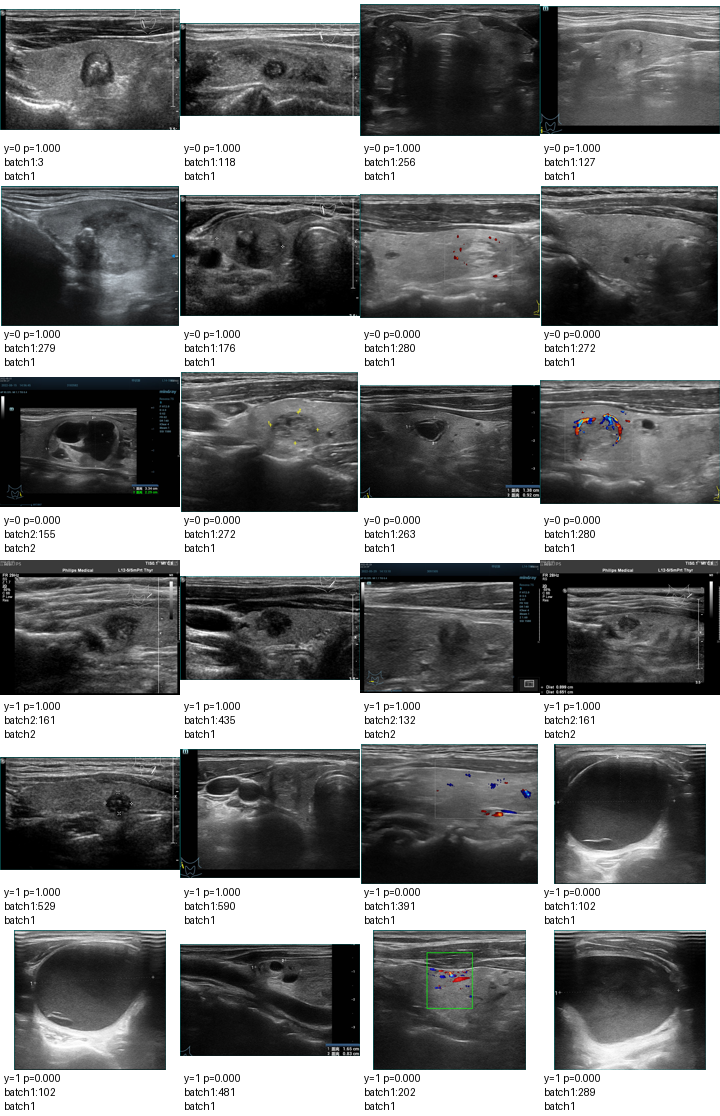


===== TN5000 TEST CONTACT SHEET =====


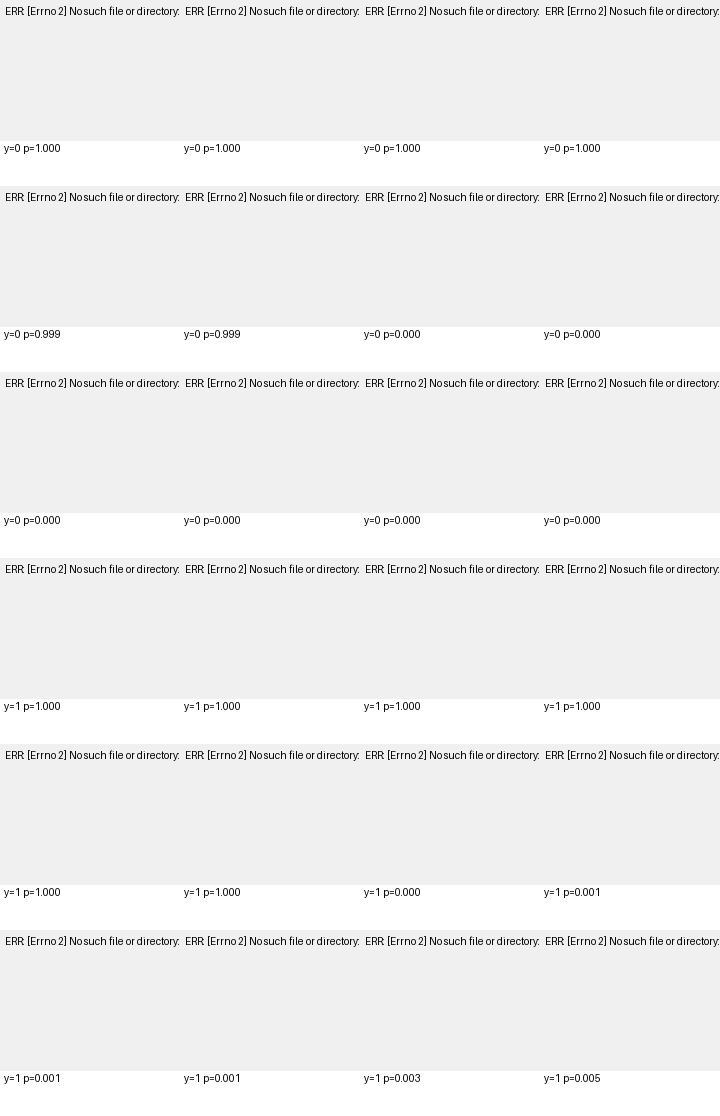


===== DIAGNOSTIC FLAGS =====
{
  "external_auc_near_random": true,
  "inverting_probabilities_would_help": false,
  "external_label1_has_higher_median_probability_than_label0": false,
  "internal_auc_good_external_auc_poor": true
}

Saved diagnostic summary:
/content/drive/MyDrive/thyroid_external_validation_outputs/cell17B_external_low_result_diagnostic/cell17B_diagnostic_summary.json

===== CELL 17B COMPLETE =====
{
  "cell": "cell17B_external_low_result_diagnostic_audit",
  "model_name": "mobilenetv2_100",
  "display_name": "MobileNetV2",
  "seed": 42,
  "locked_threshold": 0.86669921875,
  "temperature": 2.4700443744659424,
  "internal_tn5000_test_auc": 0.8572214642253553,
  "external_primary_auc": 0.4979683669920877,
  "external_primary_inverted_probability_auc": 0.5020316330079122,
  "external_primary_median_prob_label0": 0.3718206588777863,
  "external_primary_median_prob_label1": 0.324663488782487,
  "flags": {
    "external_auc_near_random": true,
    "inverting_probabilities

In [ ]:
# =========================
# CELL 17B — Diagnostic audit for unexpectedly low external result
# Purpose:
#   Investigate why external ROC-AUC is near random before running all external models.
#
# Uses:
#   - MobileNetV2 seed 42 external predictions already created before interruption
#   - MobileNetV2 seed 42 TN5000 test predictions from Cell 16
#   - fixed external LOCALCACHE manifests from Cell 17A-FIX
#
# Checks:
#   1) whether saved external predictions exist
#   2) image/path/label/case/batch integrity
#   3) MD5/path mapping consistency on a sample
#   4) external probability distribution vs TN5000 test
#   5) normal AUC vs inverted-label AUC
#   6) batch-level metrics
#   7) contact-sheet image previews of high/low probability external cases
#
# No training, no retuning, no external threshold optimization.
# =========================

import json, hashlib, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont, ImageOps
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix,
    accuracy_score, precision_score, f1_score, brier_score_loss
)

# -------------------------
# Mount Drive
# -------------------------
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("Drive mount note:", repr(e))

# -------------------------
# Paths
# -------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"

CELL17_ROOT = OUT_ROOT / "cell17_external_validation_hou2024"
CELL17_PRED_DIR = CELL17_ROOT / "predictions"

CELL16_PRED_DIR = OUT_ROOT / "cell16_internal_tn5000_test_evaluation" / "predictions"
CELL16_RESULTS_CSV = OUT_ROOT / "cell16_internal_tn5000_test_evaluation" / "tables" / "cell16_all_models_all_seeds_tn5000_test_results.csv"

PRIMARY_LOCAL = OUT_ROOT / "manifest_hou2024_external_primary_all_usable_LOCALCACHE.csv"
SENS_LOCAL = OUT_ROOT / "manifest_hou2024_external_imagelevel_exact_dedup_sensitivity_LOCALCACHE.csv"

DIAG_ROOT = OUT_ROOT / "cell17B_external_low_result_diagnostic"
TABLE_DIR = DIAG_ROOT / "tables"
FIG_DIR = DIAG_ROOT / "figures"

for d in [DIAG_ROOT, TABLE_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "mobilenetv2_100"
DISPLAY_NAME = "MobileNetV2"
SEED = 42

EXT_PRIMARY_PRED = CELL17_PRED_DIR / f"{MODEL_NAME}_seed{SEED}_primary_all_usable_external_image_predictions.csv"
EXT_SENS_PRED = CELL17_PRED_DIR / f"{MODEL_NAME}_seed{SEED}_sensitivity_exact_dedup_external_image_predictions.csv"
TN_TEST_PRED = CELL16_PRED_DIR / f"{MODEL_NAME}_seed{SEED}_tn5000_test_predictions.csv"

print("===== FILE CHECK =====")
paths = {
    "external_primary_predictions": EXT_PRIMARY_PRED,
    "external_sensitivity_predictions": EXT_SENS_PRED,
    "tn5000_test_predictions": TN_TEST_PRED,
    "cell16_results_csv": CELL16_RESULTS_CSV,
    "primary_local_manifest": PRIMARY_LOCAL,
    "sensitivity_local_manifest": SENS_LOCAL,
}

for name, p in paths.items():
    print(f"{name}: {p.exists()} | {p}")

assert EXT_PRIMARY_PRED.exists(), "External primary prediction CSV missing. The interrupted Cell 17 did not save it."
assert EXT_SENS_PRED.exists(), "External sensitivity prediction CSV missing. The interrupted Cell 17 did not save it."
assert TN_TEST_PRED.exists(), "Cell 16 TN5000 test prediction CSV missing."
assert CELL16_RESULTS_CSV.exists(), "Cell 16 results CSV missing."
assert PRIMARY_LOCAL.exists(), "Fixed primary LOCALCACHE manifest missing. Rerun Cell 17A-FIX."
assert SENS_LOCAL.exists(), "Fixed sensitivity LOCALCACHE manifest missing. Rerun Cell 17A-FIX."

# -------------------------
# Load data
# -------------------------
primary_pred = pd.read_csv(EXT_PRIMARY_PRED)
sens_pred = pd.read_csv(EXT_SENS_PRED)
tn_pred = pd.read_csv(TN_TEST_PRED)

primary_manifest = pd.read_csv(PRIMARY_LOCAL)
sens_manifest = pd.read_csv(SENS_LOCAL)
cell16_results = pd.read_csv(CELL16_RESULTS_CSV)

lock_row = cell16_results[(cell16_results["model_name"] == MODEL_NAME) & (cell16_results["seed"] == SEED)]
assert len(lock_row) == 1, "Missing Cell 16 lock row for MobileNetV2 seed 42"

locked_threshold = float(lock_row.iloc[0]["locked_val_threshold_youden_raw"])
temperature = float(lock_row.iloc[0]["temperature_from_val"])

print("\nLocked threshold from TN5000 val:", locked_threshold)
print("Temperature from TN5000 val:", temperature)

# -------------------------
# Metric helpers
# -------------------------
def expected_calibration_error(y_true, y_prob, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (y_prob >= lo) & (y_prob <= hi)
        else:
            mask = (y_prob >= lo) & (y_prob < hi)

        if mask.sum() == 0:
            continue

        ece += (mask.sum() / len(y_true)) * abs(y_true[mask].mean() - y_prob[mask].mean())

    return float(ece)

def metrics_at_threshold(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "n": int(len(y_true)),
        "prevalence_label1": float(y_true.mean()),
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "sensitivity": float(sens),
        "specificity": float(spec),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "roc_auc_if_labels_inverted": float(roc_auc_score(1 - y_true, y_prob)),
        "roc_auc_if_prob_inverted": float(roc_auc_score(y_true, 1 - y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "ece_15bins": float(expected_calibration_error(y_true, y_prob, 15)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def dataset_summary(name, df, prob_col="prob_malignant_raw"):
    y = df["y_true"].astype(int).values
    p = df[prob_col].astype(float).values

    m = metrics_at_threshold(y, p, locked_threshold)
    m["dataset"] = name
    m["prob_col"] = prob_col
    m["prob_min"] = float(np.min(p))
    m["prob_q01"] = float(np.quantile(p, 0.01))
    m["prob_q05"] = float(np.quantile(p, 0.05))
    m["prob_q25"] = float(np.quantile(p, 0.25))
    m["prob_median"] = float(np.median(p))
    m["prob_q75"] = float(np.quantile(p, 0.75))
    m["prob_q95"] = float(np.quantile(p, 0.95))
    m["prob_q99"] = float(np.quantile(p, 0.99))
    m["prob_max"] = float(np.max(p))
    m["prob_mean_label0"] = float(df.loc[df["y_true"] == 0, prob_col].mean())
    m["prob_mean_label1"] = float(df.loc[df["y_true"] == 1, prob_col].mean())
    m["prob_median_label0"] = float(df.loc[df["y_true"] == 0, prob_col].median())
    m["prob_median_label1"] = float(df.loc[df["y_true"] == 1, prob_col].median())
    return m

# -------------------------
# Basic summaries
# -------------------------
summary_rows = [
    dataset_summary("TN5000_test_internal", tn_pred, "prob_malignant_raw"),
    dataset_summary("External_primary_image", primary_pred, "prob_malignant_raw"),
    dataset_summary("External_sensitivity_image", sens_pred, "prob_malignant_raw"),
]

if "prob_malignant_calibrated" in tn_pred.columns:
    summary_rows.append(dataset_summary("TN5000_test_internal_calibrated", tn_pred, "prob_malignant_calibrated"))

if "prob_malignant_calibrated" in primary_pred.columns:
    summary_rows.append(dataset_summary("External_primary_image_calibrated", primary_pred, "prob_malignant_calibrated"))

if "prob_malignant_calibrated" in sens_pred.columns:
    summary_rows.append(dataset_summary("External_sensitivity_image_calibrated", sens_pred, "prob_malignant_calibrated"))

summary_df = pd.DataFrame(summary_rows)

print("\n===== DATASET / METRIC SUMMARY =====")
display(summary_df)

summary_csv = TABLE_DIR / "cell17B_metric_probability_summary.csv"
summary_df.to_csv(summary_csv, index=False)

# -------------------------
# Batch-level external audit
# -------------------------
batch_rows = []
for dataset_name, df in [("primary", primary_pred), ("sensitivity", sens_pred)]:
    for batch, g in df.groupby("batch"):
        if g["y_true"].nunique() < 2:
            continue
        row = dataset_summary(f"{dataset_name}_{batch}", g, "prob_malignant_raw")
        row["dataset_group"] = dataset_name
        row["batch"] = batch
        batch_rows.append(row)

batch_df = pd.DataFrame(batch_rows)

print("\n===== EXTERNAL BATCH-LEVEL SUMMARY =====")
display(batch_df)

batch_csv = TABLE_DIR / "cell17B_external_batch_metric_summary.csv"
batch_df.to_csv(batch_csv, index=False)

# -------------------------
# Manifest/path integrity checks
# -------------------------
print("\n===== MANIFEST / PATH INTEGRITY CHECK =====")

def md5_file(path, block_size=1024 * 1024):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(block_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

def manifest_integrity(name, manifest, pred):
    rows = []

    required_cols = ["image_path", "label", "case_uid", "batch"]
    missing = [c for c in required_cols if c not in manifest.columns]
    assert not missing, f"{name} manifest missing columns: {missing}"

    exists = manifest["image_path"].apply(lambda x: Path(str(x)).exists())

    rows.append({
        "dataset": name,
        "check": "row_count_manifest",
        "value": int(len(manifest)),
    })
    rows.append({
        "dataset": name,
        "check": "row_count_predictions",
        "value": int(len(pred)),
    })
    rows.append({
        "dataset": name,
        "check": "image_paths_exist",
        "value": bool(exists.all()),
    })
    rows.append({
        "dataset": name,
        "check": "case_count_manifest",
        "value": int(manifest["case_uid"].nunique()),
    })
    rows.append({
        "dataset": name,
        "check": "case_count_predictions",
        "value": int(pred["case_uid"].nunique()),
    })
    rows.append({
        "dataset": name,
        "check": "manifest_label_counts",
        "value": str(manifest["label"].value_counts().sort_index().to_dict()),
    })
    rows.append({
        "dataset": name,
        "check": "prediction_label_counts",
        "value": str(pred["y_true"].value_counts().sort_index().to_dict()),
    })
    rows.append({
        "dataset": name,
        "check": "batch_counts_manifest",
        "value": str(manifest["batch"].value_counts(dropna=False).to_dict()),
    })
    rows.append({
        "dataset": name,
        "check": "batch_counts_predictions",
        "value": str(pred["batch"].value_counts(dropna=False).to_dict()),
    })

    # filename-patient prefix check
    prefix_mismatch = None
    if "image_filename_actual" in manifest.columns and "patient_name" in manifest.columns:
        tmp = manifest.copy()
        tmp["file_prefix"] = tmp["image_filename_actual"].astype(str).str.split("_").str[0]
        tmp["patient_name_str"] = tmp["patient_name"].astype(str)
        prefix_mismatch = int((tmp["file_prefix"] != tmp["patient_name_str"]).sum())
        rows.append({
            "dataset": name,
            "check": "filename_prefix_patient_mismatch_count",
            "value": prefix_mismatch,
        })

    # MD5 sample check against original manifest md5, if md5 column exists
    if "md5" in manifest.columns:
        sample = manifest.sample(min(200, len(manifest)), random_state=42)
        mismatches = []
        for _, r in sample.iterrows():
            current_md5 = md5_file(str(r["image_path"]))
            expected_md5 = str(r["md5"])
            if current_md5 != expected_md5:
                mismatches.append({
                    "image_path": r["image_path"],
                    "expected_md5": expected_md5,
                    "current_md5": current_md5,
                })

        rows.append({
            "dataset": name,
            "check": "md5_sample_size",
            "value": int(len(sample)),
        })
        rows.append({
            "dataset": name,
            "check": "md5_sample_mismatch_count",
            "value": int(len(mismatches)),
        })

        if mismatches:
            mismatch_df = pd.DataFrame(mismatches)
            mismatch_path = TABLE_DIR / f"cell17B_{name}_md5_mismatches.csv"
            mismatch_df.to_csv(mismatch_path, index=False)
            rows.append({
                "dataset": name,
                "check": "md5_mismatch_csv",
                "value": str(mismatch_path),
            })

    return rows

integrity_rows = []
integrity_rows += manifest_integrity("primary", primary_manifest, primary_pred)
integrity_rows += manifest_integrity("sensitivity", sens_manifest, sens_pred)

integrity_df = pd.DataFrame(integrity_rows)
display(integrity_df)

integrity_csv = TABLE_DIR / "cell17B_manifest_path_integrity_summary.csv"
integrity_df.to_csv(integrity_csv, index=False)

# -------------------------
# Probability distribution figures
# -------------------------
def save_prob_hist(df, name, prob_col="prob_malignant_raw"):
    fig, ax = plt.subplots(figsize=(8, 5))

    p0 = df.loc[df["y_true"] == 0, prob_col].astype(float).values
    p1 = df.loc[df["y_true"] == 1, prob_col].astype(float).values

    ax.hist(p0, bins=40, alpha=0.5, label="Label 0")
    ax.hist(p1, bins=40, alpha=0.5, label="Label 1")
    ax.axvline(locked_threshold, linestyle="--", label="Locked val threshold")
    ax.set_xlabel("Predicted malignant probability")
    ax.set_ylabel("Image count")
    ax.set_title(name)
    ax.legend()
    fig.tight_layout()

    path = FIG_DIR / f"cell17B_{name.replace(' ', '_').replace('/', '_')}_prob_hist_300dpi.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    return path

fig_paths = []
fig_paths.append(save_prob_hist(tn_pred, "TN5000_test_internal_raw", "prob_malignant_raw"))
fig_paths.append(save_prob_hist(primary_pred, "External_primary_raw", "prob_malignant_raw"))
fig_paths.append(save_prob_hist(sens_pred, "External_sensitivity_raw", "prob_malignant_raw"))

if "prob_malignant_calibrated" in primary_pred.columns:
    fig_paths.append(save_prob_hist(primary_pred, "External_primary_calibrated", "prob_malignant_calibrated"))

print("\nSaved probability figures:")
for p in fig_paths:
    print(p)

# -------------------------
# Contact-sheet image preview
# -------------------------
def make_contact_sheet(df, title, out_path, prob_col="prob_malignant_raw", max_images=24):
    # select high/low prob images across both labels
    parts = []

    for label in [0, 1]:
        g = df[df["y_true"] == label].copy()
        if len(g) == 0:
            continue

        parts.append(g.sort_values(prob_col, ascending=False).head(max_images // 4))
        parts.append(g.sort_values(prob_col, ascending=True).head(max_images // 4))

    sel = pd.concat(parts, ignore_index=True).head(max_images)

    thumb_w, thumb_h = 180, 140
    label_h = 46
    cols = 4
    rows = int(np.ceil(len(sel) / cols))

    sheet = Image.new("RGB", (cols * thumb_w, rows * (thumb_h + label_h)), "white")
    draw = ImageDraw.Draw(sheet)

    for i, (_, r) in enumerate(sel.iterrows()):
        row = i // cols
        col = i % cols
        x0 = col * thumb_w
        y0 = row * (thumb_h + label_h)

        try:
            im = Image.open(r["image_path"]).convert("RGB")
            im = ImageOps.contain(im, (thumb_w, thumb_h))
            px = x0 + (thumb_w - im.width) // 2
            py = y0 + (thumb_h - im.height) // 2
            sheet.paste(im, (px, py))
        except Exception as e:
            draw.rectangle([x0, y0, x0 + thumb_w, y0 + thumb_h], fill=(240, 240, 240))
            draw.text((x0 + 5, y0 + 5), f"ERR: {e}", fill=(0, 0, 0))

        txt = f"y={int(r['y_true'])} p={float(r[prob_col]):.3f}\n{str(r.get('case_uid',''))[:18]}\n{str(r.get('batch',''))}"
        draw.text((x0 + 4, y0 + thumb_h + 2), txt, fill=(0, 0, 0))

    sheet.save(out_path)
    return out_path

primary_sheet = FIG_DIR / "cell17B_external_primary_high_low_probability_contact_sheet.png"
tn_sheet = FIG_DIR / "cell17B_tn5000_test_high_low_probability_contact_sheet.png"

make_contact_sheet(primary_pred, "External primary high/low probabilities", primary_sheet)
make_contact_sheet(tn_pred, "TN5000 test high/low probabilities", tn_sheet)

print("\nSaved contact sheets:")
print(primary_sheet)
print(tn_sheet)

# Display contact sheets in Colab
print("\n===== EXTERNAL PRIMARY CONTACT SHEET =====")
display(Image.open(primary_sheet))

print("\n===== TN5000 TEST CONTACT SHEET =====")
display(Image.open(tn_sheet))

# -------------------------
# Interpretation flags
# -------------------------
primary_auc = float(summary_df.loc[summary_df["dataset"] == "External_primary_image", "roc_auc"].iloc[0])
primary_inv_auc = float(summary_df.loc[summary_df["dataset"] == "External_primary_image", "roc_auc_if_prob_inverted"].iloc[0])

primary_prob_label0 = float(summary_df.loc[summary_df["dataset"] == "External_primary_image", "prob_median_label0"].iloc[0])
primary_prob_label1 = float(summary_df.loc[summary_df["dataset"] == "External_primary_image", "prob_median_label1"].iloc[0])

tn_auc = float(summary_df.loc[summary_df["dataset"] == "TN5000_test_internal", "roc_auc"].iloc[0])

flags = {
    "external_auc_near_random": bool(0.45 <= primary_auc <= 0.55),
    "inverting_probabilities_would_help": bool(primary_inv_auc >= 0.70),
    "external_label1_has_higher_median_probability_than_label0": bool(primary_prob_label1 > primary_prob_label0),
    "internal_auc_good_external_auc_poor": bool(tn_auc >= 0.80 and primary_auc <= 0.60),
}

diagnostic_summary = {
    "cell": "cell17B_external_low_result_diagnostic_audit",
    "model_name": MODEL_NAME,
    "display_name": DISPLAY_NAME,
    "seed": SEED,
    "locked_threshold": locked_threshold,
    "temperature": temperature,
    "internal_tn5000_test_auc": tn_auc,
    "external_primary_auc": primary_auc,
    "external_primary_inverted_probability_auc": primary_inv_auc,
    "external_primary_median_prob_label0": primary_prob_label0,
    "external_primary_median_prob_label1": primary_prob_label1,
    "flags": flags,
    "tables": {
        "metric_probability_summary": str(summary_csv),
        "batch_summary": str(batch_csv),
        "manifest_path_integrity_summary": str(integrity_csv),
    },
    "figures": {
        "probability_histograms": [str(p) for p in fig_paths],
        "external_contact_sheet": str(primary_sheet),
        "tn5000_contact_sheet": str(tn_sheet),
    },
    "interpretation_note": (
        "If external_auc_near_random is true and inverting_probabilities_would_help is false, "
        "this is not mainly a threshold-direction issue. It suggests severe domain shift, "
        "label/path mismatch not detected by simple checks, or a preprocessing/distribution mismatch."
    )
}

summary_json = DIAG_ROOT / "cell17B_diagnostic_summary.json"
with open(summary_json, "w") as f:
    json.dump(diagnostic_summary, f, indent=2)

print("\n===== DIAGNOSTIC FLAGS =====")
print(json.dumps(flags, indent=2))

print("\nSaved diagnostic summary:")
print(summary_json)

print("\n===== CELL 17B COMPLETE =====")
print(json.dumps(diagnostic_summary, indent=2))

In [ ]:
# =========================
# CELL 17C — External sanity check using seed 2024 for all six models
#
# Purpose:
#   Check whether the very low external result is MobileNetV2-specific
#   or a broader external-domain / label / preprocessing problem.
#
# Evaluates:
#   - primary external all-usable dataset only
#   - seed 2024 only for each model
#   - image-level, case-mean, case-max, and batch image-level
#
# Uses:
#   - locked thresholds from TN5000 validation via Cell 16
#   - temperatures fitted only on TN5000 validation via Cell 16
#
# No training.
# No external threshold tuning.
# No external recalibration.
# No model selection.
# =========================

import os, sys, json, random, time, subprocess, importlib.util, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

def ensure_package(import_name, pip_name=None):
    if pip_name is None:
        pip_name = import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing missing package: {pip_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])
    else:
        print(f"Package available: {import_name}")

ensure_package("timm", "timm")
ensure_package("sklearn", "scikit-learn")

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix,
    accuracy_score, precision_score, f1_score, brier_score_loss
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

# -------------------------
# Mount Drive
# -------------------------
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("Drive mount note:", repr(e))

# -------------------------
# Paths/config
# -------------------------
DRIVE_ROOT = Path("/content/drive/MyDrive")
OUT_ROOT = DRIVE_ROOT / "thyroid_external_validation_outputs"

CELL16_SEED_RESULTS = OUT_ROOT / "cell16_internal_tn5000_test_evaluation" / "tables" / "cell16_all_models_all_seeds_tn5000_test_results.csv"
EXTERNAL_PRIMARY_LOCAL = OUT_ROOT / "manifest_hou2024_external_primary_all_usable_LOCALCACHE.csv"

CELL17C_ROOT = OUT_ROOT / "cell17C_external_sanity_check_seed2024"
PRED_DIR = CELL17C_ROOT / "predictions"
TABLE_DIR = CELL17C_ROOT / "tables"

for d in [CELL17C_ROOT, PRED_DIR, TABLE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 2024
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

MODEL_REGISTRY = [
    {"model_name": "mobilenetv2_100", "display_name": "MobileNetV2", "cell_folder": "production_training_cell9"},
    {"model_name": "efficientnet_b0", "display_name": "EfficientNet-B0", "cell_folder": "production_training_cell10"},
    {"model_name": "densenet121", "display_name": "DenseNet-121", "cell_folder": "production_training_cell11"},
    {"model_name": "resnet50", "display_name": "ResNet-50", "cell_folder": "production_training_cell12"},
    {"model_name": "convnext_tiny", "display_name": "ConvNeXt-Tiny", "cell_folder": "production_training_cell13"},
    {"model_name": "swin_tiny_patch4_window7_224", "display_name": "Swin Transformer-Tiny", "cell_folder": "production_training_cell14"},
]

assert OUT_ROOT.exists(), f"Missing OUT_ROOT: {OUT_ROOT}"
assert CELL16_SEED_RESULTS.exists(), f"Missing Cell 16 seed results: {CELL16_SEED_RESULTS}"
assert EXTERNAL_PRIMARY_LOCAL.exists(), f"Missing external primary LOCALCACHE manifest: {EXTERNAL_PRIMARY_LOCAL}"

# -------------------------
# Device
# -------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
else:
    raise RuntimeError("GPU not detected. Switch Colab runtime to T4 GPU.")

# -------------------------
# Helpers
# -------------------------
def safe_torch_load(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-x))

def expected_calibration_error(y_true, y_prob, n_bins=15):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (y_prob >= lo) & (y_prob <= hi)
        else:
            mask = (y_prob >= lo) & (y_prob < hi)

        if mask.sum() == 0:
            continue

        ece += (mask.sum() / len(y_true)) * abs(y_true[mask].mean() - y_prob[mask].mean())

    return float(ece)

def metrics_at_threshold(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "n": int(len(y_true)),
        "prevalence_label1": float(y_true.mean()),
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc_raw": float(roc_auc_score(y_true, y_prob)),
        "roc_auc_if_prob_inverted": float(roc_auc_score(y_true, 1 - y_prob)),
        "pr_auc_raw": float(average_precision_score(y_true, y_prob)),
        "brier_raw": float(brier_score_loss(y_true, y_prob)),
        "ece_raw": float(expected_calibration_error(y_true, y_prob, n_bins=15)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def calibration_metrics(y_true, y_prob_cal):
    return {
        "roc_auc_calibrated": float(roc_auc_score(y_true, y_prob_cal)),
        "pr_auc_calibrated": float(average_precision_score(y_true, y_prob_cal)),
        "brier_calibrated": float(brier_score_loss(y_true, y_prob_cal)),
        "ece_calibrated": float(expected_calibration_error(y_true, y_prob_cal, n_bins=15)),
    }

def aggregate_case_level(pred_df, prob_col, method="mean"):
    rows = []

    for case_uid, g in pred_df.groupby("case_uid"):
        labels = sorted(g["y_true"].astype(int).unique().tolist())
        if len(labels) != 1:
            raise ValueError(f"Case label conflict for {case_uid}: {labels}")

        if method == "mean":
            prob = float(g[prob_col].mean())
        elif method == "max":
            prob = float(g[prob_col].max())
        else:
            raise ValueError(method)

        rows.append({
            "case_uid": str(case_uid),
            "y_true": int(labels[0]),
            "prob_malignant": prob,
            "n_images": int(len(g)),
            "batch": str(g["batch"].iloc[0]),
        })

    return pd.DataFrame(rows)

# -------------------------
# Load external manifest
# -------------------------
external_df = pd.read_csv(EXTERNAL_PRIMARY_LOCAL)
external_df["label"] = external_df["label"].astype(int)
external_df["case_uid"] = external_df["case_uid"].astype(str)
external_df["batch"] = external_df["batch"].astype(str).str.lower()

# Use /tmp cached image path if present, otherwise use Drive source path.
def resolve_eval_path(row):
    p1 = Path(str(row.get("image_path", "")))
    if p1.exists():
        return str(p1)

    p2 = Path(str(row.get("drive_or_source_image_path", "")))
    if p2.exists():
        return str(p2)

    raise FileNotFoundError(f"No valid image path for row: {row.to_dict()}")

external_df["eval_image_path"] = external_df.apply(resolve_eval_path, axis=1)

exists = external_df["eval_image_path"].apply(lambda x: Path(str(x)).exists())
print("\nExternal primary rows:", len(external_df))
print("External primary cases:", external_df["case_uid"].nunique())
print("Label counts:", external_df["label"].value_counts().sort_index().to_dict())
print("Batch counts:", external_df["batch"].value_counts(dropna=False).to_dict())
print("Eval path exists:", exists.value_counts(dropna=False).to_dict())
assert exists.all()

# -------------------------
# Dataset / loader
# -------------------------
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class ExternalDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = Path(str(row["eval_image_path"]))

        with Image.open(path) as img:
            img = img.convert("RGB")

        if self.transform:
            img = self.transform(img)

        y = torch.tensor(float(row["label"]), dtype=torch.float32)

        meta = {
            "image_path": str(path),
            "case_uid": str(row["case_uid"]),
            "batch": str(row["batch"]),
            "label": int(row["label"]),
        }

        return img, y, meta

ds = ExternalDataset(external_df, transform=eval_transform)
loader = DataLoader(
    ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0),
    drop_last=False,
)

def create_model(model_name):
    return timm.create_model(model_name, pretrained=False, num_classes=1, in_chans=3)

@torch.no_grad()
def predict_logits(model, loader, device):
    model.eval()

    all_y, all_logits, all_meta = [], [], []

    for x, y, meta in loader:
        x = x.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            logits = model(x).view(-1)

        all_logits.extend(logits.detach().cpu().numpy().astype(float).tolist())
        all_y.extend(y.numpy().astype(int).tolist())

        for i in range(len(y)):
            all_meta.append({
                "image_path": meta["image_path"][i],
                "case_uid": meta["case_uid"][i],
                "batch": meta["batch"][i],
                "label": int(meta["label"][i]),
            })

    return np.asarray(all_y).astype(int), np.asarray(all_logits).astype(float), all_meta

# -------------------------
# Load Cell 16 locks
# -------------------------
cell16_df = pd.read_csv(CELL16_SEED_RESULTS)

# -------------------------
# Evaluate seed 2024 for each model
# -------------------------
image_rows = []
case_rows = []
batch_rows = []
prediction_paths = []

overall_t0 = time.time()

for m in MODEL_REGISTRY:
    model_name = m["model_name"]
    display_name = m["display_name"]
    cell_folder = m["cell_folder"]

    lock = cell16_df[(cell16_df["model_name"] == model_name) & (cell16_df["seed"] == SEED)]
    assert len(lock) == 1, f"Missing Cell 16 lock row for {model_name} seed {SEED}"

    threshold = float(lock.iloc[0]["locked_val_threshold_youden_raw"])
    temperature = float(lock.iloc[0]["temperature_from_val"])
    internal_test_auc = float(lock.iloc[0]["test_roc_auc_raw"]) if "test_roc_auc_raw" in lock.columns else np.nan
    internal_test_f1 = float(lock.iloc[0]["test_f1"]) if "test_f1" in lock.columns else np.nan

    ckpt = OUT_ROOT / cell_folder / model_name / "checkpoints" / f"{model_name}_seed{SEED}_best.pt"
    assert ckpt.exists(), f"Missing checkpoint: {ckpt}"

    print(f"\n==================== {display_name} | seed {SEED} ====================")
    print("Checkpoint:", ckpt)
    print("Locked threshold:", threshold)
    print("Temperature:", temperature)
    print("Cell16 internal test AUC:", internal_test_auc)

    seed_everything(SEED)

    model = create_model(model_name).to(DEVICE)
    state = safe_torch_load(ckpt, map_location=DEVICE)
    model.load_state_dict(state["model_state_dict"])
    model.eval()

    t0 = time.time()
    y, logits, meta = predict_logits(model, loader, DEVICE)
    infer_sec = time.time() - t0

    prob_raw = sigmoid_np(logits)
    prob_cal = sigmoid_np(logits / temperature)

    pred_df = pd.DataFrame(meta)
    pred_df["y_true"] = y
    pred_df["logit_raw"] = logits
    pred_df["prob_malignant_raw"] = prob_raw
    pred_df["prob_malignant_calibrated"] = prob_cal
    pred_df["locked_val_threshold_raw"] = threshold
    pred_df["temperature_from_tn5000_val"] = temperature
    pred_df["y_pred_locked_raw_threshold"] = (prob_raw >= threshold).astype(int)
    pred_df["model_name"] = model_name
    pred_df["display_name"] = display_name
    pred_df["seed"] = SEED

    pred_path = PRED_DIR / f"{model_name}_seed{SEED}_primary_external_sanity_predictions.csv"
    pred_df.to_csv(pred_path, index=False)
    prediction_paths.append(str(pred_path))

    image_metrics = metrics_at_threshold(y, prob_raw, threshold)
    image_cal = calibration_metrics(y, prob_cal)

    image_row = {
        "level": "image",
        "model_name": model_name,
        "display_name": display_name,
        "seed": SEED,
        "n_images": int(len(pred_df)),
        "n_cases": int(pred_df["case_uid"].nunique()),
        "internal_test_auc_seed2024": internal_test_auc,
        "internal_test_f1_seed2024": internal_test_f1,
        "locked_val_threshold_youden_raw": threshold,
        "temperature_from_tn5000_val": temperature,
        "inference_sec": float(infer_sec),
        "inference_ms_per_image": float(infer_sec / len(pred_df) * 1000),
        **image_metrics,
        **image_cal,
        "prob_mean_label0": float(pred_df.loc[pred_df["y_true"] == 0, "prob_malignant_raw"].mean()),
        "prob_mean_label1": float(pred_df.loc[pred_df["y_true"] == 1, "prob_malignant_raw"].mean()),
        "prob_median_label0": float(pred_df.loc[pred_df["y_true"] == 0, "prob_malignant_raw"].median()),
        "prob_median_label1": float(pred_df.loc[pred_df["y_true"] == 1, "prob_malignant_raw"].median()),
        "prediction_csv": str(pred_path),
    }
    image_rows.append(image_row)

    for method in ["mean", "max"]:
        c_raw = aggregate_case_level(pred_df, "prob_malignant_raw", method=method)
        c_cal = aggregate_case_level(pred_df, "prob_malignant_calibrated", method=method)

        cy = c_raw["y_true"].astype(int).values
        cp_raw = c_raw["prob_malignant"].astype(float).values
        cp_cal = c_cal["prob_malignant"].astype(float).values

        c_metrics = metrics_at_threshold(cy, cp_raw, threshold)
        c_cal_metrics = calibration_metrics(cy, cp_cal)

        case_rows.append({
            "level": f"case_{method}",
            "model_name": model_name,
            "display_name": display_name,
            "seed": SEED,
            "n_images": int(len(pred_df)),
            "n_cases": int(len(c_raw)),
            "internal_test_auc_seed2024": internal_test_auc,
            "internal_test_f1_seed2024": internal_test_f1,
            "locked_val_threshold_youden_raw": threshold,
            "temperature_from_tn5000_val": temperature,
            **c_metrics,
            **c_cal_metrics,
            "prediction_csv": str(pred_path),
        })

    for batch, g in pred_df.groupby("batch"):
        by = g["y_true"].astype(int).values
        bp_raw = g["prob_malignant_raw"].astype(float).values
        bp_cal = g["prob_malignant_calibrated"].astype(float).values

        if len(np.unique(by)) < 2:
            continue

        bm = metrics_at_threshold(by, bp_raw, threshold)
        bc = calibration_metrics(by, bp_cal)

        batch_rows.append({
            "level": "image_batch",
            "batch": batch,
            "model_name": model_name,
            "display_name": display_name,
            "seed": SEED,
            "n_images": int(len(g)),
            "n_cases": int(g["case_uid"].nunique()),
            "locked_val_threshold_youden_raw": threshold,
            "temperature_from_tn5000_val": temperature,
            **bm,
            **bc,
            "prob_mean_label0": float(g.loc[g["y_true"] == 0, "prob_malignant_raw"].mean()),
            "prob_mean_label1": float(g.loc[g["y_true"] == 1, "prob_malignant_raw"].mean()),
            "prob_median_label0": float(g.loc[g["y_true"] == 0, "prob_malignant_raw"].median()),
            "prob_median_label1": float(g.loc[g["y_true"] == 1, "prob_malignant_raw"].median()),
            "prediction_csv": str(pred_path),
        })

    print(json.dumps({
        "display_name": display_name,
        "seed": SEED,
        "internal_test_auc_seed2024": internal_test_auc,
        "external_image_auc": image_row["roc_auc_raw"],
        "external_image_auc_if_prob_inverted": image_row["roc_auc_if_prob_inverted"],
        "external_pr_auc": image_row["pr_auc_raw"],
        "external_f1_locked_threshold": image_row["f1"],
        "external_brier_calibrated": image_row["brier_calibrated"],
        "external_ece_calibrated": image_row["ece_calibrated"],
        "prob_median_label0": image_row["prob_median_label0"],
        "prob_median_label1": image_row["prob_median_label1"],
        "tn": image_row["tn"],
        "fp": image_row["fp"],
        "fn": image_row["fn"],
        "tp": image_row["tp"],
    }, indent=2))

    del model
    torch.cuda.empty_cache()

overall_sec = time.time() - overall_t0

image_df = pd.DataFrame(image_rows)
case_df = pd.DataFrame(case_rows)
batch_df = pd.DataFrame(batch_rows)

# Rank image-level by external ROC-AUC
image_rank_df = image_df.sort_values(
    by=["roc_auc_raw", "pr_auc_raw", "f1", "brier_calibrated", "ece_calibrated"],
    ascending=[False, False, False, True, True]
).reset_index(drop=True)
image_rank_df.insert(0, "external_sanity_rank", np.arange(1, len(image_rank_df) + 1))

case_rank_df = case_df[case_df["level"] == "case_mean"].sort_values(
    by=["roc_auc_raw", "pr_auc_raw", "f1", "brier_calibrated", "ece_calibrated"],
    ascending=[False, False, False, True, True]
).reset_index(drop=True)
case_rank_df.insert(0, "external_sanity_rank", np.arange(1, len(case_rank_df) + 1))

# Save
image_csv = TABLE_DIR / "cell17C_seed2024_primary_external_image_level.csv"
case_csv = TABLE_DIR / "cell17C_seed2024_primary_external_case_level.csv"
batch_csv = TABLE_DIR / "cell17C_seed2024_primary_external_batch_level.csv"
image_rank_csv = TABLE_DIR / "cell17C_seed2024_primary_external_image_ranking.csv"
case_rank_csv = TABLE_DIR / "cell17C_seed2024_primary_external_case_mean_ranking.csv"

image_df.to_csv(image_csv, index=False)
case_df.to_csv(case_csv, index=False)
batch_df.to_csv(batch_csv, index=False)
image_rank_df.to_csv(image_rank_csv, index=False)
case_rank_df.to_csv(case_rank_csv, index=False)

# Decision flags
max_image_auc = float(image_rank_df["roc_auc_raw"].max())
best_image_model = str(image_rank_df.iloc[0]["display_name"])
max_case_auc = float(case_rank_df["roc_auc_raw"].max())
best_case_model = str(case_rank_df.iloc[0]["display_name"])

flags = {
    "at_least_one_model_external_image_auc_above_0_70": bool(max_image_auc >= 0.70),
    "at_least_one_model_external_case_mean_auc_above_0_70": bool(max_case_auc >= 0.70),
    "all_seed2024_models_near_random_image_auc": bool(image_rank_df["roc_auc_raw"].between(0.45, 0.55).all()),
    "best_image_model": best_image_model,
    "best_image_auc": max_image_auc,
    "best_case_mean_model": best_case_model,
    "best_case_mean_auc": max_case_auc,
}

summary = {
    "cell": "cell17C_external_sanity_check_seed2024_all_models",
    "seed": SEED,
    "external_dataset": "primary_all_usable",
    "n_images": int(len(external_df)),
    "n_cases": int(external_df["case_uid"].nunique()),
    "overall_time_sec": float(overall_sec),
    "flags": flags,
    "tables": {
        "image_level_csv": str(image_csv),
        "case_level_csv": str(case_csv),
        "batch_level_csv": str(batch_csv),
        "image_ranking_csv": str(image_rank_csv),
        "case_mean_ranking_csv": str(case_rank_csv),
    },
    "prediction_csvs": prediction_paths,
    "note": "Diagnostic external sanity check only. No external tuning, recalibration, training, or final model selection was performed."
}

summary_json = CELL17C_ROOT / "cell17C_external_sanity_check_seed2024_summary.json"
with open(summary_json, "w") as f:
    json.dump(summary, f, indent=2)

print("\n===== IMAGE-LEVEL SEED 2024 EXTERNAL SANITY RANKING =====")
display(image_rank_df[[
    "external_sanity_rank",
    "display_name",
    "internal_test_auc_seed2024",
    "roc_auc_raw",
    "roc_auc_if_prob_inverted",
    "pr_auc_raw",
    "f1",
    "brier_calibrated",
    "ece_calibrated",
    "prob_median_label0",
    "prob_median_label1",
    "tn", "fp", "fn", "tp"
]])

print("\n===== CASE-MEAN SEED 2024 EXTERNAL SANITY RANKING =====")
display(case_rank_df[[
    "external_sanity_rank",
    "display_name",
    "internal_test_auc_seed2024",
    "roc_auc_raw",
    "roc_auc_if_prob_inverted",
    "pr_auc_raw",
    "f1",
    "brier_calibrated",
    "ece_calibrated",
    "tn", "fp", "fn", "tp"
]])

print("\n===== BATCH-LEVEL SEED 2024 EXTERNAL SANITY RESULTS =====")
display(batch_df[[
    "batch",
    "display_name",
    "roc_auc_raw",
    "roc_auc_if_prob_inverted",
    "pr_auc_raw",
    "f1",
    "prob_median_label0",
    "prob_median_label1",
    "tn", "fp", "fn", "tp"
]].sort_values(["display_name", "batch"]))

print("\n===== DECISION FLAGS =====")
print(json.dumps(flags, indent=2))

print("\nSaved:")
print(image_csv)
print(case_csv)
print(batch_csv)
print(image_rank_csv)
print(case_rank_csv)
print(summary_json)

print("\n===== CELL 17C COMPLETE =====")
print(json.dumps(summary, indent=2))

Package available: timm
Package available: sklearn
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: Tesla T4
CUDA: 12.8

External primary rows: 8500
External primary cases: 842
Label counts: {0: 3097, 1: 5403}
Batch counts: {'batch1': 6005, 'batch2': 2495}
Eval path exists: {True: 8500}

==================== MobileNetV2 | seed 2024 ====================
Checkpoint: /content/drive/MyDrive/thyroid_external_validation_outputs/production_training_cell9/mobilenetv2_100/checkpoints/mobilenetv2_100_seed2024_best.pt
Locked threshold: 0.60888671875
Temperature: 2.30777645111084
Cell16 internal test AUC: 0.8711826435561844
{
  "display_name": "MobileNetV2",
  "seed": 2024,
  "internal_test_auc_seed2024": 0.8711826435561844,
  "external_image_auc": 0.5117705987495078,
  "external_image_auc_if_prob_inverted": 0.48822940125049225,
  "external_pr_auc": 0.6467046492931583,
  "external_f1_locked_threshold"

ValueError: Input contains NaN.